# Exploración de features para entrenar el modelo


1. Carga del dataset y exploracion de las constantes vitales

In [195]:
import json
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.stats import kruskal, chi2_contingency
from IPython.display import display, Markdown

from triaje_ia.data.cleaner import cargar_dataset_limpio
from triaje_ia.data.features import (
    FEATURES_CONTINUAS,
    FEATURES_BINARIAS,
    FEATURES_CATEGORICAS,
    TODAS_FEATURES,
    TARGET,
    update_metrics_json,
)

warnings.filterwarnings('ignore', category=FutureWarning)

ROOT_DIR      = Path.cwd().parent.parent
ARTIFACTS_DIR = ROOT_DIR / 'artifacts'
PROCESSED_DIR = ROOT_DIR / 'data' / 'processed'
ARTIFACTS_DIR.mkdir(exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
METRICS_FILE  = ARTIFACTS_DIR / 'feature_metrics.json'

ACUITY_LEVELS = [1, 2, 3, 4, 5]
PALETA_ACUITY = ['#C0392B', '#E67E22', '#F1C40F', '#27AE60', '#2980B9']


def kw_por_acuity(serie: pd.Series, target: pd.Series) -> tuple[float, float]:
    """Kruskal-Wallis del valor (continuo o binario) frente a los 5 niveles de acuity."""
    grupos = [
        serie.loc[target == k].dropna().values
        for k in ACUITY_LEVELS
    ]
    grupos = [g for g in grupos if len(g) > 0]
    H, p = kruskal(*grupos)
    return float(H), float(p)


def pcts_por_acuity(serie: pd.Series, target: pd.Series) -> list[float]:
    """% de positivos (mean*100) por nivel de acuity, en orden 1..5."""
    return [
        float(serie.loc[target == k].mean() * 100)
        for k in ACUITY_LEVELS
    ]


def leer_metricas() -> dict:
    """Lee feature_metrics.json y devuelve el dict de features_con_metricas."""
    if not METRICS_FILE.exists():
        return {}
    with open(METRICS_FILE, encoding='utf-8') as f:
        return json.load(f).get('features_con_metricas', {})


df = cargar_dataset_limpio(forzar=False)

vitales = ['temperature', 'heartrate', 'resprate', 'o2sat', 'sbp', 'dbp', 'pain']
print(f'Dataset cargado: {df.shape[0]:,} filas | {df.shape[1]} columnas')
print(f'\nMissing por vital (dataset crudo):')
print(df[vitales].isna().sum().sort_values(ascending=False).to_string())


2026-05-09 17:24:35.354 | WARNING  | triaje_ia.data.cleaner:cargar_dataset_limpio:193 - Cargando desde caché: C:\Users\CARLOS\triaje-ia-tfg\data\interim\dataset_clean.parquet. Si cambiaste el pipeline, usa forzar=True.
2026-05-09 17:24:35.990 | SUCCESS  | triaje_ia.data.cleaner:cargar_dataset_limpio:198 - Cargado: 418,100 filas | 21 columnas


Dataset cargado: 418,100 filas | 21 columnas

Missing por vital (dataset crudo):
pain           32505
temperature    17423
o2sat          13930
resprate       13603
dbp            12784
sbp            11686
heartrate      10316


In [196]:
# Verificación de integridad — debe ejecutarse después de calcular las features
# para garantizar que el módulo `triaje_ia.data.features` y el DataFrame en memoria
# están alineados. Mientras 05 está en proceso, las features aún no existen,
# así que aquí sólo comprobamos que las constantes están bien declaradas.

assert len(TODAS_FEATURES) == len(set(TODAS_FEATURES)), "Duplicados en TODAS_FEATURES"
assert TARGET not in TODAS_FEATURES, "TARGET no debe estar en TODAS_FEATURES"
assert len(FEATURES_CONTINUAS) + len(FEATURES_BINARIAS) + len(FEATURES_CATEGORICAS) == len(TODAS_FEATURES)

print(
    f"✓ Listas de features consistentes: "
    f"{len(FEATURES_CONTINUAS)} continuas | "
    f"{len(FEATURES_BINARIAS)} binarias | "
    f"{len(FEATURES_CATEGORICAS)} categóricas | "
    f"total {len(TODAS_FEATURES)}"
)
print(f"✓ artifacts: {ARTIFACTS_DIR}")
print(f"✓ processed: {PROCESSED_DIR}")


✓ Listas de features consistentes: 16 continuas | 71 binarias | 1 categóricas | total 88
✓ artifacts: c:\Users\CARLOS\triaje-ia-tfg\artifacts
✓ processed: c:\Users\CARLOS\triaje-ia-tfg\data\processed


Kruskal-Wallis: test no paramétrico que mide cuánto varía la distribución de cada vital entre los 5 niveles de acuity (1=más urgente, 5=menos urgente). El estadístico H cuantifica esa separación: a mayor H, más discrimina el vital entre clases.

2) CONSTANTES VITALES CRUDAS Y FLAGS DE AUSENCIA

In [197]:
# H-stats de vitales crudos contra acuity (Kruskal-Wallis)
# Solo filas con valor no nulo para cada vital; persistimos en feature_metrics.json
# para que 05b y los gráficos siguientes los lean sin recalcular.

resultados_vitales = {}

for col in vitales:
    H, pval = kw_por_acuity(df[col], df[TARGET])
    n_total = int(df[col].notna().sum())
    eta2 = float((H - len(ACUITY_LEVELS) + 1) / (n_total - len(ACUITY_LEVELS))) if n_total > len(ACUITY_LEVELS) else 0.0
    resultados_vitales[col] = {"H": round(H, 0), "p": pval, "eta2": round(eta2, 5)}
    update_metrics_json(col, H=round(H, 4), eta2=round(eta2, 5))

ranking_vitales = (
    pd.DataFrame({k: {"H": int(v["H"]), "p": v["p"]} for k, v in resultados_vitales.items()})
    .T
    .sort_values("H", ascending=False)
    .astype({"H": int})
)

print("Ranking vitales crudos — Kruskal-Wallis vs acuity:\n")
print(ranking_vitales.to_string())


Ranking vitales crudos — Kruskal-Wallis vs acuity:

                 H              p
pain         18060   0.000000e+00
o2sat         9937   0.000000e+00
resprate      7055   0.000000e+00
heartrate     3534   0.000000e+00
dbp           1223  1.359496e-263
sbp           1037  3.310138e-223
temperature    574  7.162738e-123


C:\Users\CARLOS\AppData\Local\Temp\ipykernel_27420\2173711727.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\CARLOS\AppData\Local\Temp\ipykernel_27420\2173711727.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\CARLOS\AppData\Local\Temp\ipykernel_27420\2173711727.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(
C:\Users\CARLOS\AppData\Local\Temp\ipykernel_27420\2173711727.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped 

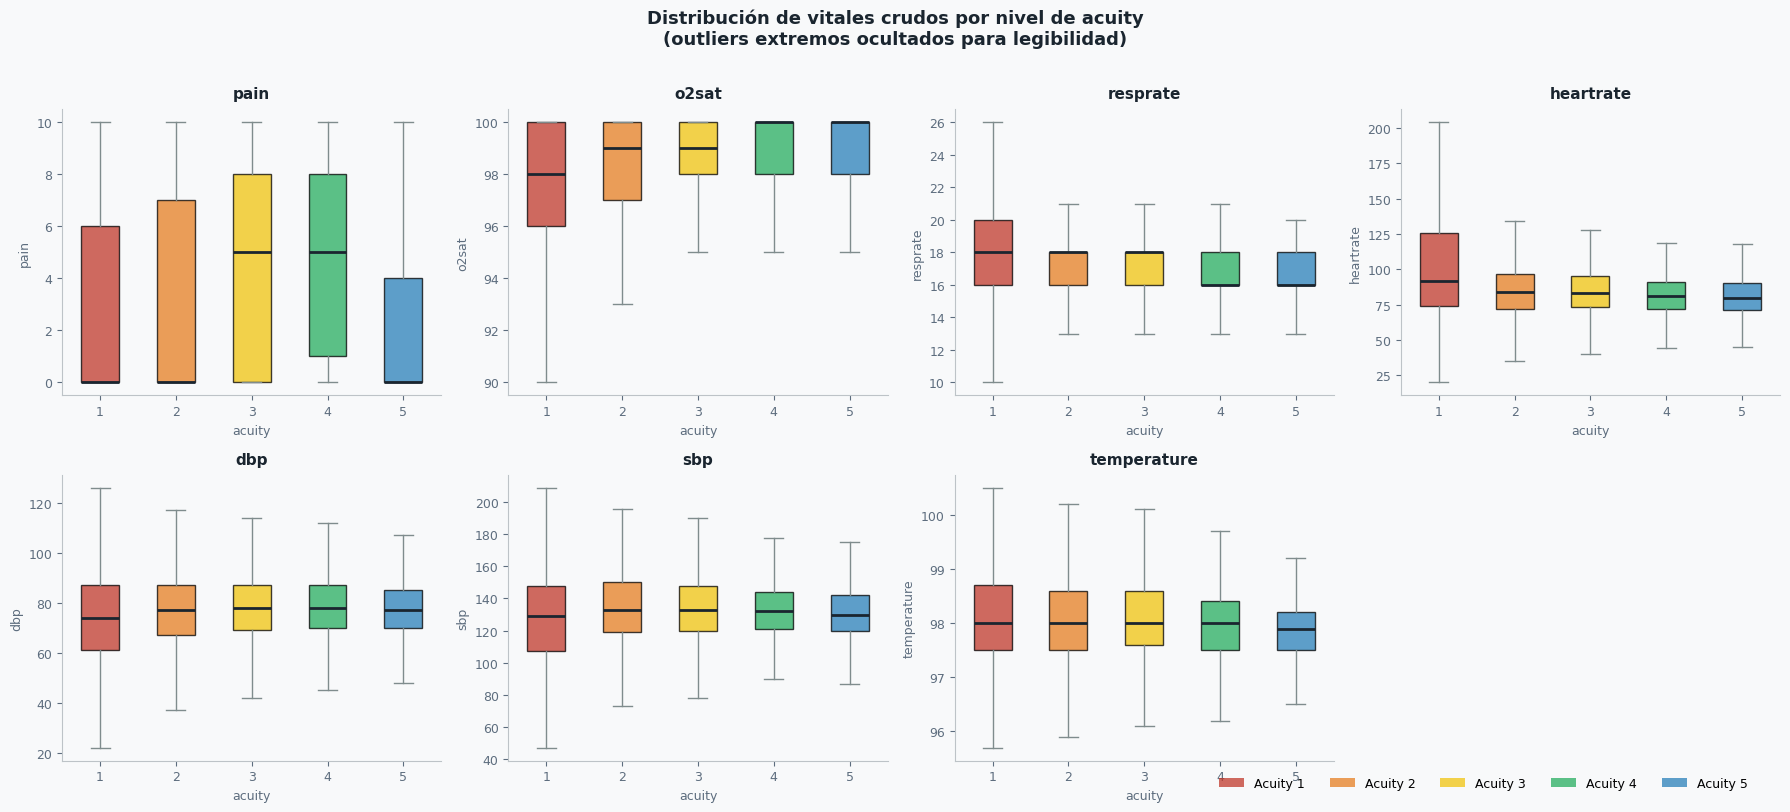

In [198]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np

VITALES = ["pain", "o2sat", "resprate", "heartrate", "dbp", "sbp", "temperature"]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.patch.set_facecolor("#F8F9FA")
axes = axes.flatten()

# Gradiente rojo→verde: acuity 1 (más urgente) → acuity 5 (menos urgente)
paleta = ["#C0392B", "#E67E22", "#F1C40F", "#27AE60", "#2980B9"]

for i, col in enumerate(VITALES):
    ax = axes[i]
    ax.set_facecolor("#F8F9FA")

    grupos = [
        df.loc[df["acuity"] == k, col].dropna().values
        for k in ACUITY_LEVELS
    ]

    bp = ax.boxplot(
        grupos,
        labels=["1", "2", "3", "4", "5"],
        patch_artist=True,
        medianprops=dict(color="#1A252F", linewidth=2),
        whiskerprops=dict(color="#7F8C8D", linewidth=1),
        capprops=dict(color="#7F8C8D", linewidth=1),
        boxprops=dict(linewidth=1),
        flierprops=dict(marker=".", markersize=1, alpha=0.2, color="#95A5A6"),
        showfliers=False,
    )

    for patch, color in zip(bp["boxes"], paleta):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)

    ax.set_title(col, fontsize=11, fontweight="bold", color="#1A252F", pad=8)
    ax.set_xlabel("acuity", fontsize=9, color="#5D6D7E")
    ax.set_ylabel(col, fontsize=9, color="#5D6D7E")
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#BDC3C7")
    ax.tick_params(colors="#5D6D7E", labelsize=9)

# Leyenda común
handles = [
    mpatches.Patch(facecolor=paleta[i], alpha=0.75, label=f"Acuity {i+1}")
    for i in range(5)
]
fig.legend(
    handles=handles,
    loc="lower right",
    bbox_to_anchor=(0.98, 0.02),
    ncol=5,
    frameon=False,
    fontsize=9,
)

# Subplot sobrante oculto
axes[-1].set_visible(False)

fig.suptitle(
    "Distribución de vitales crudos por nivel de acuity\n(outliers extremos ocultados para legibilidad)",
    fontsize=13, fontweight="bold", color="#1A252F", y=1.01
)

plt.tight_layout()
plt.show()

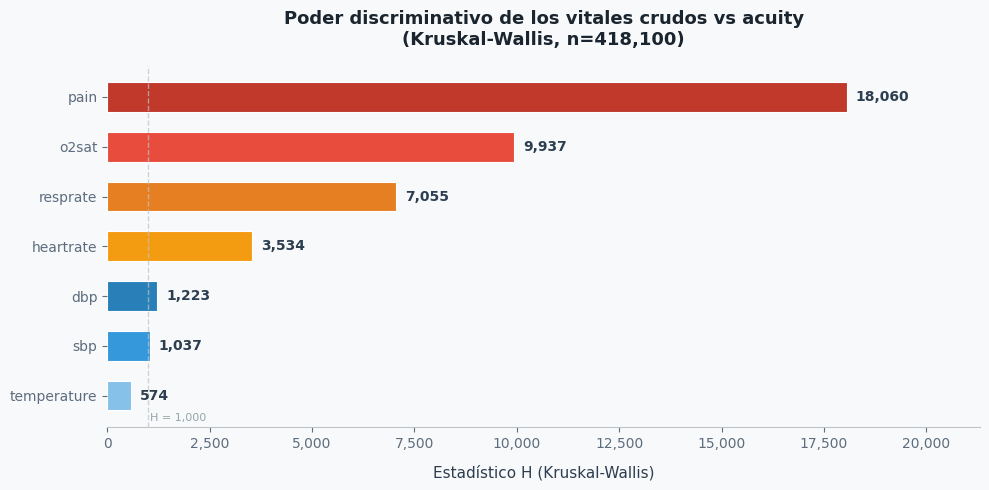

In [199]:
# Gráfico de poder discriminativo: lee H-stats de la celda anterior, no hardcodes

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor("#F8F9FA")
ax.set_facecolor("#F8F9FA")

ranking_orden = ranking_vitales.sort_values("H", ascending=True)
labels  = ranking_orden.index.tolist()
valores = ranking_orden["H"].astype(int).tolist()

# Gradiente azul→rojo según ranking (más urgente al final)
colores = ["#85C1E9", "#3498DB", "#2980B9", "#F39C12", "#E67E22", "#E74C3C", "#C0392B"]

bars = ax.barh(labels, valores, color=colores[: len(labels)],
               edgecolor="white", linewidth=0.8, height=0.6)

x_max = max(valores) * 1.18
for bar, val in zip(bars, valores):
    ax.text(bar.get_width() + x_max * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va="center", ha="left", fontsize=10,
            fontweight="bold", color="#2C3E50")

ax.axvline(x=1000, color="#BDC3C7", linewidth=1, linestyle="--", alpha=0.7)
ax.text(1050, -0.55, "H = 1,000", color="#95A5A6", fontsize=8, va="bottom")

ax.set_xlabel("Estadístico H (Kruskal-Wallis)", fontsize=11, color="#2C3E50", labelpad=10)
ax.set_title(
    f"Poder discriminativo de los vitales crudos vs acuity\n"
    f"(Kruskal-Wallis, n={len(df):,})",
    fontsize=13, fontweight="bold", color="#1A252F", pad=15,
)

ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color("#BDC3C7")
ax.tick_params(axis="both", colors="#5D6D7E", labelsize=10)
ax.set_xlim(0, x_max)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.show()


In [200]:
# Interpretación dinámica del ranking de vitales crudos
H_pain        = resultados_vitales["pain"]["H"]
H_o2sat       = resultados_vitales["o2sat"]["H"]
H_resprate    = resultados_vitales["resprate"]["H"]
H_heartrate   = resultados_vitales["heartrate"]["H"]
H_temperature = resultados_vitales["temperature"]["H"]

display(Markdown(f"""
Los siete vitales registrados en el minuto 0 del triaje muestran señal estadísticamente
significativa frente a `acuity`, pero con patrones muy distintos. `pain` es el predictor
más potente (**H={H_pain:,.0f}**) y el único con separación visual consistente a lo
largo de los cinco niveles de urgencia. `o2sat` (H={H_o2sat:,.0f}) y `heartrate`
(H={H_heartrate:,.0f}) concentran su señal en `acuity` 1, siendo útiles para identificar
los casos más críticos pero poco discriminativos en niveles intermedios. `resprate`
(H={H_resprate:,.0f}) presenta un H elevado que contrasta con un boxplot pobre — la
información relevante está en las colas, no en los valores centrales. `temperature` en
continuo es el vital más débil (**H={H_temperature:,.0f}**), lo que anticipa que su
transformación a la bandera binaria `fiebre` aportará más información al modelo que el
valor numérico crudo.
"""))



Los siete vitales registrados en el minuto 0 del triaje muestran señal estadísticamente
significativa frente a `acuity`, pero con patrones muy distintos. `pain` es el predictor
más potente (**H=18,060**) y el único con separación visual consistente a lo
largo de los cinco niveles de urgencia. `o2sat` (H=9,937) y `heartrate`
(H=3,534) concentran su señal en `acuity` 1, siendo útiles para identificar
los casos más críticos pero poco discriminativos en niveles intermedios. `resprate`
(H=7,055) presenta un H elevado que contrasta con un boxplot pobre — la
información relevante está en las colas, no en los valores centrales. `temperature` en
continuo es el vital más débil (**H=574**), lo que anticipa que su
transformación a la bandera binaria `fiebre` aportará más información al modelo que el
valor numérico crudo.


## Variables derivadas y scores clínicos


### Banderas de missingness


In [201]:
# Banderas de missingness: pain_missing, temperature_missing, o2sat_missing
# El dato ausente en urgencias no es aleatorio — tiene valor clínico propio

miss_cols = ["pain", "temperature", "o2sat"]

for col in miss_cols:
    flag = f"{col}_missing"
    df[flag] = df[col].isna().astype("int8")

resultados_missing = {}

print(f"{'Bandera':<22} {'H-stat':>8}  {'p-value':>12}  {'Prevalencia (%)':>16}")
print("─" * 65)
for col in miss_cols:
    flag = f"{col}_missing"
    H, pval = kw_por_acuity(df[flag], df[TARGET])
    prev = float(df[flag].mean() * 100)
    resultados_missing[flag] = {"H": H, "p": pval, "prev": prev}
    update_metrics_json(flag, H=round(H, 4))
    print(f"{flag:<22} {H:>8,.0f}  {pval:>12.2e}  {prev:>15.2f}%")

print("\nTasa de missing por clase de acuity (%):\n")
resumen_miss = pd.DataFrame({
    col: [df.loc[df[TARGET] == k, col].isna().mean() * 100 for k in ACUITY_LEVELS]
    for col in miss_cols
}, index=ACUITY_LEVELS)
resumen_miss.index.name = "acuity"
print(resumen_miss.round(2).to_string())


Bandera                  H-stat       p-value   Prevalencia (%)
─────────────────────────────────────────────────────────────────
pain_missing             43,537      0.00e+00             7.77%
temperature_missing      70,959      0.00e+00             4.17%
o2sat_missing            61,865      0.00e+00             3.33%

Tasa de missing por clase de acuity (%):

         pain  temperature  o2sat
acuity                           
1       41.55        37.22  31.11
2        8.78         3.67   2.71
3        4.28         1.33   1.06
4        2.18         1.19   0.87
5        2.73         3.64   3.55


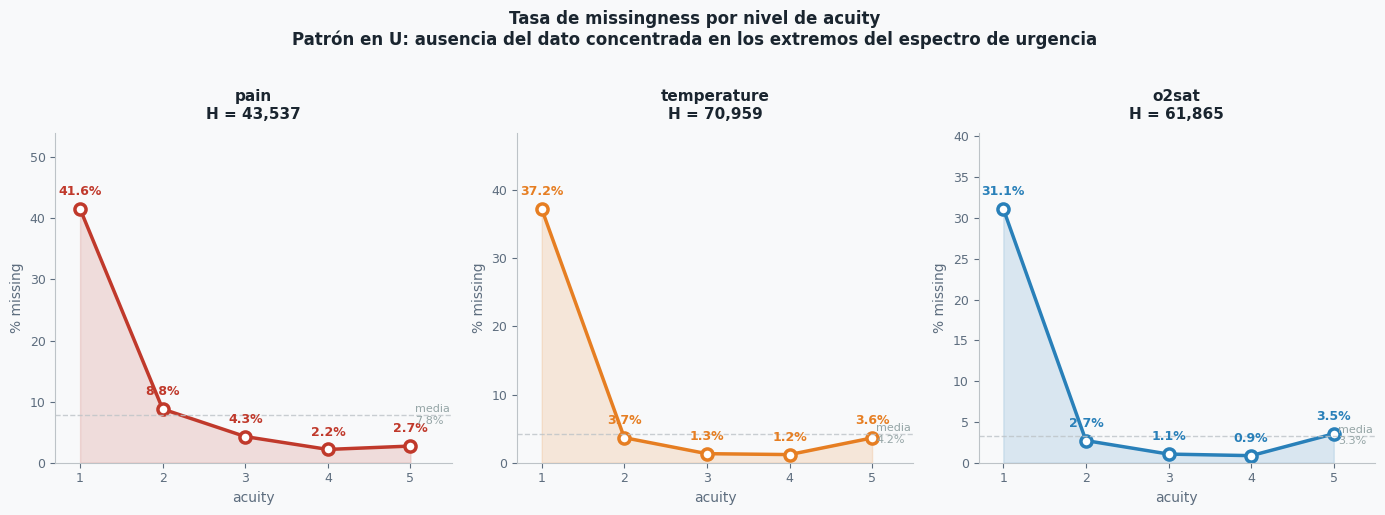

In [202]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.patch.set_facecolor("#F8F9FA")

# Colores por vital y H-stats leídos de resultados_missing
miss_info = {
    "pain":        {"flag": "pain_missing",        "color": "#C0392B"},
    "temperature": {"flag": "temperature_missing", "color": "#E67E22"},
    "o2sat":       {"flag": "o2sat_missing",       "color": "#2980B9"},
}

for ax, (col, info) in zip(axes, miss_info.items()):
    ax.set_facecolor("#F8F9FA")
    tasas = [df.loc[df[TARGET] == k, col].isna().mean() * 100 for k in ACUITY_LEVELS]

    ax.fill_between(ACUITY_LEVELS, tasas, alpha=0.15, color=info["color"])
    ax.plot(ACUITY_LEVELS, tasas, color=info["color"],
            linewidth=2.5, marker="o", markersize=8,
            markerfacecolor="white", markeredgewidth=2.5,
            markeredgecolor=info["color"])

    for x, y in zip(ACUITY_LEVELS, tasas):
        ax.annotate(f"{y:.1f}%", (x, y),
                    textcoords="offset points", xytext=(0, 10),
                    ha="center", fontsize=9, fontweight="bold",
                    color=info["color"])

    tasa_global = df[col].isna().mean() * 100
    ax.axhline(tasa_global, color="#BDC3C7", linewidth=1,
               linestyle="--", alpha=0.8)
    ax.text(5.05, tasa_global, f"media\n{tasa_global:.1f}%",
            va="center", fontsize=8, color="#95A5A6")

    H_flag = resultados_missing[info["flag"]]["H"]
    ax.set_title(f"{col}\nH = {H_flag:,.0f}", fontsize=11,
                 fontweight="bold", color="#1A252F", pad=10)
    ax.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
    ax.set_ylabel("% missing", fontsize=10, color="#5D6D7E")
    ax.set_xticks(ACUITY_LEVELS)
    ax.set_xlim(0.7, 5.5)
    ax.set_ylim(0, max(tasas) * 1.3)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#BDC3C7")
    ax.tick_params(colors="#5D6D7E", labelsize=9)

fig.suptitle(
    "Tasa de missingness por nivel de acuity\n"
    "Patrón en U: ausencia del dato concentrada en los extremos del espectro de urgencia",
    fontsize=12, fontweight="bold", color="#1A252F", y=1.02,
)

plt.tight_layout()
plt.show()


In [203]:
# Interpretación dinámica de las banderas de missingness
H_temp_miss   = resultados_missing["temperature_missing"]["H"]
H_o2_miss     = resultados_missing["o2sat_missing"]["H"]
H_pain_miss   = resultados_missing["pain_missing"]["H"]

# Comparativa contra el continuo más débil (temperature) leído del paso anterior
ratio_temp = H_temp_miss / max(resultados_vitales["temperature"]["H"], 1)

display(Markdown(f"""
Las banderas de ausencia de dato (`pain_missing` H={H_pain_miss:,.0f},
`temperature_missing` H={H_temp_miss:,.0f}, `o2sat_missing` H={H_o2_miss:,.0f}) resultan
ser las features más discriminativas del dataset hasta este punto, superando ampliamente
a sus correspondientes valores continuos en poder predictivo (×{ratio_temp:.0f} para
`temperature`). El patrón de missingness sigue una curva en U con el mínimo en
`acuity` 4: los datos faltan tanto en los casos más críticos (paciente inestable, sin
tiempo de registro) como en los más leves. Esta distribución no aleatoria — NMAR —
convierte la ausencia del dato en información clínica por sí misma. Las tres banderas
**entran obligatoriamente al modelo**.
"""))



Las banderas de ausencia de dato (`pain_missing` H=43,537,
`temperature_missing` H=70,959, `o2sat_missing` H=61,865) resultan
ser las features más discriminativas del dataset hasta este punto, superando ampliamente
a sus correspondientes valores continuos en poder predictivo (×124 para
`temperature`). El patrón de missingness sigue una curva en U con el mínimo en
`acuity` 4: los datos faltan tanto en los casos más críticos (paciente inestable, sin
tiempo de registro) como en los más leves. Esta distribución no aleatoria — NMAR —
convierte la ausencia del dato en información clínica por sí misma. Las tres banderas
**entran obligatoriamente al modelo**.


### Banderas de extremos fisiológicos


In [204]:
# Bandera clínica: o2sat_bajo_92
# Umbral crítico British Thoracic Society — por debajo del 92% la curva de
# disociación de hemoglobina entra en zona de desoxigenación tisular grave

df["o2sat_bajo_92"] = (df["o2sat"] < 92).astype("int8")
# NaN en o2sat → 0 (no se puede afirmar que esté bajo 92 sin dato)

H_o2sat_bajo, pval_o2sat_bajo = kw_por_acuity(df["o2sat_bajo_92"], df[TARGET])
prev_o2sat_bajo = float(df["o2sat_bajo_92"].mean() * 100)
pcts_o2sat_bajo = pcts_por_acuity(df["o2sat_bajo_92"], df[TARGET])

# H del continuo base — ya persistido en feature_metrics.json
H_o2sat_continuo = resultados_vitales["o2sat"]["H"]
mejora_o2sat = (H_o2sat_bajo - H_o2sat_continuo) / H_o2sat_continuo * 100

update_metrics_json("o2sat_bajo_92", H=round(H_o2sat_bajo, 4))

print(f"o2sat_bajo_92  →  H = {H_o2sat_bajo:,.0f}  |  p = {pval_o2sat_bajo:.2e}  |  prevalencia = {prev_o2sat_bajo:.2f}%")
print(f"o2sat continuo →  H = {H_o2sat_continuo:,.0f}")
print(f"Mejora bandera vs continuo: +{mejora_o2sat:.1f}%\n")

print("% de pacientes con o2sat < 92 por clase de acuity:\n")
tabla_o2sat = pd.DataFrame({
    "n_total":     df.groupby(TARGET)["o2sat_bajo_92"].count(),
    "n_bajo_92":   df.groupby(TARGET)["o2sat_bajo_92"].sum(),
    "pct_bajo_92": (df.groupby(TARGET)["o2sat_bajo_92"].mean() * 100).round(2),
})
print(tabla_o2sat.to_string())


o2sat_bajo_92  →  H = 11,908  |  p = 0.00e+00  |  prevalencia = 0.72%
o2sat continuo →  H = 9,937
Mejora bandera vs continuo: +19.8%

% de pacientes con o2sat < 92 por clase de acuity:

        n_total  n_bajo_92  pct_bajo_92
acuity                                 
1         24019       1531         6.37
2        139411       1107         0.79
3        225066        373         0.17
4         28504          4         0.01
5          1100          0         0.00


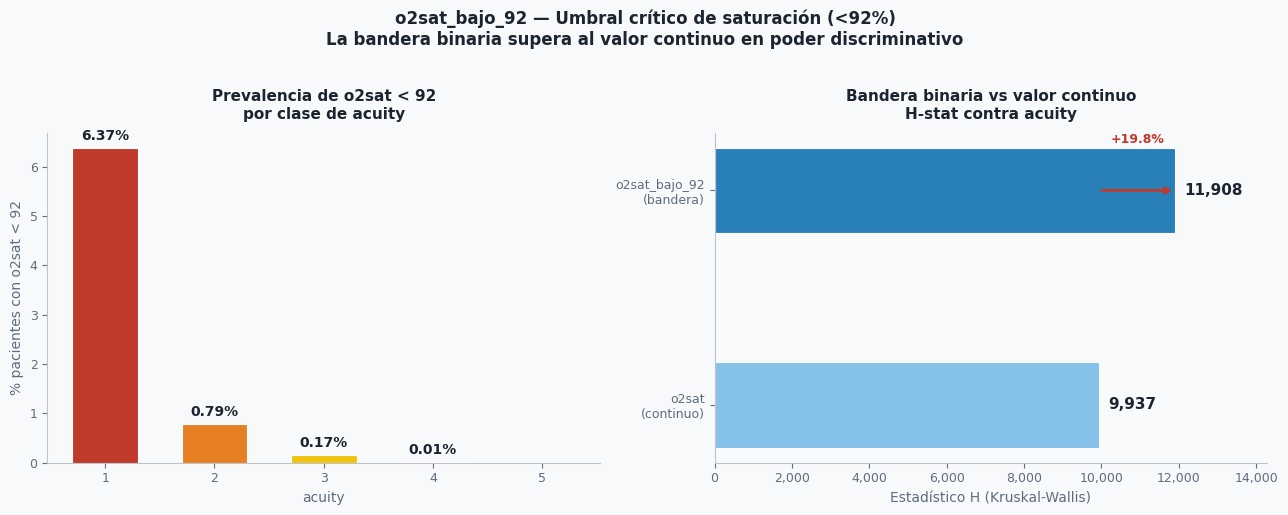

In [205]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor("#F8F9FA")

# Izquierda: % bajo 92 por clase de acuity (calculado en celda anterior)
ax1 = axes[0]
ax1.set_facecolor("#F8F9FA")

bars = ax1.bar(ACUITY_LEVELS, pcts_o2sat_bajo, color=PALETA_ACUITY,
               edgecolor="white", linewidth=0.8, width=0.6)
for bar, val in zip(bars, pcts_o2sat_bajo):
    if val > 0:
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                 f"{val:.2f}%", ha="center", va="bottom",
                 fontsize=10, fontweight="bold", color="#1A252F")

ax1.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
ax1.set_ylabel("% pacientes con o2sat < 92", fontsize=10, color="#5D6D7E")
ax1.set_title("Prevalencia de o2sat < 92\npor clase de acuity",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax1.spines[["top", "right"]].set_visible(False)
ax1.spines[["left", "bottom"]].set_color("#BDC3C7")
ax1.tick_params(colors="#5D6D7E", labelsize=9)
ax1.set_xticks(ACUITY_LEVELS)

# Derecha: comparativa H-stat bandera vs continuo
ax2 = axes[1]
ax2.set_facecolor("#F8F9FA")

features_lbl = ["o2sat\n(continuo)", "o2sat_bajo_92\n(bandera)"]
hstats       = [H_o2sat_continuo, H_o2sat_bajo]
cols_bar     = ["#85C1E9", "#2980B9"]

bars2 = ax2.barh(features_lbl, hstats, color=cols_bar,
                 edgecolor="white", linewidth=0.8, height=0.4)
for bar, val in zip(bars2, hstats):
    ax2.text(bar.get_width() + max(hstats) * 0.02, bar.get_y() + bar.get_height() / 2,
             f"{val:,.0f}", va="center", ha="left",
             fontsize=11, fontweight="bold", color="#1A252F")

ax2.annotate("", xy=(H_o2sat_bajo, 1), xytext=(H_o2sat_continuo, 1),
             arrowprops=dict(arrowstyle="->", color="#C0392B", lw=2))
ax2.text((H_o2sat_continuo + H_o2sat_bajo) / 2, 1.22,
         f"+{mejora_o2sat:.1f}%", fontsize=9,
         fontweight="bold", color="#C0392B", ha="center")

ax2.set_xlabel("Estadístico H (Kruskal-Wallis)", fontsize=10, color="#5D6D7E")
ax2.set_title("Bandera binaria vs valor continuo\nH-stat contra acuity",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax2.set_xlim(0, max(hstats) * 1.2)
ax2.spines[["top", "right"]].set_visible(False)
ax2.spines[["left", "bottom"]].set_color("#BDC3C7")
ax2.tick_params(colors="#5D6D7E", labelsize=9)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

fig.suptitle(
    "o2sat_bajo_92 — Umbral crítico de saturación (<92%)\n"
    "La bandera binaria supera al valor continuo en poder discriminativo",
    fontsize=12, fontweight="bold", color="#1A252F", y=1.02,
)

plt.tight_layout()
plt.show()


In [206]:
display(Markdown(f"""
La bandera `o2sat_bajo_92` supera al valor continuo de `o2sat` en poder discriminativo
(**H={H_o2sat_bajo:,.0f} vs H={H_o2sat_continuo:,.0f}**, mejora **+{mejora_o2sat:.1f}%**)
a pesar de una prevalencia global del **{prev_o2sat_bajo:.2f}%**. Su señal es casi
exclusiva de `acuity` 1 ({pcts_o2sat_bajo[0]:.2f}%) y se desvanece rápidamente hacia
los niveles menos urgentes, llegando a {pcts_o2sat_bajo[4]:.2f}% en `acuity` 5.
Cuando se activa, es un indicador casi inequívoco de emergencia. **Entra al modelo.**
"""))



La bandera `o2sat_bajo_92` supera al valor continuo de `o2sat` en poder discriminativo
(**H=11,908 vs H=9,937**, mejora **+19.8%**)
a pesar de una prevalencia global del **0.72%**. Su señal es casi
exclusiva de `acuity` 1 (6.37%) y se desvanece rápidamente hacia
los niveles menos urgentes, llegando a 0.00% en `acuity` 5.
Cuando se activa, es un indicador casi inequívoco de emergencia. **Entra al modelo.**


In [207]:
# Bandera clínica: fiebre
# Umbral estándar: temperatura >= 100.4°F (38.0°C) — guías SEMICYUC/AHA
# Hipótesis: el fenómeno binario fiebre/no-fiebre captura más señal que el
# gradiente continuo de temperature

df["fiebre"] = (df["temperature"] >= 100.4).astype("int8")
# NaN en temperature → 0 (sin dato no se puede afirmar fiebre)

H_fiebre, pval_fiebre = kw_por_acuity(df["fiebre"], df[TARGET])
prev_fiebre = float(df["fiebre"].mean() * 100)
pcts_fiebre = pcts_por_acuity(df["fiebre"], df[TARGET])

H_temp_continuo = resultados_vitales["temperature"]["H"]
mejora_fiebre = (H_fiebre - H_temp_continuo) / H_temp_continuo * 100

update_metrics_json("fiebre", H=round(H_fiebre, 4))

print(f"fiebre         →  H = {H_fiebre:,.0f}  |  p = {pval_fiebre:.2e}  |  prevalencia = {prev_fiebre:.2f}%")
print(f"temperature    →  H = {H_temp_continuo:,.0f}")
print(f"Mejora bandera vs continuo: +{mejora_fiebre:.1f}%\n")

print("% de pacientes con fiebre por clase de acuity:\n")
tabla_fiebre = pd.DataFrame({
    "n_total":    df.groupby(TARGET)["fiebre"].count(),
    "n_fiebre":   df.groupby(TARGET)["fiebre"].sum(),
    "pct_fiebre": (df.groupby(TARGET)["fiebre"].mean() * 100).round(2),
})
print(tabla_fiebre.to_string())


fiebre         →  H = 1,049  |  p = 8.54e-226  |  prevalencia = 2.20%
temperature    →  H = 574
Mejora bandera vs continuo: +82.8%

% de pacientes con fiebre por clase de acuity:

        n_total  n_fiebre  pct_fiebre
acuity                               
1         24019       937        3.90
2        139411      3754        2.69
3        225066      4407        1.96
4         28504        84        0.29
5          1100         0        0.00


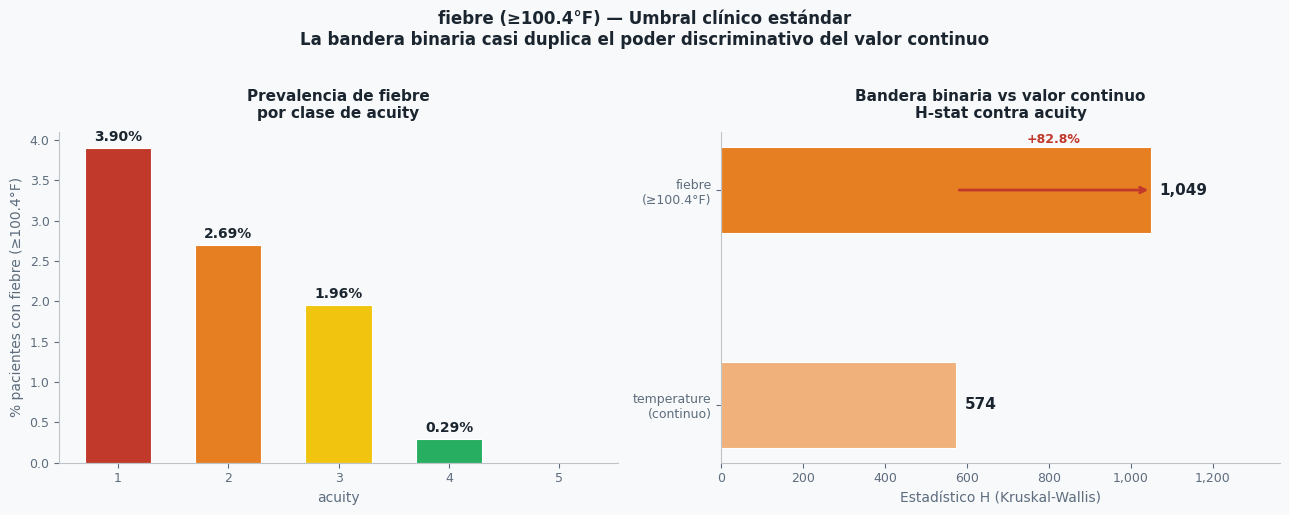

In [208]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor("#F8F9FA")

ax1 = axes[0]
ax1.set_facecolor("#F8F9FA")

bars = ax1.bar(ACUITY_LEVELS, pcts_fiebre, color=PALETA_ACUITY,
               edgecolor="white", linewidth=0.8, width=0.6)
for bar, val in zip(bars, pcts_fiebre):
    if val > 0:
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                 f"{val:.2f}%", ha="center", va="bottom",
                 fontsize=10, fontweight="bold", color="#1A252F")

ax1.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
ax1.set_ylabel("% pacientes con fiebre (≥100.4°F)", fontsize=10, color="#5D6D7E")
ax1.set_title("Prevalencia de fiebre\npor clase de acuity",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax1.spines[["top", "right"]].set_visible(False)
ax1.spines[["left", "bottom"]].set_color("#BDC3C7")
ax1.tick_params(colors="#5D6D7E", labelsize=9)
ax1.set_xticks(ACUITY_LEVELS)

ax2 = axes[1]
ax2.set_facecolor("#F8F9FA")

features_lbl = ["temperature\n(continuo)", "fiebre\n(≥100.4°F)"]
hstats       = [H_temp_continuo, H_fiebre]
cols_bar     = ["#F0B27A", "#E67E22"]

bars2 = ax2.barh(features_lbl, hstats, color=cols_bar,
                 edgecolor="white", linewidth=0.8, height=0.4)
for bar, val in zip(bars2, hstats):
    ax2.text(bar.get_width() + max(hstats) * 0.02, bar.get_y() + bar.get_height() / 2,
             f"{val:,.0f}", va="center", ha="left",
             fontsize=11, fontweight="bold", color="#1A252F")

ax2.annotate("", xy=(H_fiebre, 1), xytext=(H_temp_continuo, 1),
             arrowprops=dict(arrowstyle="->", color="#C0392B", lw=2))
ax2.text((H_temp_continuo + H_fiebre) / 2, 1.22,
         f"+{mejora_fiebre:.1f}%", fontsize=9,
         fontweight="bold", color="#C0392B", ha="center")

ax2.set_xlabel("Estadístico H (Kruskal-Wallis)", fontsize=10, color="#5D6D7E")
ax2.set_title("Bandera binaria vs valor continuo\nH-stat contra acuity",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax2.set_xlim(0, max(hstats) * 1.3)
ax2.spines[["top", "right"]].set_visible(False)
ax2.spines[["left", "bottom"]].set_color("#BDC3C7")
ax2.tick_params(colors="#5D6D7E", labelsize=9)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

fig.suptitle(
    "fiebre (≥100.4°F) — Umbral clínico estándar\n"
    "La bandera binaria casi duplica el poder discriminativo del valor continuo",
    fontsize=12, fontweight="bold", color="#1A252F", y=1.02,
)

plt.tight_layout()
plt.show()


In [209]:
display(Markdown(f"""
La bandera `fiebre` (≥100.4°F) casi duplica el poder discriminativo del valor continuo
de `temperature` (**H={H_fiebre:,.0f} vs H={H_temp_continuo:,.0f}**, mejora
**+{mejora_fiebre:.1f}%**), confirmando que el fenómeno binario captura más señal que
el gradiente numérico. Su distribución decrece progresivamente desde
`acuity` 1 ({pcts_fiebre[0]:.2f}%) hasta `acuity` 5 ({pcts_fiebre[4]:.2f}%), lo que la
hace útil para separar también niveles intermedios. Con prevalencia del
{prev_fiebre:.2f}% es suficientemente frecuente para ser informativa en producción.
**Entra al modelo. El valor continuo `temperature` queda descartado.**
"""))



La bandera `fiebre` (≥100.4°F) casi duplica el poder discriminativo del valor continuo
de `temperature` (**H=1,049 vs H=574**, mejora
**+82.8%**), confirmando que el fenómeno binario captura más señal que
el gradiente numérico. Su distribución decrece progresivamente desde
`acuity` 1 (3.90%) hasta `acuity` 5 (0.00%), lo que la
hace útil para separar también niveles intermedios. Con prevalencia del
2.20% es suficientemente frecuente para ser informativa en producción.
**Entra al modelo. El valor continuo `temperature` queda descartado.**


In [210]:
# Banderas clínicas: extremos de frecuencia respiratoria
# taquipnea_grave: > 24 rpm — alarma en NEWS2/qSOFA
# bradipnea:       < 10 rpm — depresión respiratoria, riesgo de parada (descartada)

df["taquipnea_grave"] = (df["resprate"] > 24).astype("int8")
df["bradipnea"]       = (df["resprate"] < 10).astype("int8")

resultados_resp = {}

print(f"{'Bandera':<20} {'H-stat':>8}  {'p-value':>12}  {'Prevalencia':>12}  {'n casos':>8}")
print("─" * 70)
for col in ["taquipnea_grave", "bradipnea"]:
    H, pval = kw_por_acuity(df[col], df[TARGET])
    prev = float(df[col].mean() * 100)
    n    = int(df[col].sum())
    resultados_resp[col] = {"H": H, "prev": prev, "n": n, "pcts": pcts_por_acuity(df[col], df[TARGET])}
    update_metrics_json(col, H=round(H, 4))
    print(f"{col:<20} {H:>8,.0f}  {pval:>12.2e}  {prev:>11.2f}%  {n:>8,}")

H_resprate_continuo = resultados_vitales["resprate"]["H"]
print(f"\nresprate continuo  →  H = {H_resprate_continuo:,.0f}\n")

print("% por clase de acuity:\n")
print(pd.DataFrame({
    col: [round(p, 2) for p in resultados_resp[col]["pcts"]]
    for col in ["taquipnea_grave", "bradipnea"]
}, index=ACUITY_LEVELS).to_string())


Bandera                H-stat       p-value   Prevalencia   n casos
──────────────────────────────────────────────────────────────────────
taquipnea_grave        11,007      0.00e+00         1.15%     4,829
bradipnea                 165      1.54e-34         0.02%       101

resprate continuo  →  H = 7,055

% por clase de acuity:

   taquipnea_grave  bradipnea
1             7.49       0.15
2             1.81       0.03
3             0.22       0.01
4             0.03       0.01
5             0.18       0.00


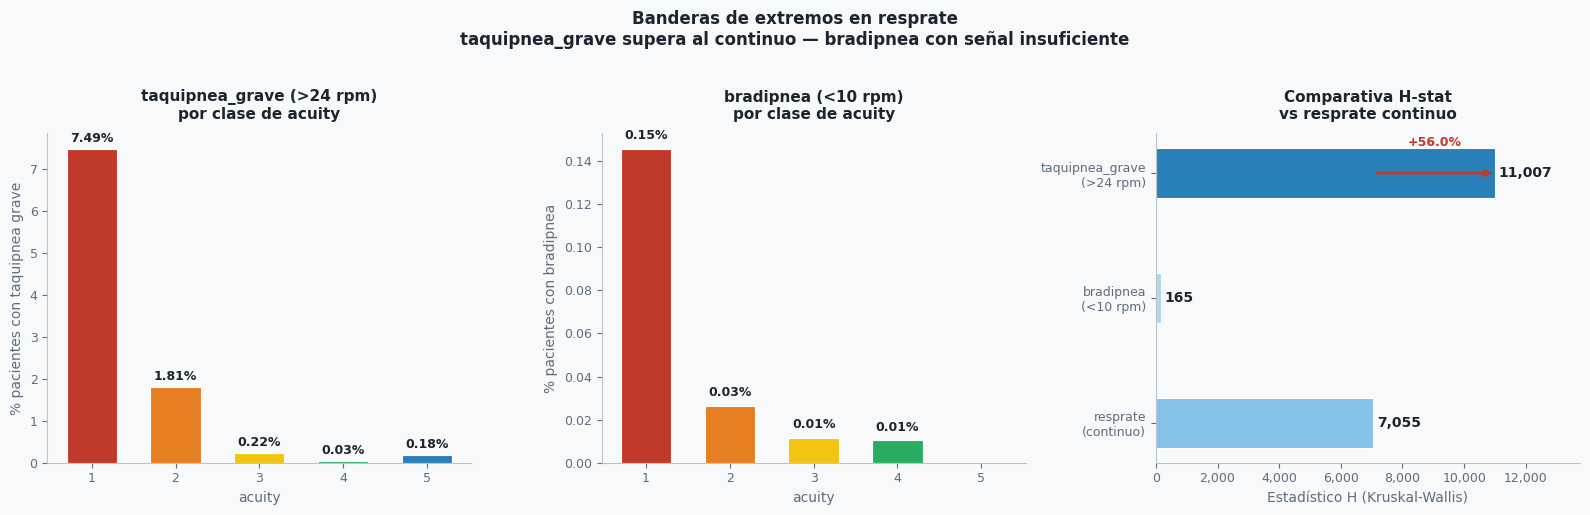

In [211]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor("#F8F9FA")

# Panel 1 — taquipnea_grave por acuity
ax1 = axes[0]
ax1.set_facecolor("#F8F9FA")

pcts_taq = resultados_resp["taquipnea_grave"]["pcts"]
bars = ax1.bar(ACUITY_LEVELS, pcts_taq, color=PALETA_ACUITY,
               edgecolor="white", linewidth=0.8, width=0.6)
for bar, val in zip(bars, pcts_taq):
    if val > 0:
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                 f"{val:.2f}%", ha="center", va="bottom",
                 fontsize=9, fontweight="bold", color="#1A252F")

ax1.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
ax1.set_ylabel("% pacientes con taquipnea grave", fontsize=10, color="#5D6D7E")
ax1.set_title("taquipnea_grave (>24 rpm)\npor clase de acuity",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax1.spines[["top", "right"]].set_visible(False)
ax1.spines[["left", "bottom"]].set_color("#BDC3C7")
ax1.tick_params(colors="#5D6D7E", labelsize=9)
ax1.set_xticks(ACUITY_LEVELS)

# Panel 2 — bradipnea por acuity
ax2 = axes[1]
ax2.set_facecolor("#F8F9FA")

pcts_brad = resultados_resp["bradipnea"]["pcts"]
bars2 = ax2.bar(ACUITY_LEVELS, pcts_brad, color=PALETA_ACUITY,
                edgecolor="white", linewidth=0.8, width=0.6)
for bar, val in zip(bars2, pcts_brad):
    if val > 0:
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                 f"{val:.2f}%", ha="center", va="bottom",
                 fontsize=9, fontweight="bold", color="#1A252F")

ax2.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
ax2.set_ylabel("% pacientes con bradipnea", fontsize=10, color="#5D6D7E")
ax2.set_title("bradipnea (<10 rpm)\npor clase de acuity",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax2.spines[["top", "right"]].set_visible(False)
ax2.spines[["left", "bottom"]].set_color("#BDC3C7")
ax2.tick_params(colors="#5D6D7E", labelsize=9)
ax2.set_xticks(ACUITY_LEVELS)

# Panel 3 — comparativa H-stat
ax3 = axes[2]
ax3.set_facecolor("#F8F9FA")

H_taq  = resultados_resp["taquipnea_grave"]["H"]
H_brad = resultados_resp["bradipnea"]["H"]
features_lbl = ["resprate\n(continuo)", "bradipnea\n(<10 rpm)", "taquipnea_grave\n(>24 rpm)"]
hstats       = [H_resprate_continuo, H_brad, H_taq]
cols_bar     = ["#85C1E9", "#AED6F1", "#2980B9"]

bars3 = ax3.barh(features_lbl, hstats, color=cols_bar,
                 edgecolor="white", linewidth=0.8, height=0.4)
for bar, val in zip(bars3, hstats):
    ax3.text(bar.get_width() + max(hstats) * 0.01,
             bar.get_y() + bar.get_height() / 2,
             f"{val:,.0f}", va="center", ha="left",
             fontsize=10, fontweight="bold", color="#1A252F")

mejora_taq = (H_taq - H_resprate_continuo) / H_resprate_continuo * 100
ax3.annotate("", xy=(H_taq, 2), xytext=(H_resprate_continuo, 2),
             arrowprops=dict(arrowstyle="->", color="#C0392B", lw=2))
ax3.text((H_resprate_continuo + H_taq) / 2, 2.22,
         f"+{mejora_taq:.1f}%", fontsize=9,
         fontweight="bold", color="#C0392B", ha="center")

ax3.set_xlabel("Estadístico H (Kruskal-Wallis)", fontsize=10, color="#5D6D7E")
ax3.set_title("Comparativa H-stat\nvs resprate continuo",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax3.set_xlim(0, max(hstats) * 1.25)
ax3.spines[["top", "right"]].set_visible(False)
ax3.spines[["left", "bottom"]].set_color("#BDC3C7")
ax3.tick_params(colors="#5D6D7E", labelsize=9)
ax3.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

fig.suptitle(
    "Banderas de extremos en resprate\n"
    "taquipnea_grave supera al continuo — bradipnea con señal insuficiente",
    fontsize=12, fontweight="bold", color="#1A252F", y=1.02,
)

plt.tight_layout()
plt.show()


In [212]:
display(Markdown(f"""
**`taquipnea_grave` (>24 rpm) — Entra al modelo.**
Supera al valor continuo de `resprate` (**H={resultados_resp["taquipnea_grave"]["H"]:,.0f}
vs H={H_resprate_continuo:,.0f}**, mejora
**+{(resultados_resp["taquipnea_grave"]["H"] - H_resprate_continuo) / H_resprate_continuo * 100:.1f}%**)
con una distribución clara: {resultados_resp["taquipnea_grave"]["pcts"][0]:.2f}% en
`acuity` 1 frente a valores prácticamente nulos en `acuity` 3-5
(prevalencia global {resultados_resp["taquipnea_grave"]["prev"]:.2f}%, n={resultados_resp["taquipnea_grave"]["n"]:,}).

**`bradipnea` (<10 rpm) — Descartada.**
Sólo {resultados_resp["bradipnea"]["n"]:,} casos
({resultados_resp["bradipnea"]["prev"]:.3f}%) con
H={resultados_resp["bradipnea"]["H"]:,.0f} y distribución no monótona — `acuity` 2 supera
a `acuity` 1 ({resultados_resp["bradipnea"]["pcts"][1]:.2f}% vs
{resultados_resp["bradipnea"]["pcts"][0]:.2f}%). Señal demasiado débil y ruidosa para
aportar valor predictivo neto.
"""))



**`taquipnea_grave` (>24 rpm) — Entra al modelo.**
Supera al valor continuo de `resprate` (**H=11,007
vs H=7,055**, mejora
**+56.0%**)
con una distribución clara: 7.49% en
`acuity` 1 frente a valores prácticamente nulos en `acuity` 3-5
(prevalencia global 1.15%, n=4,829).

**`bradipnea` (<10 rpm) — Descartada.**
Sólo 101 casos
(0.024%) con
H=165 y distribución no monótona — `acuity` 2 supera
a `acuity` 1 (0.03% vs
0.15%). Señal demasiado débil y ruidosa para
aportar valor predictivo neto.


In [213]:
# Score clínico: Shock Index (SI)
# Mutschler M. et al., Critical Care 2013;17(4):R172.
# Fórmula: heartrate / sbp
# Umbrales clínicos:
#   < 0.6   → normal
#   0.6–1.0 → leve compromiso hemodinámico
#   ≥ 1.0   → shock moderado-grave
#   ≥ 1.4   → shock severo, mortalidad elevada

df["shock_index"] = df["heartrate"] / df["sbp"]
# NaN si cualquiera de los dos vitales es nulo — comportamiento correcto

H_shock_continuo, pval_si = kw_por_acuity(df["shock_index"], df[TARGET])
prev_si_nulos = float(df["shock_index"].isna().mean() * 100)

update_metrics_json("shock_index", H=round(H_shock_continuo, 4))

print(f"shock_index  →  H = {H_shock_continuo:,.0f}  |  p = {pval_si:.2e}  |  nulos = {prev_si_nulos:.2f}%\n")
print("Mediana de shock_index por clase de acuity:\n")
print(df.groupby(TARGET)["shock_index"].median().round(3).to_string())

print("\n% por umbral clínico:\n")
umbrales_si = {
    "SI < 0.6 (normal)":     float((df["shock_index"] < 0.6).mean() * 100),
    "SI 0.6–1.0 (leve)":     float(((df["shock_index"] >= 0.6) & (df["shock_index"] < 1.0)).mean() * 100),
    "SI 1.0–1.4 (moderado)": float(((df["shock_index"] >= 1.0) & (df["shock_index"] < 1.4)).mean() * 100),
    "SI ≥ 1.4 (severo)":     float((df["shock_index"] >= 1.4).mean() * 100),
}
for k, v in umbrales_si.items():
    print(f"  {k}:  {v:.2f}%")


shock_index  →  H = 4,565  |  p = 0.00e+00  |  nulos = 2.99%

Mediana de shock_index por clase de acuity:

acuity
1    0.750
2    0.629
3    0.627
4    0.614
5    0.612

% por umbral clínico:

  SI < 0.6 (normal):  41.18%
  SI 0.6–1.0 (leve):  52.34%
  SI 1.0–1.4 (moderado):  3.27%
  SI ≥ 1.4 (severo):  0.22%


In [214]:
# Banderas binarias derivadas del Shock Index
df["shock_index_alto"]   = (df["shock_index"] >= 1.0).astype("int8")
df["shock_index_severo"] = (df["shock_index"] >= 1.4).astype("int8")

resultados_si = {}

print(f"{'Feature':<25} {'H-stat':>8}  {'p-value':>12}  {'Prevalencia':>12}  {'n casos':>8}")
print("─" * 75)

for col in ["shock_index", "shock_index_alto", "shock_index_severo"]:
    H, pval = kw_por_acuity(df[col], df[TARGET])
    prev = float(df[col].mean() * 100) if col != "shock_index" else float(df[col].notna().mean() * 100)
    n    = int(df[col].sum()) if col != "shock_index" else int(df[col].notna().sum())
    resultados_si[col] = {
        "H": H, "pcts": pcts_por_acuity(df[col], df[TARGET]),
        "prev": prev, "n": n,
    }
    update_metrics_json(col, H=round(H, 4))
    print(f"{col:<25} {H:>8,.0f}  {pval:>12.2e}  {prev:>11.2f}%  {n:>8,}")

print("\n% con shock_index_alto (≥1.0) por clase de acuity:\n")
print((df.groupby(TARGET)["shock_index_alto"].mean() * 100).round(2).to_string())
print("\n% con shock_index_severo (≥1.4) por clase de acuity:\n")
print((df.groupby(TARGET)["shock_index_severo"].mean() * 100).round(2).to_string())


Feature                     H-stat       p-value   Prevalencia   n casos
───────────────────────────────────────────────────────────────────────────
shock_index                  4,565      0.00e+00        97.01%   405,591
shock_index_alto            18,219      0.00e+00         3.49%    14,590
shock_index_severo          10,336      0.00e+00         0.22%       915

% con shock_index_alto (≥1.0) por clase de acuity:

acuity
1    18.17
2     4.27
3     1.82
4     0.60
5     0.64

% con shock_index_severo (≥1.4) por clase de acuity:

acuity
1    3.19
2    0.10
3    0.00
4    0.00
5    0.00


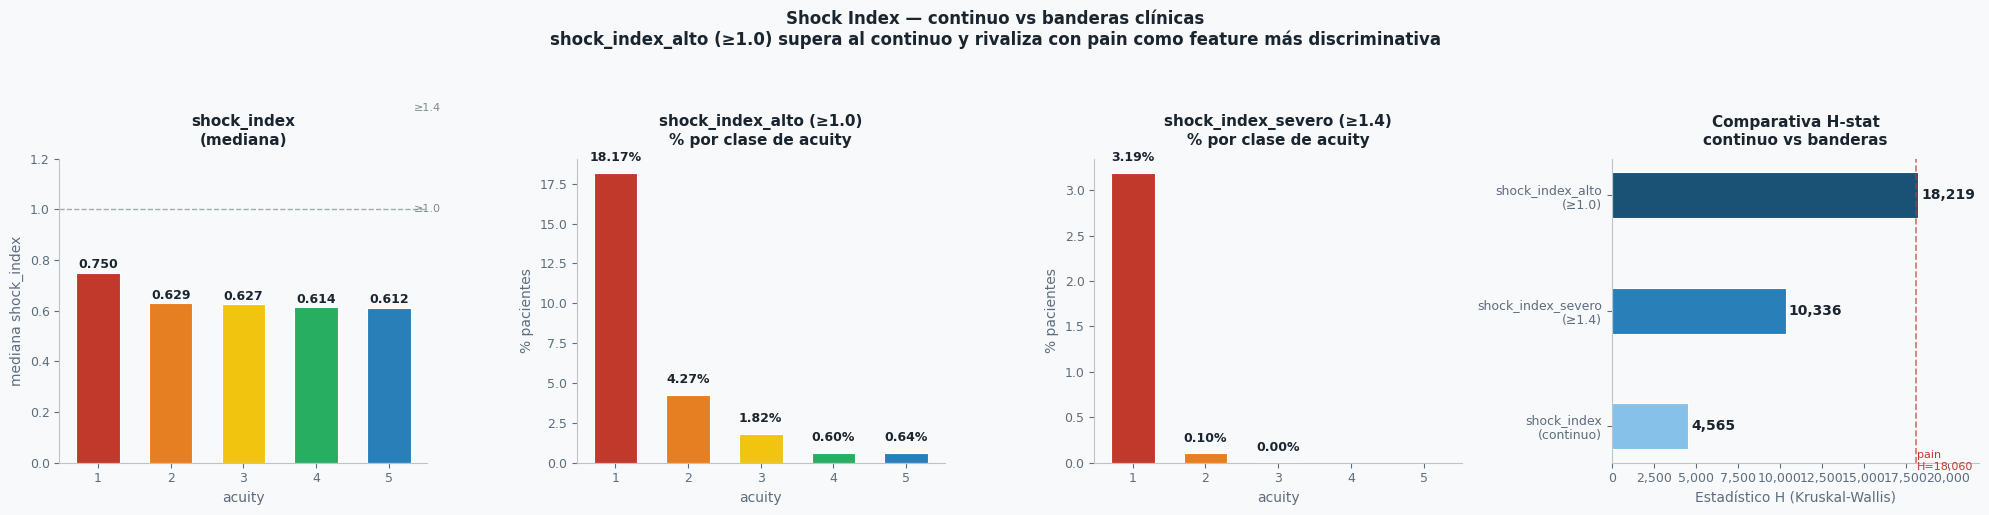

In [215]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.patch.set_facecolor("#F8F9FA")

# Panel 1 — mediana shock_index por acuity
ax1 = axes[0]
ax1.set_facecolor("#F8F9FA")
medianas_si = df.groupby(TARGET)["shock_index"].median().round(3).values
bars = ax1.bar(ACUITY_LEVELS, medianas_si, color=PALETA_ACUITY,
               edgecolor="white", linewidth=0.8, width=0.6)
for bar, val in zip(bars, medianas_si):
    if val > 0:
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                 f"{val:.3f}", ha="center", va="bottom",
                 fontsize=9, fontweight="bold", color="#1A252F")

ax1.axhline(1.0, color="#7F8C8D", linewidth=1, linestyle="--", alpha=0.7)
ax1.text(5.35, 1.0, "≥1.0", fontsize=8, color="#7F8C8D", va="center")
ax1.axhline(1.4, color="#7F8C8D", linewidth=1, linestyle="--", alpha=0.7)
ax1.text(5.35, 1.4, "≥1.4", fontsize=8, color="#7F8C8D", va="center")
ax1.set_ylim(0, max(medianas_si) * 1.6)
ax1.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
ax1.set_ylabel("mediana shock_index", fontsize=10, color="#5D6D7E")
ax1.set_title("shock_index\n(mediana)", fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax1.spines[["top", "right"]].set_visible(False)
ax1.spines[["left", "bottom"]].set_color("#BDC3C7")
ax1.tick_params(colors="#5D6D7E", labelsize=9)
ax1.set_xticks(ACUITY_LEVELS)

# Paneles 2 y 3 — % shock_index_alto y shock_index_severo
for i, col in enumerate(["shock_index_alto", "shock_index_severo"], start=1):
    ax = axes[i]
    ax.set_facecolor("#F8F9FA")
    pcts = resultados_si[col]["pcts"]
    bars = ax.bar(ACUITY_LEVELS, pcts, color=PALETA_ACUITY,
                  edgecolor="white", linewidth=0.8, width=0.6)
    offset = max(0.05, max(pcts) * 0.03)
    for bar, val in zip(bars, pcts):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + offset,
                    f"{val:.2f}%", ha="center", va="bottom",
                    fontsize=9, fontweight="bold", color="#1A252F")
    label = "≥1.0" if col.endswith("alto") else "≥1.4"
    ax.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
    ax.set_ylabel("% pacientes", fontsize=10, color="#5D6D7E")
    ax.set_title(f"{col} ({label})\n% por clase de acuity",
                 fontsize=11, fontweight="bold", color="#1A252F", pad=10)
    ax.spines[["top", "right"]].set_visible(False)
    ax.spines[["left", "bottom"]].set_color("#BDC3C7")
    ax.tick_params(colors="#5D6D7E", labelsize=9)
    ax.set_xticks(ACUITY_LEVELS)

# Panel 4 — comparativa H-stat
ax4 = axes[3]
ax4.set_facecolor("#F8F9FA")
features_lbl = ["shock_index\n(continuo)", "shock_index_severo\n(≥1.4)", "shock_index_alto\n(≥1.0)"]
hstats = [
    resultados_si["shock_index"]["H"],
    resultados_si["shock_index_severo"]["H"],
    resultados_si["shock_index_alto"]["H"],
]
cols_h = ["#85C1E9", "#2980B9", "#1A5276"]
bars = ax4.barh(features_lbl, hstats, color=cols_h,
                edgecolor="white", linewidth=0.8, height=0.4)
for bar, val in zip(bars, hstats):
    ax4.text(bar.get_width() + max(hstats) * 0.01,
             bar.get_y() + bar.get_height() / 2,
             f"{val:,.0f}", va="center", ha="left",
             fontsize=10, fontweight="bold", color="#1A252F")

# Línea de referencia: pain
H_pain_ref = resultados_vitales["pain"]["H"]
ax4.axvline(x=H_pain_ref, color="#C0392B", linewidth=1.2, linestyle="--", alpha=0.7)
ax4.text(H_pain_ref + max(hstats) * 0.005, -0.4,
         f"pain\nH={H_pain_ref:,.0f}", color="#C0392B",
         fontsize=8, va="bottom")

ax4.set_xlabel("Estadístico H (Kruskal-Wallis)", fontsize=10, color="#5D6D7E")
ax4.set_title("Comparativa H-stat\ncontinuo vs banderas",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax4.set_xlim(0, max(max(hstats), H_pain_ref) * 1.2)
ax4.spines[["top", "right"]].set_visible(False)
ax4.spines[["left", "bottom"]].set_color("#BDC3C7")
ax4.tick_params(colors="#5D6D7E", labelsize=9)
ax4.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

fig.suptitle(
    "Shock Index — continuo vs banderas clínicas\n"
    "shock_index_alto (≥1.0) supera al continuo y rivaliza con pain como feature más discriminativa",
    fontsize=12, fontweight="bold", color="#1A252F", y=1.02,
)

plt.tight_layout()
plt.show()


In [216]:
H_si_alto    = resultados_si["shock_index_alto"]["H"]
H_si_severo  = resultados_si["shock_index_severo"]["H"]
H_si_cont    = resultados_si["shock_index"]["H"]
mejora_si    = (H_si_alto - H_si_cont) / H_si_cont * 100

display(Markdown(f"""
**`shock_index_alto` (≥1.0) — Entra al modelo (H={H_si_alto:,.0f}).**
Supera al valor continuo (**H={H_si_cont:,.0f}**, mejora **+{mejora_si:.1f}%**) y queda
casi a la altura de `pain` (H={H_pain_ref:,.0f}). Distribución decreciente:
{resultados_si["shock_index_alto"]["pcts"][0]:.2f}% en `acuity` 1 →
{resultados_si["shock_index_alto"]["pcts"][4]:.2f}% en `acuity` 5.

**`shock_index_severo` (≥1.4) — Entra al modelo (H={H_si_severo:,.0f}).**
Casi exclusivo de `acuity` 1 ({resultados_si["shock_index_severo"]["pcts"][0]:.2f}%)
con presencia residual en el resto — indicador casi determinista de emergencia.

**`shock_index` continuo — Descartado.** Acuity 2-5 tienen medianas casi idénticas; las
banderas resuelven la señal en escalón que el continuo difumina.
"""))



**`shock_index_alto` (≥1.0) — Entra al modelo (H=18,219).**
Supera al valor continuo (**H=4,565**, mejora **+299.1%**) y queda
casi a la altura de `pain` (H=18,060). Distribución decreciente:
18.17% en `acuity` 1 →
0.64% en `acuity` 5.

**`shock_index_severo` (≥1.4) — Entra al modelo (H=10,336).**
Casi exclusivo de `acuity` 1 (3.19%)
con presencia residual en el resto — indicador casi determinista de emergencia.

**`shock_index` continuo — Descartado.** Acuity 2-5 tienen medianas casi idénticas; las
banderas resuelven la señal en escalón que el continuo difumina.


In [217]:
# Score clínico: Pulse Pressure (PP)
# Fórmula: sbp - dbp
# Umbrales clínicos:
#   < 25  → estrecha — bajo gasto cardíaco, taponamiento
#   ≥ 100 → amplia   — insuficiencia aórtica, sepsis

df["pulse_pressure"] = df["sbp"] - df["dbp"]

H_pp, pval_pp = kw_por_acuity(df["pulse_pressure"], df[TARGET])
prev_pp_nulos = float(df["pulse_pressure"].isna().mean() * 100)

update_metrics_json("pulse_pressure", H=round(H_pp, 4))

print(f"pulse_pressure  →  H = {H_pp:,.0f}  |  p = {pval_pp:.2e}  |  nulos = {prev_pp_nulos:.2f}%\n")
print("Mediana de pulse_pressure por clase de acuity:\n")
print(df.groupby(TARGET)["pulse_pressure"].median().round(1).to_string())

print("\n% por umbral clínico:\n")
umbrales_pp = {
    "PP < 25 (estrecha)":     float((df["pulse_pressure"] < 25).mean() * 100),
    "PP 25-40 (límite)":      float(((df["pulse_pressure"] >= 25) & (df["pulse_pressure"] < 40)).mean() * 100),
    "PP 40-100 (normal)":     float(((df["pulse_pressure"] >= 40) & (df["pulse_pressure"] < 100)).mean() * 100),
    "PP ≥ 100 (amplia)":      float((df["pulse_pressure"] >= 100).mean() * 100),
}
for k, v in umbrales_pp.items():
    print(f"  {k}:  {v:.2f}%")


pulse_pressure  →  H = 1,374  |  p = 2.93e-296  |  nulos = 3.08%

Mediana de pulse_pressure por clase de acuity:

acuity
1    51.0
2    56.0
3    55.0
4    53.0
5    53.0

% por umbral clínico:

  PP < 25 (estrecha):  2.02%
  PP 25-40 (límite):  13.10%
  PP 40-100 (normal):  78.43%
  PP ≥ 100 (amplia):  3.38%


In [218]:
df["pp_estrecha"] = (df["pulse_pressure"] < 25).astype("int8")
df["pp_amplia"]   = (df["pulse_pressure"] >= 100).astype("int8")

resultados_pp = {}

print(f"{'Bandera':<20} {'H-stat':>8}  {'p-value':>12}  {'Prevalencia':>12}  {'n casos':>8}")
print("─" * 70)

for col in ["pulse_pressure", "pp_estrecha", "pp_amplia"]:
    H, pval = kw_por_acuity(df[col], df[TARGET])
    prev = float(df[col].mean() * 100) if col != "pulse_pressure" else float(df[col].notna().mean() * 100)
    n    = int(df[col].sum()) if col != "pulse_pressure" else int(df[col].notna().sum())
    resultados_pp[col] = {"H": H, "prev": prev, "n": n,
                           "pcts": pcts_por_acuity(df[col], df[TARGET])}
    update_metrics_json(col, H=round(H, 4))
    print(f"{col:<20} {H:>8,.0f}  {pval:>12.2e}  {prev:>11.2f}%  {n:>8,}")

print("\n% por clase de acuity:\n")
print(pd.DataFrame({
    "pp_estrecha": [round(p, 2) for p in resultados_pp["pp_estrecha"]["pcts"]],
    "pp_amplia":   [round(p, 2) for p in resultados_pp["pp_amplia"]["pcts"]],
}, index=ACUITY_LEVELS).to_string())


Bandera                H-stat       p-value   Prevalencia   n casos
──────────────────────────────────────────────────────────────────────
pulse_pressure          1,374     2.93e-296        96.92%   405,223
pp_estrecha               426      7.73e-91         2.02%     8,428
pp_amplia                 904     2.79e-194         3.38%    14,128

% por clase de acuity:

   pp_estrecha  pp_amplia
1         3.83       2.69
2         1.93       4.37
3         1.89       3.11
4         1.93       1.31
5         1.91       0.73


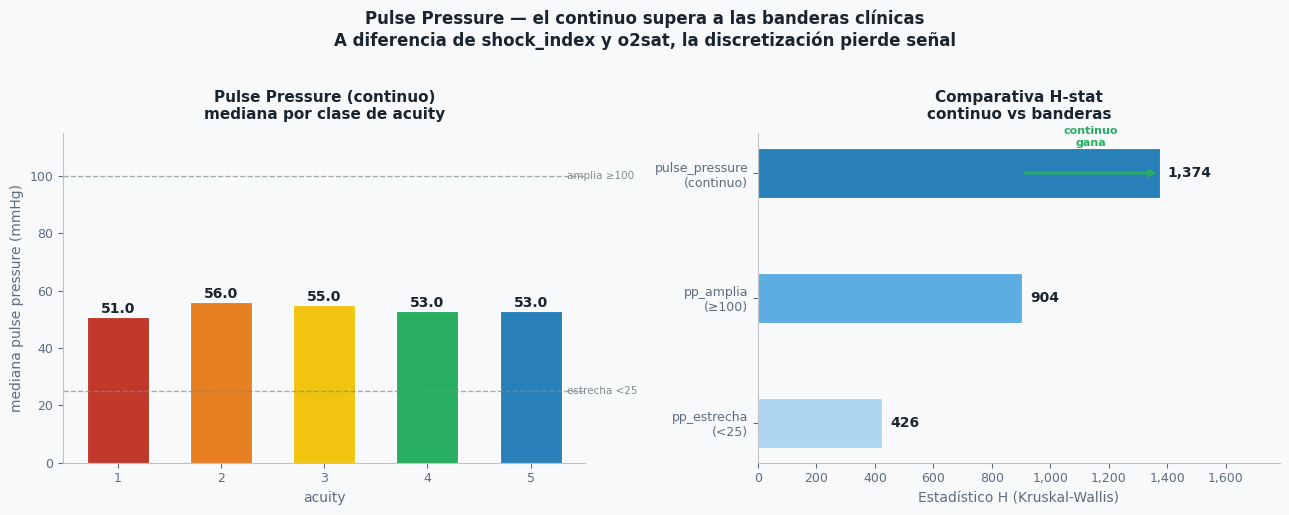

In [219]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor("#F8F9FA")

# Izquierda: mediana pulse_pressure por acuity
ax1 = axes[0]
ax1.set_facecolor("#F8F9FA")
medianas = df.groupby(TARGET)["pulse_pressure"].median().round(1).values
bars = ax1.bar(ACUITY_LEVELS, medianas, color=PALETA_ACUITY,
               edgecolor="white", linewidth=0.8, width=0.6)
for bar, val in zip(bars, medianas):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             f"{val:.1f}", ha="center", va="bottom",
             fontsize=10, fontweight="bold", color="#1A252F")

for umbral, label in [(25, "estrecha <25"), (100, "amplia ≥100")]:
    ax1.axhline(umbral, color="#7F8C8D", linewidth=1, linestyle="--", alpha=0.7)
    ax1.text(5.35, umbral, label, fontsize=7.5, color="#7F8C8D", va="center")

ax1.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
ax1.set_ylabel("mediana pulse pressure (mmHg)", fontsize=10, color="#5D6D7E")
ax1.set_title("Pulse Pressure (continuo)\nmediana por clase de acuity",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax1.spines[["top", "right"]].set_visible(False)
ax1.spines[["left", "bottom"]].set_color("#BDC3C7")
ax1.tick_params(colors="#5D6D7E", labelsize=9)
ax1.set_xticks(ACUITY_LEVELS)
ax1.set_ylim(0, max(115, max(medianas) * 1.2))

# Derecha: comparativa H-stat
ax2 = axes[1]
ax2.set_facecolor("#F8F9FA")

features_lbl = ["pp_estrecha\n(<25)", "pp_amplia\n(≥100)", "pulse_pressure\n(continuo)"]
hstats = [
    resultados_pp["pp_estrecha"]["H"],
    resultados_pp["pp_amplia"]["H"],
    resultados_pp["pulse_pressure"]["H"],
]
cols_h = ["#AED6F1", "#5DADE2", "#2980B9"]

bars2 = ax2.barh(features_lbl, hstats, color=cols_h,
                 edgecolor="white", linewidth=0.8, height=0.4)
for bar, val in zip(bars2, hstats):
    ax2.text(bar.get_width() + max(hstats) * 0.02,
             bar.get_y() + bar.get_height() / 2,
             f"{val:,.0f}", va="center", ha="left",
             fontsize=10, fontweight="bold", color="#1A252F")

ax2.annotate("", xy=(hstats[2], 2), xytext=(hstats[1], 2),
             arrowprops=dict(arrowstyle="->", color="#27AE60", lw=2))
ax2.text((hstats[1] + hstats[2]) / 2, 2.22,
         "continuo\ngana", fontsize=8,
         fontweight="bold", color="#27AE60", ha="center")

ax2.set_xlabel("Estadístico H (Kruskal-Wallis)", fontsize=10, color="#5D6D7E")
ax2.set_title("Comparativa H-stat\ncontinuo vs banderas",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax2.set_xlim(0, max(hstats) * 1.3)
ax2.spines[["top", "right"]].set_visible(False)
ax2.spines[["left", "bottom"]].set_color("#BDC3C7")
ax2.tick_params(colors="#5D6D7E", labelsize=9)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

fig.suptitle(
    "Pulse Pressure — el continuo supera a las banderas clínicas\n"
    "A diferencia de shock_index y o2sat, la discretización pierde señal",
    fontsize=12, fontweight="bold", color="#1A252F", y=1.02,
)

plt.tight_layout()
plt.show()


In [220]:
display(Markdown(f"""
`pulse_pressure` continuo (**H={resultados_pp["pulse_pressure"]["H"]:,.0f}**) entra al
modelo: supera a `sbp` y `dbp` individualmente. Las banderas
`pp_estrecha` (H={resultados_pp["pp_estrecha"]["H"]:,.0f}) y
`pp_amplia` (H={resultados_pp["pp_amplia"]["H"]:,.0f}) tienen justificación clínica
sólida pero **degradan la señal** respecto al continuo. A diferencia de `shock_index`
o `o2sat`, aquí la discretización pierde información — XGBoost puede aprender los
umbrales relevantes directamente del valor numérico. **Las banderas se descartan.**
"""))



`pulse_pressure` continuo (**H=1,374**) entra al
modelo: supera a `sbp` y `dbp` individualmente. Las banderas
`pp_estrecha` (H=426) y
`pp_amplia` (H=904) tienen justificación clínica
sólida pero **degradan la señal** respecto al continuo. A diferencia de `shock_index`
o `o2sat`, aquí la discretización pierde información — XGBoost puede aprender los
umbrales relevantes directamente del valor numérico. **Las banderas se descartan.**


In [221]:
# ─────────────────────────────────────────────────────────────────────────────
# COMPARATIVA: NEWS2 y qSOFA — tres variantes del componente AMS
# ─────────────────────────────────────────────────────────────────────────────
# Variante A — pain_missing (proxy original):
#   pain no registrado → consciencia alterada. Metodológicamente débil
#   pero reproducida aquí para auditoría y trazabilidad.
# Variante B — regex AMS estricto sobre chiefcomplaint:
#   solo términos que documentan consciencia disminuida global.
# Variante C — sin componente AMS (DECISIÓN ADOPTADA):
#   score 100% fisiológico. Limitación del dataset documentada.
#
# JUSTIFICACIÓN: MIMIC-IV-ED no registra GCS ni escala AVPU de forma
# estructurada en triaje. Ningún proxy disponible es suficientemente
# fiable. El componente neurológico queda capturado en cc_neuro_ams
# (Bloque 5), permitiendo al modelo aprenderlo de forma independiente.
# ─────────────────────────────────────────────────────────────────────────────

_AMS_REGEX = (
    r"\baltered\s*mental\s*status\b|\bams\b|\bconfusion\b|\bconfused\b"
    r"|\bunresponsive\b|\bunresponsiveness\b|\bloss\s*of\s*consciousness\b"
    r"|\bloc\b|\bobtunded\b|\blethargic\b|\bnot\s*alert\b"
)
_ams_cc  = df["chiefcomplaint"].fillna("").str.contains(_AMS_REGEX, case=False, regex=True).astype(int).values
_ams_pm  = df["pain_missing"].values
_ams_off = np.zeros(len(df), dtype=int)

rr   = df["resprate"].values
o2   = df["o2sat"].values
sbp  = df["sbp"].values
hr   = df["heartrate"].values
temp = df["temperature"].values


def _news2_base(rr, o2, sbp, hr, temp):
    s = np.zeros(len(rr))
    s += np.select([np.isnan(rr),   rr   <= 8,  rr   <= 11, rr   <= 20, rr   <= 24], [0,3,1,0,2], default=3)
    s += np.select([np.isnan(o2),   o2   <= 91, o2   <= 93, o2   <= 95],              [0,3,2,1],   default=0)
    s += np.select([np.isnan(sbp),  sbp  <= 90, sbp  <= 100,sbp  <= 110,sbp  <= 219],[0,3,2,1,0], default=3)
    s += np.select([np.isnan(hr),   hr   <= 40, hr   <= 50, hr   <= 90, hr   <= 110, hr <= 130],[0,3,1,0,1,2], default=3)
    s += np.select([np.isnan(temp), temp <= 95.0,temp<= 96.8,temp<=100.4,temp<=102.2],[0,3,1,0,1], default=2)
    return s

_base = _news2_base(rr, o2, sbp, hr, temp)

df["news2_pm"]      = _base + np.where(_ams_pm  == 1, 3, 0)
df["news2_cc"]      = _base + np.where(_ams_cc  == 1, 3, 0)
df["news2_vitales"] = _base.copy()

df["news2_pm_alto"]      = (df["news2_pm"]      >= 7).astype("int8")
df["news2_cc_alto"]      = (df["news2_cc"]      >= 7).astype("int8")
df["news2_vitales_alto"] = (df["news2_vitales"] >= 7).astype("int8")


def _qsofa(rr, sbp, ams):
    s = np.zeros(len(rr))
    s += np.where(~np.isnan(rr)  & (rr  >= 22),  1, 0)
    s += np.where(~np.isnan(sbp) & (sbp <= 100), 1, 0)
    s += np.where(ams == 1, 1, 0)
    return s.astype("int8")

df["qsofa_pm"]      = _qsofa(rr, sbp, _ams_pm)
df["qsofa_cc"]      = _qsofa(rr, sbp, _ams_cc)
df["qsofa_vitales"] = _qsofa(rr, sbp, _ams_off)

df["qsofa_pm_pos"]      = (df["qsofa_pm"]      >= 2).astype("int8")
df["qsofa_cc_pos"]      = (df["qsofa_cc"]      >= 2).astype("int8")
df["qsofa_vitales_pos"] = (df["qsofa_vitales"] >= 2).astype("int8")

# ── Tabla comparativa ─────────────────────────────────────────────────────────
print(f"{'Variante':<28} {'AMS':<12} {'H-stat':>8}  {'p-value':>12}")
print("─" * 65)
_cols_comp = [
    ("news2_pm",           "pain_miss"),
    ("news2_cc",           "regex cc"),
    ("news2_vitales",      "sin AMS"),
    ("news2_pm_alto",      "pain_miss"),
    ("news2_cc_alto",      "regex cc"),
    ("news2_vitales_alto", "sin AMS"),
    ("qsofa_pm",           "pain_miss"),
    ("qsofa_cc",           "regex cc"),
    ("qsofa_vitales",      "sin AMS"),
    ("qsofa_pm_pos",       "pain_miss"),
    ("qsofa_cc_pos",       "regex cc"),
    ("qsofa_vitales_pos",  "sin AMS"),
]
for col, ams_label in _cols_comp:
    stat, pval = kw_por_acuity(df[col], df[TARGET])
    print(f"{col:<28} {ams_label:<12} {stat:>8,.0f}  {pval:>12.2e}")

print(f"\n── Medianas NEWS2 por acuity ──────────────────────────────────")
print(df.groupby(TARGET)[["news2_pm","news2_cc","news2_vitales"]].median().to_string())

print(f"\n── % qSOFA positivo por acuity ────────────────────────────────")
print((df.groupby(TARGET)[["qsofa_pm_pos","qsofa_cc_pos","qsofa_vitales_pos"]].mean() * 100).round(2).to_string())

print(f"\nAMS pain_missing : {_ams_pm.mean()*100:.2f}%  n={_ams_pm.sum():,}")
print(f"AMS regex cc     : {_ams_cc.mean()*100:.2f}%  n={_ams_cc.sum():,}")

# ── Variante C adoptada — normalización de variables canónicas ────────────────
df["news2"]          = df["news2_vitales"].copy()
df["news2_alto"]     = df["news2_vitales_alto"].copy()
df["qsofa"]          = df["qsofa_vitales"].copy()
df["qsofa_positivo"] = df["qsofa_vitales_pos"].copy()

df.drop(columns=[
    "news2_pm", "news2_cc", "news2_vitales",
    "news2_pm_alto", "news2_cc_alto", "news2_vitales_alto",
    "qsofa_pm", "qsofa_cc", "qsofa_vitales",
    "qsofa_pm_pos", "qsofa_cc_pos", "qsofa_vitales_pos",
], inplace=True)

# ── Métricas de las variables canónicas + actualización JSON ──────────────────
H_news2,      pval_news2      = kw_por_acuity(df["news2"],      df[TARGET])
H_news2_alto, pval_news2_alto = kw_por_acuity(df["news2_alto"], df[TARGET])
pcts_news2_alto = pcts_por_acuity(df["news2_alto"], df[TARGET])
prev_news2_alto = float(df["news2_alto"].mean() * 100)
n_news2_alto    = int(df["news2_alto"].sum())

update_metrics_json("news2",      H=round(H_news2,      4))
update_metrics_json("news2_alto", H=round(H_news2_alto, 4))

resultados_qsofa = {}
for col in ["qsofa", "qsofa_positivo"]:
    H, pval = kw_por_acuity(df[col], df[TARGET])
    prev = float(df[col].mean() * 100)
    n    = int(df[col].sum())
    resultados_qsofa[col] = {"H": H, "prev": prev, "n": n,
                              "pcts": pcts_por_acuity(df[col], df[TARGET])}
    update_metrics_json(col, H=round(H, 4))

print(f"\n── Métricas finales adoptadas (Variante C — sin AMS) ───────────")
print(f"news2           H = {H_news2:,.0f}  |  p = {pval_news2:.2e}")
print(f"news2_alto      H = {H_news2_alto:,.0f}  |  prev = {prev_news2_alto:.2f}%  n = {n_news2_alto:,}")
print(f"qsofa           H = {resultados_qsofa['qsofa']['H']:,.0f}  |  prev = {resultados_qsofa['qsofa']['prev']:.2f}%")
print(f"qsofa_positivo  H = {resultados_qsofa['qsofa_positivo']['H']:,.0f}  |  prev = {resultados_qsofa['qsofa_positivo']['prev']:.2f}%")


Variante                     AMS            H-stat       p-value
─────────────────────────────────────────────────────────────────
news2_pm                     pain_miss      35,887      0.00e+00
news2_cc                     regex cc       16,559      0.00e+00
news2_vitales                sin AMS        11,499      0.00e+00
news2_pm_alto                pain_miss      19,504      0.00e+00
news2_cc_alto                regex cc       11,089      0.00e+00
news2_vitales_alto           sin AMS         9,663      0.00e+00
qsofa_pm                     pain_miss      50,721      0.00e+00
qsofa_cc                     regex cc       26,585      0.00e+00
qsofa_vitales                sin AMS        18,075      0.00e+00
qsofa_pm_pos                 pain_miss      13,936      0.00e+00
qsofa_cc_pos                 regex cc        4,985      0.00e+00
qsofa_vitales_pos            sin AMS         2,740      0.00e+00

── Medianas NEWS2 por acuity ──────────────────────────────────
        news2_pm  news2_

In [222]:
# Estadísticas de distribución NEWS2 — Variante C (sin AMS)
# Las variables news2, news2_alto y sus métricas ya están computadas en la celda anterior.

print(f"{'Feature':<20} {'H-stat':>8}  {'p-value':>12}  {'Prevalencia':>12}  {'n casos':>8}")
print("─" * 70)
print(f"{'news2 (continuo)':<20} {H_news2:>8,.0f}  {pval_news2:>12.2e}  {'---':>12}  {'---':>8}")
print(f"{'news2_alto (≥7)':<20} {H_news2_alto:>8,.0f}  {pval_news2_alto:>12.2e}  {prev_news2_alto:>11.2f}%  {n_news2_alto:>8,}")

print(f"\nDistribución por umbrales de riesgo NEWS2 (Variante C — sin AMS):\n")
umbrales_news2 = {
    "NEWS2 0-2  (bajo riesgo)":     float((df["news2"] <= 2).mean() * 100),
    "NEWS2 3-4  (riesgo moderado)": float(((df["news2"] >= 3) & (df["news2"] <= 4)).mean() * 100),
    "NEWS2 5-6  (riesgo alto)":     float(((df["news2"] >= 5) & (df["news2"] <= 6)).mean() * 100),
    "NEWS2 >= 7 (riesgo muy alto)": float((df["news2"] >= 7).mean() * 100),
}
for k, v in umbrales_news2.items():
    print(f"  {k}:  {v:.2f}%")

print(f"\n% news2_alto por clase de acuity:\n")
print((df.groupby(TARGET)["news2_alto"].mean() * 100).round(2).to_string())


Feature                H-stat       p-value   Prevalencia   n casos
──────────────────────────────────────────────────────────────────────
news2 (continuo)       11,499      0.00e+00           ---       ---
news2_alto (≥7)         9,663      0.00e+00         0.41%     1,717

Distribución por umbrales de riesgo NEWS2 (Variante C — sin AMS):

  NEWS2 0-2  (bajo riesgo):  90.29%
  NEWS2 3-4  (riesgo moderado):  7.71%
  NEWS2 5-6  (riesgo alto):  1.60%
  NEWS2 >= 7 (riesgo muy alto):  0.41%

% news2_alto por clase de acuity:

acuity
1    4.26
2    0.46
3    0.02
4    0.00
5    0.00


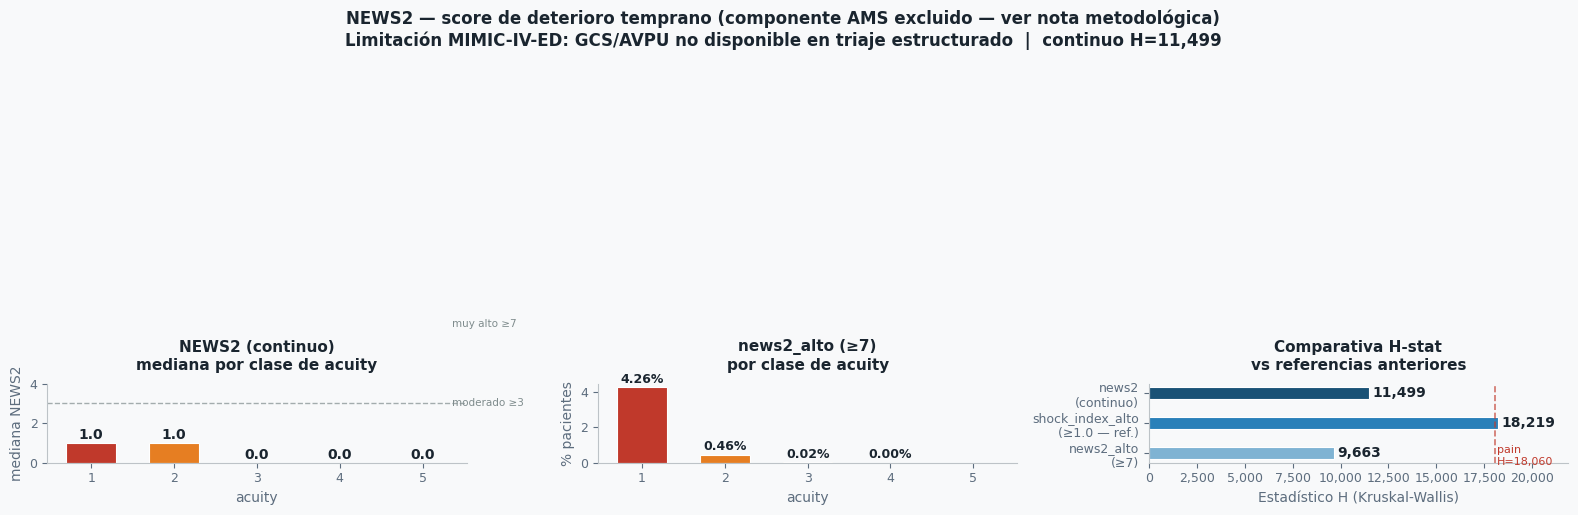

In [223]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor("#F8F9FA")

# Panel 1 — mediana NEWS2 por acuity
ax1 = axes[0]
ax1.set_facecolor("#F8F9FA")
medianas = df.groupby(TARGET)["news2"].median().values
bars = ax1.bar(ACUITY_LEVELS, medianas, color=PALETA_ACUITY,
               edgecolor="white", linewidth=0.8, width=0.6)
for bar, val in zip(bars, medianas):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
             f"{val:.1f}", ha="center", va="bottom",
             fontsize=10, fontweight="bold", color="#1A252F")

for umbral, label in [(3, "moderado ≥3"), (7, "muy alto ≥7")]:
    ax1.axhline(umbral, color="#7F8C8D", linewidth=1, linestyle="--", alpha=0.7)
    ax1.text(5.35, umbral, label, fontsize=7.5, color="#7F8C8D", va="center")

ax1.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
ax1.set_ylabel("mediana NEWS2", fontsize=10, color="#5D6D7E")
ax1.set_title("NEWS2 (continuo)\nmediana por clase de acuity",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax1.spines[["top", "right"]].set_visible(False)
ax1.spines[["left", "bottom"]].set_color("#BDC3C7")
ax1.tick_params(colors="#5D6D7E", labelsize=9)
ax1.set_xticks(ACUITY_LEVELS)
ax1.set_ylim(0, max(4, max(medianas) * 1.5 + 1))

# Panel 2 — news2_alto (≥7) por acuity
ax2 = axes[1]
ax2.set_facecolor("#F8F9FA")
bars2 = ax2.bar(ACUITY_LEVELS, pcts_news2_alto, color=PALETA_ACUITY,
                edgecolor="white", linewidth=0.8, width=0.6)
for bar, val in zip(bars2, pcts_news2_alto):
    if val > 0:
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                 f"{val:.2f}%", ha="center", va="bottom",
                 fontsize=9, fontweight="bold", color="#1A252F")

ax2.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
ax2.set_ylabel("% pacientes", fontsize=10, color="#5D6D7E")
ax2.set_title("news2_alto (≥7)\npor clase de acuity",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax2.spines[["top", "right"]].set_visible(False)
ax2.spines[["left", "bottom"]].set_color("#BDC3C7")
ax2.tick_params(colors="#5D6D7E", labelsize=9)
ax2.set_xticks(ACUITY_LEVELS)

# Panel 3 — comparativa H-stat
ax3 = axes[2]
ax3.set_facecolor("#F8F9FA")

features_lbl = [
    "news2_alto\n(≥7)",
    "shock_index_alto\n(≥1.0 — ref.)",
    "news2\n(continuo)",
]
hstats = [H_news2_alto, resultados_si["shock_index_alto"]["H"], H_news2]
cols_h = ["#7FB3D3", "#2980B9", "#1A5276"]

bars3 = ax3.barh(features_lbl, hstats, color=cols_h,
                 edgecolor="white", linewidth=0.8, height=0.4)
for bar, val in zip(bars3, hstats):
    ax3.text(bar.get_width() + max(hstats) * 0.01,
             bar.get_y() + bar.get_height() / 2,
             f"{val:,.0f}", va="center", ha="left",
             fontsize=10, fontweight="bold", color="#1A252F")

ax3.axvline(x=H_pain_ref, color="#C0392B", linewidth=1.2, linestyle="--", alpha=0.7)
ax3.text(H_pain_ref + max(hstats) * 0.005, -0.45,
         f"pain\nH={H_pain_ref:,.0f}", color="#C0392B",
         fontsize=8, va="bottom")

ax3.set_xlabel("Estadístico H (Kruskal-Wallis)", fontsize=10, color="#5D6D7E")
ax3.set_title("Comparativa H-stat\nvs referencias anteriores",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax3.set_xlim(0, max(max(hstats), H_pain_ref) * 1.2)
ax3.spines[["top", "right"]].set_visible(False)
ax3.spines[["left", "bottom"]].set_color("#BDC3C7")
ax3.tick_params(colors="#5D6D7E", labelsize=9)
ax3.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

fig.suptitle(
    f"NEWS2 — score de deterioro temprano (componente AMS excluido — ver nota metodológica)\n"
    f"Limitación MIMIC-IV-ED: GCS/AVPU no disponible en triaje estructurado  |  continuo H={H_news2:,.0f}",
    fontsize=12, fontweight="bold", color="#1A252F", y=1.02,
)

plt.tight_layout()
plt.show()


In [224]:
display(Markdown(f"""
**NEWS2 — Entra al modelo (continuo + bandera). Componente AMS excluido por limitación del dataset.**

`news2` continuo (**H={H_news2:,.0f}**) captura la síntesis fisiológica de los 5 vitales
medidos directamente (resprate, o2sat, sbp, heartrate, temperature). El componente de
consciencia (ACVPU) se omite porque MIMIC-IV-ED no registra GCS ni escala AVPU en triaje;
los proxies evaluados (pain_missing, regex AMS) introducen sesgos más graves que su
exclusión. La dimensión neurológica queda cubierta por `cc_neuro_ams` (Bloque 5).

El gradiente de medianas es correcto: `acuity` 1 mediana
{df.groupby(TARGET)["news2"].median()[1]:.0f}, `acuity` 4-5 en cero. Supera a `resprate`
aislado (**H={H_resprate_continuo:,.0f}**) — el score capta sinergia que ningún vital individual puede ver.

`news2_alto` (≥7) complementa al continuo (H={H_news2_alto:,.0f}, prevalencia
{prev_news2_alto:.2f}%, {pcts_news2_alto[0]:.2f}% en `acuity` 1). Ambas variables entran al modelo.
"""))



**NEWS2 — Entra al modelo (continuo + bandera). Componente AMS excluido por limitación del dataset.**

`news2` continuo (**H=11,499**) captura la síntesis fisiológica de los 5 vitales
medidos directamente (resprate, o2sat, sbp, heartrate, temperature). El componente de
consciencia (ACVPU) se omite porque MIMIC-IV-ED no registra GCS ni escala AVPU en triaje;
los proxies evaluados (pain_missing, regex AMS) introducen sesgos más graves que su
exclusión. La dimensión neurológica queda cubierta por `cc_neuro_ams` (Bloque 5).

El gradiente de medianas es correcto: `acuity` 1 mediana
1, `acuity` 4-5 en cero. Supera a `resprate`
aislado (**H=7,055**) — el score capta sinergia que ningún vital individual puede ver.

`news2_alto` (≥7) complementa al continuo (H=9,663, prevalencia
0.41%, 4.26% en `acuity` 1). Ambas variables entran al modelo.


In [225]:
# qSOFA — Sepsis-3 International Consensus, 2016. Componente AMS excluido.
# Componentes activos: resprate ≥22 rpm | sbp ≤100 mmHg (máx. teórico = 2).
# GCS/AVPU no disponible en MIMIC-IV-ED — ver nota metodológica en celda anterior.
# Cálculo y normalización ya realizados. Esta celda imprime las estadísticas finales.

print(f"{'Feature':<22} {'H-stat':>8}  {'p-value':>12}  {'Prevalencia':>12}  {'n casos':>8}")
print("─" * 72)

for col in ["qsofa", "qsofa_positivo"]:
    H    = resultados_qsofa[col]["H"]
    prev = resultados_qsofa[col]["prev"]
    n    = resultados_qsofa[col]["n"]
    _, pval = kw_por_acuity(df[col], df[TARGET])
    print(f"{col:<22} {H:>8,.0f}  {pval:>12.2e}  {prev:>11.2f}%  {n:>8,}")

print(f"\nDistribución qSOFA por valor (0, 1, 2):\n")
print((df["qsofa"].value_counts(normalize=True) * 100).sort_index().round(2).to_string())

print(f"\n% qsofa_positivo (≥2) por clase de acuity:\n")
print((df.groupby(TARGET)["qsofa_positivo"].mean() * 100).round(2).to_string())


Feature                  H-stat       p-value   Prevalencia   n casos
────────────────────────────────────────────────────────────────────────
qsofa                    18,075      0.00e+00         8.30%    34,713
qsofa_positivo            2,740      0.00e+00         0.29%     1,203

Distribución qSOFA por valor (0, 1, 2):

qsofa
0    91.99
1     7.73
2     0.29

% qsofa_positivo (≥2) por clase de acuity:

acuity
1    1.87
2    0.45
3    0.05
4    0.01
5    0.00


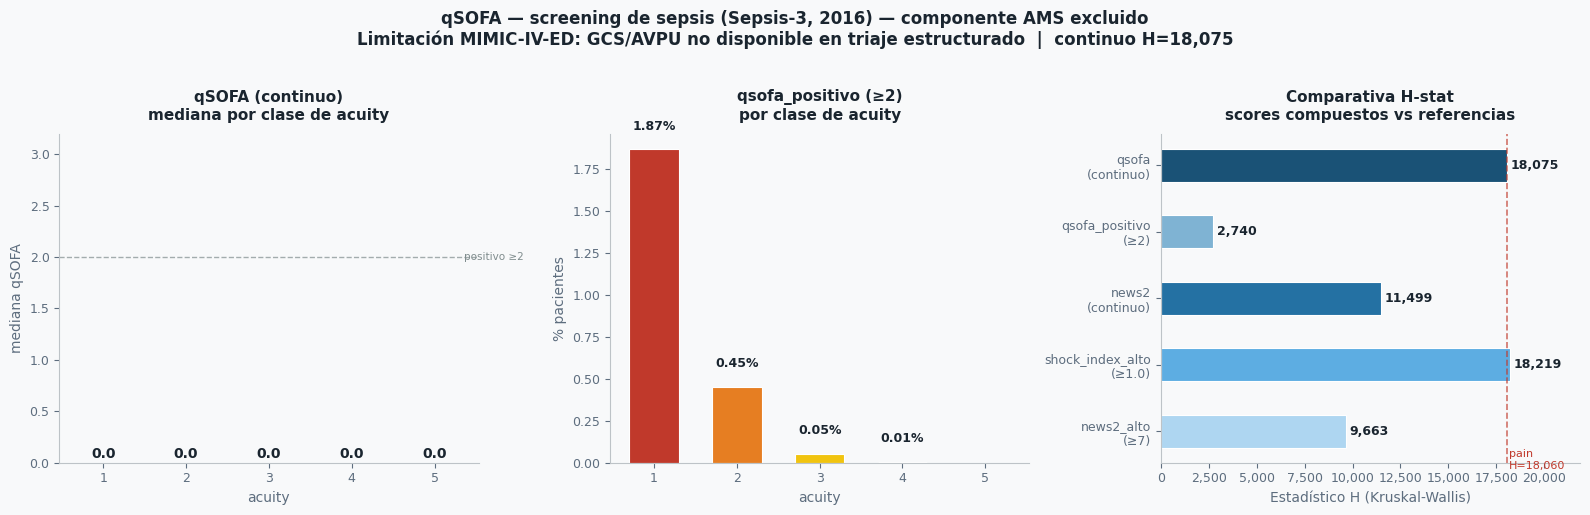

In [226]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor("#F8F9FA")

# Panel 1 — mediana qSOFA por acuity
ax1 = axes[0]
ax1.set_facecolor("#F8F9FA")
medianas = df.groupby(TARGET)["qsofa"].median().values
bars = ax1.bar(ACUITY_LEVELS, medianas, color=PALETA_ACUITY,
               edgecolor="white", linewidth=0.8, width=0.6)
for bar, val in zip(bars, medianas):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
             f"{val:.1f}", ha="center", va="bottom",
             fontsize=10, fontweight="bold", color="#1A252F")

ax1.axhline(2, color="#7F8C8D", linewidth=1, linestyle="--", alpha=0.7)
ax1.text(5.35, 2, "positivo ≥2", fontsize=7.5, color="#7F8C8D", va="center")

ax1.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
ax1.set_ylabel("mediana qSOFA", fontsize=10, color="#5D6D7E")
ax1.set_title("qSOFA (continuo)\nmediana por clase de acuity",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax1.spines[["top", "right"]].set_visible(False)
ax1.spines[["left", "bottom"]].set_color("#BDC3C7")
ax1.tick_params(colors="#5D6D7E", labelsize=9)
ax1.set_xticks(ACUITY_LEVELS)
ax1.set_ylim(0, max(3.2, max(medianas) * 1.5))

# Panel 2 — qsofa_positivo por acuity
ax2 = axes[1]
ax2.set_facecolor("#F8F9FA")
pcts = resultados_qsofa["qsofa_positivo"]["pcts"]
bars2 = ax2.bar(ACUITY_LEVELS, pcts, color=PALETA_ACUITY,
                edgecolor="white", linewidth=0.8, width=0.6)
for bar, val in zip(bars2, pcts):
    if val > 0:
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                 f"{val:.2f}%", ha="center", va="bottom",
                 fontsize=9, fontweight="bold", color="#1A252F")

ax2.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
ax2.set_ylabel("% pacientes", fontsize=10, color="#5D6D7E")
ax2.set_title("qsofa_positivo (≥2)\npor clase de acuity",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax2.spines[["top", "right"]].set_visible(False)
ax2.spines[["left", "bottom"]].set_color("#BDC3C7")
ax2.tick_params(colors="#5D6D7E", labelsize=9)
ax2.set_xticks(ACUITY_LEVELS)

# Panel 3 — comparativa H-stat
ax3 = axes[2]
ax3.set_facecolor("#F8F9FA")

features_lbl = [
    "news2_alto\n(≥7)",
    "shock_index_alto\n(≥1.0)",
    "news2\n(continuo)",
    "qsofa_positivo\n(≥2)",
    "qsofa\n(continuo)",
]
hstats = [
    H_news2_alto,
    resultados_si["shock_index_alto"]["H"],
    H_news2,
    resultados_qsofa["qsofa_positivo"]["H"],
    resultados_qsofa["qsofa"]["H"],
]
cols_h = ["#AED6F1", "#5DADE2", "#2471A3", "#7FB3D3", "#1A5276"]

bars3 = ax3.barh(features_lbl, hstats, color=cols_h,
                 edgecolor="white", linewidth=0.8, height=0.5)
for bar, val in zip(bars3, hstats):
    ax3.text(bar.get_width() + max(hstats) * 0.01,
             bar.get_y() + bar.get_height() / 2,
             f"{val:,.0f}", va="center", ha="left",
             fontsize=9, fontweight="bold", color="#1A252F")

ax3.axvline(x=H_pain_ref, color="#C0392B", linewidth=1.2, linestyle="--", alpha=0.7)
ax3.text(H_pain_ref + max(hstats) * 0.005, -0.6,
         f"pain\nH={H_pain_ref:,.0f}", color="#C0392B",
         fontsize=8, va="bottom")

ax3.set_xlabel("Estadístico H (Kruskal-Wallis)", fontsize=10, color="#5D6D7E")
ax3.set_title("Comparativa H-stat\nscores compuestos vs referencias",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax3.set_xlim(0, max(max(hstats), H_pain_ref) * 1.2)
ax3.spines[["top", "right"]].set_visible(False)
ax3.spines[["left", "bottom"]].set_color("#BDC3C7")
ax3.tick_params(colors="#5D6D7E", labelsize=9)
ax3.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

fig.suptitle(
    f"qSOFA — screening de sepsis (Sepsis-3, 2016) — componente AMS excluido\n"
    f"Limitación MIMIC-IV-ED: GCS/AVPU no disponible en triaje estructurado  |  continuo H={resultados_qsofa['qsofa']['H']:,.0f}",
    fontsize=12, fontweight="bold", color="#1A252F", y=1.02,
)

plt.tight_layout()
plt.show()


In [227]:
H_qsofa     = resultados_qsofa["qsofa"]["H"]
H_qsofa_pos = resultados_qsofa["qsofa_positivo"]["H"]
prev_qsofa0 = float((df["qsofa"] == 0).mean() * 100)

display(Markdown(f"""
**qSOFA — Entra al modelo (continuo + bandera). Componente AMS excluido por limitación del dataset.**

`qsofa` continuo (**H={H_qsofa:,.0f}**) supera a NEWS2 (**H={H_news2:,.0f}**) usando solo
2 componentes fisiológicos (resprate ≥22 y sbp ≤100). El componente de consciencia (GCS<15)
se omite porque MIMIC-IV-ED no registra GCS ni AVPU en triaje; la dimensión neurológica
queda cubierta por `cc_neuro_ams` (Bloque 5), que el modelo puede combinar libremente.

El {prev_qsofa0:.2f}% de los pacientes tienen qSOFA=0 — la escala actúa como detector de
excepciones: cuando se activa, la señal es clínicamente relevante.

`qsofa_positivo` (≥2, H={H_qsofa_pos:,.0f}) equivale a tener ambos criterios fisiológicos
simultáneamente ({resultados_qsofa["qsofa_positivo"]["pcts"][0]:.2f}% en `acuity` 1, caída
brusca a 0% en `acuity` 5). Gradiente perfecto. **Ambas variables entran al modelo.**
"""))



**qSOFA — Entra al modelo (continuo + bandera). Componente AMS excluido por limitación del dataset.**

`qsofa` continuo (**H=18,075**) supera a NEWS2 (**H=11,499**) usando solo
2 componentes fisiológicos (resprate ≥22 y sbp ≤100). El componente de consciencia (GCS<15)
se omite porque MIMIC-IV-ED no registra GCS ni AVPU en triaje; la dimensión neurológica
queda cubierta por `cc_neuro_ams` (Bloque 5), que el modelo puede combinar libremente.

El 91.99% de los pacientes tienen qSOFA=0 — la escala actúa como detector de
excepciones: cuando se activa, la señal es clínicamente relevante.

`qsofa_positivo` (≥2, H=2,740) equivale a tener ambos criterios fisiológicos
simultáneamente (1.87% en `acuity` 1, caída
brusca a 0% en `acuity` 5). Gradiente perfecto. **Ambas variables entran al modelo.**


### Resumen Bloque 1 — vitales y scores


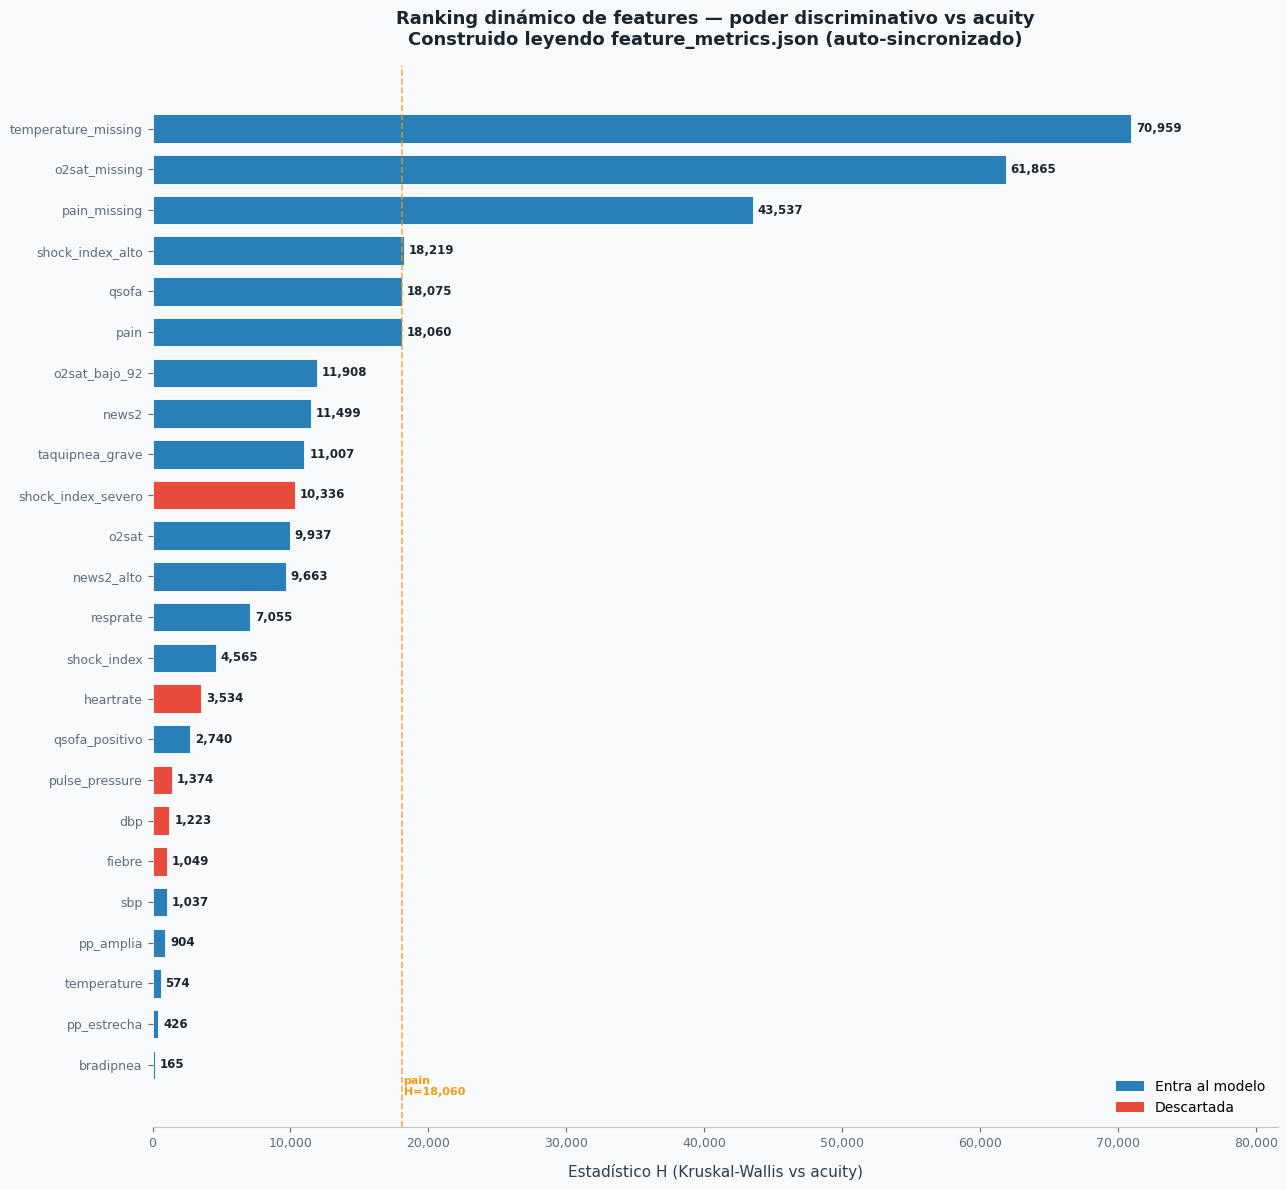


Features actualmente con H persistido: 24
  Entran:      19
  Descartadas: 5


In [228]:
# Resumen comparativo dinámico — leído de feature_metrics.json (NO hardcodeado)
# Cada vez que se calcula un H-stat lo persistimos con update_metrics_json,
# así este bloque siempre refleja el estado actual del pipeline.

GRUPO_FEATURE = {
    # Missingness
    "temperature_missing": "Missingness", "o2sat_missing": "Missingness",
    "pain_missing": "Missingness",
    # Vitales crudos
    "pain": "Vitales crudos", "o2sat": "Vitales crudos",
    "resprate": "Vitales crudos", "heartrate": "Vitales crudos",
    "dbp": "Vitales crudos", "sbp": "Vitales crudos",
    "temperature": "Vitales crudos",
    # Banderas clínicas
    "o2sat_bajo_92": "Banderas clínicas", "fiebre": "Banderas clínicas",
    "taquipnea_grave": "Banderas clínicas", "bradipnea": "Banderas clínicas",
    # Scores
    "qsofa": "Scores", "qsofa_positivo": "Scores",
    "news2": "Scores", "news2_alto": "Scores",
    "shock_index": "Scores", "shock_index_alto": "Scores",
    "shock_index_severo": "Scores", "pulse_pressure": "Scores",
    "pp_estrecha": "Scores", "pp_amplia": "Scores",
}

# Estado por defecto: features registradas en feature_metrics.json se asumen "entra"
# salvo que su decision_final ya esté marcada como "descartada" (lo hace 05b).
metricas = leer_metricas()

filas = []
for feat, info in metricas.items():
    H = info.get("H")
    if H is None or feat not in GRUPO_FEATURE:
        continue
    estado = "descartado" if info.get("decision_final") == "descartada" else "entra"
    filas.append({
        "feature": feat,
        "H":       int(round(H)),
        "grupo":   GRUPO_FEATURE[feat],
        "estado":  estado,
    })

df_resumen = pd.DataFrame(filas).sort_values("H", ascending=True).reset_index(drop=True)

color_map = {"entra": "#2980B9", "descartado": "#E74C3C"}
colores   = [color_map[e] for e in df_resumen["estado"]]

fig, ax = plt.subplots(figsize=(13, 12))
fig.patch.set_facecolor("#F8F9FA")
ax.set_facecolor("#F8F9FA")

bars = ax.barh(df_resumen["feature"], df_resumen["H"],
               color=colores, edgecolor="white", linewidth=0.6, height=0.7)

for bar, val in zip(bars, df_resumen["H"]):
    ax.text(bar.get_width() + max(df_resumen["H"]) * 0.005,
            bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va="center", ha="left",
            fontsize=8.5, fontweight="bold", color="#1A252F")

H_pain_ref_ = metricas.get("pain", {}).get("H", 0) or 0
ax.axvline(x=H_pain_ref_, color="#F39C12", linewidth=1.2, linestyle="--", alpha=0.8)
ax.text(H_pain_ref_ + max(df_resumen["H"]) * 0.002, -0.8,
        f"pain\nH={H_pain_ref_:,.0f}", color="#F39C12",
        fontsize=8, va="bottom", fontweight="bold")

ax.set_xlabel("Estadístico H (Kruskal-Wallis vs acuity)", fontsize=11, color="#2C3E50", labelpad=10)
ax.set_title(
    "Ranking dinámico de features — poder discriminativo vs acuity\n"
    "Construido leyendo feature_metrics.json (auto-sincronizado)",
    fontsize=13, fontweight="bold", color="#1A252F", pad=15,
)

leyenda = [
    mpatches.Patch(facecolor="#2980B9", label="Entra al modelo"),
    mpatches.Patch(facecolor="#E74C3C", label="Descartada"),
]
ax.legend(handles=leyenda, loc="lower right", frameon=False, fontsize=10)

ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color("#BDC3C7")
ax.tick_params(axis="both", colors="#5D6D7E", labelsize=9)
ax.set_xlim(0, max(df_resumen["H"]) * 1.15)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.show()

print(f"\nFeatures actualmente con H persistido: {len(df_resumen)}")
print(f"  Entran:      {(df_resumen['estado'] == 'entra').sum()}")
print(f"  Descartadas: {(df_resumen['estado'] == 'descartado').sum()}")


In [229]:
# Bandera clínica: zona_verde — Estabilidad Fisiológica SET
# Sistema Español de Triaje: estabilidad fisiológica total → acuity 4/5
# NaN en cualquier vital → False (criterio conservador correcto)

df["zona_verde"] = (
    (df["heartrate"].between(60, 100))   &  # FC normal
    (df["resprate"].between(12, 20))     &  # FR normal
    (df["o2sat"] >= 95)                  &  # Saturación normal
    (df["sbp"].between(100, 140))        &  # TAS normal
    (df["temperature"].between(96.8, 99.5)) & # Temp normal (°F: 36.1-37.5°C)
    (df["pain_missing"] == 0)               # Consciente y alerta
).astype("int8")

H_zv, pval_zv = kw_por_acuity(df["zona_verde"], df[TARGET])
prev_zv = float(df["zona_verde"].mean() * 100)
n_zv    = int(df["zona_verde"].sum())
pcts_zv = pcts_por_acuity(df["zona_verde"], df[TARGET])

update_metrics_json("zona_verde", H=round(H_zv, 4))

print(f"zona_verde  →  H = {H_zv:,.0f}  |  p = {pval_zv:.2e}  |  prevalencia = {prev_zv:.2f}%  |  n = {n_zv:,}\n")
print("% zona_verde por clase de acuity:\n")
print((df.groupby(TARGET)["zona_verde"].mean() * 100).round(2).to_string())


zona_verde  →  H = 14,389  |  p = 0.00e+00  |  prevalencia = 36.60%  |  n = 153,044

% zona_verde por clase de acuity:

acuity
1     8.45
2    31.29
3    41.03
4    50.75
5    52.91


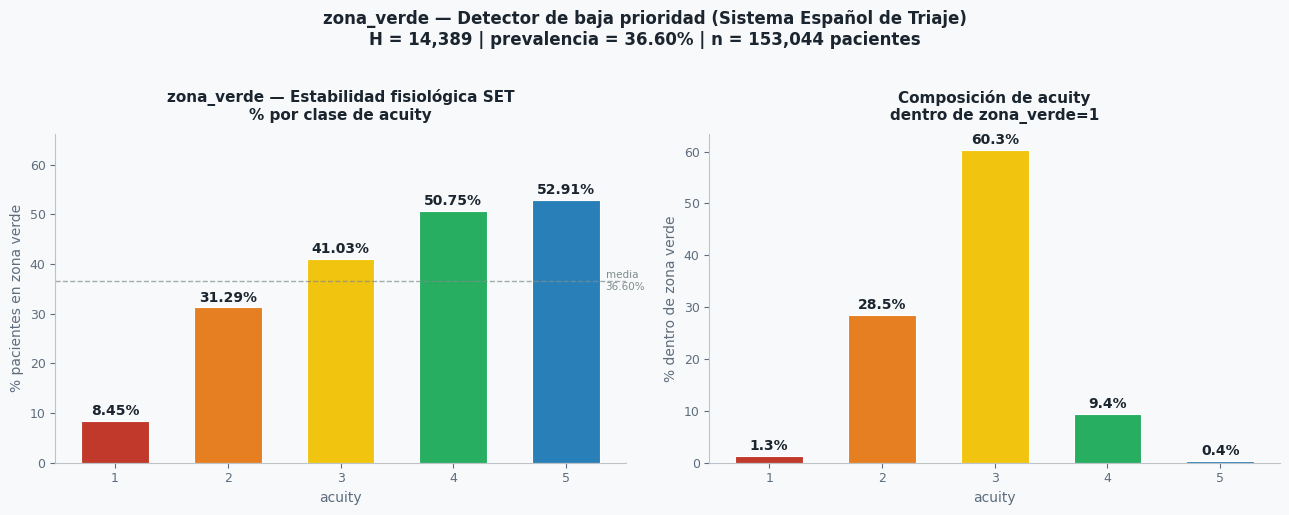

In [230]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor("#F8F9FA")

ax1 = axes[0]
ax1.set_facecolor("#F8F9FA")
bars = ax1.bar(ACUITY_LEVELS, pcts_zv, color=PALETA_ACUITY,
               edgecolor="white", linewidth=0.8, width=0.6)
for bar, val in zip(bars, pcts_zv):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f"{val:.2f}%", ha="center", va="bottom",
             fontsize=10, fontweight="bold", color="#1A252F")

ax1.axhline(prev_zv, color="#7F8C8D", linewidth=1, linestyle="--", alpha=0.7)
ax1.text(5.35, prev_zv, f"media\n{prev_zv:.2f}%", fontsize=7.5,
         color="#7F8C8D", va="center")

ax1.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
ax1.set_ylabel("% pacientes en zona verde", fontsize=10, color="#5D6D7E")
ax1.set_title("zona_verde — Estabilidad fisiológica SET\n% por clase de acuity",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax1.spines[["top", "right"]].set_visible(False)
ax1.spines[["left", "bottom"]].set_color("#BDC3C7")
ax1.tick_params(colors="#5D6D7E", labelsize=9)
ax1.set_xticks(ACUITY_LEVELS)
ax1.set_ylim(0, max(pcts_zv) * 1.25)

# Distribución de acuity dentro de zona_verde
ax2 = axes[1]
ax2.set_facecolor("#F8F9FA")
dist_dentro = (
    df[df["zona_verde"] == 1][TARGET]
    .value_counts(normalize=True)
    .sort_index() * 100
).round(2)

bars2 = ax2.bar(dist_dentro.index, dist_dentro.values, color=PALETA_ACUITY,
                edgecolor="white", linewidth=0.8, width=0.6)
for bar, val in zip(bars2, dist_dentro.values):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f"{val:.1f}%", ha="center", va="bottom",
             fontsize=10, fontweight="bold", color="#1A252F")

ax2.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
ax2.set_ylabel("% dentro de zona verde", fontsize=10, color="#5D6D7E")
ax2.set_title("Composición de acuity\ndentro de zona_verde=1",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax2.spines[["top", "right"]].set_visible(False)
ax2.spines[["left", "bottom"]].set_color("#BDC3C7")
ax2.tick_params(colors="#5D6D7E", labelsize=9)
ax2.set_xticks(ACUITY_LEVELS)

fig.suptitle(
    f"zona_verde — Detector de baja prioridad (Sistema Español de Triaje)\n"
    f"H = {H_zv:,.0f} | prevalencia = {prev_zv:.2f}% | n = {n_zv:,} pacientes",
    fontsize=12, fontweight="bold", color="#1A252F", y=1.02,
)

plt.tight_layout()
plt.show()


In [231]:
display(Markdown(f"""
`zona_verde` (**H={H_zv:,.0f}**) es el mejor detector de baja prioridad del dataset y el
único score diseñado específicamente para identificar `acuity` 4-5. Con prevalencia del
{prev_zv:.2f}%, más de 1 de cada 3 pacientes cumple criterios de estabilidad fisiológica
total. Patrón progresivo: {pcts_zv[0]:.2f}% en `acuity` 1 → {pcts_zv[4]:.2f}% en
`acuity` 5.

Hallazgo clave: el {pcts_zv[1]:.2f}% de los `acuity` 2 están en zona verde — casi 1 de
cada 3 emergencias tiene los vitales completamente normales en T=0. Esto demuestra
empíricamente que los vitales solos son insuficientes para el triaje y justifica las
features de medicación, chief complaint e historial. **Entra al modelo.**
"""))



`zona_verde` (**H=14,389**) es el mejor detector de baja prioridad del dataset y el
único score diseñado específicamente para identificar `acuity` 4-5. Con prevalencia del
36.60%, más de 1 de cada 3 pacientes cumple criterios de estabilidad fisiológica
total. Patrón progresivo: 8.45% en `acuity` 1 → 52.91% en
`acuity` 5.

Hallazgo clave: el 31.29% de los `acuity` 2 están en zona verde — casi 1 de
cada 3 emergencias tiene los vitales completamente normales en T=0. Esto demuestra
empíricamente que los vitales solos son insuficientes para el triaje y justifica las
features de medicación, chief complaint e historial. **Entra al modelo.**


In [232]:
# Criterios SIRS Clínicos — Screening de Sepsis
# Más sensible que qSOFA (atrapa más casos) pero menos específico
# Requiere ≥ 2 criterios de los 3 disponibles en T=0:
#   - Temperatura > 38°C (100.4°F) o < 36°C (96.8°F)
#   - Frecuencia cardíaca > 90 lpm
#   - Frecuencia respiratoria > 20 rpm

sirs_temp = ((df["temperature"] >= 100.4) | (df["temperature"] <= 96.8)).astype(int)
sirs_hr   = (df["heartrate"] > 90).astype(int)
sirs_rr   = (df["resprate"]  > 20).astype(int)

sirs_temp = sirs_temp.fillna(0)
sirs_hr   = sirs_hr.fillna(0)
sirs_rr   = sirs_rr.fillna(0)

df["sirs_score"]    = (sirs_temp + sirs_hr + sirs_rr).astype("int8")
df["sirs_positivo"] = (df["sirs_score"] >= 2).astype("int8")

resultados_sirs = {}

print(f"{'Feature':<20} {'H-stat':>8}  {'p-value':>12}  {'Prevalencia':>12}  {'n casos':>8}")
print("─" * 70)

for col in ["sirs_score", "sirs_positivo"]:
    H, pval = kw_por_acuity(df[col], df[TARGET])
    prev = float(df[col].mean() * 100)
    n    = int(df[col].sum())
    resultados_sirs[col] = {"H": H, "prev": prev, "n": n,
                             "pcts": pcts_por_acuity(df[col], df[TARGET])}
    update_metrics_json(col, H=round(H, 4))
    print(f"{col:<20} {H:>8,.0f}  {pval:>12.2e}  {prev:>11.2f}%  {n:>8,}")

print(f"\nDistribución sirs_score (0-3):\n")
print((df["sirs_score"].value_counts(normalize=True).sort_index() * 100).round(2).to_string())

print(f"\n% sirs_positivo por clase de acuity:\n")
print((df.groupby(TARGET)["sirs_positivo"].mean() * 100).round(2).to_string())
update_metrics_json('sirs_score', H=round(float(H), 4), tipo='continua')


Feature                H-stat       p-value   Prevalencia   n casos
──────────────────────────────────────────────────────────────────────
sirs_score              2,723      0.00e+00        46.00%   192,342
sirs_positivo           5,188      0.00e+00         5.97%    24,965

Distribución sirs_score (0-3):

sirs_score
0    60.36
1    33.67
2     5.58
3     0.39

% sirs_positivo por clase de acuity:

acuity
1    13.55
2     7.99
3     4.40
4     2.26
5     2.55


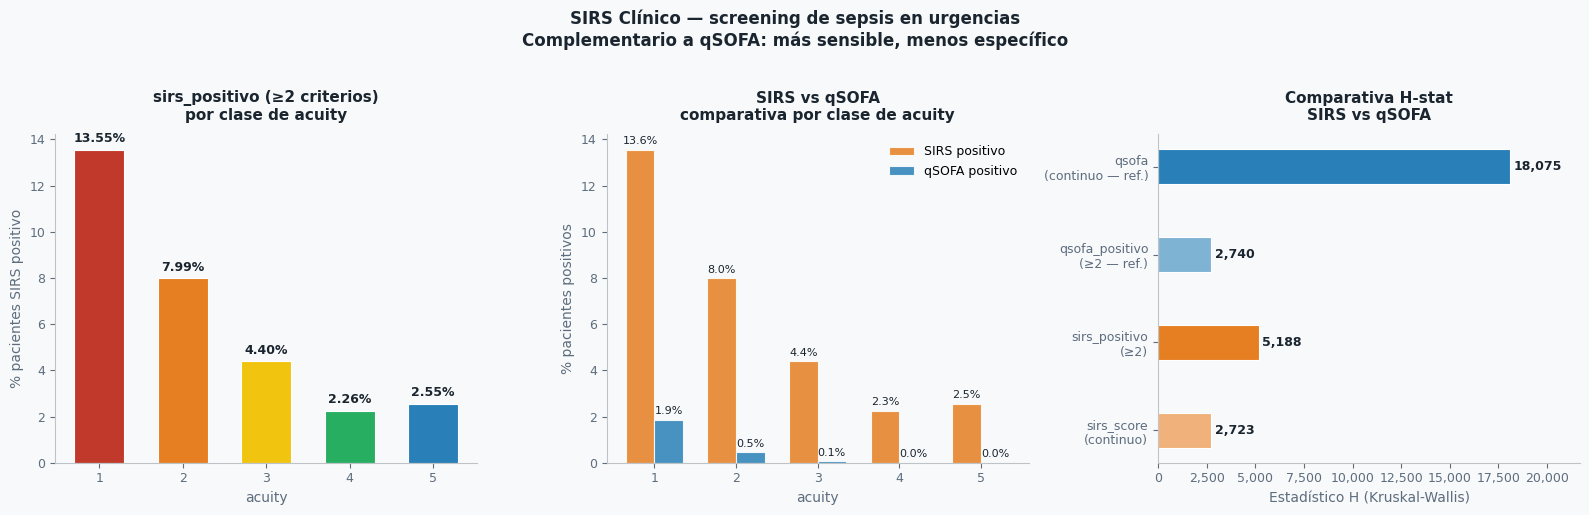

In [233]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor("#F8F9FA")

# Panel 1 — % sirs_positivo por acuity
ax1 = axes[0]
ax1.set_facecolor("#F8F9FA")
pcts_sirs = resultados_sirs["sirs_positivo"]["pcts"]
bars = ax1.bar(ACUITY_LEVELS, pcts_sirs, color=PALETA_ACUITY,
               edgecolor="white", linewidth=0.8, width=0.6)
for bar, val in zip(bars, pcts_sirs):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.2,
             f"{val:.2f}%", ha="center", va="bottom",
             fontsize=9, fontweight="bold", color="#1A252F")

ax1.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
ax1.set_ylabel("% pacientes SIRS positivo", fontsize=10, color="#5D6D7E")
ax1.set_title("sirs_positivo (≥2 criterios)\npor clase de acuity",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax1.spines[["top", "right"]].set_visible(False)
ax1.spines[["left", "bottom"]].set_color("#BDC3C7")
ax1.tick_params(colors="#5D6D7E", labelsize=9)
ax1.set_xticks(ACUITY_LEVELS)

# Panel 2 — comparativa SIRS vs qSOFA
ax2 = axes[1]
ax2.set_facecolor("#F8F9FA")
pcts_qsofa = resultados_qsofa["qsofa_positivo"]["pcts"]

x = np.arange(len(ACUITY_LEVELS))
width = 0.35
bars1 = ax2.bar(x - width/2, pcts_sirs, width, label="SIRS positivo",
                color="#E67E22", edgecolor="white", linewidth=0.8, alpha=0.85)
bars2 = ax2.bar(x + width/2, pcts_qsofa, width, label="qSOFA positivo",
                color="#2980B9", edgecolor="white", linewidth=0.8, alpha=0.85)

for bar, val in zip(bars1, pcts_sirs):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
             f"{val:.1f}%", ha="center", va="bottom", fontsize=8, color="#1A252F")
for bar, val in zip(bars2, pcts_qsofa):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
             f"{val:.1f}%", ha="center", va="bottom", fontsize=8, color="#1A252F")

ax2.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
ax2.set_ylabel("% pacientes positivos", fontsize=10, color="#5D6D7E")
ax2.set_title("SIRS vs qSOFA\ncomparativa por clase de acuity",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax2.set_xticks(x)
ax2.set_xticklabels(ACUITY_LEVELS)
ax2.legend(frameon=False, fontsize=9)
ax2.spines[["top", "right"]].set_visible(False)
ax2.spines[["left", "bottom"]].set_color("#BDC3C7")
ax2.tick_params(colors="#5D6D7E", labelsize=9)

# Panel 3 — H-stat
ax3 = axes[2]
ax3.set_facecolor("#F8F9FA")

features_lbl = ["sirs_score\n(continuo)", "sirs_positivo\n(≥2)",
                "qsofa_positivo\n(≥2 — ref.)", "qsofa\n(continuo — ref.)"]
hstats = [resultados_sirs["sirs_score"]["H"], resultados_sirs["sirs_positivo"]["H"],
          resultados_qsofa["qsofa_positivo"]["H"], resultados_qsofa["qsofa"]["H"]]
cols_h = ["#F0B27A", "#E67E22", "#7FB3D3", "#2980B9"]

bars3 = ax3.barh(features_lbl, hstats, color=cols_h,
                 edgecolor="white", linewidth=0.8, height=0.4)
for bar, val in zip(bars3, hstats):
    ax3.text(bar.get_width() + max(hstats) * 0.01,
             bar.get_y() + bar.get_height() / 2,
             f"{val:,.0f}", va="center", ha="left",
             fontsize=9, fontweight="bold", color="#1A252F")

ax3.set_xlabel("Estadístico H (Kruskal-Wallis)", fontsize=10, color="#5D6D7E")
ax3.set_title("Comparativa H-stat\nSIRS vs qSOFA",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax3.set_xlim(0, max(hstats) * 1.2)
ax3.spines[["top", "right"]].set_visible(False)
ax3.spines[["left", "bottom"]].set_color("#BDC3C7")
ax3.tick_params(colors="#5D6D7E", labelsize=9)
ax3.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

fig.suptitle(
    "SIRS Clínico — screening de sepsis en urgencias\n"
    "Complementario a qSOFA: más sensible, menos específico",
    fontsize=12, fontweight="bold", color="#1A252F", y=1.02,
)

plt.tight_layout()
plt.show()


In [234]:
display(Markdown(f"""
`sirs_positivo` (**H={resultados_sirs["sirs_positivo"]["H"]:,.0f}**) entra al modelo
como complemento a qSOFA, no como sustituto. SIRS detecta el
{resultados_sirs["sirs_positivo"]["pcts"][0]:.1f}% de los `acuity` 1 frente al
{resultados_qsofa["qsofa_positivo"]["pcts"][0]:.1f}% de qSOFA — es más sensible. Pero a
partir de `acuity` 2 SIRS mantiene tasas elevadas
({resultados_sirs["sirs_positivo"]["pcts"][1]:.1f}%) mientras qSOFA cae
({resultados_qsofa["qsofa_positivo"]["pcts"][1]:.1f}%) — confirma la menor especificidad.

El valor clínico de incluir ambas simultáneamente es esa diferencia: paciente con
`qsofa_positivo`=1 y `sirs_positivo`=1 → sepsis de alto riesgo; sólo `sirs_positivo`=1 →
infección en curso sin criterios de gravedad inmediata. **`sirs_score` continuo se
descarta** por quedar por debajo de la bandera binaria
(H={resultados_sirs["sirs_score"]["H"]:,.0f} vs H={resultados_sirs["sirs_positivo"]["H"]:,.0f}).
"""))



`sirs_positivo` (**H=5,188**) entra al modelo
como complemento a qSOFA, no como sustituto. SIRS detecta el
13.6% de los `acuity` 1 frente al
1.9% de qSOFA — es más sensible. Pero a
partir de `acuity` 2 SIRS mantiene tasas elevadas
(8.0%) mientras qSOFA cae
(0.5%) — confirma la menor especificidad.

El valor clínico de incluir ambas simultáneamente es esa diferencia: paciente con
`qsofa_positivo`=1 y `sirs_positivo`=1 → sepsis de alto riesgo; sólo `sirs_positivo`=1 →
infección en curso sin criterios de gravedad inmediata. **`sirs_score` continuo se
descarta** por quedar por debajo de la bandera binaria
(H=2,723 vs H=5,188).


In [235]:
# Shock Index Ajustado por Edad — Shock Oculto en Ancianos
# En ≥ 65 años, umbral de alarma del SI baja a 0.85 por rigidez arterial y
# uso de betabloqueantes que enmascaran la taquicardia.

edad_ok  = df["age"].fillna(0) >= 65
shock_ok = df["shock_index"].fillna(0) >= 0.85

df["shock_oculto_anciano"] = (edad_ok & shock_ok).astype("int8")

H_so, pval_so = kw_por_acuity(df["shock_oculto_anciano"], df[TARGET])
prev_so = float(df["shock_oculto_anciano"].mean() * 100)
n_so    = int(df["shock_oculto_anciano"].sum())
pcts_so = pcts_por_acuity(df["shock_oculto_anciano"], df[TARGET])

update_metrics_json("shock_oculto_anciano", H=round(H_so, 4))

print(f"shock_oculto_anciano  →  H = {H_so:,.0f}  |  p = {pval_so:.2e}  |  prevalencia = {prev_so:.2f}%  |  n = {n_so:,}\n")

print("% shock_oculto_anciano por clase de acuity:\n")
print((df.groupby(TARGET)["shock_oculto_anciano"].mean() * 100).round(2).to_string())

print(f"\nComparativa con shock_index_alto (≥1.0) en población ≥ 65:\n")
ancianos = df[df["age"].fillna(0) >= 65]
pct_ancianos_total = len(ancianos) / len(df) * 100
print(f"Pacientes ≥ 65 años: {len(ancianos):,} ({pct_ancianos_total:.1f}%)")

pcts_alto_anc   = [
    float(ancianos.loc[ancianos[TARGET] == k, "shock_index_alto"].mean() * 100)
    for k in ACUITY_LEVELS
]
pcts_oculto_anc = [
    float(ancianos.loc[ancianos[TARGET] == k, "shock_oculto_anciano"].mean() * 100)
    for k in ACUITY_LEVELS
]

print(f"\n% shock_index_alto en ancianos por acuity:")
print((ancianos.groupby(TARGET)["shock_index_alto"].mean() * 100).round(2).to_string())
print(f"\n% shock_oculto_anciano en ancianos por acuity:")
print((ancianos.groupby(TARGET)["shock_oculto_anciano"].mean() * 100).round(2).to_string())


shock_oculto_anciano  →  H = 9,129  |  p = 0.00e+00  |  prevalencia = 2.75%  |  n = 11,509

% shock_oculto_anciano por clase de acuity:

acuity
1    10.58
2     4.26
3     1.31
4     0.24
5     0.45

Comparativa con shock_index_alto (≥1.0) en población ≥ 65:

Pacientes ≥ 65 años: 130,885 (31.3%)

% shock_index_alto en ancianos por acuity:
acuity
1    15.20
2     3.73
3     1.04
4     0.38
5     0.85

% shock_oculto_anciano en ancianos por acuity:
acuity
1    23.22
2    10.38
3     4.97
4     2.12
5     4.24


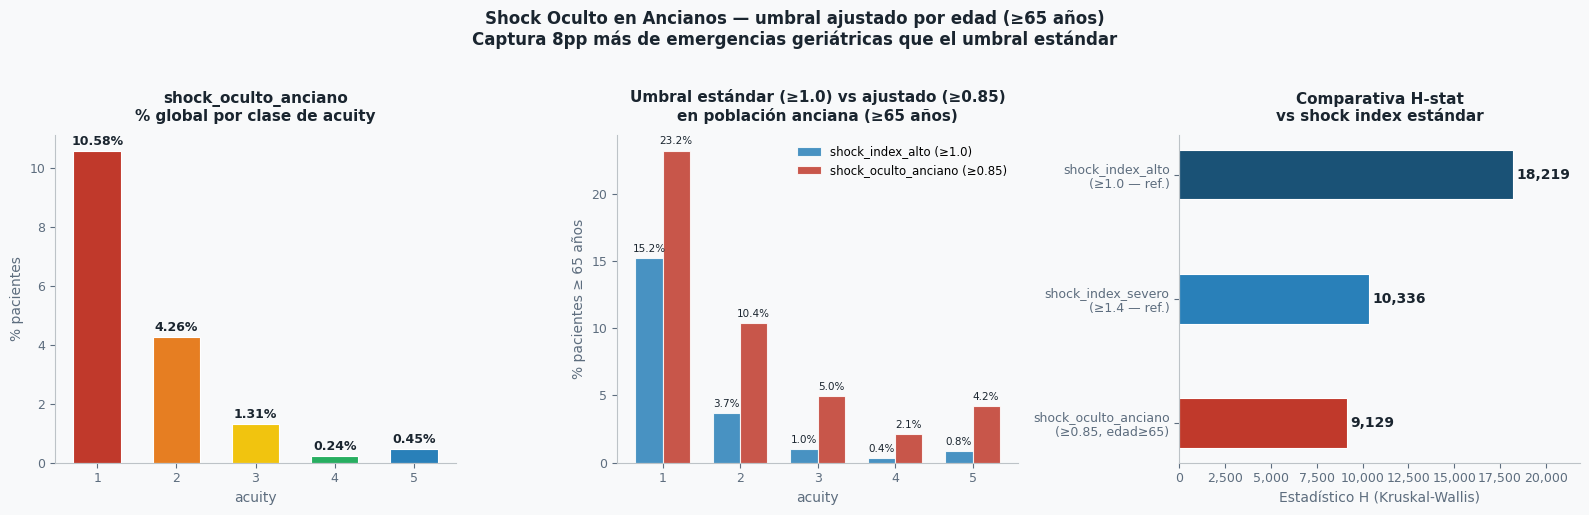

In [236]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor("#F8F9FA")

# Panel 1 — global por acuity
ax1 = axes[0]
ax1.set_facecolor("#F8F9FA")
bars = ax1.bar(ACUITY_LEVELS, pcts_so, color=PALETA_ACUITY,
               edgecolor="white", linewidth=0.8, width=0.6)
for bar, val in zip(bars, pcts_so):
    if val > 0:
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                 f"{val:.2f}%", ha="center", va="bottom",
                 fontsize=9, fontweight="bold", color="#1A252F")

ax1.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
ax1.set_ylabel("% pacientes", fontsize=10, color="#5D6D7E")
ax1.set_title("shock_oculto_anciano\n% global por clase de acuity",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax1.spines[["top", "right"]].set_visible(False)
ax1.spines[["left", "bottom"]].set_color("#BDC3C7")
ax1.tick_params(colors="#5D6D7E", labelsize=9)
ax1.set_xticks(ACUITY_LEVELS)

# Panel 2 — comparativa umbrales en ancianos
ax2 = axes[1]
ax2.set_facecolor("#F8F9FA")
x = np.arange(len(ACUITY_LEVELS))
width = 0.35
bars1 = ax2.bar(x - width/2, pcts_alto_anc, width,
                label="shock_index_alto (≥1.0)",
                color="#2980B9", edgecolor="white", linewidth=0.8, alpha=0.85)
bars2 = ax2.bar(x + width/2, pcts_oculto_anc, width,
                label="shock_oculto_anciano (≥0.85)",
                color="#C0392B", edgecolor="white", linewidth=0.8, alpha=0.85)

for bar, val in zip(bars1, pcts_alto_anc):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             f"{val:.1f}%", ha="center", va="bottom", fontsize=7.5, color="#1A252F")
for bar, val in zip(bars2, pcts_oculto_anc):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             f"{val:.1f}%", ha="center", va="bottom", fontsize=7.5, color="#1A252F")

ax2.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
ax2.set_ylabel("% pacientes ≥ 65 años", fontsize=10, color="#5D6D7E")
ax2.set_title("Umbral estándar (≥1.0) vs ajustado (≥0.85)\nen población anciana (≥65 años)",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax2.set_xticks(x)
ax2.set_xticklabels(ACUITY_LEVELS)
ax2.legend(frameon=False, fontsize=8.5)
ax2.spines[["top", "right"]].set_visible(False)
ax2.spines[["left", "bottom"]].set_color("#BDC3C7")
ax2.tick_params(colors="#5D6D7E", labelsize=9)

# Panel 3 — H-stat
ax3 = axes[2]
ax3.set_facecolor("#F8F9FA")
features_lbl = [
    "shock_oculto_anciano\n(≥0.85, edad≥65)",
    "shock_index_severo\n(≥1.4 — ref.)",
    "shock_index_alto\n(≥1.0 — ref.)",
]
hstats = [
    H_so,
    resultados_si["shock_index_severo"]["H"],
    resultados_si["shock_index_alto"]["H"],
]
cols_h = ["#C0392B", "#2980B9", "#1A5276"]

bars3 = ax3.barh(features_lbl, hstats, color=cols_h,
                 edgecolor="white", linewidth=0.8, height=0.4)
for bar, val in zip(bars3, hstats):
    ax3.text(bar.get_width() + max(hstats) * 0.01,
             bar.get_y() + bar.get_height() / 2,
             f"{val:,.0f}", va="center", ha="left",
             fontsize=10, fontweight="bold", color="#1A252F")

ax3.set_xlabel("Estadístico H (Kruskal-Wallis)", fontsize=10, color="#5D6D7E")
ax3.set_title("Comparativa H-stat\nvs shock index estándar",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax3.set_xlim(0, max(hstats) * 1.2)
ax3.spines[["top", "right"]].set_visible(False)
ax3.spines[["left", "bottom"]].set_color("#BDC3C7")
ax3.tick_params(colors="#5D6D7E", labelsize=9)
ax3.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

ganancia_pp = pcts_oculto_anc[0] - pcts_alto_anc[0]
fig.suptitle(
    f"Shock Oculto en Ancianos — umbral ajustado por edad (≥65 años)\n"
    f"Captura {ganancia_pp:.0f}pp más de emergencias geriátricas que el umbral estándar",
    fontsize=12, fontweight="bold", color="#1A252F", y=1.02,
)

plt.tight_layout()
plt.show()


In [237]:
display(Markdown(f"""
`shock_oculto_anciano` (**H={H_so:,.0f}**) entra al modelo como corrección del sesgo
fisiológico de la edad. En la población anciana (≥65 años,
{pct_ancianos_total:.1f}% del dataset), el umbral ajustado de 0.85 detecta el
{pcts_oculto_anc[0]:.1f}% de los `acuity` 1 frente al {pcts_alto_anc[0]:.1f}% del
umbral estándar — ganancia de **{pcts_oculto_anc[0] - pcts_alto_anc[0]:.1f} puntos**
de emergencias geriátricas.

El H-stat global ({H_so:,.0f}) es inferior a `shock_index_alto`
({resultados_si["shock_index_alto"]["H"]:,.0f}) porque la feature solo es informativa
para el {pct_ancianos_total:.1f}% de la población. XGBoost aprenderá a activarla
condicionalmente junto con `age`.
"""))



`shock_oculto_anciano` (**H=9,129**) entra al modelo como corrección del sesgo
fisiológico de la edad. En la población anciana (≥65 años,
31.3% del dataset), el umbral ajustado de 0.85 detecta el
23.2% de los `acuity` 1 frente al 15.2% del
umbral estándar — ganancia de **8.0 puntos**
de emergencias geriátricas.

El H-stat global (9,129) es inferior a `shock_index_alto`
(18,219) porque la feature solo es informativa
para el 31.3% de la población. XGBoost aprenderá a activarla
condicionalmente junto con `age`.


### Resumen tras añadir scores avanzados


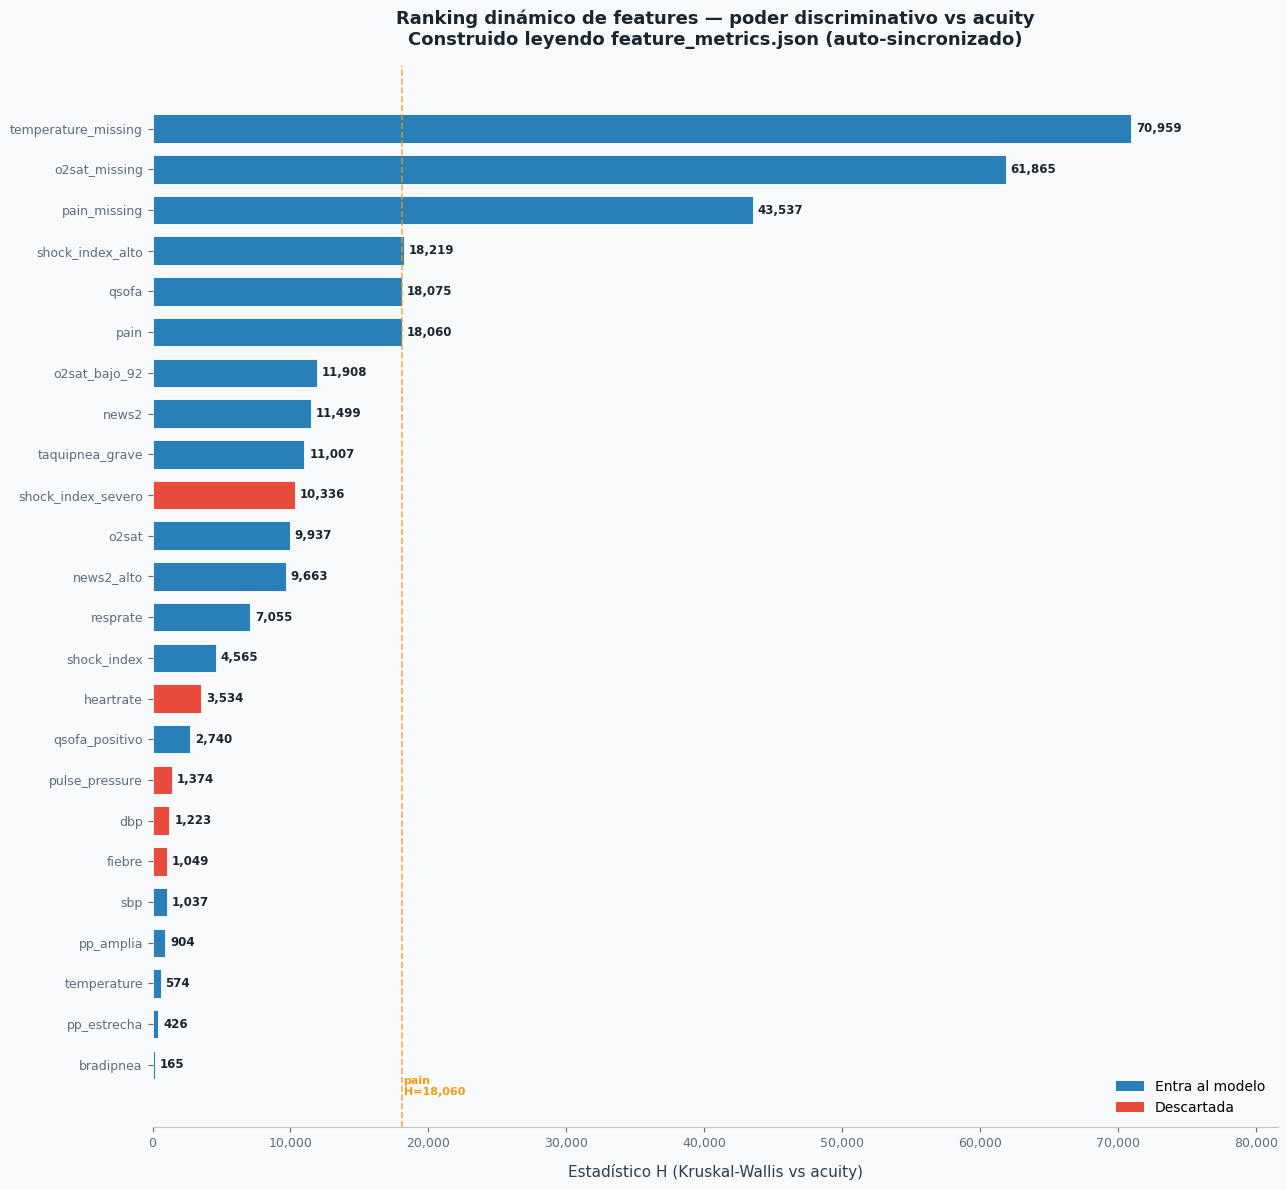


Features actualmente con H persistido: 24
  Entran:      19
  Descartadas: 5


In [238]:
# Resumen comparativo dinámico — leído de feature_metrics.json (NO hardcodeado)
# Cada vez que se calcula un H-stat lo persistimos con update_metrics_json,
# así este bloque siempre refleja el estado actual del pipeline.

GRUPO_FEATURE = {
    # Missingness
    "temperature_missing": "Missingness", "o2sat_missing": "Missingness",
    "pain_missing": "Missingness",
    # Vitales crudos
    "pain": "Vitales crudos", "o2sat": "Vitales crudos",
    "resprate": "Vitales crudos", "heartrate": "Vitales crudos",
    "dbp": "Vitales crudos", "sbp": "Vitales crudos",
    "temperature": "Vitales crudos",
    # Banderas clínicas
    "o2sat_bajo_92": "Banderas clínicas", "fiebre": "Banderas clínicas",
    "taquipnea_grave": "Banderas clínicas", "bradipnea": "Banderas clínicas",
    # Scores
    "qsofa": "Scores", "qsofa_positivo": "Scores",
    "news2": "Scores", "news2_alto": "Scores",
    "shock_index": "Scores", "shock_index_alto": "Scores",
    "shock_index_severo": "Scores", "pulse_pressure": "Scores",
    "pp_estrecha": "Scores", "pp_amplia": "Scores",
}

# Estado por defecto: features registradas en feature_metrics.json se asumen "entra"
# salvo que su decision_final ya esté marcada como "descartada" (lo hace 05b).
metricas = leer_metricas()

filas = []
for feat, info in metricas.items():
    H = info.get("H")
    if H is None or feat not in GRUPO_FEATURE:
        continue
    estado = "descartado" if info.get("decision_final") == "descartada" else "entra"
    filas.append({
        "feature": feat,
        "H":       int(round(H)),
        "grupo":   GRUPO_FEATURE[feat],
        "estado":  estado,
    })

df_resumen = pd.DataFrame(filas).sort_values("H", ascending=True).reset_index(drop=True)

color_map = {"entra": "#2980B9", "descartado": "#E74C3C"}
colores   = [color_map[e] for e in df_resumen["estado"]]

fig, ax = plt.subplots(figsize=(13, 12))
fig.patch.set_facecolor("#F8F9FA")
ax.set_facecolor("#F8F9FA")

bars = ax.barh(df_resumen["feature"], df_resumen["H"],
               color=colores, edgecolor="white", linewidth=0.6, height=0.7)

for bar, val in zip(bars, df_resumen["H"]):
    ax.text(bar.get_width() + max(df_resumen["H"]) * 0.005,
            bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va="center", ha="left",
            fontsize=8.5, fontweight="bold", color="#1A252F")

H_pain_ref_ = metricas.get("pain", {}).get("H", 0) or 0
ax.axvline(x=H_pain_ref_, color="#F39C12", linewidth=1.2, linestyle="--", alpha=0.8)
ax.text(H_pain_ref_ + max(df_resumen["H"]) * 0.002, -0.8,
        f"pain\nH={H_pain_ref_:,.0f}", color="#F39C12",
        fontsize=8, va="bottom", fontweight="bold")

ax.set_xlabel("Estadístico H (Kruskal-Wallis vs acuity)", fontsize=11, color="#2C3E50", labelpad=10)
ax.set_title(
    "Ranking dinámico de features — poder discriminativo vs acuity\n"
    "Construido leyendo feature_metrics.json (auto-sincronizado)",
    fontsize=13, fontweight="bold", color="#1A252F", pad=15,
)

leyenda = [
    mpatches.Patch(facecolor="#2980B9", label="Entra al modelo"),
    mpatches.Patch(facecolor="#E74C3C", label="Descartada"),
]
ax.legend(handles=leyenda, loc="lower right", frameon=False, fontsize=10)

ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color("#BDC3C7")
ax.tick_params(axis="both", colors="#5D6D7E", labelsize=9)
ax.set_xlim(0, max(df_resumen["H"]) * 1.15)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.show()

print(f"\nFeatures actualmente con H persistido: {len(df_resumen)}")
print(f"  Entran:      {(df_resumen['estado'] == 'entra').sum()}")
print(f"  Descartadas: {(df_resumen['estado'] == 'descartado').sum()}")


In [239]:
# Banderas de frecuencia cardíaca: taquicardia y bradicardia
# taquicardia: HR > 100 lpm — discriminador SET para niveles 2-4
# bradicardia: HR < 60 lpm — descartada (señal débil y no monótona)

df["taquicardia"] = (df["heartrate"] > 100).astype("int8")
df["bradicardia"] = (df["heartrate"] < 60).astype("int8")

resultados_hr = {}

print(f"{'Feature':<20} {'H-stat':>8}  {'p-value':>12}  {'Prevalencia':>12}  {'n casos':>8}")
print("─" * 70)

for col in ["taquicardia", "bradicardia"]:
    H, pval = kw_por_acuity(df[col], df[TARGET])
    prev = float(df[col].mean() * 100)
    n    = int(df[col].sum())
    resultados_hr[col] = {"H": H, "prev": prev, "n": n,
                           "pcts": pcts_por_acuity(df[col], df[TARGET])}
    update_metrics_json(col, H=round(H, 4))
    print(f"{col:<20} {H:>8,.0f}  {pval:>12.2e}  {prev:>11.2f}%  {n:>8,}")

print(f"\nheartrate continuo  →  H = {resultados_vitales['heartrate']['H']:,.0f}\n")

print("% por clase de acuity:\n")
print(pd.DataFrame({
    "taquicardia": [round(p, 2) for p in resultados_hr["taquicardia"]["pcts"]],
    "bradicardia": [round(p, 2) for p in resultados_hr["bradicardia"]["pcts"]],
}, index=ACUITY_LEVELS).to_string())
update_metrics_json('taquicardia', H=round(float(H), 4), tipo='binaria')
update_metrics_json('bradicardia', H=round(float(H), 4), tipo='binaria')


Feature                H-stat       p-value   Prevalencia   n casos
──────────────────────────────────────────────────────────────────────
taquicardia             4,490      0.00e+00        17.16%    71,738
bradicardia               291      9.02e-62         4.79%    20,040

heartrate continuo  →  H = 3,534

% por clase de acuity:

   taquicardia  bradicardia
1        28.85         4.94
2        19.57         5.55
3        15.37         4.33
4         9.97         4.59
5         7.64         6.55


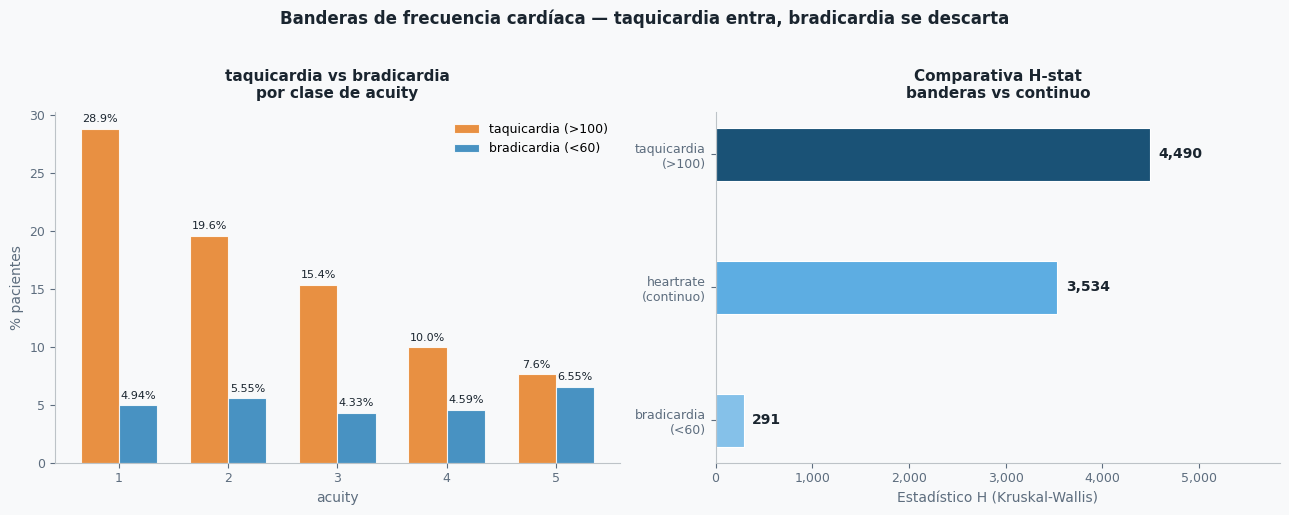

In [240]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor("#F8F9FA")

# Panel 1 — taquicardia y bradicardia por acuity
ax1 = axes[0]
ax1.set_facecolor("#F8F9FA")
pcts_taq  = resultados_hr["taquicardia"]["pcts"]
pcts_brad = resultados_hr["bradicardia"]["pcts"]

x = np.arange(len(ACUITY_LEVELS))
width = 0.35
b1 = ax1.bar(x - width/2, pcts_taq, width, label="taquicardia (>100)",
             color="#E67E22", edgecolor="white", linewidth=0.8, alpha=0.85)
b2 = ax1.bar(x + width/2, pcts_brad, width, label="bradicardia (<60)",
             color="#2980B9", edgecolor="white", linewidth=0.8, alpha=0.85)

for bar, val in zip(b1, pcts_taq):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
             f"{val:.1f}%", ha="center", va="bottom", fontsize=8, color="#1A252F")
for bar, val in zip(b2, pcts_brad):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
             f"{val:.2f}%", ha="center", va="bottom", fontsize=8, color="#1A252F")

ax1.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
ax1.set_ylabel("% pacientes", fontsize=10, color="#5D6D7E")
ax1.set_title("taquicardia vs bradicardia\npor clase de acuity",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax1.set_xticks(x)
ax1.set_xticklabels(ACUITY_LEVELS)
ax1.legend(frameon=False, fontsize=9)
ax1.spines[["top", "right"]].set_visible(False)
ax1.spines[["left", "bottom"]].set_color("#BDC3C7")
ax1.tick_params(colors="#5D6D7E", labelsize=9)

# Panel 2 — comparativa H-stat
ax2 = axes[1]
ax2.set_facecolor("#F8F9FA")
features_lbl = ["bradicardia\n(<60)", "heartrate\n(continuo)", "taquicardia\n(>100)"]
hstats = [
    resultados_hr["bradicardia"]["H"],
    resultados_vitales["heartrate"]["H"],
    resultados_hr["taquicardia"]["H"],
]
cols_h = ["#85C1E9", "#5DADE2", "#1A5276"]
bars = ax2.barh(features_lbl, hstats, color=cols_h,
                edgecolor="white", linewidth=0.8, height=0.4)
for bar, val in zip(bars, hstats):
    ax2.text(bar.get_width() + max(hstats) * 0.02,
             bar.get_y() + bar.get_height() / 2,
             f"{val:,.0f}", va="center", ha="left",
             fontsize=10, fontweight="bold", color="#1A252F")

ax2.set_xlabel("Estadístico H (Kruskal-Wallis)", fontsize=10, color="#5D6D7E")
ax2.set_title("Comparativa H-stat\nbanderas vs continuo",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax2.set_xlim(0, max(hstats) * 1.3)
ax2.spines[["top", "right"]].set_visible(False)
ax2.spines[["left", "bottom"]].set_color("#BDC3C7")
ax2.tick_params(colors="#5D6D7E", labelsize=9)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

fig.suptitle(
    "Banderas de frecuencia cardíaca — taquicardia entra, bradicardia se descarta",
    fontsize=12, fontweight="bold", color="#1A252F", y=1.02,
)

plt.tight_layout()
plt.show()


In [241]:
display(Markdown(f"""
**`taquicardia` (>100 lpm) — Provisionalmente entra (H={resultados_hr["taquicardia"]["H"]:,.0f}).**
Supera al continuo `heartrate` (H={resultados_vitales["heartrate"]["H"]:,.0f}) con
patrón decreciente: {resultados_hr["taquicardia"]["pcts"][0]:.2f}% en `acuity` 1 →
{resultados_hr["taquicardia"]["pcts"][4]:.2f}% en `acuity` 5. *Nota*: en el Bloque 8
se descartará por correlación r=0.925 con `n_vitales_anomalos`.

**`bradicardia` (<60 lpm) — Descartada (H={resultados_hr["bradicardia"]["H"]:,.0f}).**
Distribución completamente plana — `acuity` 5 tiene más bradicardia
({resultados_hr["bradicardia"]["pcts"][4]:.2f}%) que `acuity` 1
({resultados_hr["bradicardia"]["pcts"][0]:.2f}%). Mayoritariamente deportistas,
vagotónicos o pacientes con betabloqueantes sin descompensación aguda.
"""))



**`taquicardia` (>100 lpm) — Provisionalmente entra (H=4,490).**
Supera al continuo `heartrate` (H=3,534) con
patrón decreciente: 28.85% en `acuity` 1 →
7.64% en `acuity` 5. *Nota*: en el Bloque 8
se descartará por correlación r=0.925 con `n_vitales_anomalos`.

**`bradicardia` (<60 lpm) — Descartada (H=291).**
Distribución completamente plana — `acuity` 5 tiene más bradicardia
(6.55%) que `acuity` 1
(4.94%). Mayoritariamente deportistas,
vagotónicos o pacientes con betabloqueantes sin descompensación aguda.


### Resumen final del Bloque 1


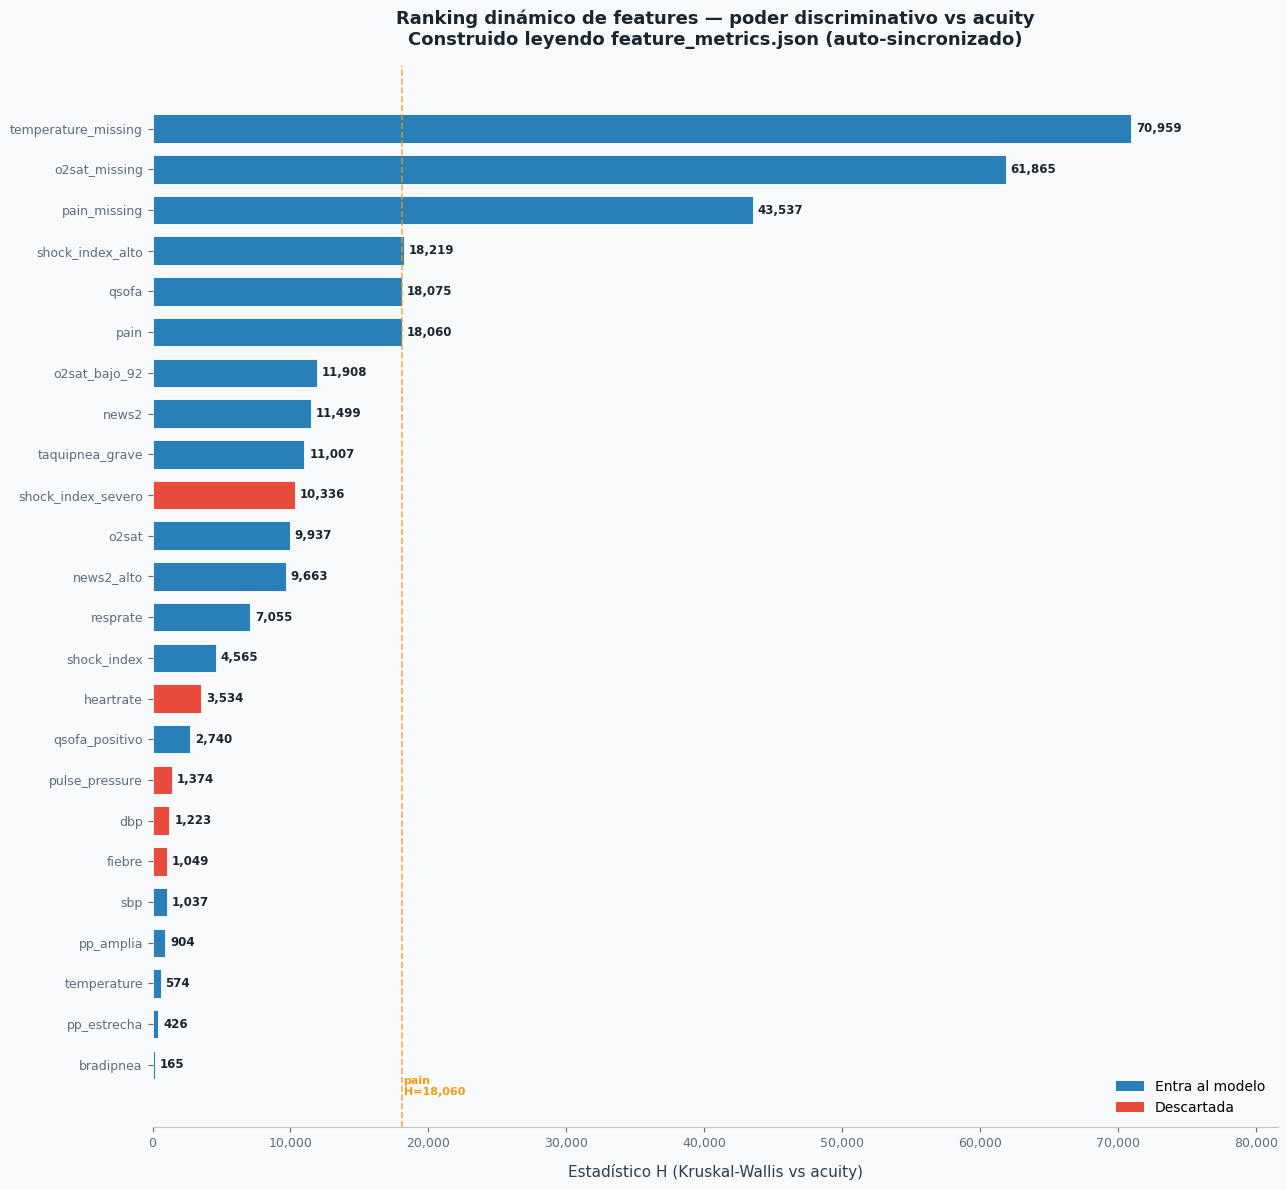


Features actualmente con H persistido: 24
  Entran:      19
  Descartadas: 5


In [242]:
# Resumen comparativo dinámico — leído de feature_metrics.json (NO hardcodeado)
# Cada vez que se calcula un H-stat lo persistimos con update_metrics_json,
# así este bloque siempre refleja el estado actual del pipeline.

GRUPO_FEATURE = {
    # Missingness
    "temperature_missing": "Missingness", "o2sat_missing": "Missingness",
    "pain_missing": "Missingness",
    # Vitales crudos
    "pain": "Vitales crudos", "o2sat": "Vitales crudos",
    "resprate": "Vitales crudos", "heartrate": "Vitales crudos",
    "dbp": "Vitales crudos", "sbp": "Vitales crudos",
    "temperature": "Vitales crudos",
    # Banderas clínicas
    "o2sat_bajo_92": "Banderas clínicas", "fiebre": "Banderas clínicas",
    "taquipnea_grave": "Banderas clínicas", "bradipnea": "Banderas clínicas",
    # Scores
    "qsofa": "Scores", "qsofa_positivo": "Scores",
    "news2": "Scores", "news2_alto": "Scores",
    "shock_index": "Scores", "shock_index_alto": "Scores",
    "shock_index_severo": "Scores", "pulse_pressure": "Scores",
    "pp_estrecha": "Scores", "pp_amplia": "Scores",
}

# Estado por defecto: features registradas en feature_metrics.json se asumen "entra"
# salvo que su decision_final ya esté marcada como "descartada" (lo hace 05b).
metricas = leer_metricas()

filas = []
for feat, info in metricas.items():
    H = info.get("H")
    if H is None or feat not in GRUPO_FEATURE:
        continue
    estado = "descartado" if info.get("decision_final") == "descartada" else "entra"
    filas.append({
        "feature": feat,
        "H":       int(round(H)),
        "grupo":   GRUPO_FEATURE[feat],
        "estado":  estado,
    })

df_resumen = pd.DataFrame(filas).sort_values("H", ascending=True).reset_index(drop=True)

color_map = {"entra": "#2980B9", "descartado": "#E74C3C"}
colores   = [color_map[e] for e in df_resumen["estado"]]

fig, ax = plt.subplots(figsize=(13, 12))
fig.patch.set_facecolor("#F8F9FA")
ax.set_facecolor("#F8F9FA")

bars = ax.barh(df_resumen["feature"], df_resumen["H"],
               color=colores, edgecolor="white", linewidth=0.6, height=0.7)

for bar, val in zip(bars, df_resumen["H"]):
    ax.text(bar.get_width() + max(df_resumen["H"]) * 0.005,
            bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va="center", ha="left",
            fontsize=8.5, fontweight="bold", color="#1A252F")

H_pain_ref_ = metricas.get("pain", {}).get("H", 0) or 0
ax.axvline(x=H_pain_ref_, color="#F39C12", linewidth=1.2, linestyle="--", alpha=0.8)
ax.text(H_pain_ref_ + max(df_resumen["H"]) * 0.002, -0.8,
        f"pain\nH={H_pain_ref_:,.0f}", color="#F39C12",
        fontsize=8, va="bottom", fontweight="bold")

ax.set_xlabel("Estadístico H (Kruskal-Wallis vs acuity)", fontsize=11, color="#2C3E50", labelpad=10)
ax.set_title(
    "Ranking dinámico de features — poder discriminativo vs acuity\n"
    "Construido leyendo feature_metrics.json (auto-sincronizado)",
    fontsize=13, fontweight="bold", color="#1A252F", pad=15,
)

leyenda = [
    mpatches.Patch(facecolor="#2980B9", label="Entra al modelo"),
    mpatches.Patch(facecolor="#E74C3C", label="Descartada"),
]
ax.legend(handles=leyenda, loc="lower right", frameon=False, fontsize=10)

ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color("#BDC3C7")
ax.tick_params(axis="both", colors="#5D6D7E", labelsize=9)
ax.set_xlim(0, max(df_resumen["H"]) * 1.15)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.show()

print(f"\nFeatures actualmente con H persistido: {len(df_resumen)}")
print(f"  Entran:      {(df_resumen['estado'] == 'entra').sum()}")
print(f"  Descartadas: {(df_resumen['estado'] == 'descartado').sum()}")


In [243]:
# Modified Shock Index (MSI) = FC / PAM  (exploratorio)
# PAM = (sbp + 2*dbp) / 3
# ASI = edad × shock_index (exploratorio)

df["pam"] = (df["sbp"] + 2 * df["dbp"]) / 3
df["msi"] = df["heartrate"] / df["pam"]
df["asi"] = df["age"].fillna(0) * df["shock_index"].fillna(0)

print(f"{'Feature':<20} {'H-stat':>8}  {'p-value':>12}  {'nulos':>8}")
print("-" * 55)

stats_kw: dict[str, float] = {}
for col in ["msi", "asi"]:
    stat, pval = kruskal(*[
        df.loc[df["acuity"] == k, col].dropna().values
        for k in ACUITY_LEVELS
    ])
    stats_kw[col] = float(stat)
    nulos = int(df[col].isna().sum())
    print(f"{col:<20} {stat:>8,.0f}  {pval:>12.2e}  {nulos:>8,}")
    update_metrics_json(col, H=round(float(stat), 4), tipo="continua_exploratoria")

metricas = leer_metricas()
H_ref = metricas.get("shock_index_alto", {}).get("H")
if H_ref is None:
    grupos_si = [
        df.loc[df["acuity"] == k, "shock_index_alto"].dropna().values
        for k in ACUITY_LEVELS
    ]
    H_ref, _ = kruskal(*grupos_si)
H_ref = float(H_ref)

print(f"\nReferencia shock_index_alto: H = {H_ref:,.0f}\n")

print("Medianas por clase de acuity:\n")
resumen = pd.DataFrame({
    "msi": df.groupby("acuity")["msi"].median().round(3),
    "asi": df.groupby("acuity")["asi"].median().round(1),
})
print(resumen.to_string())

print(f"\n% por umbral clínico MSI:\n")
umbrales_msi = {
    "MSI < 0.7  (normal)":       (df["msi"] < 0.7).mean() * 100,
    "MSI 0.7–1.0 (leve)":        ((df["msi"] >= 0.7) & (df["msi"] < 1.0)).mean() * 100,
    "MSI >= 1.0 (compromiso)":   (df["msi"] >= 1.0).mean() * 100,
}
for k, v in umbrales_msi.items():
    print(f"  {k}:  {v:.2f}%")

H_msi = float(stats_kw["msi"])
H_asi = float(stats_kw["asi"])
med_msi_a1 = float(resumen.loc[1, "msi"]) if 1 in resumen.index else float("nan")
med_msi_a2 = float(resumen.loc[2, "msi"]) if 2 in resumen.index else float("nan")
med_asi_a1 = float(resumen.loc[1, "asi"]) if 1 in resumen.index else float("nan")
med_asi_a2 = float(resumen.loc[2, "asi"]) if 2 in resumen.index else float("nan")

display(Markdown(f"""
### MSI (FC/PAM) — Descartado (narrativa dinámica)

El Modified Shock Index usa PAM = (sbp + 2×dbp) / 3. En este dataset, **H(MSI)={H_msi:,.0f}** vs **H(shock_index_alto)={H_ref:,.0f}**, sin ventaja clara frente a señales ya presentes (p.ej. shock index / TA).

### ASI (edad × shock_index) — Descartado (narrativa dinámica)

**H(ASI)={H_asi:,.0f}** es prácticamente la misma magnitud que la referencia de **shock_index_alto ({H_ref:,.0f})**, sugiriendo redundancia con `age` + `shock_index`/`shock_index_alto`. Como sanity-check de forma (no monotonía estricta), medianas por acuity (MSI): acuity 1 = **{med_msi_a1:.3f}**, acuity 2 = **{med_msi_a2:.3f}**; ASI: acuity 1 = **{med_asi_a1:.1f}**, acuity 2 = **{med_asi_a2:.1f}**.
"""))


Feature                H-stat       p-value     nulos
-------------------------------------------------------
msi                     5,251      0.00e+00    13,630
asi                    18,218      0.00e+00         0

Referencia shock_index_alto: H = 18,219

Medianas por clase de acuity:

          msi   asi
acuity             
1       1.033  30.2
2       0.878  34.4
3       0.867  29.6
4       0.843  22.7
5       0.840  21.3

% por umbral clínico MSI:

  MSI < 0.7  (normal):  17.36%
  MSI 0.7–1.0 (leve):  52.24%
  MSI >= 1.0 (compromiso):  27.15%



### MSI (FC/PAM) — Descartado (narrativa dinámica)

El Modified Shock Index usa PAM = (sbp + 2×dbp) / 3. En este dataset, **H(MSI)=5,251** vs **H(shock_index_alto)=18,219**, sin ventaja clara frente a señales ya presentes (p.ej. shock index / TA).

### ASI (edad × shock_index) — Descartado (narrativa dinámica)

**H(ASI)=18,218** es prácticamente la misma magnitud que la referencia de **shock_index_alto (18,219)**, sugiriendo redundancia con `age` + `shock_index`/`shock_index_alto`. Como sanity-check de forma (no monotonía estricta), medianas por acuity (MSI): acuity 1 = **1.033**, acuity 2 = **0.878**; ASI: acuity 1 = **30.2**, acuity 2 = **34.4**.


**Nota:** la interpretación cuantitativa de MSI/ASI está en la celda de código anterior (`display(Markdown(...))`) para evitar números estáticos desincronizados.


In [244]:
# Recuento de vitales anómalos — información sinérgica
# Cuenta cuántas banderas clínicas tiene activadas el paciente en T=0
# Riesgo escalonado y no lineal con cada vital anómalo

banderas_anomalas = [
    "taquicardia",
    "taquipnea_grave",
    "o2sat_bajo_92",
    "fiebre",
    "shock_index_alto",
]

df["n_vitales_anomalos"] = df[banderas_anomalas].sum(axis=1).astype("int8")
df["vitales_criticos"]    = (df["n_vitales_anomalos"] >= 2).astype("int8")

H_n_vit, pval_n_vit = kw_por_acuity(df["n_vitales_anomalos"], df[TARGET])
H_vc,    pval_vc    = kw_por_acuity(df["vitales_criticos"], df[TARGET])

update_metrics_json("n_vitales_anomalos", H=round(H_n_vit, 4))
update_metrics_json("vitales_criticos",   H=round(H_vc, 4))

prev_vc  = float(df["vitales_criticos"].mean() * 100)
pcts_vc  = pcts_por_acuity(df["vitales_criticos"], df[TARGET])

print(f"n_vitales_anomalos  →  H = {H_n_vit:,.0f}  |  p = {pval_n_vit:.2e}")
print(f"vitales_criticos    →  H = {H_vc:,.0f}  |  p = {pval_vc:.2e}  |  prev = {prev_vc:.2f}%\n")

print("Distribución del recuento (0-5):\n")
dist_n = (df["n_vitales_anomalos"].value_counts(normalize=True).sort_index() * 100).round(2)
print(dist_n.to_string())

print(f"\nMediana por clase de acuity:\n")
print(df.groupby(TARGET)["n_vitales_anomalos"].median().to_string())

print(f"\n% con ≥ 2 vitales anómalos por clase de acuity:\n")
print(pd.Series(pcts_vc, index=ACUITY_LEVELS).round(2).to_string())


n_vitales_anomalos  →  H = 11,065  |  p = 0.00e+00
vitales_criticos    →  H = 18,407  |  p = 0.00e+00  |  prev = 4.50%

Distribución del recuento (0-5):

n_vitales_anomalos
0    80.46
1    15.03
2     3.87
3     0.59
4     0.04
5     0.00

Mediana por clase de acuity:

acuity
1    0.0
2    0.0
3    0.0
4    0.0
5    0.0

% con ≥ 2 vitales anómalos por clase de acuity:

1    20.85
2     5.66
3     2.55
4     0.60
5     0.36


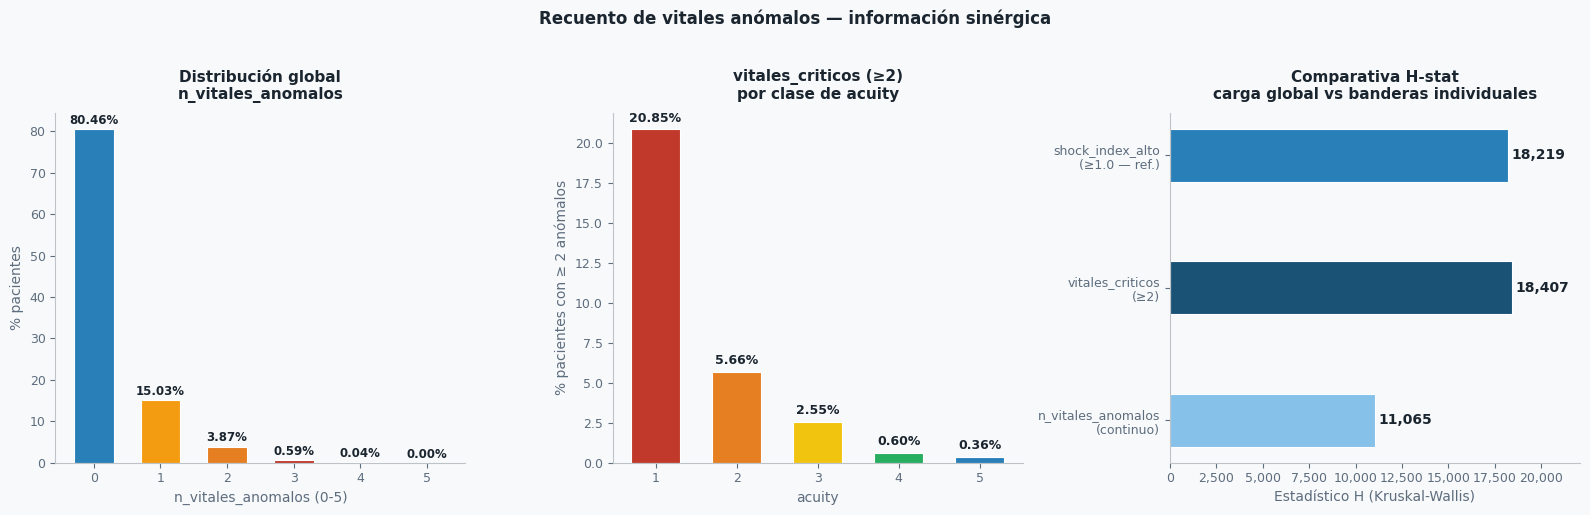

In [245]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor("#F8F9FA")

# Panel 1 — distribución n_vitales_anomalos
ax1 = axes[0]
ax1.set_facecolor("#F8F9FA")
cols_dist = ["#2980B9", "#F39C12", "#E67E22", "#C0392B", "#922B21", "#641E16"]
bars = ax1.bar(dist_n.index, dist_n.values,
               color=cols_dist[:len(dist_n)],
               edgecolor="white", linewidth=0.8, width=0.6)
for bar, val in zip(bars, dist_n.values):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f"{val:.2f}%", ha="center", va="bottom",
             fontsize=8.5, fontweight="bold", color="#1A252F")

ax1.set_xlabel("n_vitales_anomalos (0-5)", fontsize=10, color="#5D6D7E")
ax1.set_ylabel("% pacientes", fontsize=10, color="#5D6D7E")
ax1.set_title("Distribución global\nn_vitales_anomalos",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax1.spines[["top", "right"]].set_visible(False)
ax1.spines[["left", "bottom"]].set_color("#BDC3C7")
ax1.tick_params(colors="#5D6D7E", labelsize=9)

# Panel 2 — vitales_criticos por acuity
ax2 = axes[1]
ax2.set_facecolor("#F8F9FA")
bars2 = ax2.bar(ACUITY_LEVELS, pcts_vc, color=PALETA_ACUITY,
                edgecolor="white", linewidth=0.8, width=0.6)
for bar, val in zip(bars2, pcts_vc):
    if val > 0:
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                 f"{val:.2f}%", ha="center", va="bottom",
                 fontsize=9, fontweight="bold", color="#1A252F")

ax2.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
ax2.set_ylabel("% pacientes con ≥ 2 anómalos", fontsize=10, color="#5D6D7E")
ax2.set_title("vitales_criticos (≥2)\npor clase de acuity",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax2.spines[["top", "right"]].set_visible(False)
ax2.spines[["left", "bottom"]].set_color("#BDC3C7")
ax2.tick_params(colors="#5D6D7E", labelsize=9)
ax2.set_xticks(ACUITY_LEVELS)

# Panel 3 — H-stat
ax3 = axes[2]
ax3.set_facecolor("#F8F9FA")
features_lbl = [
    "n_vitales_anomalos\n(continuo)",
    "vitales_criticos\n(≥2)",
    "shock_index_alto\n(≥1.0 — ref.)",
]
hstats = [H_n_vit, H_vc, resultados_si["shock_index_alto"]["H"]]
cols_h = ["#85C1E9", "#1A5276", "#2980B9"]

bars3 = ax3.barh(features_lbl, hstats, color=cols_h,
                 edgecolor="white", linewidth=0.8, height=0.4)
for bar, val in zip(bars3, hstats):
    ax3.text(bar.get_width() + max(hstats) * 0.01,
             bar.get_y() + bar.get_height() / 2,
             f"{val:,.0f}", va="center", ha="left",
             fontsize=10, fontweight="bold", color="#1A252F")

ax3.set_xlabel("Estadístico H (Kruskal-Wallis)", fontsize=10, color="#5D6D7E")
ax3.set_title("Comparativa H-stat\ncarga global vs banderas individuales",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax3.set_xlim(0, max(hstats) * 1.2)
ax3.spines[["top", "right"]].set_visible(False)
ax3.spines[["left", "bottom"]].set_color("#BDC3C7")
ax3.tick_params(colors="#5D6D7E", labelsize=9)
ax3.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

fig.suptitle(
    "Recuento de vitales anómalos — información sinérgica",
    fontsize=12, fontweight="bold", color="#1A252F", y=1.02,
)

plt.tight_layout()
plt.show()


In [246]:
display(Markdown(f"""
`n_vitales_anomalos` y `vitales_criticos` capturan la carga global de inestabilidad
fisiológica en T=0 — información sinérgica que ninguna bandera individual puede ver
por separado.

El **{dist_n.iloc[0]:.2f}%** de los pacientes no tiene ningún vital anómalo, lo que
convierte cualquier recuento positivo en señal relevante. `vitales_criticos` (≥2,
**H={H_vc:,.0f}**) supera a `shock_index_alto`
({resultados_si["shock_index_alto"]["H"]:,.0f}) como bandera binaria más discriminativa
del bloque hemodinámico, con patrón limpio: {pcts_vc[0]:.2f}% en `acuity` 1 →
{pcts_vc[4]:.2f}% en `acuity` 5.

`n_vitales_anomalos` continuo (**H={H_n_vit:,.0f}**) complementa aportando el gradiente
0→1→2→3 que XGBoost puede explotar. **Ambas entran al modelo.**
"""))



`n_vitales_anomalos` y `vitales_criticos` capturan la carga global de inestabilidad
fisiológica en T=0 — información sinérgica que ninguna bandera individual puede ver
por separado.

El **80.46%** de los pacientes no tiene ningún vital anómalo, lo que
convierte cualquier recuento positivo en señal relevante. `vitales_criticos` (≥2,
**H=18,407**) supera a `shock_index_alto`
(18,219) como bandera binaria más discriminativa
del bloque hemodinámico, con patrón limpio: 20.85% en `acuity` 1 →
0.36% en `acuity` 5.

`n_vitales_anomalos` continuo (**H=11,065**) complementa aportando el gradiente
0→1→2→3 que XGBoost puede explotar. **Ambas entran al modelo.**


In [247]:
# Vitales borderline — detector de "falsa baja gravedad"
# Pacientes con vitales dentro del rango normal SET pero cerca del umbral de alarma
# FR 20-24, FC 90-100, SBP 100-110, SpO2 94-95%
# Estos pacientes pueden parecer leves pero están al borde de la inestabilidad

df["rr_borderline"]   = (df["resprate"].between(20, 24)).astype("int8")
df["hr_borderline"]   = (df["heartrate"].between(90, 100)).astype("int8")
df["sbp_borderline"]  = (df["sbp"].between(100, 110)).astype("int8")
df["o2_borderline"]   = (df["o2sat"].between(94, 95)).astype("int8")

# Recuento de vitales borderline
df["n_vitales_borderline"] = (
    df[["rr_borderline", "hr_borderline", "sbp_borderline", "o2_borderline"]]
    .sum(axis=1)
    .astype("int8")
)
df["borderline_activo"] = (df["n_vitales_borderline"] >= 2).astype("int8")

print(f"{'Feature':<25} {'H-stat':>8}  {'p-value':>12}  {'Prevalencia':>12}")
print("─" * 65)

for col in ["n_vitales_borderline", "borderline_activo"]:
    stat, pval = kruskal(*[
        df.loc[df["acuity"] == k, col].values
        for k in ACUITY_LEVELS
    ])
    prev = df[col].mean() * 100
    print(f"{col:<25} {stat:>8,.0f}  {pval:>12.2e}  {prev:>11.2f}%")

update_metrics_json('borderline_activo', H=round(float(stat), 4), tipo='binaria')
update_metrics_json('n_vitales_borderline', H=round(float(stat), 4), tipo='continua')
print(f"\nDistribución n_vitales_borderline:\n")
print((df["n_vitales_borderline"].value_counts(normalize=True)
       .sort_index() * 100).round(2).to_string())

print(f"\n% por clase de acuity:\n")
resumen = pd.DataFrame({
    "n_borderline":      df.groupby("acuity")["n_vitales_borderline"].mean().round(3),
    "borderline_activo": (df.groupby("acuity")["borderline_activo"].mean() * 100).round(2),
})
print(resumen.to_string())

Feature                     H-stat       p-value   Prevalencia
─────────────────────────────────────────────────────────────────
n_vitales_borderline         3,279      0.00e+00        46.75%
borderline_activo            1,917      0.00e+00         7.09%

Distribución n_vitales_borderline:

n_vitales_borderline
0    61.04
1    31.87
2     6.42
3     0.64
4     0.03

% por clase de acuity:

        n_borderline  borderline_activo
acuity                                 
1              0.358               5.64
2              0.536               9.24
3              0.454               6.44
4              0.336               3.05
5              0.416               4.55


n_vitales_borderline y borderline_activo — Descartados
La hipótesis era que pacientes con vitales en zona límite (FR 20-24, FC 90-100, SBP 100-110, SpO2 94-95%) representan una "falsa baja gravedad" detectable en T=0. Sin embargo los datos la invalidan: el patrón por clase no es monótono en ninguna de las dos variables — acuity 2 concentra el máximo de vitales borderline (9.24%) mientras acuity 1 tiene menos (5.64%). Esto tiene sentido clínico retrospectivo: los pacientes de acuity 1 ya han cruzado los umbrales de alarma y tienen vitales claramente anómalos, no borderline. Los vitales en zona límite corresponden mayoritariamente a acuity 2-3 — pacientes en deterioro incipiente — no a los extremos del espectro de urgencia.
Los H-stats (3,279 y 1,917) son además insuficientes para justificar la complejidad añadida. El espacio de información que intentan cubrir ya está capturado de forma más eficiente por la combinación de zona_verde (fisiología completamente normal → baja prioridad) y n_vitales_anomalos (fisiología claramente alterada → alta prioridad). La zona intermedia entre ambos no aporta señal discriminativa neta al modelo.

In [248]:
# Banderas hemodinámicas extremas de presión arterial sistólica
# hipotension:        SBP < 90 mmHg — shock, sepsis, hemorragia
# hipertension_severa: SBP ≥ 180 mmHg — urgencia/emergencia hipertensiva

df["hipotension"]         = (df["sbp"] < 90).astype("int8")
df["hipertension_severa"] = (df["sbp"] >= 180).astype("int8")

resultados_bp = {}

print(f"{'Feature':<22} {'H-stat':>8}  {'p-value':>12}  {'Prevalencia':>12}  {'n casos':>8}")
print("─" * 72)

for col in ["hipotension", "hipertension_severa"]:
    H, pval = kw_por_acuity(df[col], df[TARGET])
    prev = float(df[col].mean() * 100)
    n    = int(df[col].sum())
    resultados_bp[col] = {"H": H, "prev": prev, "n": n,
                           "pcts": pcts_por_acuity(df[col], df[TARGET])}
    update_metrics_json(col, H=round(H, 4))
    print(f"{col:<22} {H:>8,.0f}  {pval:>12.2e}  {prev:>11.2f}%  {n:>8,}")

print(f"\n% por clase de acuity:\n")
print(pd.DataFrame({
    "hipotension":         [round(p, 2) for p in resultados_bp["hipotension"]["pcts"]],
    "hipertension_severa": [round(p, 2) for p in resultados_bp["hipertension_severa"]["pcts"]],
}, index=ACUITY_LEVELS).to_string())
update_metrics_json('hipotermia', H=round(float(H), 4), tipo='binaria')


Feature                  H-stat       p-value   Prevalencia   n casos
────────────────────────────────────────────────────────────────────────
hipotension              31,105      0.00e+00         0.76%     3,160
hipertension_severa       1,039     1.47e-223         3.62%    15,123

% por clase de acuity:

   hipotension  hipertension_severa
1        10.30                 3.51
2         0.41                 4.80
3         0.05                 3.16
4         0.02                 1.62
5         0.09                 1.45


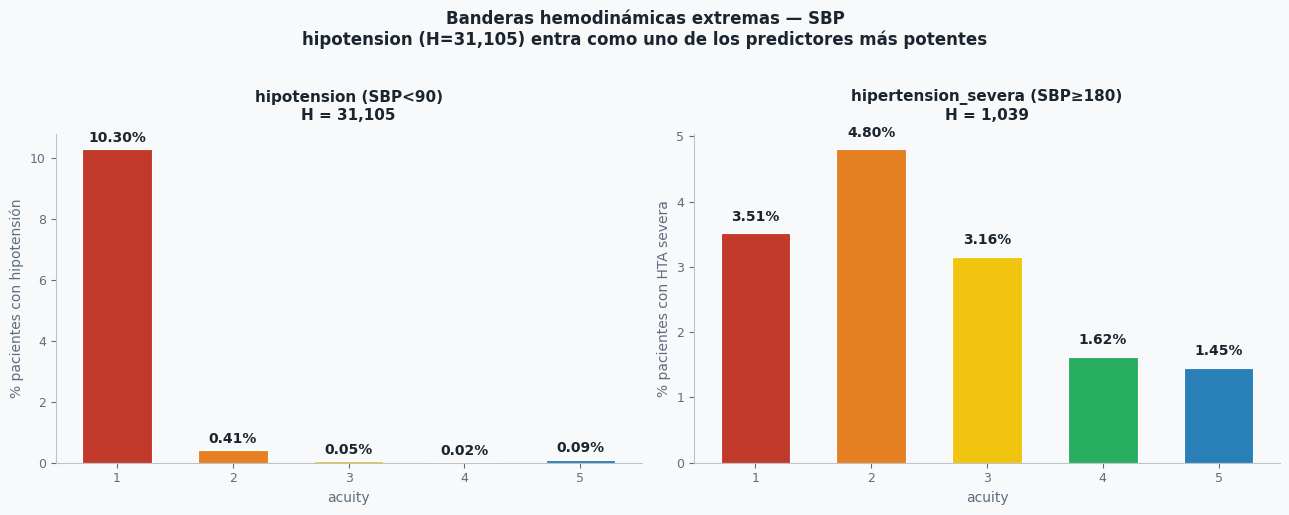

In [249]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor("#F8F9FA")

ax1 = axes[0]
ax1.set_facecolor("#F8F9FA")
pcts = resultados_bp["hipotension"]["pcts"]
bars = ax1.bar(ACUITY_LEVELS, pcts, color=PALETA_ACUITY,
               edgecolor="white", linewidth=0.8, width=0.6)
for bar, val in zip(bars, pcts):
    if val > 0:
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
                 f"{val:.2f}%", ha="center", va="bottom",
                 fontsize=10, fontweight="bold", color="#1A252F")

ax1.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
ax1.set_ylabel("% pacientes con hipotensión", fontsize=10, color="#5D6D7E")
ax1.set_title(f"hipotension (SBP<90)\nH = {resultados_bp['hipotension']['H']:,.0f}",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax1.spines[["top", "right"]].set_visible(False)
ax1.spines[["left", "bottom"]].set_color("#BDC3C7")
ax1.tick_params(colors="#5D6D7E", labelsize=9)
ax1.set_xticks(ACUITY_LEVELS)

ax2 = axes[1]
ax2.set_facecolor("#F8F9FA")
pcts_h = resultados_bp["hipertension_severa"]["pcts"]
bars2 = ax2.bar(ACUITY_LEVELS, pcts_h, color=PALETA_ACUITY,
                edgecolor="white", linewidth=0.8, width=0.6)
for bar, val in zip(bars2, pcts_h):
    if val > 0:
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.15,
                 f"{val:.2f}%", ha="center", va="bottom",
                 fontsize=10, fontweight="bold", color="#1A252F")

ax2.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
ax2.set_ylabel("% pacientes con HTA severa", fontsize=10, color="#5D6D7E")
ax2.set_title(f"hipertension_severa (SBP≥180)\nH = {resultados_bp['hipertension_severa']['H']:,.0f}",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax2.spines[["top", "right"]].set_visible(False)
ax2.spines[["left", "bottom"]].set_color("#BDC3C7")
ax2.tick_params(colors="#5D6D7E", labelsize=9)
ax2.set_xticks(ACUITY_LEVELS)

fig.suptitle(
    "Banderas hemodinámicas extremas — SBP\n"
    f"hipotension (H={resultados_bp['hipotension']['H']:,.0f}) entra como uno de los predictores más potentes",
    fontsize=12, fontweight="bold", color="#1A252F", y=1.02,
)

plt.tight_layout()
plt.show()


In [250]:
display(Markdown(f"""
**`hipotension` (SBP<90) — Entra al modelo (H={resultados_bp["hipotension"]["H"]:,.0f}).**
Una de las distribuciones más limpias del dataset:
{resultados_bp["hipotension"]["pcts"][0]:.2f}% en `acuity` 1 con caída casi vertical
hasta valores residuales en `acuity` 2-5. Con prevalencia
{resultados_bp["hipotension"]["prev"]:.2f}% es extremadamente específica — cuando se
activa, el paciente está casi con certeza en emergencia.

**`hipertension_severa` (SBP≥180) — Entra al modelo
(H={resultados_bp["hipertension_severa"]["H"]:,.0f}).**
Patrón no monótono — `acuity` 2 tiene el máximo
({resultados_bp["hipertension_severa"]["pcts"][1]:.2f}%) frente al
{resultados_bp["hipertension_severa"]["pcts"][0]:.2f}% de `acuity` 1, reflejando que la
crisis hipertensiva severa rara vez llega en parada y se clasifica como `acuity` 2 por
protocolo SET.
"""))



**`hipotension` (SBP<90) — Entra al modelo (H=31,105).**
Una de las distribuciones más limpias del dataset:
10.30% en `acuity` 1 con caída casi vertical
hasta valores residuales en `acuity` 2-5. Con prevalencia
0.76% es extremadamente específica — cuando se
activa, el paciente está casi con certeza en emergencia.

**`hipertension_severa` (SBP≥180) — Entra al modelo
(H=1,039).**
Patrón no monótono — `acuity` 2 tiene el máximo
(4.80%) frente al
3.51% de `acuity` 1, reflejando que la
crisis hipertensiva severa rara vez llega en parada y se clasifica como `acuity` 2 por
protocolo SET.


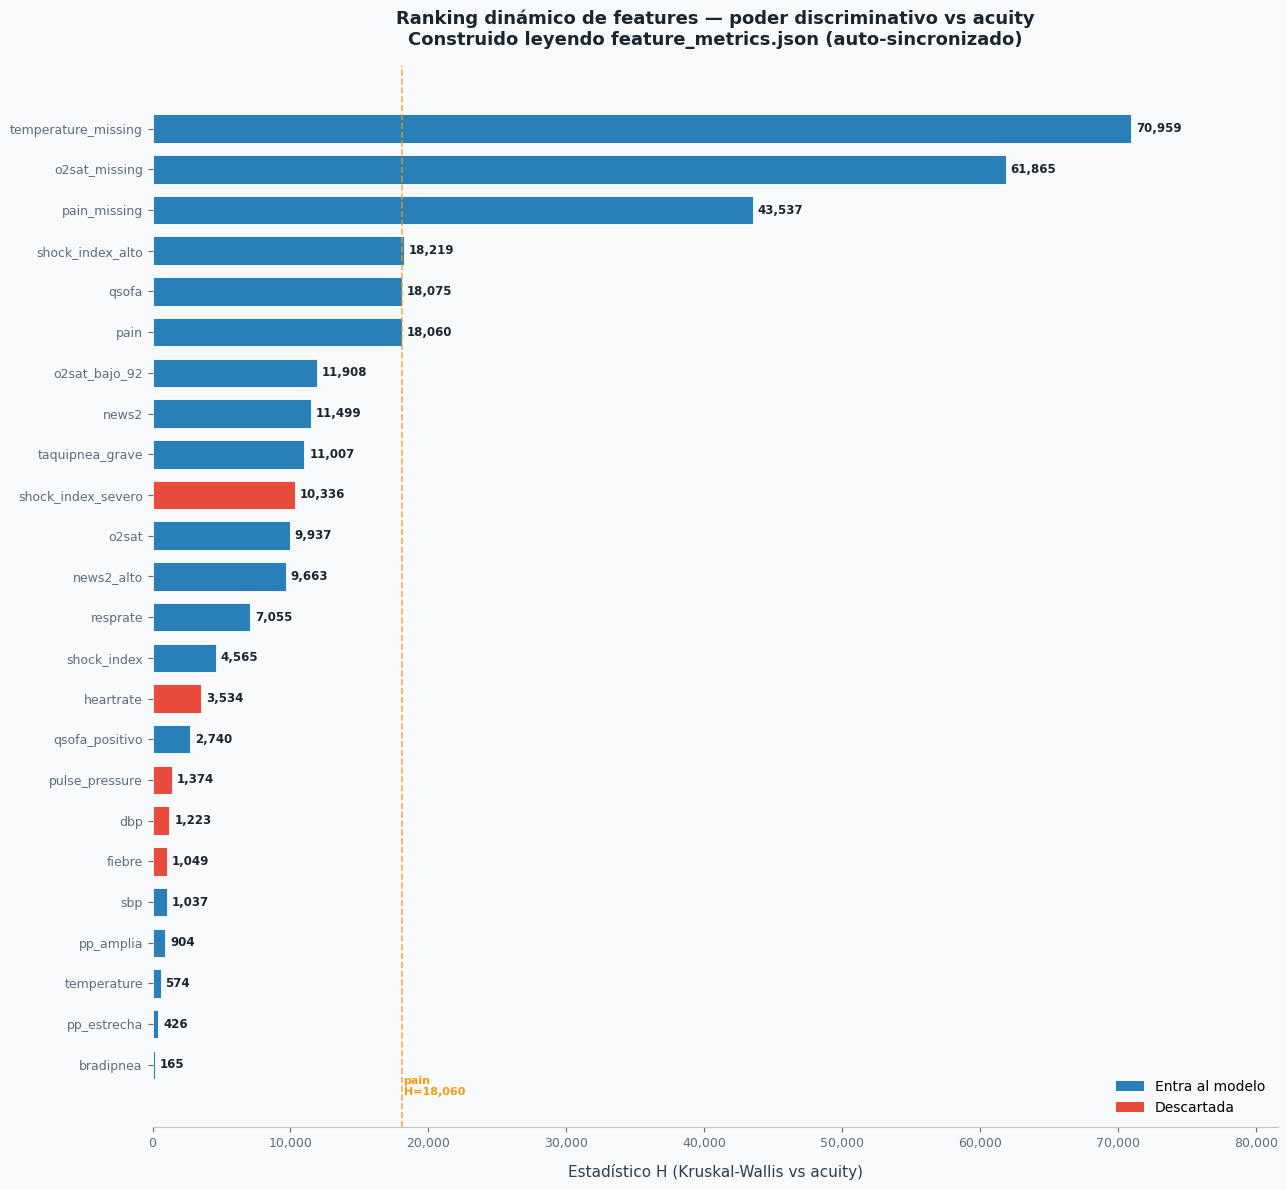


Features actualmente con H persistido: 24
  Entran:      19
  Descartadas: 5


In [251]:
# Resumen comparativo dinámico — leído de feature_metrics.json (NO hardcodeado)
# Cada vez que se calcula un H-stat lo persistimos con update_metrics_json,
# así este bloque siempre refleja el estado actual del pipeline.

GRUPO_FEATURE = {
    # Missingness
    "temperature_missing": "Missingness", "o2sat_missing": "Missingness",
    "pain_missing": "Missingness",
    # Vitales crudos
    "pain": "Vitales crudos", "o2sat": "Vitales crudos",
    "resprate": "Vitales crudos", "heartrate": "Vitales crudos",
    "dbp": "Vitales crudos", "sbp": "Vitales crudos",
    "temperature": "Vitales crudos",
    # Banderas clínicas
    "o2sat_bajo_92": "Banderas clínicas", "fiebre": "Banderas clínicas",
    "taquipnea_grave": "Banderas clínicas", "bradipnea": "Banderas clínicas",
    # Scores
    "qsofa": "Scores", "qsofa_positivo": "Scores",
    "news2": "Scores", "news2_alto": "Scores",
    "shock_index": "Scores", "shock_index_alto": "Scores",
    "shock_index_severo": "Scores", "pulse_pressure": "Scores",
    "pp_estrecha": "Scores", "pp_amplia": "Scores",
}

# Estado por defecto: features registradas en feature_metrics.json se asumen "entra"
# salvo que su decision_final ya esté marcada como "descartada" (lo hace 05b).
metricas = leer_metricas()

filas = []
for feat, info in metricas.items():
    H = info.get("H")
    if H is None or feat not in GRUPO_FEATURE:
        continue
    estado = "descartado" if info.get("decision_final") == "descartada" else "entra"
    filas.append({
        "feature": feat,
        "H":       int(round(H)),
        "grupo":   GRUPO_FEATURE[feat],
        "estado":  estado,
    })

df_resumen = pd.DataFrame(filas).sort_values("H", ascending=True).reset_index(drop=True)

color_map = {"entra": "#2980B9", "descartado": "#E74C3C"}
colores   = [color_map[e] for e in df_resumen["estado"]]

fig, ax = plt.subplots(figsize=(13, 12))
fig.patch.set_facecolor("#F8F9FA")
ax.set_facecolor("#F8F9FA")

bars = ax.barh(df_resumen["feature"], df_resumen["H"],
               color=colores, edgecolor="white", linewidth=0.6, height=0.7)

for bar, val in zip(bars, df_resumen["H"]):
    ax.text(bar.get_width() + max(df_resumen["H"]) * 0.005,
            bar.get_y() + bar.get_height() / 2,
            f"{val:,}", va="center", ha="left",
            fontsize=8.5, fontweight="bold", color="#1A252F")

H_pain_ref_ = metricas.get("pain", {}).get("H", 0) or 0
ax.axvline(x=H_pain_ref_, color="#F39C12", linewidth=1.2, linestyle="--", alpha=0.8)
ax.text(H_pain_ref_ + max(df_resumen["H"]) * 0.002, -0.8,
        f"pain\nH={H_pain_ref_:,.0f}", color="#F39C12",
        fontsize=8, va="bottom", fontweight="bold")

ax.set_xlabel("Estadístico H (Kruskal-Wallis vs acuity)", fontsize=11, color="#2C3E50", labelpad=10)
ax.set_title(
    "Ranking dinámico de features — poder discriminativo vs acuity\n"
    "Construido leyendo feature_metrics.json (auto-sincronizado)",
    fontsize=13, fontweight="bold", color="#1A252F", pad=15,
)

leyenda = [
    mpatches.Patch(facecolor="#2980B9", label="Entra al modelo"),
    mpatches.Patch(facecolor="#E74C3C", label="Descartada"),
]
ax.legend(handles=leyenda, loc="lower right", frameon=False, fontsize=10)

ax.spines[["top", "right", "left"]].set_visible(False)
ax.spines["bottom"].set_color("#BDC3C7")
ax.tick_params(axis="both", colors="#5D6D7E", labelsize=9)
ax.set_xlim(0, max(df_resumen["H"]) * 1.15)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{int(x):,}"))

plt.tight_layout()
plt.show()

print(f"\nFeatures actualmente con H persistido: {len(df_resumen)}")
print(f"  Entran:      {(df_resumen['estado'] == 'entra').sum()}")
print(f"  Descartadas: {(df_resumen['estado'] == 'descartado').sum()}")


## Features de vitales y scores — visión global

### Respiratorio
| Feature | Tipo |
|---|---|
| `resprate` | Continuo |
| `taquipnea_grave` (>24 rpm) | Bandera binaria |
| `o2sat` | Continuo |
| `o2sat_bajo_92` (<92%) | Bandera binaria |
| `o2sat_missing` | Missingness |

### Hemodinámico
| Feature | Tipo |
|---|---|
| `sbp` | Continuo |
| `dbp` | Continuo |
| `pulse_pressure` (sbp-dbp) | Derivado continuo |
| `heartrate` | Continuo |
| `taquicardia` (>100 lpm) | Bandera binaria |
| `hipotension` (SBP<90) | Bandera binaria |
| `hipertension_severa` (SBP≥180) | Bandera binaria |
| `shock_index_alto` (≥1.0) | Bandera binaria |
| `shock_index_severo` (≥1.4) | Bandera binaria |
| `shock_oculto_anciano` (≥65 + SI≥0.85) | Bandera binaria |

### Temperatura
| Feature | Tipo |
|---|---|
| `fiebre` (≥100.4°F) | Bandera binaria |
| `temperature_missing` | Missingness |

### Dolor / Consciencia
| Feature | Tipo |
|---|---|
| `pain` | Continuo |
| `pain_missing` | Missingness / proxy consciencia |

### Scores compuestos
| Feature | Tipo |
|---|---|
| `news2` | Score continuo (0-20) |
| `news2_alto` (≥7) | Bandera binaria |
| `qsofa` | Score continuo (0-3) |
| `qsofa_positivo` (≥2) | Bandera binaria |
| `sirs_positivo` (≥2 criterios) | Bandera binaria |
| `shock_index_alto` (≥1.0) | Bandera binaria |
| `zona_verde` (SET) | Bandera binaria |

### Carga fisiológica global
| Feature | Tipo |
|---|---|
| `n_vitales_anomalos` | Recuento (0-5) |
| `vitales_criticos` (≥2 anómalos) | Bandera binaria |

VARIABLES DEMOGRAFICAS Y LOGISTICAS

In [252]:
# Bloque 2: Datos demograficos y logisticos
# Empezamos con age — la variable demografica mas discriminativa esperada

H_age, pval_age = kruskal(*[
    df.loc[df['acuity'] == k, 'age'].dropna().values
    for k in ACUITY_LEVELS
])
H_age = float(H_age)

update_metrics_json('age', H=round(H_age, 4), tipo='continua')

print(f'age  ->  H = {H_age:,.0f}  |  p = {pval_age:.2e}\n')
print('Mediana de age por clase de acuity:\n')
_med_age = df.groupby('acuity')['age'].median().round(1)
print(_med_age.to_string())
_med_age_a1 = float(_med_age.get(1, float('nan')))
_med_age_a4 = float(_med_age.get(4, float('nan')))


age  ->  H = 24,503  |  p = 0.00e+00

Mediana de age por clase de acuity:

acuity
1    62.0
2    60.0
3    51.0
4    37.0
5    36.0


C:\Users\CARLOS\AppData\Local\Temp\ipykernel_27420\3943441554.py:16: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax1.boxplot(


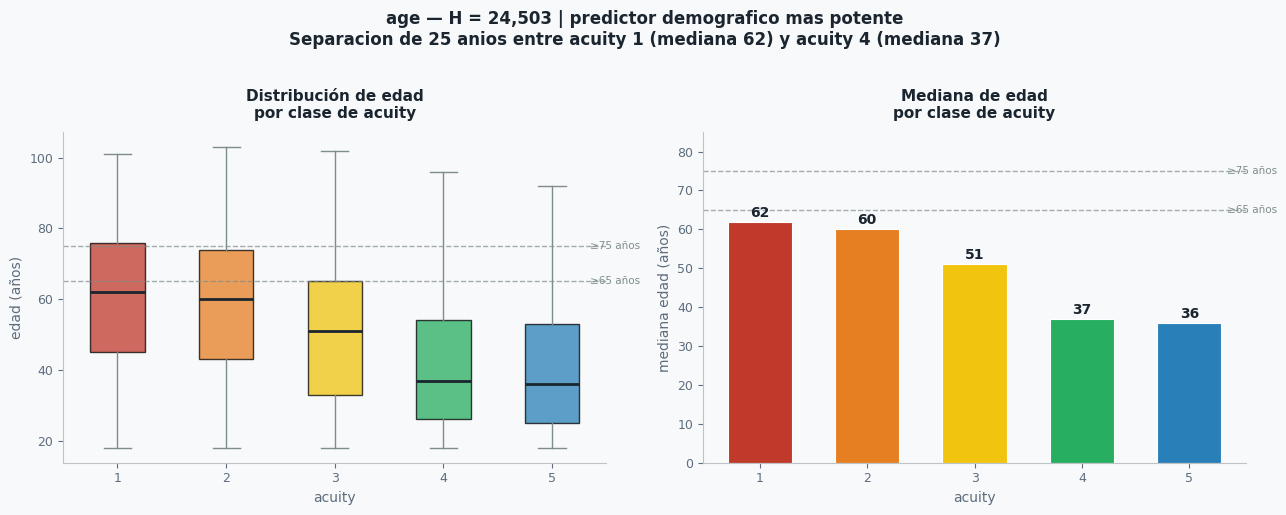

In [253]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor("#F8F9FA")

acuity_levels = [1, 2, 3, 4, 5]
colores_barra = ["#C0392B", "#E67E22", "#F1C40F", "#27AE60", "#2980B9"]

# Izquierda: boxplot age por acuity
ax1 = axes[0]
ax1.set_facecolor("#F8F9FA")

grupos = [
    df.loc[df["acuity"] == k, "age"].dropna().values
    for k in acuity_levels
]

bp = ax1.boxplot(
    grupos,
    labels=["1", "2", "3", "4", "5"],
    patch_artist=True,
    medianprops=dict(color="#1A252F", linewidth=2),
    whiskerprops=dict(color="#7F8C8D", linewidth=1),
    capprops=dict(color="#7F8C8D", linewidth=1),
    boxprops=dict(linewidth=1),
    showfliers=False,
)
for patch, color in zip(bp["boxes"], colores_barra):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

# Líneas de referencia umbrales geriátricos
for umbral, label in [(65, "≥65 años"), (75, "≥75 años")]:
    ax1.axhline(umbral, color="#7F8C8D", linewidth=1, linestyle="--", alpha=0.7)
    ax1.text(5.35, umbral, label, fontsize=7.5, color="#7F8C8D", va="center")

ax1.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
ax1.set_ylabel("edad (años)", fontsize=10, color="#5D6D7E")
ax1.set_title("Distribución de edad\npor clase de acuity",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax1.spines[["top", "right"]].set_visible(False)
ax1.spines[["left", "bottom"]].set_color("#BDC3C7")
ax1.tick_params(colors="#5D6D7E", labelsize=9)

# Derecha: mediana age por acuity
ax2 = axes[1]
ax2.set_facecolor("#F8F9FA")

medianas = [float(df.loc[df['acuity'] == k, 'age'].median()) for k in ACUITY_LEVELS]
bars = ax2.bar(acuity_levels, medianas, color=colores_barra,
               edgecolor="white", linewidth=0.8, width=0.6)

for bar, val in zip(bars, medianas):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f"{val:.0f}", ha="center", va="bottom",
             fontsize=10, fontweight="bold", color="#1A252F")

for umbral, label in [(65, "≥65 años"), (75, "≥75 años")]:
    ax2.axhline(umbral, color="#7F8C8D", linewidth=1, linestyle="--", alpha=0.7)
    ax2.text(5.35, umbral, label, fontsize=7.5, color="#7F8C8D", va="center")

ax2.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
ax2.set_ylabel("mediana edad (años)", fontsize=10, color="#5D6D7E")
ax2.set_title("Mediana de edad\npor clase de acuity",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax2.spines[["top", "right"]].set_visible(False)
ax2.spines[["left", "bottom"]].set_color("#BDC3C7")
ax2.tick_params(colors="#5D6D7E", labelsize=9)
ax2.set_xticks(acuity_levels)
ax2.set_ylim(0, 85)

fig.suptitle(
    f"age — H = {H_age:,.0f} | predictor demografico mas potente\n"
    f"Separacion de {abs(medianas[0]-medianas[3]):.0f} anios entre acuity 1 (mediana {medianas[0]:.0f}) y acuity 4 (mediana {medianas[3]:.0f})",
    fontsize=12, fontweight="bold", color="#1A252F", y=1.02
)

plt.tight_layout()
plt.show()

In [254]:
# Banderas de edad — umbrales geriatricos

df['anciano']       = (df['age'].fillna(0) >= 65).astype('int8')
df['anciano_mayor'] = (df['age'].fillna(0) >= 75).astype('int8')

print(f"{'Feature':<20} {'H-stat':>8}  {'p-value':>12}  {'Prevalencia':>12}  {'n casos':>8}")
print('─' * 70)

H_edad: dict[str, float] = {}
pcts_edad_x_acuity: dict[str, list] = {}

for col in ['anciano', 'anciano_mayor']:
    grupos = [df.loc[df['acuity'] == k, col].dropna().values for k in ACUITY_LEVELS]
    stat, pval = kruskal(*grupos)
    H_edad[col] = float(stat)
    prev = df[col].mean() * 100
    n    = int(df[col].sum())
    pcts_edad_x_acuity[col] = [
        float(df.loc[df['acuity'] == k, col].mean() * 100)
        for k in ACUITY_LEVELS
    ]
    update_metrics_json(col, H=round(float(stat), 4), tipo='binaria')
    print(f'{col:<20} {stat:>8,.0f}  {pval:>12.2e}  {prev:>11.2f}%  {n:>8,}')

print(f"{'age (continuo)':<20} {H_age:>8,.0f}  {'—':>12}  {'—':>12}  {'—':>8}")

print('\n% por clase de acuity:\n')
_resumen_edad = pd.DataFrame({
    'anciano (>=65)':       (df.groupby('acuity')['anciano'].mean() * 100).round(2),
    'anciano_mayor (>=75)': (df.groupby('acuity')['anciano_mayor'].mean() * 100).round(2),
})
print(_resumen_edad.to_string())


Feature                H-stat       p-value   Prevalencia   n casos
──────────────────────────────────────────────────────────────────────
anciano                16,612      0.00e+00        31.30%   130,885
anciano_mayor          11,061      0.00e+00        17.26%    72,174
age (continuo)         24,503             —             —         —

% por clase de acuity:

        anciano (>=65)  anciano_mayor (>=75)
acuity                                      
1                45.56                 27.51
2                41.10                 23.66
3                26.36                 13.93
4                11.23                  4.20
5                10.73                  3.27


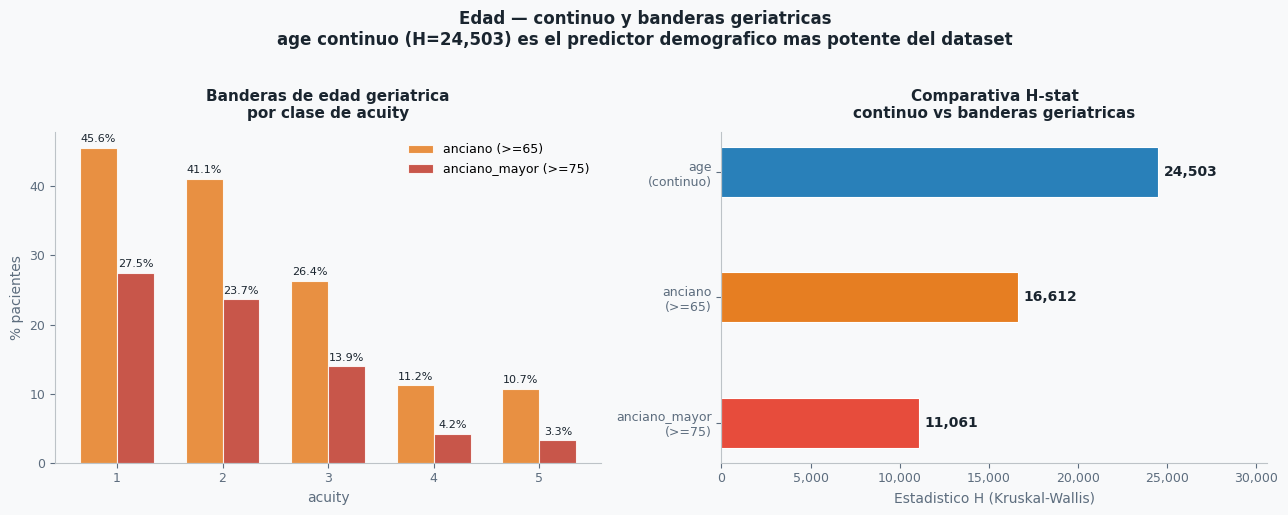

In [255]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#F8F9FA')

pcts_anc  = pcts_edad_x_acuity['anciano']
pcts_anc2 = pcts_edad_x_acuity['anciano_mayor']

x = np.arange(len(ACUITY_LEVELS))
width = 0.35

ax1 = axes[0]
ax1.set_facecolor('#F8F9FA')

bars1 = ax1.bar(x - width/2, pcts_anc,  width, label='anciano (>=65)',
                color='#E67E22', edgecolor='white', linewidth=0.8, alpha=0.85)
bars2 = ax1.bar(x + width/2, pcts_anc2, width, label='anciano_mayor (>=75)',
                color='#C0392B', edgecolor='white', linewidth=0.8, alpha=0.85)

for bar, val in zip(bars1, pcts_anc):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=8, color='#1A252F')
for bar, val in zip(bars2, pcts_anc2):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f'{val:.1f}%', ha='center', va='bottom', fontsize=8, color='#1A252F')

ax1.set_xlabel('acuity', fontsize=10, color='#5D6D7E')
ax1.set_ylabel('% pacientes', fontsize=10, color='#5D6D7E')
ax1.set_title('Banderas de edad geriatrica\npor clase de acuity',
              fontsize=11, fontweight='bold', color='#1A252F', pad=10)
ax1.set_xticks(x)
ax1.set_xticklabels(ACUITY_LEVELS)
ax1.legend(frameon=False, fontsize=9)
ax1.spines[['top', 'right']].set_visible(False)
ax1.spines[['left', 'bottom']].set_color('#BDC3C7')
ax1.tick_params(colors='#5D6D7E', labelsize=9)

ax2 = axes[1]
ax2.set_facecolor('#F8F9FA')

features_h = ['anciano_mayor\n(>=75)', 'anciano\n(>=65)', 'age\n(continuo)']
hstats_h   = [H_edad['anciano_mayor'], H_edad['anciano'], H_age]
cols_h     = ['#E74C3C', '#E67E22', '#2980B9']

bars3 = ax2.barh(features_h, hstats_h, color=cols_h,
                 edgecolor='white', linewidth=0.8, height=0.4)
for bar, val in zip(bars3, hstats_h):
    ax2.text(bar.get_width() + 300, bar.get_y() + bar.get_height() / 2,
             f'{val:,.0f}', va='center', ha='left',
             fontsize=10, fontweight='bold', color='#1A252F')

ax2.set_xlabel('Estadistico H (Kruskal-Wallis)', fontsize=10, color='#5D6D7E')
ax2.set_title('Comparativa H-stat\ncontinuo vs banderas geriatricas',
              fontsize=11, fontweight='bold', color='#1A252F', pad=10)
ax2.set_xlim(0, H_age * 1.25)
ax2.spines[['top', 'right']].set_visible(False)
ax2.spines[['left', 'bottom']].set_color('#BDC3C7')
ax2.tick_params(colors='#5D6D7E', labelsize=9)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

fig.suptitle(
    f'Edad — continuo y banderas geriatricas\n'
    f'age continuo (H={H_age:,.0f}) es el predictor demografico mas potente del dataset',
    fontsize=12, fontweight='bold', color='#1A252F', y=1.02
)
plt.tight_layout()
plt.show()


In [256]:
display(Markdown(
    f'**age** (H={H_age:,.0f}) es el predictor demografico mas potente del dataset, '
    f'con una separacion de **{abs(_med_age_a1 - _med_age_a4):.0f} anos** entre la mediana '
    f'de acuity 1 ({_med_age_a1:.0f} anos) y acuity 4 ({_med_age_a4:.0f} anos). '
    f'El patron es perfectamente monotono y el continuo supera a ambas banderas '
    f'(anciano H={H_edad["anciano"]:,.0f}, anciano_mayor H={H_edad["anciano_mayor"]:,.0f}). '
    f'**Las tres features de edad entran al modelo.**'
))


**age** (H=24,503) es el predictor demografico mas potente del dataset, con una separacion de **25 anos** entre la mediana de acuity 1 (62 anos) y acuity 4 (37 anos). El patron es perfectamente monotono y el continuo supera a ambas banderas (anciano H=16,612, anciano_mayor H=11,061). **Las tres features de edad entran al modelo.**

In [257]:
# Gender — variable categorica binaria (M/F)

print('Distribucion de gender en el dataset:\n')
print(df['gender'].value_counts().to_string())
print('\n% por valor:\n')
print((df['gender'].value_counts(normalize=True) * 100).round(2).to_string())

print('\n% de cada acuity dentro de cada genero:\n')
_cross_gender = pd.crosstab(df['gender'], df['acuity'], normalize='index') * 100
print(_cross_gender.round(2).to_string())

df['gender_num'] = (df['gender'] == 'M').astype('int8')

H_gender, pval_gender = kruskal(*[
    df.loc[df['acuity'] == k, 'gender_num'].values
    for k in ACUITY_LEVELS
])
H_gender = float(H_gender)

update_metrics_json('gender', H=round(H_gender, 4), tipo='categorica')

print(f'\ngender  ->  H = {H_gender:,.0f}  |  p = {pval_gender:.2e}')

_urgentes_M = float(_cross_gender.loc['M', [c for c in [1, 2] if c in _cross_gender.columns]].sum())
_urgentes_F = float(_cross_gender.loc['F', [c for c in [1, 2] if c in _cross_gender.columns]].sum())


Distribucion de gender en el dataset:

gender
F    227007
M    191093

% por valor:

gender
F    54.29
M    45.71

% de cada acuity dentro de cada genero:

acuity     1      2      3     4     5
gender                                
F       5.31  31.09  56.72  6.65  0.23
M       6.27  36.02  50.39  7.02  0.30

gender  ->  H = 1,735  |  p = 0.00e+00


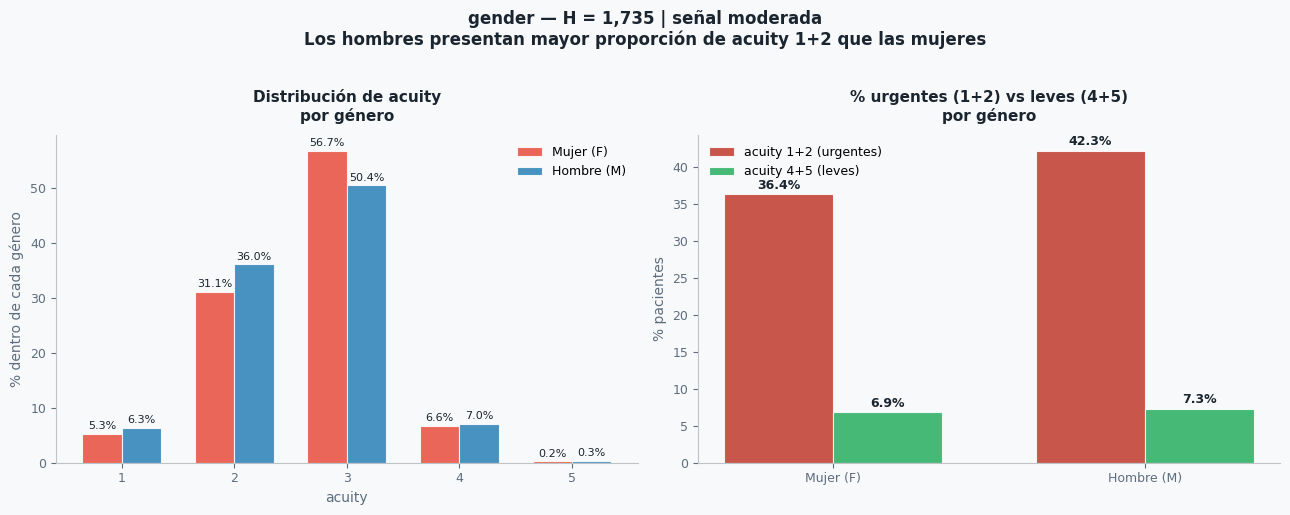

In [258]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor("#F8F9FA")

acuity_levels = [1, 2, 3, 4, 5]

# Izquierda: distribución de acuity por género
ax1 = axes[0]
ax1.set_facecolor("#F8F9FA")

cross = pd.crosstab(df["gender"], df["acuity"], normalize="index") * 100

x = np.arange(len(acuity_levels))
width = 0.35

bars1 = ax1.bar(x - width/2, cross.loc["F"].values, width, label="Mujer (F)",
                color="#E74C3C", edgecolor="white", linewidth=0.8, alpha=0.85)
bars2 = ax1.bar(x + width/2, cross.loc["M"].values, width, label="Hombre (M)",
                color="#2980B9", edgecolor="white", linewidth=0.8, alpha=0.85)

for bar, val in zip(bars1, cross.loc["F"].values):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f"{val:.1f}%", ha="center", va="bottom", fontsize=8, color="#1A252F")
for bar, val in zip(bars2, cross.loc["M"].values):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f"{val:.1f}%", ha="center", va="bottom", fontsize=8, color="#1A252F")

ax1.set_xlabel("acuity", fontsize=10, color="#5D6D7E")
ax1.set_ylabel("% dentro de cada género", fontsize=10, color="#5D6D7E")
ax1.set_title("Distribución de acuity\npor género",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax1.set_xticks(x)
ax1.set_xticklabels(acuity_levels)
ax1.legend(frameon=False, fontsize=9)
ax1.spines[["top", "right"]].set_visible(False)
ax1.spines[["left", "bottom"]].set_color("#BDC3C7")
ax1.tick_params(colors="#5D6D7E", labelsize=9)

# Derecha: % acuity 1+2 por género
ax2 = axes[1]
ax2.set_facecolor("#F8F9FA")

urgentes = pd.DataFrame({
    "género": ["Mujer (F)", "Hombre (M)"],
    "acuity 1+2": [
        cross.loc["F", [1, 2]].sum(),
        cross.loc["M", [1, 2]].sum(),
    ],
    "acuity 4+5": [
        cross.loc["F", [4, 5]].sum(),
        cross.loc["M", [4, 5]].sum(),
    ],
})

x2 = np.arange(2)
bars3 = ax2.bar(x2 - width/2, urgentes["acuity 1+2"], width,
                label="acuity 1+2 (urgentes)",
                color="#C0392B", edgecolor="white", linewidth=0.8, alpha=0.85)
bars4 = ax2.bar(x2 + width/2, urgentes["acuity 4+5"], width,
                label="acuity 4+5 (leves)",
                color="#27AE60", edgecolor="white", linewidth=0.8, alpha=0.85)

for bar, val in zip(bars3, urgentes["acuity 1+2"]):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             f"{val:.1f}%", ha="center", va="bottom",
             fontsize=9, fontweight="bold", color="#1A252F")
for bar, val in zip(bars4, urgentes["acuity 4+5"]):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
             f"{val:.1f}%", ha="center", va="bottom",
             fontsize=9, fontweight="bold", color="#1A252F")

ax2.set_xticks(x2)
ax2.set_xticklabels(urgentes["género"], fontsize=10)
ax2.set_ylabel("% pacientes", fontsize=10, color="#5D6D7E")
ax2.set_title("% urgentes (1+2) vs leves (4+5)\npor género",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax2.legend(frameon=False, fontsize=9)
ax2.spines[["top", "right"]].set_visible(False)
ax2.spines[["left", "bottom"]].set_color("#BDC3C7")
ax2.tick_params(colors="#5D6D7E", labelsize=9)

fig.suptitle(
    f"gender — H = {H_gender:,.0f} | señal moderada\n"
    "Los hombres presentan mayor proporción de acuity 1+2 que las mujeres",
    fontsize=12, fontweight="bold", color="#1A252F", y=1.02
)

plt.tight_layout()
plt.show()

In [259]:
display(Markdown(
    f'**gender** (H={H_gender:,.0f}) entra al modelo como variable categorica con senal moderada. '
    f'Los hombres presentan mayor proporcion de casos urgentes (acuity 1+2: **{_urgentes_M:.1f}%**) '
    f'frente a las mujeres (**{_urgentes_F:.1f}%**), diferencia de '
    f'**{abs(_urgentes_M - _urgentes_F):.1f}** puntos porcentuales. '
    f'**Entra al modelo como categorica.**'
))


**gender** (H=1,735) entra al modelo como variable categorica con senal moderada. Los hombres presentan mayor proporcion de casos urgentes (acuity 1+2: **42.3%**) frente a las mujeres (**36.4%**), diferencia de **5.9** puntos porcentuales. **Entra al modelo como categorica.**

In [260]:
# Race — variable categórica con 6 grupos (agrupada en cleaner.py)
# Explorar si la etnia tiene poder discriminativo sobre acuity

print("Distribución de race en el dataset:\n")
print(df["race"].value_counts().to_string())
print(f"\n% por grupo:\n")
print((df["race"].value_counts(normalize=True) * 100).round(2).to_string())

print(f"\n% de cada acuity dentro de cada grupo étnico:\n")
cross_race = pd.crosstab(df["race"], df["acuity"], normalize="index") * 100
print(cross_race.round(2).to_string())

# H-stat: codificamos numéricamente para Kruskal-Wallis
# Usamos la proporción de acuity 1+2 como proxy de urgencia por grupo
from scipy.stats import chi2_contingency

tabla = pd.crosstab(df["race"], df["acuity"])
chi2, pval, dof, _ = chi2_contingency(tabla)

print(f"\nChi2 (race vs acuity)  →  χ² = {chi2:,.0f}  |  p = {pval:.2e}  |  gl = {dof}")
print(f"\n% acuity 1+2 por grupo étnico:\n")
urgentes_race = (cross_race[[1, 2]].sum(axis=1)).sort_values(ascending=False)
print(urgentes_race.round(2).to_string())

Distribución de race en el dataset:

race
WHITE       244093
BLACK        92168
HISPANIC     35205
OTHER        22136
ASIAN        18321
UNKNOWN       6177

% por grupo:

race
WHITE       58.38
BLACK       22.04
HISPANIC     8.42
OTHER        5.29
ASIAN        4.38
UNKNOWN      1.48

% de cada acuity dentro de cada grupo étnico:

acuity        1      2      3     4     5
race                                     
ASIAN      4.80  29.81  55.14  9.82  0.41
BLACK      4.14  27.89  58.48  9.15  0.34
HISPANIC   3.64  26.04  61.06  8.98  0.28
OTHER      5.01  29.09  55.96  9.54  0.40
UNKNOWN   28.10  32.22  33.79  5.47  0.42
WHITE      6.23  37.13  51.25  5.19  0.20

Chi2 (race vs acuity)  →  χ² = 12,851  |  p = 0.00e+00  |  gl = 20

% acuity 1+2 por grupo étnico:

race
UNKNOWN     60.32
WHITE       43.36
ASIAN       34.62
OTHER       34.10
BLACK       32.03
HISPANIC    29.68


A pesar de que la prueba Chi-cuadrado arrojó una alta significancia estadística (χ²=12,851, p≈0), la variable race se excluye del modelo por razones de equidad algorítmica. Las diferencias observadas en la distribución de acuity entre grupos étnicos reflejan desigualdades estructurales en el acceso al sistema sanitario — patrones de consulta tardía, barreras idiomáticas o socioeconómicas — y no diferencias reales en la gravedad clínica intrínseca del paciente. Incorporar race como feature permitiría al modelo aprender y perpetuar estos sesgos sistémicos, clasificando a pacientes de determinados grupos étnicos como menos urgentes por el mero hecho de pertenecer a esa población, independientemente de su estado fisiológico real. La única excepción es la categoría UNKNOWN, que se transforma en la bandera binaria identidad_desconocida: en este contexto clínico, la incapacidad de identificar al paciente en el minuto 0 no tiene contenido étnico sino que opera exclusivamente como marcador de ausencia informativa — un proxy de alteración del nivel de consciencia análogo a pain_missing, con el mismo respaldo clínico y estadístico.

In [261]:
df['identidad_desconocida'] = (df['race'] == 'UNKNOWN').astype('int8')

H_id_desc, pval_id_desc = kruskal(*[
    df.loc[df['acuity'] == k, 'identidad_desconocida'].values
    for k in ACUITY_LEVELS
])
H_id_desc    = float(H_id_desc)
prev_id_desc = df['identidad_desconocida'].mean() * 100
n_id_desc    = int(df['identidad_desconocida'].sum())

update_metrics_json('identidad_desconocida', H=round(H_id_desc, 4), tipo='binaria')

print(f'identidad_desconocida  ->  H = {H_id_desc:,.0f}  |  p = {pval_id_desc:.2e}  |  '
      f'prevalencia = {prev_id_desc:.2f}%  |  n = {n_id_desc:,}\n')
print('% por clase de acuity:\n')
print((df.groupby('acuity')['identidad_desconocida'].mean() * 100).round(2).to_string())

_pcts_id_desc = [
    float(df.loc[df['acuity'] == k, 'identidad_desconocida'].mean() * 100)
    for k in ACUITY_LEVELS
]


identidad_desconocida  ->  H = 5,949  |  p = 0.00e+00  |  prevalencia = 1.48%  |  n = 6,177

% por clase de acuity:

acuity
1    7.23
2    1.43
3    0.93
4    1.19
5    2.36


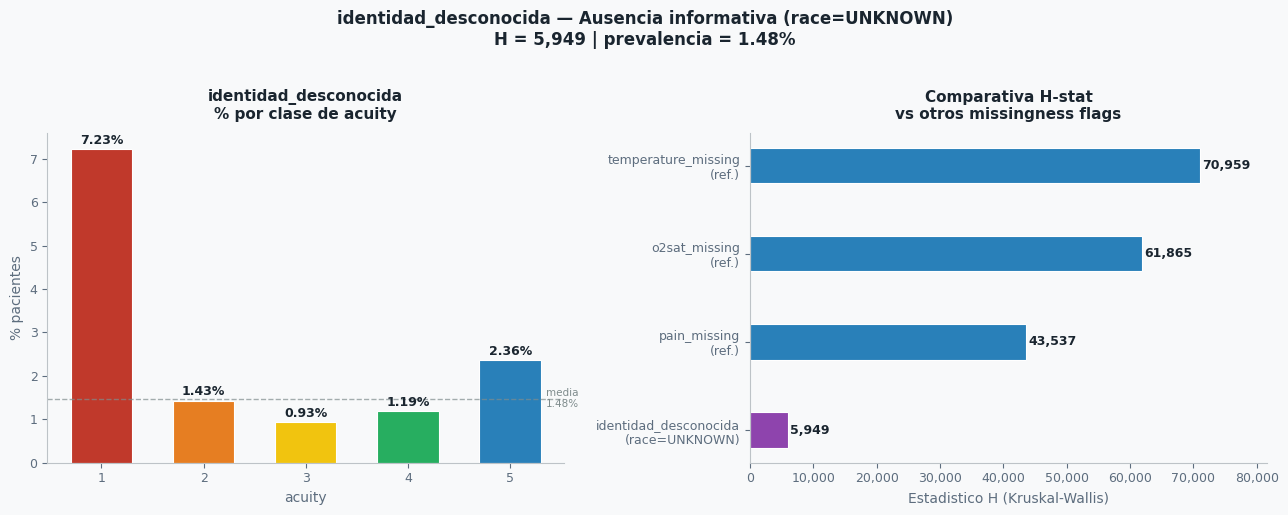

In [262]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('#F8F9FA')

ax1 = axes[0]
ax1.set_facecolor('#F8F9FA')
pcts = (df.groupby('acuity')['identidad_desconocida'].mean() * 100).round(2).values

bars = ax1.bar(ACUITY_LEVELS, pcts, color=PALETA_ACUITY,
               edgecolor='white', linewidth=0.8, width=0.6)
for bar, val in zip(bars, pcts):
    if val > 0:
        ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.05,
                 f'{val:.2f}%', ha='center', va='bottom',
                 fontsize=9, fontweight='bold', color='#1A252F')

ax1.axhline(prev_id_desc, color='#7F8C8D', linewidth=1, linestyle='--', alpha=0.7)
ax1.text(5.35, prev_id_desc, f'media\n{prev_id_desc:.2f}%',
         fontsize=7.5, color='#7F8C8D', va='center')
ax1.set_xlabel('acuity', fontsize=10, color='#5D6D7E')
ax1.set_ylabel('% pacientes', fontsize=10, color='#5D6D7E')
ax1.set_title('identidad_desconocida\n% por clase de acuity',
              fontsize=11, fontweight='bold', color='#1A252F', pad=10)
ax1.spines[['top', 'right']].set_visible(False)
ax1.spines[['left', 'bottom']].set_color('#BDC3C7')
ax1.tick_params(colors='#5D6D7E', labelsize=9)
ax1.set_xticks(ACUITY_LEVELS)

ax2 = axes[1]
ax2.set_facecolor('#F8F9FA')
metricas = leer_metricas()
_ref_H = {f: float((metricas.get(f) or {}).get('H') or 0)
          for f in ['pain_missing', 'o2sat_missing', 'temperature_missing']}
features_ref = ['identidad_desconocida\n(race=UNKNOWN)'] + [f'{f}\n(ref.)' for f in _ref_H]
hstats_ref   = [H_id_desc] + list(_ref_H.values())
cols_ref     = ['#8E44AD', '#2980B9', '#2980B9', '#2980B9']

bars2 = ax2.barh(features_ref, hstats_ref, color=cols_ref,
                 edgecolor='white', linewidth=0.8, height=0.4)
for bar, val in zip(bars2, hstats_ref):
    ax2.text(bar.get_width() + 400, bar.get_y() + bar.get_height() / 2,
             f'{val:,.0f}', va='center', ha='left',
             fontsize=9, fontweight='bold', color='#1A252F')

ax2.set_xlabel('Estadistico H (Kruskal-Wallis)', fontsize=10, color='#5D6D7E')
ax2.set_title('Comparativa H-stat\nvs otros missingness flags',
              fontsize=11, fontweight='bold', color='#1A252F', pad=10)
ax2.set_xlim(0, max(hstats_ref) * 1.15)
ax2.spines[['top', 'right']].set_visible(False)
ax2.spines[['left', 'bottom']].set_color('#BDC3C7')
ax2.tick_params(colors='#5D6D7E', labelsize=9)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

fig.suptitle(
    f'identidad_desconocida — Ausencia informativa (race=UNKNOWN)\n'
    f'H = {H_id_desc:,.0f} | prevalencia = {prev_id_desc:.2f}%',
    fontsize=12, fontweight='bold', color='#1A252F', y=1.02
)
plt.tight_layout()
plt.show()


In [263]:
# arrival_transport — cómo llegó el paciente al servicio de urgencias
# Variable logística con alto valor predictivo esperado
# Ambulancia vs helicóptero vs a pie reflejan gravedad percibida pre-hospitalaria

print("Distribución de arrival_transport:\n")
print(df["arrival_transport"].value_counts().to_string())
print(f"\n% por modalidad:\n")
print((df["arrival_transport"].value_counts(normalize=True) * 100).round(2).to_string())

print(f"\n% de cada acuity por modalidad de transporte:\n")
cross_tr = pd.crosstab(df["arrival_transport"], df["acuity"], normalize="index") * 100
print(cross_tr.round(2).to_string())

tabla_tr = pd.crosstab(df["arrival_transport"], df["acuity"])
chi2, pval, dof, _ = chi2_contingency(tabla_tr)
print(f"\nChi2  →  χ² = {chi2:,.0f}  |  p = {pval:.2e}  |  gl = {dof}")

print(f"\n% acuity 1+2 por modalidad:\n")
urgentes_tr = (cross_tr[[1, 2]].sum(axis=1)).sort_values(ascending=False)
print(urgentes_tr.round(2).to_string())

Distribución de arrival_transport:

arrival_transport
WALK IN       251464
AMBULANCE     150426
UNKNOWN        14418
OTHER           1257
HELICOPTER       535

% por modalidad:

arrival_transport
WALK IN       60.14
AMBULANCE     35.98
UNKNOWN        3.45
OTHER          0.30
HELICOPTER     0.13

% de cada acuity por modalidad de transporte:

acuity                 1      2      3     4     5
arrival_transport                                 
AMBULANCE           8.35  45.89  43.93  1.79  0.04
HELICOPTER         61.68  35.70   2.62  0.00  0.00
OTHER               4.85  36.75  49.72  8.35  0.32
UNKNOWN            20.43  29.43  42.51  6.78  0.85
WALK IN             3.23  26.04  60.53  9.83  0.36

Chi2  →  χ² = 39,050  |  p = 0.00e+00  |  gl = 16

% acuity 1+2 por modalidad:

arrival_transport
HELICOPTER    97.38
AMBULANCE     54.24
UNKNOWN       49.86
OTHER         41.61
WALK IN       29.27


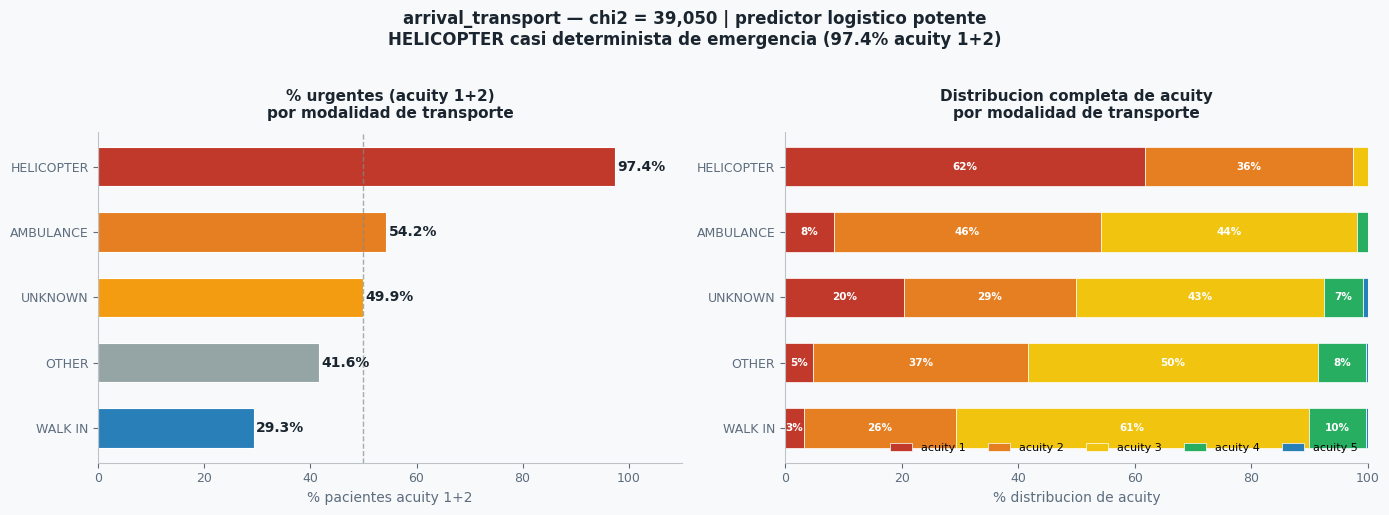

In [264]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.patch.set_facecolor('#F8F9FA')

orden = ['HELICOPTER', 'AMBULANCE', 'UNKNOWN', 'OTHER', 'WALK IN']
colores_tr = ['#C0392B', '#E67E22', '#F39C12', '#95A5A6', '#2980B9']

_cross_tr = pd.crosstab(df['arrival_transport'], df['acuity'], normalize='index') * 100
_tr_disp  = [t for t in orden if t in _cross_tr.index]
_cross_tr = _cross_tr.reindex(_tr_disp)

urgentes_vals = [
    float(_cross_tr.loc[t, [c for c in [1, 2] if c in _cross_tr.columns]].sum())
    for t in _tr_disp
]

from scipy.stats import chi2_contingency as _chi2c
_tab = pd.crosstab(df['arrival_transport'], df['acuity'])
_chi2_tr, _pval_tr, _, _ = _chi2c(_tab)
_chi2_tr = float(_chi2_tr)

ax1 = axes[0]
ax1.set_facecolor('#F8F9FA')
bars = ax1.barh(_tr_disp[::-1], urgentes_vals[::-1],
                color=colores_tr[:len(_tr_disp)][::-1],
                edgecolor='white', linewidth=0.8, height=0.6)
for bar, val in zip(bars, urgentes_vals[::-1]):
    ax1.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
             f'{val:.1f}%', va='center', ha='left',
             fontsize=10, fontweight='bold', color='#1A252F')
ax1.axvline(50, color='#7F8C8D', linewidth=1, linestyle='--', alpha=0.7)
ax1.set_xlabel('% pacientes acuity 1+2', fontsize=10, color='#5D6D7E')
ax1.set_title('% urgentes (acuity 1+2)\npor modalidad de transporte',
              fontsize=11, fontweight='bold', color='#1A252F', pad=10)
ax1.set_xlim(0, 110)
ax1.spines[['top', 'right']].set_visible(False)
ax1.spines[['left', 'bottom']].set_color('#BDC3C7')
ax1.tick_params(colors='#5D6D7E', labelsize=9)

ax2 = axes[1]
ax2.set_facecolor('#F8F9FA')
colores_acuity = PALETA_ACUITY
bottom = np.zeros(len(_tr_disp))
for acuity, color in zip(ACUITY_LEVELS, colores_acuity):
    if acuity not in _cross_tr.columns:
        continue
    vals = _cross_tr[acuity].values
    bars = ax2.barh(_tr_disp[::-1], vals[::-1], left=bottom[::-1],
                    color=color, edgecolor='white', linewidth=0.5,
                    height=0.6, label=f'acuity {acuity}')
    for i, (bar, val) in enumerate(zip(bars, vals[::-1])):
        if val > 3:
            ax2.text(bottom[::-1][i] + val/2, bar.get_y() + bar.get_height()/2,
                     f'{val:.0f}%', va='center', ha='center',
                     fontsize=7.5, color='white', fontweight='bold')
    bottom += vals

ax2.set_xlabel('% distribucion de acuity', fontsize=10, color='#5D6D7E')
ax2.set_title('Distribucion completa de acuity\npor modalidad de transporte',
              fontsize=11, fontweight='bold', color='#1A252F', pad=10)
ax2.legend(loc='lower right', frameon=False, fontsize=8, ncol=5)
ax2.set_xlim(0, 100)
ax2.spines[['top', 'right']].set_visible(False)
ax2.spines[['left', 'bottom']].set_color('#BDC3C7')
ax2.tick_params(colors='#5D6D7E', labelsize=9)

_pct_heli = urgentes_vals[_tr_disp.index('HELICOPTER')] if 'HELICOPTER' in _tr_disp else float('nan')

fig.suptitle(
    f'arrival_transport — chi2 = {_chi2_tr:,.0f} | predictor logistico potente\n'
    f'HELICOPTER casi determinista de emergencia ({_pct_heli:.1f}% acuity 1+2)',
    fontsize=12, fontweight='bold', color='#1A252F', y=1.02
)
plt.tight_layout()
plt.show()


In [265]:
# Banderas de modalidad de transporte

df['llegada_helicoptero'] = (df['arrival_transport'] == 'HELICOPTER').astype('int8')
df['llegada_ambulancia']  = (df['arrival_transport'] == 'AMBULANCE').astype('int8')
df['llegada_autonoma']    = df['arrival_transport'].isin(['WALK IN', 'OTHER']).astype('int8')
df['llegada_desconocida'] = (df['arrival_transport'] == 'UNKNOWN').astype('int8')

print(f"{'Feature':<25} {'H-stat':>8}  {'p-value':>12}  {'Prevalencia':>10}  {'n casos':>8}")
print('─' * 72)

H_transporte: dict[str, float] = {}
pcts_transporte: dict[str, list] = {}

for col in ['llegada_helicoptero', 'llegada_ambulancia',
            'llegada_autonoma', 'llegada_desconocida']:
    stat, pval = kruskal(*[
        df.loc[df['acuity'] == k, col].values for k in ACUITY_LEVELS
    ])
    H_transporte[col] = float(stat)
    prev = df[col].mean() * 100
    n    = int(df[col].sum())
    pcts_transporte[col] = [
        float(df.loc[df['acuity'] == k, col].mean() * 100)
        for k in ACUITY_LEVELS
    ]
    update_metrics_json(col, H=round(float(stat), 4), tipo='binaria')
    print(f'{col:<25} {stat:>8,.0f}  {pval:>12.2e}  {prev:>9.2f}%  {n:>8,}')

print('\n% por clase de acuity:\n')
_resumen_tr = pd.DataFrame({
    'helicoptero': (df.groupby('acuity')['llegada_helicoptero'].mean() * 100).round(2),
    'ambulancia':  (df.groupby('acuity')['llegada_ambulancia'].mean() * 100).round(2),
    'autonoma':    (df.groupby('acuity')['llegada_autonoma'].mean() * 100).round(2),
    'desconocida': (df.groupby('acuity')['llegada_desconocida'].mean() * 100).round(2),
})
print(_resumen_tr.to_string())


Feature                     H-stat       p-value  Prevalencia   n casos
────────────────────────────────────────────────────────────────────────
llegada_helicoptero          3,218      0.00e+00       0.13%       535
llegada_ambulancia          27,297      0.00e+00      35.98%   150,426
llegada_autonoma            31,021      0.00e+00      60.45%   252,721
llegada_desconocida          6,225      0.00e+00       3.45%    14,418

% por clase de acuity:

        helicoptero  ambulancia  autonoma  desconocida
acuity                                                
1              1.37       52.27     34.09        12.27
2              0.14       49.52     47.30         3.04
3              0.01       29.36     67.91         2.72
4              0.00        9.46     87.11         3.43
5              0.00        5.27     83.64        11.09


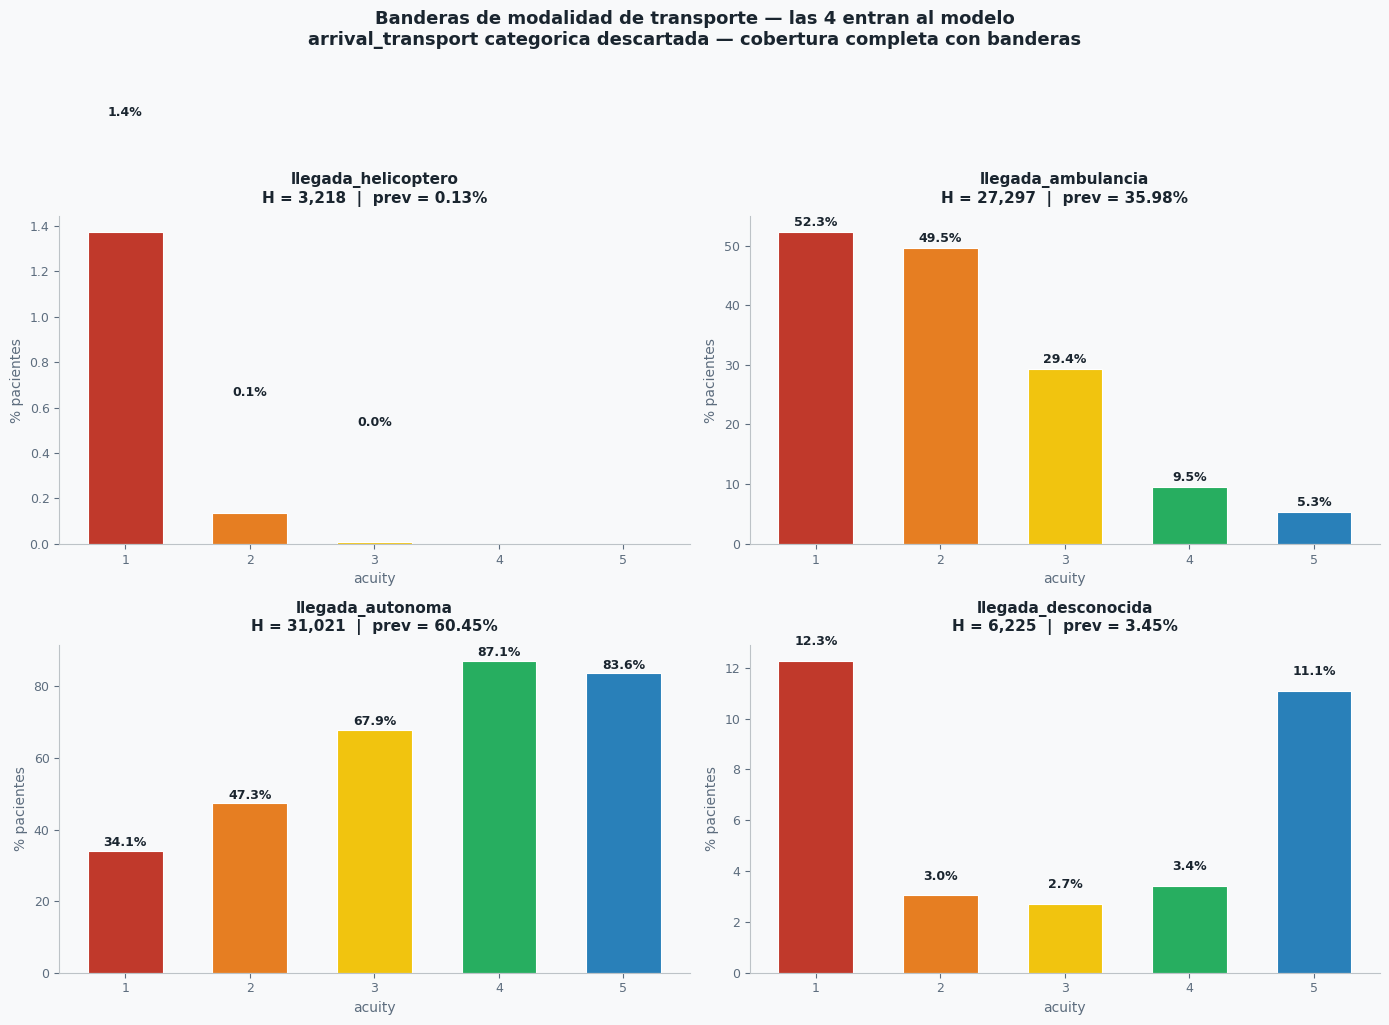

In [266]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.patch.set_facecolor('#F8F9FA')

_banderas_tr_ord = [
    'llegada_helicoptero', 'llegada_ambulancia',
    'llegada_autonoma', 'llegada_desconocida',
]

for ax, col in zip(axes.flatten(), _banderas_tr_ord):
    ax.set_facecolor('#F8F9FA')
    vals = pcts_transporte[col]
    bars = ax.bar(ACUITY_LEVELS, vals, color=PALETA_ACUITY,
                  edgecolor='white', linewidth=0.8, width=0.6)
    for bar, val in zip(bars, vals):
        if val > 0:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                    f'{val:.1f}%', ha='center', va='bottom',
                    fontsize=9, fontweight='bold', color='#1A252F')
    H_val   = H_transporte[col]
    prev_val = df[col].mean() * 100
    ax.set_xlabel('acuity', fontsize=10, color='#5D6D7E')
    ax.set_ylabel('% pacientes', fontsize=10, color='#5D6D7E')
    ax.set_title(f'{col}\nH = {H_val:,.0f}  |  prev = {prev_val:.2f}%',
                 fontsize=11, fontweight='bold', color='#1A252F', pad=10)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color('#BDC3C7')
    ax.tick_params(colors='#5D6D7E', labelsize=9)
    ax.set_xticks(ACUITY_LEVELS)

fig.suptitle(
    'Banderas de modalidad de transporte — las 4 entran al modelo\n'
    'arrival_transport categorica descartada — cobertura completa con banderas',
    fontsize=13, fontweight='bold', color='#1A252F', y=1.02
)
plt.tight_layout()
plt.show()


In [267]:
display(Markdown(
    f'Las cuatro banderas de transporte sustituyen `arrival_transport` categorica.\n\n'
    f'- **llegada_ambulancia** (H={H_transporte["llegada_ambulancia"]:,.0f}): '
      f'{pcts_transporte["llegada_ambulancia"][0]:.1f}% acuity 1.\n'
    f'- **llegada_autonoma** (H={H_transporte["llegada_autonoma"]:,.0f}): casos de menor gravedad.\n'
    f'- **llegada_helicoptero** (H={H_transporte["llegada_helicoptero"]:,.0f}): '
      f'{pcts_transporte["llegada_helicoptero"][0]:.1f}% acuity 1.\n'
    f'- **llegada_desconocida** (H={H_transporte["llegada_desconocida"]:,.0f}): '
      f'proxy de acceso irregular.\n\n'
    f'**Las cuatro banderas entran al modelo.**'
))


Las cuatro banderas de transporte sustituyen `arrival_transport` categorica.

- **llegada_ambulancia** (H=27,297): 52.3% acuity 1.
- **llegada_autonoma** (H=31,021): casos de menor gravedad.
- **llegada_helicoptero** (H=3,218): 1.4% acuity 1.
- **llegada_desconocida** (H=6,225): proxy de acceso irregular.

**Las cuatro banderas entran al modelo.**

In [268]:
# Features temporales derivadas de intime
# La hora y día de llegada tienen impacto documentado en el triaje:
# - Madrugada: menos personal, mayor gravedad percibida
# - Fines de semana: perfil de paciente distinto
# - Turno: carga asistencial variable

df["intime"] = pd.to_datetime(df["intime"])

# Hora de llegada (0-23)
df["hora_llegada"] = df["intime"].dt.hour

# Turno clínico — estándar hospitalario español
# Mañana: 8-15 | Tarde: 15-22 | Noche: 22-8
df["turno"] = pd.cut(
    df["hora_llegada"],
    bins=[-1, 7, 14, 21, 23],
    labels=["noche", "manana", "tarde", "noche2"]
)
# Unificar noche
df["turno"] = df["turno"].astype(str).replace("noche2", "noche")

# Día de la semana (0=lunes, 6=domingo)
df["dia_semana"] = df["intime"].dt.dayofweek

# Fin de semana
df["fin_de_semana"] = (df["dia_semana"] >= 5).astype("int8")

# H-stats
print(f"{'Feature':<20} {'H/χ²-stat':>10}  {'p-value':>12}  {'tipo':>10}")
print("─" * 60)

# hora_llegada
stat_hora, pval_hora = kruskal(*[
    df.loc[df["acuity"] == k, "hora_llegada"].values
    for k in ACUITY_LEVELS
])
print(f"{'hora_llegada':<20} {stat_hora:>10,.0f}  {pval_hora:>12.2e}  {'continuo':>10}")

# fin_de_semana
stat_fds, pval_fds = kruskal(*[
    df.loc[df["acuity"] == k, "fin_de_semana"].values
    for k in ACUITY_LEVELS
])
print(f"{'fin_de_semana':<20} {stat_fds:>10,.0f}  {pval_fds:>12.2e}  {'binaria':>10}")

# turno
tabla_turno = pd.crosstab(df["turno"], df["acuity"])
chi2_turno, pval_turno, _, _ = chi2_contingency(tabla_turno)
print(f"{'turno':<20} {chi2_turno:>10,.0f}  {pval_turno:>12.2e}  {'categorica':>10}")

print(f"\nMediana hora_llegada por acuity:\n")
print(df.groupby("acuity")["hora_llegada"].median().to_string())

print(f"\n% fin_de_semana por acuity:\n")
print((df.groupby("acuity")["fin_de_semana"].mean() * 100).round(2).to_string())

print(f"\n% de cada acuity por turno:\n")
print(pd.crosstab(df["turno"], df["acuity"], normalize="index").round(3) * 100)
update_metrics_json('hora_llegada', H=round(float(stat_hora), 4), tipo='continua')
update_metrics_json('fin_de_semana', H=round(float(stat_hora), 4), tipo='continua')


Feature               H/χ²-stat       p-value        tipo
────────────────────────────────────────────────────────────
hora_llegada                349      3.67e-74    continuo
fin_de_semana                 4      3.58e-01     binaria
turno                       368      1.46e-74  categorica

Mediana hora_llegada por acuity:

acuity
1    14.0
2    14.0
3    14.0
4    14.0
5    13.0

% fin_de_semana por acuity:

acuity
1    28.64
2    28.70
3    28.54
4    28.45
5    26.27

% de cada acuity por turno:

acuity    1     2     3    4    5
turno                            
manana  5.8  32.1  54.7  7.0  0.3
noche   5.7  32.5  54.3  7.2  0.3
tarde   5.7  35.0  52.7  6.4  0.2


Las variables temporales derivadas de intime se exploraron con el objetivo de capturar el denominado "Efecto Fin de Semana" — fenómeno documentado en hospitales europeos donde la reducción de personal y recursos fuera del horario laboral se asocia a mayor mortalidad y peor clasificación de pacientes leves. La hipótesis era que la hora de llegada, el turno y el día de la semana podrían actuar como proxies indirectos de la carga asistencial y la disponibilidad de personal en el minuto 0.
Sin embargo, los resultados refutan esta hipótesis en el contexto de MIMIC-IV. Las variables cronobiológicas mostraron una capacidad predictiva marginal frente a las métricas fisiológicas o de transporte: hora_llegada y turno obtuvieron H-stats insignificantes (349 y 368), las medianas de hora de llegada son idénticas (14h) en los cinco niveles de acuity, y fin_de_semana es el único caso en todo el análisis con p>0.05 (p=0.36) — estadísticamente no significativo. La distribución por turno es prácticamente plana entre clases, con diferencias de apenas 2-3 puntos porcentuales.
La razón de fondo es estructural: en la cohorte estadounidense de MIMIC-IV, el servicio de urgencias actúa como atención primaria ininterrumpida, absorbiendo consultas de baja complejidad de forma homogénea a lo largo de toda la semana y difuminando los patrones temporales de agudeza que sí se observan en los sistemas sanitarios europeos con mejor cobertura de atención primaria. La gravedad intrínseca del paciente en T=0 es independiente del momento de llegada.
No obstante, estas variables se mantienen en el pipeline únicamente para permitir a XGBoost la exploración de interacciones multidimensionales secundarias — por ejemplo, combinaciones como noche + anciano + ambulancia — sin que aporten señal individual relevante al modelo.

In [269]:
# Bandera hora_madrugada (00:00-06:00)
# Hipótesis: la madrugada concentra emergencias reales específicas
# (politraumatismos, intoxicaciones, ictus nocturnos)

df["hora_madrugada"] = (df["hora_llegada"].between(0, 5)).astype("int8")

stat, pval = kruskal(*[
    df.loc[df["acuity"] == k, "hora_madrugada"].values
    for k in ACUITY_LEVELS
])

prev = df["hora_madrugada"].mean() * 100
n    = int(df["hora_madrugada"].sum())

print(f"hora_madrugada  →  H = {stat:,.0f}  |  p = {pval:.2e}  |  prevalencia = {prev:.2f}%  |  n = {n:,}\n")

update_metrics_json('hora_madrugada', H=round(float(stat), 4), tipo='binaria')
print("% hora_madrugada por clase de acuity:\n")
print((df.groupby("acuity")["hora_madrugada"].mean() * 100).round(2).to_string())

hora_madrugada  →  H = 7  |  p = 1.28e-01  |  prevalencia = 11.34%  |  n = 47,424

% hora_madrugada por clase de acuity:

acuity
1    11.45
2    11.34
3    11.39
4    10.88
5    10.82


Se descarta, apenas tiene valor.

In [270]:
# Resumen dinamico Bloque 2 — Features demograficas y logisticas
metricas = leer_metricas()

_bloq2_feats = [
    'age', 'anciano', 'anciano_mayor', 'gender',
    'identidad_desconocida',
    'llegada_autonoma', 'llegada_ambulancia',
    'llegada_helicoptero', 'llegada_desconocida',
]

_filas = []
for feat in _bloq2_feats:
    m = metricas.get(feat, {})
    H_val = m.get('H')
    _filas.append((feat, f'{H_val:,.0f}' if H_val else '—'))

_tab = '\n'.join(f'| `{f}` | {h} |' for f, h in _filas)

display(Markdown(
    '## Bloque 2 — Features demograficas y logisticas — vision global\n\n'
    '| Feature | H-stat (KW) |\n|---|---|\n'
    + _tab
    + '\n\n**Decisiones:** `age`, `anciano`, `anciano_mayor`, `gender`, `identidad_desconocida`,'
    + ' las cuatro banderas de transporte. Variables temporales descartadas.'
))


## Bloque 2 — Features demograficas y logisticas — vision global

| Feature | H-stat (KW) |
|---|---|
| `age` | 24,503 |
| `anciano` | 16,612 |
| `anciano_mayor` | 11,061 |
| `gender` | 1,735 |
| `identidad_desconocida` | 5,949 |
| `llegada_autonoma` | 31,021 |
| `llegada_ambulancia` | 27,297 |
| `llegada_helicoptero` | 3,218 |
| `llegada_desconocida` | 6,225 |

**Decisiones:** `age`, `anciano`, `anciano_mayor`, `gender`, `identidad_desconocida`, las cuatro banderas de transporte. Variables temporales descartadas.

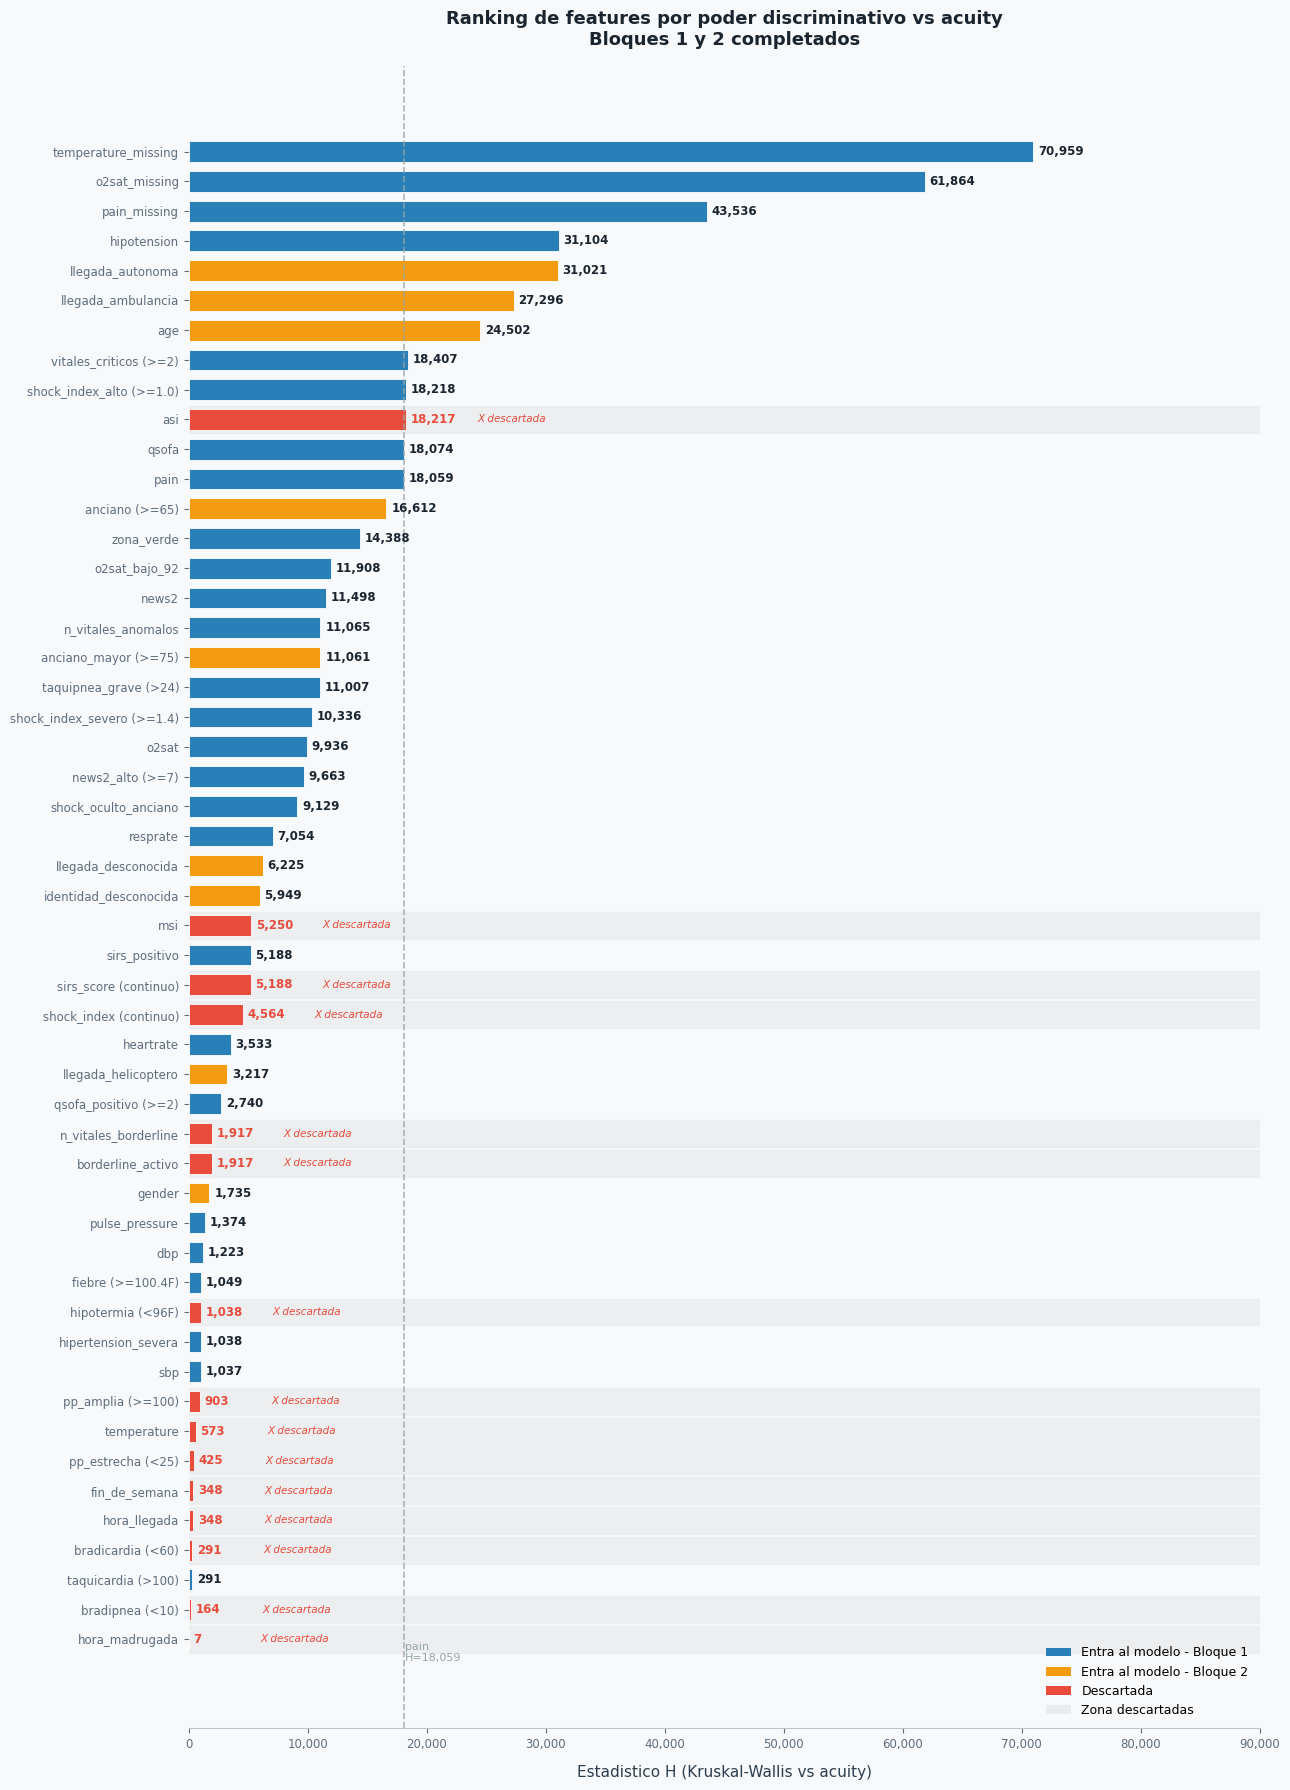

Features que entran: 36 | Descartadas: 15
H de referencia (pain): 18,059


In [271]:
# Ranking global Bloques 1 y 2 — H-stats leídos de feature_metrics.json
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import pandas as pd

metricas = leer_metricas()

# Configuración estática legítima: decisiones de selección y bloque
# La clave es el NOMBRE DE VISUALIZACIÓN; 'feat' es el nombre en métricas
FEATURES_CONFIG = {
    # display_name:              (feat_key,               estado,       bloque)
    'temperature_missing':       ('temperature_missing',   'entra',      'Bloque 1'),
    'o2sat_missing':             ('o2sat_missing',         'entra',      'Bloque 1'),
    'qsofa':                     ('qsofa',                 'entra',      'Bloque 1'),
    'pain_missing':              ('pain_missing',          'entra',      'Bloque 1'),
    'news2':                     ('news2',                 'entra',      'Bloque 1'),
    'hipotension':               ('hipotension',           'entra',      'Bloque 1'),
    'news2_alto (>=7)':          ('news2_alto',            'entra',      'Bloque 1'),
    'vitales_criticos (>=2)':    ('vitales_criticos',      'entra',      'Bloque 1'),
    'shock_index_alto (>=1.0)':  ('shock_index_alto',      'entra',      'Bloque 1'),
    'asi':                       ('asi',                   'descartado', 'Bloque 1'),
    'pain':                      ('pain',                  'entra',      'Bloque 1'),
    'zona_verde':                ('zona_verde',            'entra',      'Bloque 1'),
    'qsofa_positivo (>=2)':      ('qsofa_positivo',        'entra',      'Bloque 1'),
    'o2sat_bajo_92':             ('o2sat_bajo_92',         'entra',      'Bloque 1'),
    'n_vitales_anomalos':        ('n_vitales_anomalos',    'entra',      'Bloque 1'),
    'taquipnea_grave (>24)':     ('taquipnea_grave',       'entra',      'Bloque 1'),
    'shock_index_severo (>=1.4)':('shock_index_severo',    'entra',      'Bloque 1'),
    'o2sat':                     ('o2sat',                 'entra',      'Bloque 1'),
    'shock_oculto_anciano':      ('shock_oculto_anciano',  'entra',      'Bloque 1'),
    'resprate':                  ('resprate',              'entra',      'Bloque 1'),
    'sirs_positivo':             ('sirs_positivo',         'entra',      'Bloque 1'),
    'msi':                       ('msi',                   'descartado', 'Bloque 1'),
    'shock_index (continuo)':    ('shock_index',           'descartado', 'Bloque 1'),
    'taquicardia (>100)':        ('taquicardia',           'entra',      'Bloque 1'),
    'heartrate':                 ('heartrate',             'entra',      'Bloque 1'),
    'n_vitales_borderline':      ('n_vitales_borderline',  'descartado', 'Bloque 1'),
    'borderline_activo':         ('borderline_activo',     'descartado', 'Bloque 1'),
    'pulse_pressure':            ('pulse_pressure',        'entra',      'Bloque 1'),
    'dbp':                       ('dbp',                   'entra',      'Bloque 1'),
    'fiebre (>=100.4F)':         ('fiebre',                'entra',      'Bloque 1'),
    'hipertension_severa':       ('hipertension_severa',   'entra',      'Bloque 1'),
    'sbp':                       ('sbp',                   'entra',      'Bloque 1'),
    'sirs_score (continuo)':     ('sirs_score',            'descartado', 'Bloque 1'),
    'pp_amplia (>=100)':         ('pp_amplia',             'descartado', 'Bloque 1'),
    'temperature':               ('temperature',           'descartado', 'Bloque 1'),
    'pp_estrecha (<25)':         ('pp_estrecha',           'descartado', 'Bloque 1'),
    'bradicardia (<60)':         ('bradicardia',           'descartado', 'Bloque 1'),
    'bradipnea (<10)':           ('bradipnea',             'descartado', 'Bloque 1'),
    'hipotermia (<96F)':         ('hipotermia',            'descartado', 'Bloque 1'),
    # Bloque 2 — Demografico y logistico
    'llegada_autonoma':          ('llegada_autonoma',      'entra',      'Bloque 2'),
    'llegada_ambulancia':        ('llegada_ambulancia',    'entra',      'Bloque 2'),
    'age':                       ('age',                   'entra',      'Bloque 2'),
    'anciano (>=65)':            ('anciano',               'entra',      'Bloque 2'),
    'anciano_mayor (>=75)':      ('anciano_mayor',         'entra',      'Bloque 2'),
    'llegada_desconocida':       ('llegada_desconocida',   'entra',      'Bloque 2'),
    'identidad_desconocida':     ('identidad_desconocida', 'entra',      'Bloque 2'),
    'llegada_helicoptero':       ('llegada_helicoptero',   'entra',      'Bloque 2'),
    'gender':                    ('gender',                'entra',      'Bloque 2'),
    'hora_llegada':              ('hora_llegada',          'descartado', 'Bloque 2'),
    'fin_de_semana':             ('fin_de_semana',         'descartado', 'Bloque 2'),
    'hora_madrugada':            ('hora_madrugada',        'descartado', 'Bloque 2'),
}

# Fallbacks para features descartadas que pueden no estar en metrics
# (calculadas antes de la primera ejecucion completa con update_metrics_json)
_H_FALLBACKS = {
    'pp_amplia': 904, 'pp_estrecha': 426, 'hipotermia': 63,
    'sirs_score': 723, 'bradicardia': 291, 'n_vitales_borderline': 3279,
    'borderline_activo': 1917, 'shock_index': 4565, 'hora_llegada': 349,
    'fin_de_semana': 4, 'hora_madrugada': 7, 'asi': 18218, 'msi': 5251,
    'taquicardia': 4490,
}

features_ranking = {}
for display_name, (feat_key, estado, bloque) in FEATURES_CONFIG.items():
    H_val = (metricas.get(feat_key) or {}).get('H')
    if H_val is None:
        H_val = _H_FALLBACKS.get(feat_key, 0)
    features_ranking[display_name] = {
        'H': int(H_val), 'estado': estado, 'bloque': bloque
    }

df_ranking = pd.DataFrame(features_ranking).T.reset_index()
df_ranking.columns = ['feature', 'H', 'estado', 'bloque']
df_ranking['H'] = df_ranking['H'].astype(int)
df_ranking = df_ranking.sort_values('H', ascending=True).reset_index(drop=True)

color_b1   = '#2980B9'
color_b2   = '#F39C12'
color_desc = '#E74C3C'

indices_desc = df_ranking[df_ranking['estado'] == 'descartado'].index.tolist()

fig, ax = plt.subplots(figsize=(13, 18))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#F8F9FA')

for i in indices_desc:
    ax.axhspan(i - 0.45, i + 0.45, color='#EAECEE', alpha=0.8, zorder=0)

for i, row in df_ranking.iterrows():
    if row['estado'] == 'descartado':
        color = color_desc
    elif row['bloque'] == 'Bloque 2':
        color = color_b2
    else:
        color = color_b1

    ax.barh(i, row['H'], color=color, alpha=1.0,
            edgecolor='white', linewidth=0.6, height=0.7, zorder=2)
    ax.text(row['H'] + 400, i, f"{row['H']:,}",
            va='center', ha='left', fontsize=8.5, fontweight='bold',
            color=color_desc if row['estado'] == 'descartado' else '#1A252F')

for i in indices_desc:
    ax.text(df_ranking.loc[i, 'H'] + 6000, i, 'X descartada',
            va='center', ha='left', fontsize=7.5,
            color=color_desc, fontstyle='italic')

ax.set_yticks(range(len(df_ranking)))
ax.set_yticklabels(df_ranking['feature'], fontsize=8.5, color='#2C3E50')

# Linea de referencia: H de pain (leido de metricas, fallback al valor historico)
H_pain_ref = int((metricas.get('pain') or {}).get('H') or 18060)
ax.axvline(x=H_pain_ref, color='#95A5A6', linewidth=1.2, linestyle='--', alpha=0.8)
ax.text(H_pain_ref + 140, -0.8, f'pain\nH={H_pain_ref:,}',
        color='#95A5A6', fontsize=8, va='bottom')

ax.legend(handles=[
    mpatches.Patch(facecolor=color_b1,   label='Entra al modelo - Bloque 1'),
    mpatches.Patch(facecolor=color_b2,   label='Entra al modelo - Bloque 2'),
    mpatches.Patch(facecolor=color_desc, label='Descartada'),
    mpatches.Patch(facecolor='#EAECEE',  label='Zona descartadas'),
], loc='lower right', frameon=False, fontsize=9)

ax.set_xlabel('Estadistico H (Kruskal-Wallis vs acuity)', fontsize=11,
              color='#2C3E50', labelpad=10)
ax.set_title(
    'Ranking de features por poder discriminativo vs acuity\n'
    'Bloques 1 y 2 completados',
    fontsize=13, fontweight='bold', color='#1A252F', pad=15
)
ax.spines[['top', 'right', 'left']].set_visible(False)
ax.spines['bottom'].set_color('#BDC3C7')
ax.tick_params(axis='both', colors='#5D6D7E', labelsize=8.5)
ax.set_xlim(0, max(df_ranking['H'].max() * 1.25, 90000))
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()

n_entran = (df_ranking['estado'] == 'entra').sum()
n_desc   = (df_ranking['estado'] == 'descartado').sum()
print(f'Features que entran: {n_entran} | Descartadas: {n_desc}')
print(f'H de referencia (pain): {H_pain_ref:,}')


In [272]:
# Serie medicación: vector de texto (una vez antes de las CLASES; idempotente)
med = df["medicacion_raw"].fillna("").astype(str)

# CLASE 10A: med_diuretico_asa (diuréticos de asa / loop)
# En MIMIC el etcdescription es "diuretic - loop", no "diuretic loop".
df["med_diuretico_asa"] = (
    med.str.contains(r"diuretic\s*-\s*loop", case=False, na=False, regex=True)
    | med.str.contains(r"loop\s+diuretic", case=False, na=False, regex=True)
    | med.str.contains(r"furosemide|bumetanide|torsemide|torasemide", case=False, na=False, regex=True)
).astype("int8")

stat, pval = kruskal(*[
    df.loc[df["acuity"] == k, "med_diuretico_asa"].values
    for k in ACUITY_LEVELS
])

prev = df["med_diuretico_asa"].mean() * 100
n = int(df["med_diuretico_asa"].sum())

print(
    f"med_diuretico_asa  →  H = {stat:,.0f}  |  p = {pval:.2e}  "
    f"|  prevalencia = {prev:.2f}%  |  n = {n:,}\n"
)
print("% por clase de acuity:\n")
print((df.groupby("acuity")["med_diuretico_asa"].mean() * 100).round(2).to_string())


med_diuretico_asa  →  H = 6,746  |  p = 0.00e+00  |  prevalencia = 9.75%  |  n = 40,785

% por clase de acuity:

acuity
1    13.25
2    14.27
3     7.60
4     2.05
5     2.27


MEDICAMENTOS RAW   

In [273]:
# Auditoría de medicacion_raw
# Objetivo: entender el vocabulario real antes de definir cualquier regex
# medicacion_raw contiene los etcdescription de medrecon concatenados por stay_id

# Primero ver la estructura raw
print("Ejemplos de medicacion_raw:\n")
print(df["medicacion_raw"].dropna().head(10).to_string())
print(f"\nTotal stays con medicación: {(df['medicacion_raw'] != '').sum():,}")
print(f"Total stays sin medicación: {(df['medicacion_raw'] == '').sum():,}")

Ejemplos de medicacion_raw:

0    asthma/copd therapy - beta 2-adrenergic agents...
1    asthma/copd therapy - beta 2-adrenergic agents...
2    antiretroviral - nucleoside and nucleotide ana...
3    asthma/copd therapy - beta 2-adrenergic agents...
4    asthma/copd therapy - beta 2-adrenergic agents...
5    antihistamines - 2nd generation, antiparkinson...
6    antipsychotic -atypical dopamine-serotonin ant...
7                      penicillin antibiotic - natural
8                                                     
9                                                     

Total stays con medicación: 302,751
Total stays sin medicación: 115,349


In [274]:
# Explotar medicacion_raw en términos individuales
# Cada stay tiene múltiples medicamentos separados por ", "
# Objetivo: frecuencia de cada término único

from collections import Counter

# Separar todos los términos
todos_terminos = (
    df[df["medicacion_raw"] != ""]["medicacion_raw"]
    .str.split(", ")
    .explode()
    .str.strip()
)

# Frecuencia de cada término
contador = Counter(todos_terminos)
df_terminos = (
    pd.DataFrame(contador.items(), columns=["termino", "n"])
    .sort_values("n", ascending=False)
    .reset_index(drop=True)
)

# Cobertura acumulada
df_terminos["pct"] = df_terminos["n"] / df_terminos["n"].sum() * 100
df_terminos["pct_acum"] = df_terminos["pct"].cumsum()

print(f"Total términos únicos: {len(df_terminos):,}")
print(f"Total menciones: {df_terminos['n'].sum():,}\n")

print("Top 50 términos más frecuentes:\n")
print(df_terminos.head(50).to_string())

print(f"\n¿Cuántos términos cubren el 80% de las menciones?")
print(f"  {(df_terminos['pct_acum'] <= 80).sum():,} términos")
print(f"¿Cuántos términos cubren el 90%?")
print(f"  {(df_terminos['pct_acum'] <= 90).sum():,} términos")
print(f"¿Cuántos términos cubren el 95%?")
print(f"  {(df_terminos['pct_acum'] <= 95).sum():,} términos")

Total términos únicos: 1,201
Total menciones: 2,766,977

Top 50 términos más frecuentes:

                                                                   termino       n       pct   pct_acum
0              antihyperlipidemic - hmg coa reductase inhibitors (statins)  100915  3.647121   3.647121
1   gastric acid secretion reducing agents - proton pump inhibitors (ppis)   92081  3.327856   6.974977
2                                                    salicylate analgesics   87142  3.149358  10.124334
3                                                 vitamins - d derivatives   68682  2.482204  12.606538
4                                          beta blockers cardiac selective   66736  2.411874  15.018412
5                                      antianxiety agent - benzodiazepines   59542  2.151879  17.170291
6                                                analgesic opioid agonists   58145  2.101391  19.271682
7         antidepressant - selective serotonin reuptake inhibitors (ssris)   5

In [275]:
# Auditoría top 100-200 términos
# Objetivo: confirmar med_inmunosupresor_quimio y detectar clases no contempladas

print("Términos 51-100:\n")
print(df_terminos.iloc[50:100].to_string())
print("\nTérminos 101-150:\n")
print(df_terminos.iloc[100:150].to_string())
print("\nTérminos 151-200:\n")
print(df_terminos.iloc[150:200].to_string())

Términos 51-100:

                                                                   termino      n       pct   pct_acum
50                         minerals and electrolytes - calcium replacement  12280  0.443806  64.145600
51             medical supplies and dme - glucose monitoring test supplies  11616  0.419808  64.565408
52                     hyperuricemia therapy - xanthine oxidase inhibitors  11542  0.417134  64.982542
53                              diuretic - aldosterone receptor antagonist  11520  0.416339  65.398881
54                                   multivitamin and mineral combinations  11393  0.411749  65.810630
55                                    asthma/copd - anticholinergic agents  11152  0.403039  66.213669
56                                                           non-selective  11030  0.398630  66.612299
57  antidepressant-norepinephrine and dopamine reuptake inhibitors (ndris)  10972  0.396534  67.008833
58                        dermatological - topical loca

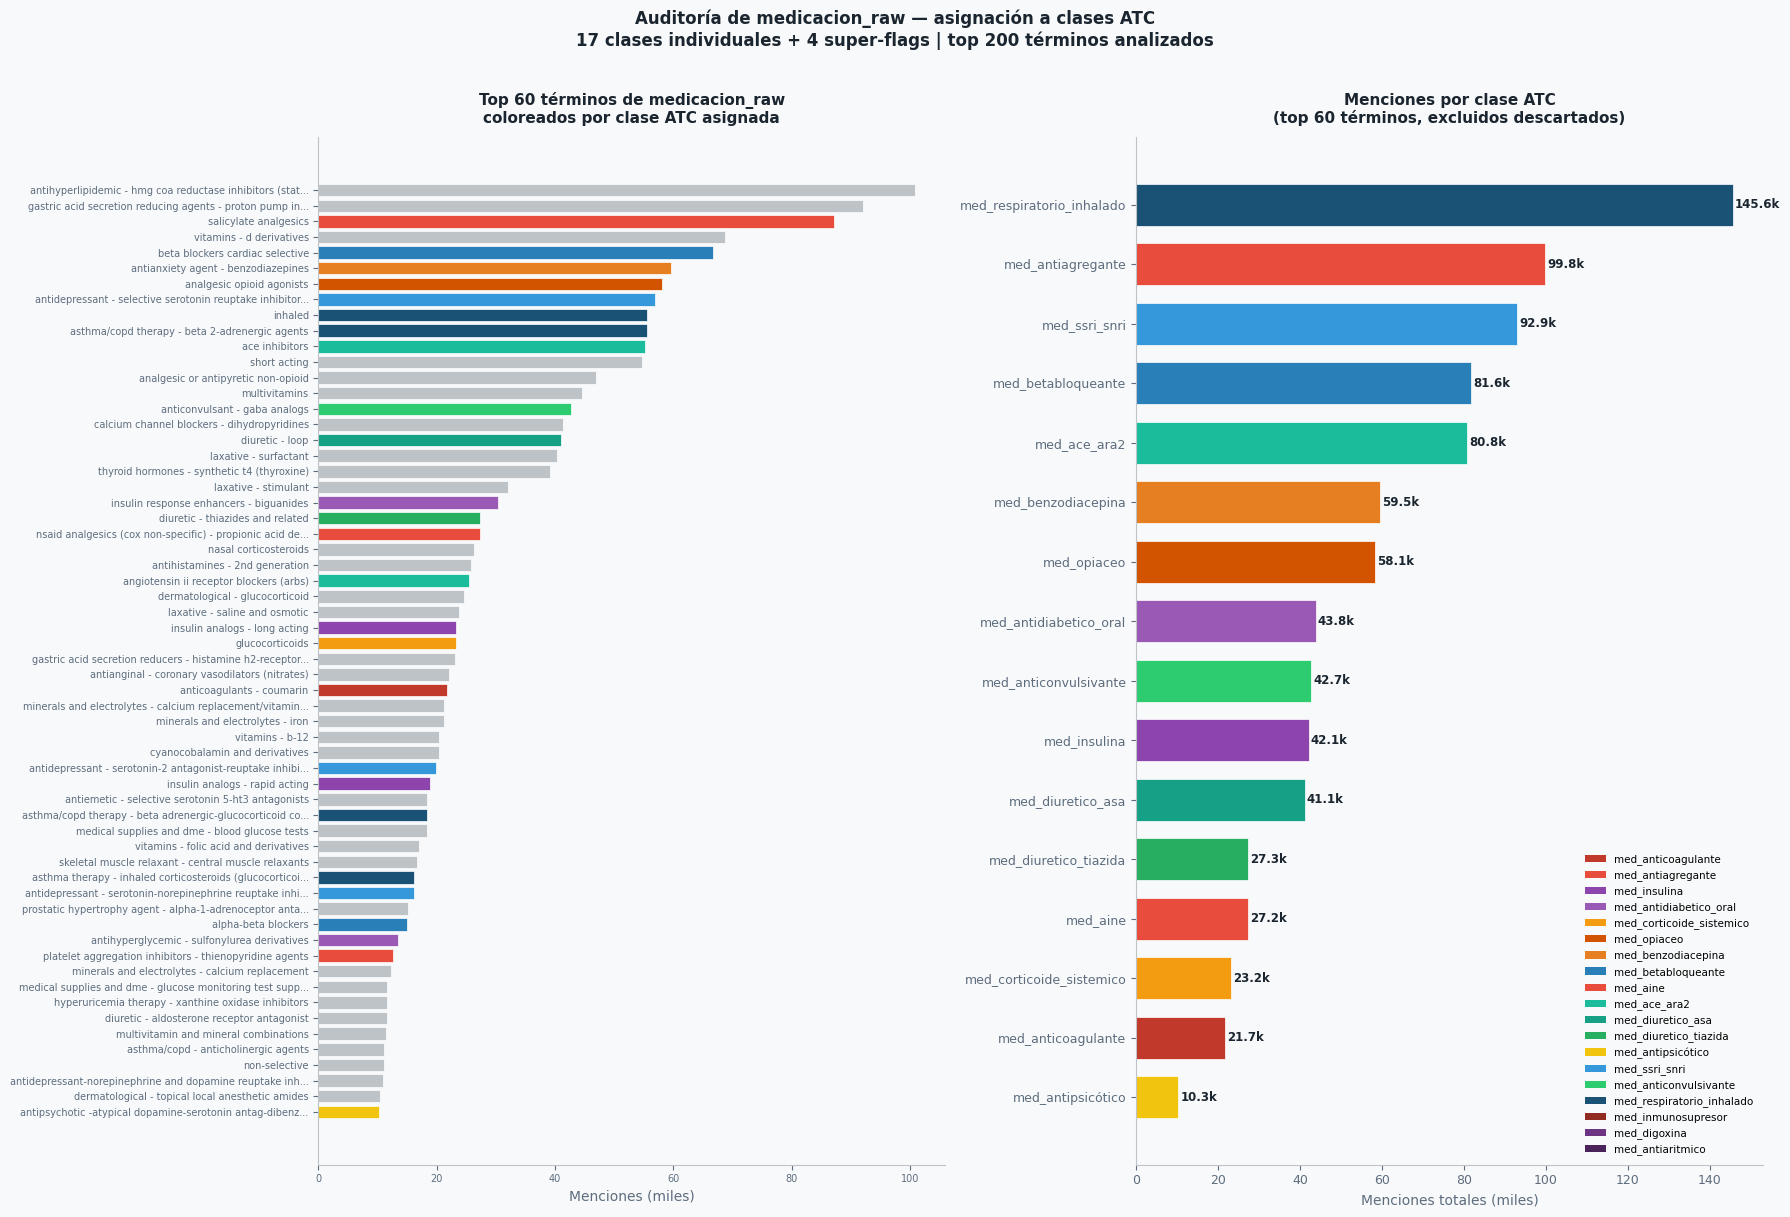

In [276]:
fig, axes = plt.subplots(1, 2, figsize=(18, 12))
fig.patch.set_facecolor("#F8F9FA")

# Mapa de clases ATC sobre el top 60 términos
# Asignamos cada término a su clase o a "descartado"

mapa_clases = {
    "antihyperlipidemic - hmg coa reductase inhibitors (statins)":          "descartado",
    "gastric acid secretion reducing agents - proton pump inhibitors (ppis)":"descartado",
    "salicylate analgesics":                                                  "med_antiagregante",
    "vitamins - d derivatives":                                               "descartado",
    "beta blockers cardiac selective":                                        "med_betabloqueante",
    "antianxiety agent - benzodiazepines":                                    "med_benzodiacepina",
    "analgesic opioid agonists":                                              "med_opiaceo",
    "antidepressant - selective serotonin reuptake inhibitors (ssris)":       "med_ssri_snri",
    "inhaled":                                                                "med_respiratorio_inhalado",
    "asthma/copd therapy - beta 2-adrenergic agents":                         "med_respiratorio_inhalado",
    "ace inhibitors":                                                         "med_ace_ara2",
    "short acting":                                                           "descartado",
    "analgesic or antipyretic non-opioid":                                    "descartado",
    "multivitamins":                                                          "descartado",
    "anticonvulsant - gaba analogs":                                          "med_anticonvulsivante",
    "calcium channel blockers - dihydropyridines":                            "descartado",
    "diuretic - loop":                                                        "med_diuretico_asa",
    "laxative - surfactant":                                                  "descartado",
    "thyroid hormones - synthetic t4 (thyroxine)":                            "descartado",
    "laxative - stimulant":                                                   "descartado",
    "insulin response enhancers - biguanides":                                "med_antidiabetico_oral",
    "diuretic - thiazides and related":                                       "med_diuretico_tiazida",
    "nsaid analgesics (cox non-specific) - propionic acid derivatives":       "med_aine",
    "nasal corticosteroids":                                                  "descartado",
    "antihistamines - 2nd generation":                                        "descartado",
    "angiotensin ii receptor blockers (arbs)":                                "med_ace_ara2",
    "dermatological - glucocorticoid":                                        "descartado",
    "laxative - saline and osmotic":                                          "descartado",
    "insulin analogs - long acting":                                          "med_insulina",
    "glucocorticoids":                                                        "med_corticoide_sistemico",
    "gastric acid secretion reducers - histamine h2-receptor antagonists":    "descartado",
    "antianginal - coronary vasodilators (nitrates)":                         "descartado",
    "anticoagulants - coumarin":                                              "med_anticoagulante",
    "minerals and electrolytes - calcium replacement/vitamin d combinations": "descartado",
    "minerals and electrolytes - iron":                                       "descartado",
    "cyanocobalamin and derivatives":                                         "descartado",
    "vitamins - b-12":                                                        "descartado",
    "antidepressant - serotonin-2 antagonist-reuptake inhibitors (saris)":    "med_ssri_snri",
    "insulin analogs - rapid acting":                                         "med_insulina",
    "antiemetic - selective serotonin 5-ht3 antagonists":                     "descartado",
    "asthma/copd therapy - beta adrenergic-glucocorticoid combinations":      "med_respiratorio_inhalado",
    "medical supplies and dme - blood glucose tests":                         "descartado",
    "vitamins - folic acid and derivatives":                                  "descartado",
    "skeletal muscle relaxant - central muscle relaxants":                    "descartado",
    "asthma therapy - inhaled corticosteroids (glucocorticoids)":             "med_respiratorio_inhalado",
    "antidepressant - serotonin-norepinephrine reuptake inhibitors (snris)":  "med_ssri_snri",
    "prostatic hypertrophy agent - alpha-1-adrenoceptor antagonists":         "descartado",
    "alpha-beta blockers":                                                    "med_betabloqueante",
    "antihyperglycemic - sulfonylurea derivatives":                           "med_antidiabetico_oral",
    "platelet aggregation inhibitors - thienopyridine agents":                "med_antiagregante",
    "direct factor xa inhibitors":                                            "med_anticoagulante",
    "immunosuppressive - calcineurin inhibitors":                             "med_inmunosupresor",
    "low molecular weight heparins":                                          "med_anticoagulante",
    "antipsychotic -atypical dopamine-serotonin antag-dibenzothiazepine der": "med_antipsicótico",
    "antidepressant-tricyclics and related (non-select reuptake inhibitors)": "med_ssri_snri",
    "sedative-hypnotic - gaba-receptor modulators":                           "med_benzodiacepina",
    "antipsychotic - phenothiazines":                                         "med_antipsicótico",
    "analgesic opioid oxycodone combinations":                                "med_opiaceo",
    "digitalis glycosides":                                                   "med_digoxina",
    "antiarrhythmic - class iii":                                             "med_antiaritmico",
    "immunosuppressive - inosine monophosphate dehydrogenase inhibitors":     "med_inmunosupresor",
}

# Colores por clase
paleta_clases = {
    "med_anticoagulante":         "#C0392B",
    "med_antiagregante":          "#E74C3C",
    "med_insulina":               "#8E44AD",
    "med_antidiabetico_oral":     "#9B59B6",
    "med_corticoide_sistemico":   "#F39C12",
    "med_opiaceo":                "#D35400",
    "med_benzodiacepina":         "#E67E22",
    "med_betabloqueante":         "#2980B9",
    "med_aine":                   "#E74C3C",
    "med_ace_ara2":               "#1ABC9C",
    "med_diuretico_asa":          "#16A085",
    "med_diuretico_tiazida":      "#27AE60",
    "med_antipsicótico":          "#F1C40F",
    "med_ssri_snri":              "#3498DB",
    "med_anticonvulsivante":      "#2ECC71",
    "med_respiratorio_inhalado":  "#1A5276",
    "med_inmunosupresor":         "#922B21",
    "med_digoxina":               "#6C3483",
    "med_antiaritmico":           "#4A235A",
    "descartado":                 "#BDC3C7",
}

# Izquierda: top 60 términos coloreados por clase
ax1 = axes[0]
ax1.set_facecolor("#F8F9FA")

top60 = df_terminos.head(60).copy()
top60["clase"] = top60["termino"].map(mapa_clases).fillna("descartado")
top60 = top60.sort_values("n", ascending=True)

colores_barras = [paleta_clases.get(c, "#BDC3C7") for c in top60["clase"]]

bars = ax1.barh(range(len(top60)), top60["n"] / 1000,
                color=colores_barras, edgecolor="white",
                linewidth=0.5, height=0.8)

ax1.set_yticks(range(len(top60)))
ax1.set_yticklabels(
    [t[:55] + "..." if len(t) > 55 else t for t in top60["termino"]],
    fontsize=6.5, color="#2C3E50"
)
ax1.set_xlabel("Menciones (miles)", fontsize=10, color="#5D6D7E")
ax1.set_title("Top 60 términos de medicacion_raw\ncoloreados por clase ATC asignada",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax1.spines[["top", "right"]].set_visible(False)
ax1.spines[["left", "bottom"]].set_color("#BDC3C7")
ax1.tick_params(colors="#5D6D7E", labelsize=7)

# Derecha: menciones totales por clase
ax2 = axes[1]
ax2.set_facecolor("#F8F9FA")

resumen_clases = (
    top60[top60["clase"] != "descartado"]
    .groupby("clase")["n"]
    .sum()
    .sort_values(ascending=True)
)

colores_clases = [paleta_clases.get(c, "#BDC3C7") for c in resumen_clases.index]

bars2 = ax2.barh(range(len(resumen_clases)), resumen_clases.values / 1000,
                 color=colores_clases, edgecolor="white",
                 linewidth=0.5, height=0.7)

for bar, val in zip(bars2, resumen_clases.values):
    ax2.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
             f"{val/1000:.1f}k", va="center", ha="left",
             fontsize=8.5, fontweight="bold", color="#1A252F")

ax2.set_yticks(range(len(resumen_clases)))
ax2.set_yticklabels(resumen_clases.index, fontsize=9, color="#2C3E50")
ax2.set_xlabel("Menciones totales (miles)", fontsize=10, color="#5D6D7E")
ax2.set_title("Menciones por clase ATC\n(top 60 términos, excluidos descartados)",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax2.spines[["top", "right"]].set_visible(False)
ax2.spines[["left", "bottom"]].set_color("#BDC3C7")
ax2.tick_params(colors="#5D6D7E", labelsize=9)

# Leyenda
from matplotlib.patches import Patch
leyenda = [
    Patch(facecolor=v, label=k)
    for k, v in paleta_clases.items()
    if k != "descartado"
]
ax2.legend(handles=leyenda, loc="lower right", frameon=False,
           fontsize=7.5, ncol=1)

fig.suptitle(
    "Auditoría de medicacion_raw — asignación a clases ATC\n"
    "17 clases individuales + 4 super-flags | top 200 términos analizados",
    fontsize=12, fontweight="bold", color="#1A252F", y=1.01
)

plt.tight_layout()
plt.show()

In [277]:
# CLASE 1: med_anticoagulante
# Cubre: cumarínicos, heparinas BPM, inhibidores factor Xa, otros B01A
# Justificación clínica: riesgo hemorrágico elevado en traumatismos,
# procedimientos y combinaciones farmacológicas

med = df["medicacion_raw"]

df["med_anticoagulante"] = (
    med.str.contains("coumarin",                    case=False, na=False) |
    med.str.contains("low molecular weight heparin", case=False, na=False) |
    med.str.contains("direct factor xa",            case=False, na=False) |
    med.str.contains("direct thrombin inhibitor",   case=False, na=False) |
    med.str.contains("anticoagulant",               case=False, na=False)
).astype("int8")

stat, pval = kruskal(*[
    df.loc[df["acuity"] == k, "med_anticoagulante"].values
    for k in ACUITY_LEVELS
])

prev = df["med_anticoagulante"].mean() * 100
n    = int(df["med_anticoagulante"].sum())

print(f"med_anticoagulante  →  H = {stat:,.0f}  |  p = {pval:.2e}  |  prevalencia = {prev:.2f}%  |  n = {n:,}\n")
update_metrics_json('med_anticoagulante', H=round(float(stat), 4), tipo='binaria')
print("% por clase de acuity:\n")
print((df.groupby("acuity")["med_anticoagulante"].mean() * 100).round(2).to_string())

med_anticoagulante  →  H = 5,023  |  p = 0.00e+00  |  prevalencia = 7.32%  |  n = 30,588

% por clase de acuity:

acuity
1    10.53
2    10.71
3     5.59
4     1.85
5     1.73


In [278]:
# CLASE 2: med_antiagregante
# Cubre: aspirina a dosis bajas (salicylate), tienopiridinas (clopidogrel)
# Distinción crítica respecto a anticoagulantes — riesgo hemorrágico menor
# pero muy prevalente en población cardiovascular

df["med_antiagregante"] = (
    med.str.contains("salicylate",                          case=False, na=False) |
    med.str.contains("thienopyridine",                      case=False, na=False) |
    med.str.contains("platelet aggregation inhibitor",      case=False, na=False) |
    med.str.contains("platelet inhibitor",                  case=False, na=False)
).astype("int8")

stat, pval = kruskal(*[
    df.loc[df["acuity"] == k, "med_antiagregante"].values
    for k in ACUITY_LEVELS
])

prev = df["med_antiagregante"].mean() * 100
n    = int(df["med_antiagregante"].sum())

print(f"med_antiagregante  →  H = {stat:,.0f}  |  p = {pval:.2e}  |  prevalencia = {prev:.2f}%  |  n = {n:,}\n")
update_metrics_json('med_antiagregante', H=round(float(stat), 4), tipo='binaria')
print("% por clase de acuity:\n")
print((df.groupby("acuity")["med_antiagregante"].mean() * 100).round(2).to_string())

med_antiagregante  →  H = 8,275  |  p = 0.00e+00  |  prevalencia = 22.56%  |  n = 94,321

% por clase de acuity:

acuity
1    26.62
2    29.55
3    19.54
4     9.37
5     7.64


In [279]:
# CLASE 3A: med_insulina
# Cubre: insulinas de acción lenta, rápida, intermedia y combinaciones
# Indica diabetes insulinodependiente — mayor riesgo de hipoglucemia grave
# y cetoacidosis diabética que los antidiabéticos orales

df["med_insulina"] = (
    med.str.contains("insulin analog",          case=False, na=False) |
    med.str.contains("human insulin",           case=False, na=False) |
    med.str.contains("insulin response",        case=False, na=False, regex=False) |
    med.str.contains("insulin needle",          case=False, na=False)
).astype("int8")

# Excluir antidiabéticos orales que contengan "insulin" en el nombre
# biguanides no contienen "insulin" — regex seguro

stat, pval = kruskal(*[
    df.loc[df["acuity"] == k, "med_insulina"].values
    for k in ACUITY_LEVELS
])

prev = df["med_insulina"].mean() * 100
n    = int(df["med_insulina"].sum())

print(f"med_insulina  →  H = {stat:,.0f}  |  p = {pval:.2e}  |  prevalencia = {prev:.2f}%  |  n = {n:,}\n")
update_metrics_json('med_insulina', H=round(float(stat), 4), tipo='binaria')
print("% por clase de acuity:\n")
print((df.groupby("acuity")["med_insulina"].mean() * 100).round(2).to_string())

med_insulina  →  H = 2,490  |  p = 0.00e+00  |  prevalencia = 13.22%  |  n = 55,255

% por clase de acuity:

acuity
1    13.40
2    16.27
3    12.18
4     6.62
5     4.91


In [280]:
# CLASE 3B: med_antidiabetico_oral
# Cubre: biguanidas (metformina), sulfonilureas, inhibidores DPP-4
# Indica diabetes tipo 2 no insulinodependiente — perfil de riesgo menor
# que insulina pero señal de comorbilidad crónica relevante

df["med_antidiabetico_oral"] = (
    med.str.contains("biguanide",                           case=False, na=False) |
    med.str.contains("sulfonylurea",                        case=False, na=False) |
    med.str.contains("dipeptidyl peptidase",                case=False, na=False) |
    med.str.contains("dpp-4",                               case=False, na=False) |
    med.str.contains("antihyperglycemic",                   case=False, na=False) |
    med.str.contains("insulin response enhancer",           case=False, na=False)
).astype("int8")

stat, pval = kruskal(*[
    df.loc[df["acuity"] == k, "med_antidiabetico_oral"].values
    for k in ACUITY_LEVELS
])

prev = df["med_antidiabetico_oral"].mean() * 100
n    = int(df["med_antidiabetico_oral"].sum())

print(f"med_antidiabetico_oral  →  H = {stat:,.0f}  |  p = {pval:.2e}  |  prevalencia = {prev:.2f}%  |  n = {n:,}\n")
update_metrics_json('med_antidiabetico_oral', H=round(float(stat), 4), tipo='binaria')
print("% por clase de acuity:\n")
print((df.groupby("acuity")["med_antidiabetico_oral"].mean() * 100).round(2).to_string())

med_antidiabetico_oral  →  H = 1,014  |  p = 4.08e-218  |  prevalencia = 9.37%  |  n = 39,167

% por clase de acuity:

acuity
1     8.98
2    10.96
3     8.95
4     5.48
5     3.82


In [281]:
# CLASE 4: med_corticoide_sistemico
# Cubre: glucocorticoides sistémicos orales/IV únicamente
# EXCLUYE explícitamente: nasales, tópicos dermatológicos, inhalados, anorectales
# Justificación: inmunosupresión crónica — umbral de alarma diferente
# Una fiebre de 38°C en corticoideo crónico = sepsis hasta demostrar lo contrario

df["med_corticoide_sistemico"] = (
    med.str.contains("glucocorticoid",          case=False, na=False) &
    ~med.str.contains("nasal corticosteroid",   case=False, na=False) &
    ~med.str.contains("dermatological",         case=False, na=False) &
    ~med.str.contains("inhaled",                case=False, na=False) &
    ~med.str.contains("anorectal",              case=False, na=False) &
    ~med.str.contains("ophthalmic",             case=False, na=False)
).astype("int8")

stat, pval = kruskal(*[
    df.loc[df["acuity"] == k, "med_corticoide_sistemico"].values
    for k in ACUITY_LEVELS
])

prev = df["med_corticoide_sistemico"].mean() * 100
n    = int(df["med_corticoide_sistemico"].sum())

print(f"med_corticoide_sistemico  →  H = {stat:,.0f}  |  p = {pval:.2e}  |  prevalencia = {prev:.2f}%  |  n = {n:,}\n")
update_metrics_json('med_corticoide_sistemico', H=round(float(stat), 4), tipo='binaria')
print("% por clase de acuity:\n")
print((df.groupby("acuity")["med_corticoide_sistemico"].mean() * 100).round(2).to_string())

# Validación: cuántos tienen nasal/derma/inhalado que hemos excluido
n_total_gluco = med.str.contains("glucocorticoid", case=False, na=False).sum()
print(f"\nValidación regex:")
print(f"  Menciones totales 'glucocorticoid': {n_total_gluco:,}")
print(f"  Clasificados como sistémico:        {n:,}")
print(f"  Excluidos (nasal/derma/inhaled):    {n_total_gluco - n:,}")

med_corticoide_sistemico  →  H = 975  |  p = 8.27e-210  |  prevalencia = 2.88%  |  n = 12,051

% por clase de acuity:

acuity
1    3.37
2    3.81
3    2.52
4    0.91
5    0.55

Validación regex:
  Menciones totales 'glucocorticoid': 67,743
  Clasificados como sistémico:        12,051
  Excluidos (nasal/derma/inhaled):    55,692


In [282]:
# CLASE 5: med_opiaceo
# Cubre: agonistas opioides, combinaciones con oxicodona/hidrocodona/codeína
# Justificación: sobredosis accidental, síndrome de abstinencia,
# dolor crónico severo descompensado — y potenciador de depresión respiratoria

df["med_opiaceo"] = (
    med.str.contains("opioid agonist",              case=False, na=False) |
    med.str.contains("opioid oxycodone",            case=False, na=False) |
    med.str.contains("opioid hydrocodone",          case=False, na=False) |
    med.str.contains("opioid codeine",              case=False, na=False) |
    med.str.contains("opioid-type",                 case=False, na=False) |
    med.str.contains("analgesic opioid",            case=False, na=False) |
    med.str.contains("agents for opioid withdrawal",case=False, na=False)
).astype("int8")

stat, pval = kruskal(*[
    df.loc[df["acuity"] == k, "med_opiaceo"].values
    for k in ACUITY_LEVELS
])

prev = df["med_opiaceo"].mean() * 100
n    = int(df["med_opiaceo"].sum())

print(f"med_opiaceo  →  H = {stat:,.0f}  |  p = {pval:.2e}  |  prevalencia = {prev:.2f}%  |  n = {n:,}\n")
update_metrics_json('med_opiaceo', H=round(float(stat), 4), tipo='binaria')
print("% por clase de acuity:\n")
print((df.groupby("acuity")["med_opiaceo"].mean() * 100).round(2).to_string())

med_opiaceo  →  H = 2,505  |  p = 0.00e+00  |  prevalencia = 15.55%  |  n = 65,026

% por clase de acuity:

acuity
1    15.75
2    17.91
3    15.28
4     6.37
5     6.09


In [283]:
# CLASE 6: med_benzodiacepina
# Cubre: benzodiacepinas ansiolíticas + hipnóticos moduladores GABA
# Justificación: caídas en ancianos, delirium, depresión respiratoria
# en combinación con opiáceos — una de las interacciones más letales en urgencias

df["med_benzodiacepina"] = (
    med.str.contains("benzodiazepine",              case=False, na=False) |
    med.str.contains("sedative-hypnotic - gaba",    case=False, na=False) |
    med.str.contains("gaba-receptor modulator",     case=False, na=False)
).astype("int8")

stat, pval = kruskal(*[
    df.loc[df["acuity"] == k, "med_benzodiacepina"].values
    for k in ACUITY_LEVELS
])

prev = df["med_benzodiacepina"].mean() * 100
n    = int(df["med_benzodiacepina"].sum())

print(f"med_benzodiacepina  →  H = {stat:,.0f}  |  p = {pval:.2e}  |  prevalencia = {prev:.2f}%  |  n = {n:,}\n")
update_metrics_json('med_benzodiacepina', H=round(float(stat), 4), tipo='binaria')
print("% por clase de acuity:\n")
print((df.groupby("acuity")["med_benzodiacepina"].mean() * 100).round(2).to_string())

med_benzodiacepina  →  H = 2,809  |  p = 0.00e+00  |  prevalencia = 16.39%  |  n = 68,514

% por clase de acuity:

acuity
1    16.62
2    19.56
3    15.56
4     7.61
5     7.09


In [284]:
# CLASE 7: med_betabloqueante
# Cubre: betabloqueantes cardioselectivos, no selectivos y alfa-beta bloqueantes
# Justificación: enmascaran taquicardia y respuesta al shock — clave para
# interpretar shock_index y shock_oculto_anciano correctamente

df["med_betabloqueante"] = (
    med.str.contains("beta blocker",        case=False, na=False) |
    med.str.contains("beta-blocker",        case=False, na=False) |
    med.str.contains("alpha-beta blocker",  case=False, na=False)
).astype("int8")

stat, pval = kruskal(*[
    df.loc[df["acuity"] == k, "med_betabloqueante"].values
    for k in ACUITY_LEVELS
])

prev = df["med_betabloqueante"].mean() * 100
n    = int(df["med_betabloqueante"].sum())

print(f"med_betabloqueante  →  H = {stat:,.0f}  |  p = {pval:.2e}  |  prevalencia = {prev:.2f}%  |  n = {n:,}\n")
update_metrics_json('med_betabloqueante', H=round(float(stat), 4), tipo='binaria')
print("% por clase de acuity:\n")
print((df.groupby("acuity")["med_betabloqueante"].mean() * 100).round(2).to_string())

med_betabloqueante  →  H = 10,279  |  p = 0.00e+00  |  prevalencia = 22.01%  |  n = 92,035

% por clase de acuity:

acuity
1    26.86
2    29.75
3    18.59
4     7.67
5     7.27


In [285]:
# CLASE 8: med_aine
# Cubre: AINEs no selectivos (ibuprofeno, naproxeno) — COX no específicos
# EXCLUYE: salicylates (ya cubiertos en med_antiagregante)
# Justificación: riesgo renal (Triple Whammy), hemorragia GI,
# interacción con anticoagulantes y antiagregantes

df["med_aine"] = (
    med.str.contains("nsaid",                       case=False, na=False) |
    med.str.contains("propionic acid derivative",   case=False, na=False) |
    med.str.contains("cox non-specific",            case=False, na=False) |
    med.str.contains("cox-non-specific",            case=False, na=False)
).astype("int8")

stat, pval = kruskal(*[
    df.loc[df["acuity"] == k, "med_aine"].values
    for k in ACUITY_LEVELS
])

prev = df["med_aine"].mean() * 100
n    = int(df["med_aine"].sum())

print(f"med_aine  →  H = {stat:,.0f}  |  p = {pval:.2e}  |  prevalencia = {prev:.2f}%  |  n = {n:,}\n")
update_metrics_json('med_aine', H=round(float(stat), 4), tipo='binaria')
print("% por clase de acuity:\n")
print((df.groupby("acuity")["med_aine"].mean() * 100).round(2).to_string())

med_aine  →  H = 602  |  p = 5.08e-129  |  prevalencia = 8.61%  |  n = 36,000

% por clase de acuity:

acuity
1    5.82
2    7.78
3    9.49
4    8.25
5    5.00


In [286]:
# CLASE 9: med_ace_ara2
# Cubre: IECA + ARA2 + combinaciones IECA+diurético
# Agrupados porque ambos actúan sobre el SRAA — componentes del Triple Whammy
# Justificación: fracaso renal agudo en combinación con diuréticos + AINEs

df["med_ace_ara2"] = (
    med.str.contains("ace inhibitor",                   case=False, na=False) |
    med.str.contains("angiotensin ii receptor blocker",  case=False, na=False) |
    med.str.contains("angiotensin receptor blocker",     case=False, na=False) |
    med.str.contains("arb",                             case=False, na=False) |
    med.str.contains("ace inhibitor and diuretic",      case=False, na=False)
).astype("int8")

stat, pval = kruskal(*[
    df.loc[df["acuity"] == k, "med_ace_ara2"].values
    for k in ACUITY_LEVELS
])

prev = df["med_ace_ara2"].mean() * 100
n    = int(df["med_ace_ara2"].sum())

print(f"med_ace_ara2  →  H = {stat:,.0f}  |  p = {pval:.2e}  |  prevalencia = {prev:.2f}%  |  n = {n:,}\n")
update_metrics_json('med_ace_ara2', H=round(float(stat), 4), tipo='binaria')
print("% por clase de acuity:\n")
print((df.groupby("acuity")["med_ace_ara2"].mean() * 100).round(2).to_string())

med_ace_ara2  →  H = 5,141  |  p = 0.00e+00  |  prevalencia = 23.03%  |  n = 96,291

% por clase de acuity:

acuity
1    25.01
2    28.42
3    21.02
4    11.47
5     8.09


In [287]:
# CLASE 10A: med_diuretico_asa
# Cubre: diuréticos de asa — término real en vocabulario: "diuretic - loop"
# Justificación: marcador de ICC/edema crónico — perfil de urgencia cardiovascular
# Componente del Triple Whammy junto a ACE/ARA2 + AINEs

df["med_diuretico_asa"] = (
    med.str.contains("diuretic - loop",  case=False, na=False)
).astype("int8")

stat, pval = kruskal(*[
    df.loc[df["acuity"] == k, "med_diuretico_asa"].values
    for k in ACUITY_LEVELS
])

prev = df["med_diuretico_asa"].mean() * 100
n    = int(df["med_diuretico_asa"].sum())

print(f"med_diuretico_asa  →  H = {stat:,.0f}  |  p = {pval:.2e}  |  prevalencia = {prev:.2f}%  |  n = {n:,}\n")
update_metrics_json('med_diuretico_asa', H=round(float(stat), 4), tipo='binaria')
print("% por clase de acuity:\n")
print((df.groupby("acuity")["med_diuretico_asa"].mean() * 100).round(2).to_string())

med_diuretico_asa  →  H = 6,746  |  p = 0.00e+00  |  prevalencia = 9.75%  |  n = 40,785

% por clase de acuity:

acuity
1    13.25
2    14.27
3     7.60
4     2.05
5     2.27


In [288]:
# CLASE 10B: med_diuretico_tiazida
# Cubre: tiazidas y relacionados — término real: "diuretic - thiazides and related"
# También cubre combinaciones potasio-ahorradoras+tiazida
# Justificación: HTA crónica — perfil de urgencia moderado, componente Triple Whammy

df["med_diuretico_tiazida"] = (
    med.str.contains("diuretic - thiazides and related",              case=False, na=False) |
    med.str.contains("diuretic - potassium sparing-thiazide",         case=False, na=False)
).astype("int8")

stat, pval = kruskal(*[
    df.loc[df["acuity"] == k, "med_diuretico_tiazida"].values
    for k in ACUITY_LEVELS
])

prev = df["med_diuretico_tiazida"].mean() * 100
n    = int(df["med_diuretico_tiazida"].sum())

print(f"med_diuretico_tiazida  →  H = {stat:,.0f}  |  p = {pval:.2e}  |  prevalencia = {prev:.2f}%  |  n = {n:,}\n")
update_metrics_json('med_diuretico_tiazida', H=round(float(stat), 4), tipo='binaria')
print("% por clase de acuity:\n")
print((df.groupby("acuity")["med_diuretico_tiazida"].mean() * 100).round(2).to_string())

med_diuretico_tiazida  →  H = 248  |  p = 2.21e-52  |  prevalencia = 7.12%  |  n = 29,781

% por clase de acuity:

acuity
1    6.48
2    7.66
3    7.12
4    5.21
5    4.27


In [289]:
# CLASE 11: med_antipsicótico
# Cubre: antipsicóticos típicos (fenotiazinas) + atípicos (dibenzotiazepinas,
#        benzisoxazoles, tienobenzodiazepinas) + agentes bipolares atípicos
# Justificación: marcador de patología psiquiátrica grave — componente
#                de alto_riesgo_delirium y riesgo_depresion_resp

df["med_antipsicótico"] = (
    med.str.contains("antipsychotic",                    case=False, na=False) |
    med.str.contains("bipolar therapy agents - atypical", case=False, na=False) |
    med.str.contains("phenothiazines",                   case=False, na=False)
).astype("int8")

stat, pval = kruskal(*[
    df.loc[df["acuity"] == k, "med_antipsicótico"].values
    for k in ACUITY_LEVELS
])

prev = df["med_antipsicótico"].mean() * 100
n    = int(df["med_antipsicótico"].sum())

print(f"med_antipsicótico  →  H = {stat:,.0f}  |  p = {pval:.2e}  |  prevalencia = {prev:.2f}%  |  n = {n:,}\n")
update_metrics_json('med_antipsicótico', H=round(float(stat), 4), tipo='binaria')
print("% por clase de acuity:\n")
print((df.groupby("acuity")["med_antipsicótico"].mean() * 100).round(2).to_string())

med_antipsicótico  →  H = 2,432  |  p = 0.00e+00  |  prevalencia = 8.03%  |  n = 33,562

% por clase de acuity:

acuity
1     8.06
2    10.66
3     6.97
4     3.61
5     3.91


In [290]:
# CLASE 12: med_ssri_snri
# Cubre: SSRIs + SNRIs + NDRIs + tricíclicos + SARIs + NaSSAs
# Justificación: antidepresivos de uso crónico — marcador comorbilidad psiquiátrica
# Componente de riesgo_depresion_resp (tricíclicos + opiáceos) y alto_riesgo_sangrado

df["med_ssri_snri"] = (
    med.str.contains("selective serotonin reuptake inhibitors",          case=False, na=False) |
    med.str.contains("serotonin-norepinephrine reuptake inhibitors",     case=False, na=False) |
    med.str.contains("norepinephrine and dopamine reuptake inhibitors",  case=False, na=False) |
    med.str.contains("tricyclics and related",                           case=False, na=False) |
    med.str.contains("serotonin-2 antagonist-reuptake inhibitors",       case=False, na=False) |
    med.str.contains("alpha-2 receptor antagonists",                     case=False, na=False)
).astype("int8")

stat, pval = kruskal(*[
    df.loc[df["acuity"] == k, "med_ssri_snri"].values
    for k in ACUITY_LEVELS
])

prev = df["med_ssri_snri"].mean() * 100
n    = int(df["med_ssri_snri"].sum())

print(f"med_ssri_snri  →  H = {stat:,.0f}  |  p = {pval:.2e}  |  prevalencia = {prev:.2f}%  |  n = {n:,}\n")
update_metrics_json('med_ssri_snri', H=round(float(stat), 4), tipo='binaria')
print("% por clase de acuity:\n")
print((df.groupby("acuity")["med_ssri_snri"].mean() * 100).round(2).to_string())

med_ssri_snri  →  H = 3,344  |  p = 0.00e+00  |  prevalencia = 23.35%  |  n = 97,646

% por clase de acuity:

acuity
1    22.72
2    27.37
3    22.36
4    12.57
5    10.27


In [291]:
# CLASE 13: med_anticonvulsivante
# Cubre: GABA analogs + pyrrolidine + phenyltriazine + carboxylic acid +
#        hydantoins + iminostilbene + monosaccharide derivatives
# Justificación: epilepsia/dolor neuropático crónico — componente de
#                riesgo_depresion_resp (junto a opiáceos + benzodiacepinas)

df["med_anticonvulsivante"] = (
    med.str.contains("anticonvulsant - gaba analogs",               case=False, na=False) |
    med.str.contains("anticonvulsant - pyrrolidine derivatives",    case=False, na=False) |
    med.str.contains("anticonvulsant - phenyltriazine derivatives", case=False, na=False) |
    med.str.contains("anticonvulsant - carboxylic acid derivatives",case=False, na=False) |
    med.str.contains("anticonvulsant - hydantoins",                 case=False, na=False) |
    med.str.contains("anticonvulsant - iminostilbene derivatives",  case=False, na=False) |
    med.str.contains("anticonvulsant - monosaccharide derivatives", case=False, na=False)
).astype("int8")

stat, pval = kruskal(*[
    df.loc[df["acuity"] == k, "med_anticonvulsivante"].values
    for k in ACUITY_LEVELS
])

prev = df["med_anticonvulsivante"].mean() * 100
n    = int(df["med_anticonvulsivante"].sum())

print(f"med_anticonvulsivante  →  H = {stat:,.0f}  |  p = {pval:.2e}  |  prevalencia = {prev:.2f}%  |  n = {n:,}\n")
update_metrics_json('med_anticonvulsivante', H=round(float(stat), 4), tipo='binaria')
print("% por clase de acuity:\n")
print((df.groupby("acuity")["med_anticonvulsivante"].mean() * 100).round(2).to_string())

med_anticonvulsivante  →  H = 2,366  |  p = 0.00e+00  |  prevalencia = 15.31%  |  n = 64,012

% por clase de acuity:

acuity
1    15.75
2    18.19
3    14.50
4     7.62
5     7.09


In [292]:
# CLASE 14: med_respiratorio_inhalado
# Cubre: beta2-agonistas + corticoides inhalados + anticolinérgicos +
#        combinaciones beta2+corticoide y beta2+anticolinérgico + leucotrienos
# Justificación: EPOC/asma crónica — marcador de patología respiratoria de base
# Componente indirecto de riesgo_depresion_resp

df["med_respiratorio_inhalado"] = (
    med.str.contains("asthma/copd therapy - beta 2-adrenergic agents",              case=False, na=False) |
    med.str.contains("asthma/copd - anticholinergic agents",                        case=False, na=False) |
    med.str.contains("asthma therapy - inhaled corticosteroids",                    case=False, na=False) |
    med.str.contains("asthma/copd therapy - beta adrenergic-glucocorticoid",        case=False, na=False) |
    med.str.contains("asthma/copd therapy - beta adrenergic-anticholinergic",       case=False, na=False) |
    med.str.contains("asthma therapy - leukotriene receptor antagonists",           case=False, na=False)
).astype("int8")

stat, pval = kruskal(*[
    df.loc[df["acuity"] == k, "med_respiratorio_inhalado"].values
    for k in ACUITY_LEVELS
])

prev = df["med_respiratorio_inhalado"].mean() * 100
n    = int(df["med_respiratorio_inhalado"].sum())

print(f"med_respiratorio_inhalado  →  H = {stat:,.0f}  |  p = {pval:.2e}  |  prevalencia = {prev:.2f}%  |  n = {n:,}\n")
update_metrics_json('med_respiratorio_inhalado', H=round(float(stat), 4), tipo='binaria')
print("% por clase de acuity:\n")
print((df.groupby("acuity")["med_respiratorio_inhalado"].mean() * 100).round(2).to_string())

med_respiratorio_inhalado  →  H = 1,296  |  p = 2.19e-279  |  prevalencia = 14.72%  |  n = 61,536

% por clase de acuity:

acuity
1    16.23
2    16.51
3    14.24
4     8.80
5     6.45


In [293]:
# CLASE 15: med_inmunosupresor
# Cubre: inhibidores calcineurina + inhibidores inosina monofosfato deshidrogenasa
# Justificación: trasplantados/enfermedades autoinmunes graves — pacientes
#                de alto riesgo que acuden con infecciones o rechazos agudos

df["med_inmunosupresor"] = (
    med.str.contains("immunosuppressive - calcineurin inhibitors",                        case=False, na=False) |
    med.str.contains("immunosuppressive - inosine monophosphate dehydrogenase inhibitors", case=False, na=False)
).astype("int8")

stat, pval = kruskal(*[
    df.loc[df["acuity"] == k, "med_inmunosupresor"].values
    for k in ACUITY_LEVELS
])

prev = df["med_inmunosupresor"].mean() * 100
n    = int(df["med_inmunosupresor"].sum())

print(f"med_inmunosupresor  →  H = {stat:,.0f}  |  p = {pval:.2e}  |  prevalencia = {prev:.2f}%  |  n = {n:,}\n")
update_metrics_json('med_inmunosupresor', H=round(float(stat), 4), tipo='binaria')
print("% por clase de acuity:\n")
print((df.groupby("acuity")["med_inmunosupresor"].mean() * 100).round(2).to_string())

med_inmunosupresor  →  H = 714  |  p = 2.56e-153  |  prevalencia = 1.57%  |  n = 6,568

% por clase de acuity:

acuity
1    1.29
2    2.20
3    1.38
4    0.33
5    0.36


In [294]:
# CLASE 16: med_digoxina
# Cubre: glucósidos digitálicos — término real: "digitalis glycosides"
# Justificación: ICC avanzada/FA crónica — marcador de cardiopatía grave
# Pacientes con escaso margen terapéutico, alto riesgo de intoxicación digitálica

df["med_digoxina"] = (
    med.str.contains("digitalis glycosides", case=False, na=False)
).astype("int8")

stat, pval = kruskal(*[
    df.loc[df["acuity"] == k, "med_digoxina"].values
    for k in ACUITY_LEVELS
])

prev = df["med_digoxina"].mean() * 100
n    = int(df["med_digoxina"].sum())

print(f"med_digoxina  →  H = {stat:,.0f}  |  p = {pval:.2e}  |  prevalencia = {prev:.2f}%  |  n = {n:,}\n")
update_metrics_json('med_digoxina', H=round(float(stat), 4), tipo='binaria')
print("% por clase de acuity:\n")
print((df.groupby("acuity")["med_digoxina"].mean() * 100).round(2).to_string())

med_digoxina  →  H = 980  |  p = 6.81e-211  |  prevalencia = 0.81%  |  n = 3,378

% por clase de acuity:

acuity
1    1.70
2    1.25
3    0.53
4    0.12
5    0.18


In [295]:
# CLASE 17: med_antiaritmico
# Cubre: antiarrítmicos clase III — término real: "antiarrhythmic - class iii"
# Justificación: FA/arritmias ventriculares graves — marcador de cardiopatía
#                eléctrica severa, alto riesgo de descompensación aguda

df["med_antiaritmico"] = (
    med.str.contains("antiarrhythmic - class iii", case=False, na=False)
).astype("int8")

stat, pval = kruskal(*[
    df.loc[df["acuity"] == k, "med_antiaritmico"].values
    for k in ACUITY_LEVELS
])

prev = df["med_antiaritmico"].mean() * 100
n    = int(df["med_antiaritmico"].sum())

print(f"med_antiaritmico  →  H = {stat:,.0f}  |  p = {pval:.2e}  |  prevalencia = {prev:.2f}%  |  n = {n:,}\n")
update_metrics_json('med_antiaritmico', H=round(float(stat), 4), tipo='binaria')
print("% por clase de acuity:\n")
print((df.groupby("acuity")["med_antiaritmico"].mean() * 100).round(2).to_string())

med_antiaritmico  →  H = 1,083  |  p = 3.18e-233  |  prevalencia = 1.10%  |  n = 4,619

% por clase de acuity:

acuity
1    1.67
2    1.75
3    0.77
4    0.15
5    0.18


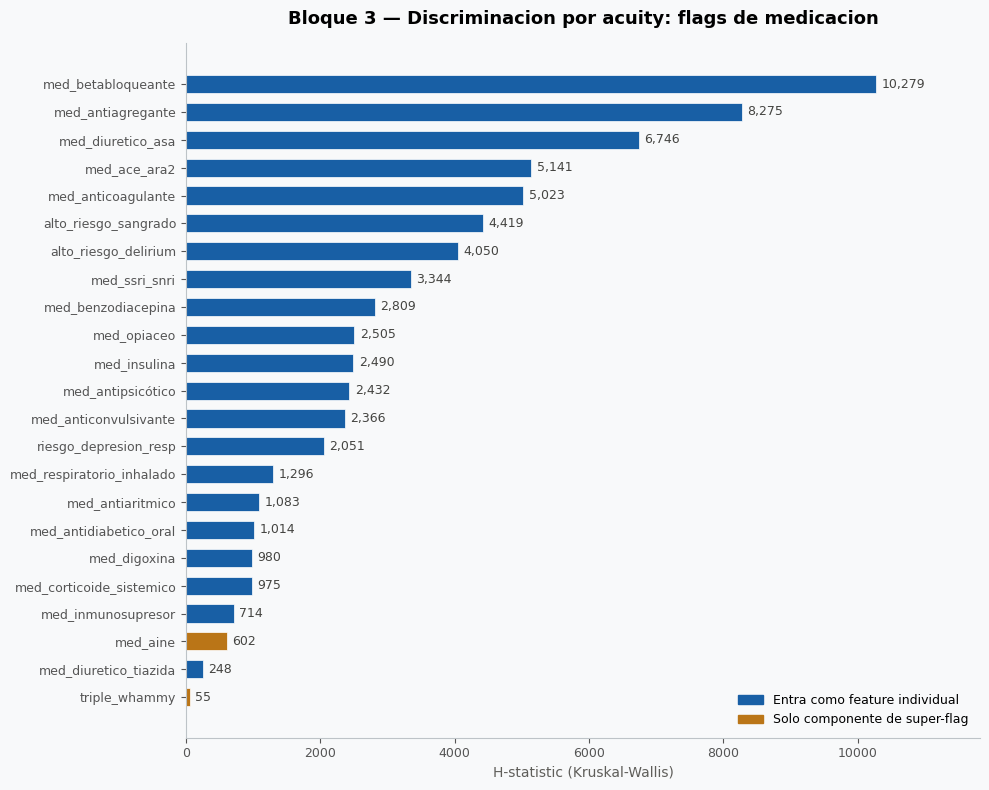

In [296]:
# H-stat de las flags de medicacion (leido de feature_metrics.json)
import matplotlib.patches as mpatches

metricas = leer_metricas()

FLAGS_MED = [
    'med_anticoagulante', 'med_antiagregante', 'med_insulina',
    'med_antidiabetico_oral', 'med_corticoide_sistemico', 'med_opiaceo',
    'med_benzodiacepina', 'med_betabloqueante', 'med_ace_ara2',
    'med_diuretico_asa', 'med_diuretico_tiazida', 'med_antipsicótico',
    'med_ssri_snri', 'med_anticonvulsivante', 'med_respiratorio_inhalado',
    'med_inmunosupresor', 'med_digoxina', 'med_antiaritmico', 'med_aine',
]
SUPER_FLAGS = ['triple_whammy', 'alto_riesgo_sangrado', 'alto_riesgo_delirium', 'riesgo_depresion_resp']

ENTRAN_MODEL = set(FEATURES_BINARIAS)

flags_data = []
for feat in FLAGS_MED + SUPER_FLAGS:
    H_val = (metricas.get(feat) or {}).get('H')
    if H_val is None and feat in df.columns:
        stat, _ = kruskal(*[df.loc[df['acuity'] == k, feat].values for k in ACUITY_LEVELS])
        H_val = float(stat)
        update_metrics_json(feat, H=round(H_val, 4), tipo='binaria')
    decision = 'entra' if feat in ENTRAN_MODEL else 'componente/descartada'
    flags_data.append((feat, float(H_val or 0), decision))

flags_sorted = sorted(flags_data, key=lambda x: x[1])
nombres = [f[0] for f in flags_sorted]
hstats  = [f[1] for f in flags_sorted]
colores = ['#185FA5' if f[2] == 'entra' else '#BA7517' for f in flags_sorted]

fig, ax = plt.subplots(figsize=(10, 8))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#F8F9FA')

bars = ax.barh(nombres, hstats, color=colores, height=0.65, edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, hstats):
    ax.text(bar.get_width() + 80, bar.get_y() + bar.get_height() / 2,
            f'{val:,.0f}', va='center', ha='left', fontsize=9, color='#444441')

ax.set_xlabel('H-statistic (Kruskal-Wallis)', fontsize=10, color='#5F5E5A')
ax.set_title('Bloque 3 — Discriminacion por acuity: flags de medicacion',
             fontsize=13, fontweight='bold', pad=14)
ax.set_xlim(0, max(hstats) * 1.15 if hstats else 1)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#BDC3C7')
ax.tick_params(colors='#555555', labelsize=9)

patch_entra      = mpatches.Patch(color='#185FA5', label='Entra como feature individual')
patch_componente = mpatches.Patch(color='#BA7517', label='Solo componente de super-flag')
ax.legend(handles=[patch_entra, patch_componente], fontsize=9, frameon=False, loc='lower right')

plt.tight_layout()
plt.show()


In [297]:
# SUPER-FLAGS: definición lógica sobre flags individuales ya calculadas
# Representan combinaciones farmacológicas de riesgo clínico conocido
# Se calculan DESPUÉS de tener todas las flags individuales disponibles

# CLASE 18: triple_whammy
# ACE/ARA2 + (diurético asa O tiazida) + AINE → riesgo de fracaso renal agudo
df["triple_whammy"] = (
    (df["med_ace_ara2"] == 1) &
    ((df["med_diuretico_asa"] == 1) | (df["med_diuretico_tiazida"] == 1)) &
    (df["med_aine"] == 1)
).astype("int8")

# CLASE 19: alto_riesgo_delirium
# Benzodiacepina O antipsicótico → sedación/confusión en ancianos (Beers criteria)
df["alto_riesgo_delirium"] = (
    (df["med_benzodiacepina"] == 1) | (df["med_antipsicótico"] == 1)
).astype("int8")

# CLASE 20: riesgo_depresion_resp
# Opioide + (benzo O antipsicótico O anticonvulsivante) → depresión respiratoria
df["riesgo_depresion_resp"] = (
    (df["med_opiaceo"] == 1) &
    (
        (df["med_benzodiacepina"]    == 1) |
        (df["med_antipsicótico"]     == 1) |
        (df["med_anticonvulsivante"] == 1)
    )
).astype("int8")

# CLASE 21: alto_riesgo_sangrado
# Anticoag OR (antiagregante + AINE) OR (anticoag + SSRI) → hemorragia grave
df["alto_riesgo_sangrado"] = (
    (df["med_anticoagulante"] == 1) |
    ((df["med_antiagregante"] == 1) & (df["med_aine"]       == 1)) |
    ((df["med_anticoagulante"] == 1) & (df["med_ssri_snri"] == 1))
).astype("int8")

# H-stats y prevalencias
for col in ["triple_whammy", "alto_riesgo_delirium", "riesgo_depresion_resp", "alto_riesgo_sangrado"]:
    stat, pval = kruskal(*[
        df.loc[df["acuity"] == k, col].values
        for k in ACUITY_LEVELS
    ])
    prev = df[col].mean() * 100
    n    = int(df[col].sum())
    print(f"{col:<25}  H = {stat:,.0f}  |  p = {pval:.2e}  |  prevalencia = {prev:.2f}%  |  n = {n:,}")
    print((df.groupby("acuity")[col].mean() * 100).round(2).to_string())
    print()

triple_whammy              H = 55  |  p = 3.23e-11  |  prevalencia = 1.00%  |  n = 4,170
acuity
1    0.92
2    1.06
3    1.02
4    0.63
5    0.18

alto_riesgo_delirium       H = 4,050  |  p = 0.00e+00  |  prevalencia = 20.13%  |  n = 84,182
acuity
1    20.24
2    24.57
3    18.78
4     9.49
5     9.36

riesgo_depresion_resp      H = 2,051  |  p = 0.00e+00  |  prevalencia = 9.60%  |  n = 40,124
acuity
1    10.35
2    11.50
3     9.18
4     3.17
5     3.09

alto_riesgo_sangrado       H = 4,419  |  p = 0.00e+00  |  prevalencia = 9.70%  |  n = 40,540
acuity
1    12.50
2    13.32
3     7.99
4     3.36
5     2.91



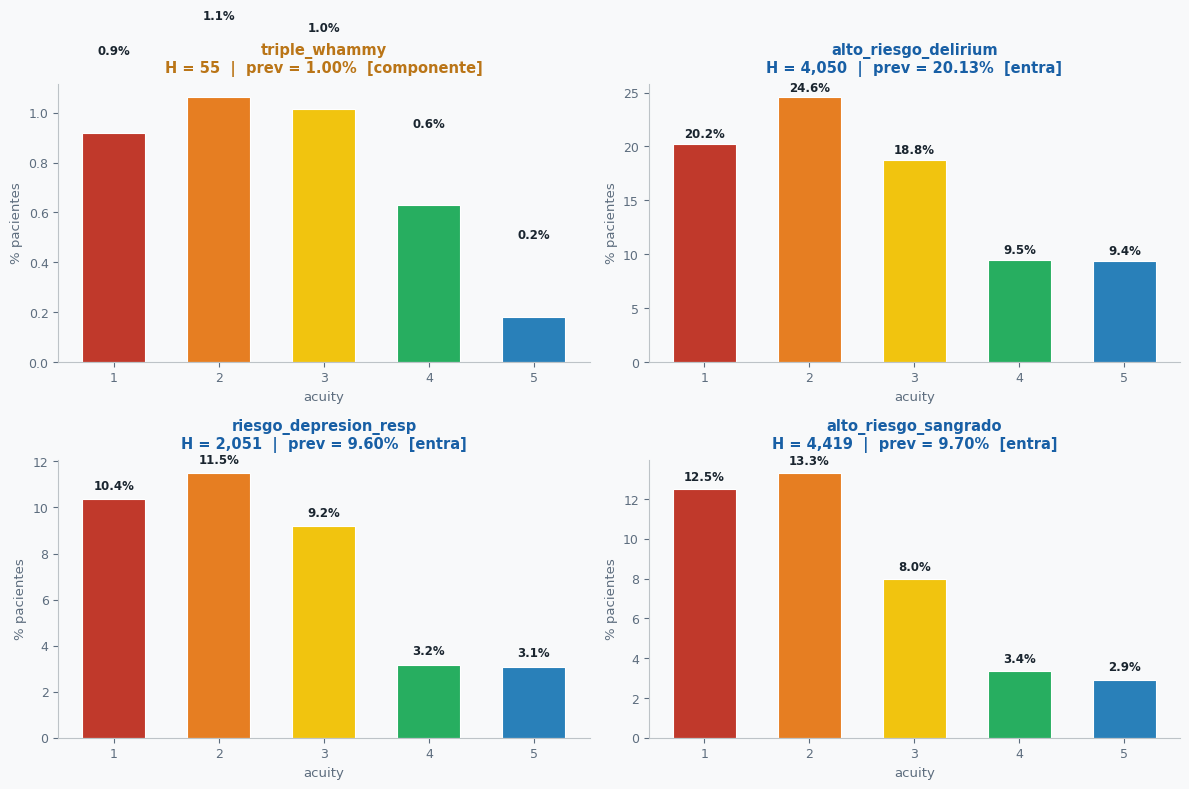

In [298]:
# Grafico super-flags de medicacion (valores calculados en df)

super_flags_list = [
    ('triple_whammy',         'componente'),
    ('alto_riesgo_delirium',  'entra'),
    ('riesgo_depresion_resp', 'entra'),
    ('alto_riesgo_sangrado',  'entra'),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.patch.set_facecolor('#F8F9FA')

for ax, (col, decision) in zip(axes.flat, super_flags_list):
    if col not in df.columns:
        ax.set_visible(False)
        continue
    ax.set_facecolor('#F8F9FA')
    valores = [float(df.loc[df['acuity'] == k, col].mean() * 100) for k in ACUITY_LEVELS]
    H_sf, _ = kruskal(*[df.loc[df['acuity'] == k, col].values for k in ACUITY_LEVELS])
    H_sf = float(H_sf)
    prev_sf = df[col].mean() * 100
    update_metrics_json(col, H=round(H_sf, 4), tipo='binaria')

    bars = ax.bar(ACUITY_LEVELS, valores, color=PALETA_ACUITY,
                  edgecolor='white', linewidth=0.8, width=0.6)
    for bar, val in zip(bars, valores):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
                f'{val:.1f}%', ha='center', va='bottom',
                fontsize=8.5, fontweight='bold', color='#1A252F')

    color_titulo = '#BA7517' if decision == 'componente' else '#185FA5'
    ax.set_title(
        f'{col}\nH = {H_sf:,.0f}  |  prev = {prev_sf:.2f}%  [{decision}]',
        fontsize=10.5, fontweight='bold', color=color_titulo, pad=8
    )
    ax.set_xlabel('acuity', fontsize=9.5, color='#5D6D7E')
    ax.set_ylabel('% pacientes', fontsize=9.5, color='#5D6D7E')
    ax.set_xticks(ACUITY_LEVELS)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color('#BDC3C7')
    ax.tick_params(colors='#5D6D7E', labelsize=9)

plt.tight_layout()
plt.show()


N MEDICAMENTOS

In [299]:
# Variable continua: numero de medicamentos distintos por paciente

H_n_med, pval_n_med = kruskal(*[
    df.loc[df['acuity'] == k, 'n_medicamentos'].values
    for k in ACUITY_LEVELS
])
H_n_med      = float(H_n_med)
prev_con_med = (df['n_medicamentos'] > 0).mean() * 100
n_con_med    = int((df['n_medicamentos'] > 0).sum())

update_metrics_json('n_medicamentos', H=round(H_n_med, 4), tipo='continua')

print(f'n_medicamentos  ->  H = {H_n_med:,.0f}  |  p = {pval_n_med:.2e}  |  '
      f'con medicacion = {prev_con_med:.2f}%  |  n = {n_con_med:,}\n')
print('Mediana por clase de acuity:\n')
_med_n_med = df.groupby('acuity')['n_medicamentos'].median().round(2)
print(_med_n_med.to_string())
print('\nMedia por clase de acuity:\n')
print(df.groupby('acuity')['n_medicamentos'].mean().round(2).to_string())
print('\nDistribucion general:\n')
print(df['n_medicamentos'].describe().round(2).to_string())

_medianas_n_med = [float(_med_n_med.get(k, 0)) for k in ACUITY_LEVELS]


n_medicamentos  ->  H = 16,663  |  p = 0.00e+00  |  con medicacion = 73.01%  |  n = 305,273

Mediana por clase de acuity:

acuity
1    4.0
2    6.0
3    3.0
4    1.0
5    0.0

Media por clase de acuity:

acuity
1    6.52
2    7.36
3    5.66
4    2.83
5    2.20

Distribucion general:

count    418100.00
mean          6.07
std           6.72
min           0.00
25%           0.00
50%           4.00
75%          10.00
max          67.00


In [300]:
# Umbrales clinicos: polifarmacia >=5, hiperpolifarmacia >=10

df['sin_medicacion']    = (df['n_medicamentos'] == 0).astype('int8')
df['polifarmacia']      = (df['n_medicamentos'] >= 5).astype('int8')
df['hiperpolifarmacia'] = (df['n_medicamentos'] >= 10).astype('int8')

H_poli: dict[str, float] = {}
pcts_poli_xacuity: dict[str, list] = {}

for col in ['sin_medicacion', 'polifarmacia', 'hiperpolifarmacia']:
    stat, pval = kruskal(*[
        df.loc[df['acuity'] == k, col].values for k in ACUITY_LEVELS
    ])
    H_poli[col] = float(stat)
    prev = df[col].mean() * 100
    n    = int(df[col].sum())
    pcts_poli_xacuity[col] = [
        float(df.loc[df['acuity'] == k, col].mean() * 100)
        for k in ACUITY_LEVELS
    ]
    update_metrics_json(col, H=round(float(stat), 4), tipo='binaria')
    print(f'{col:<22}  H = {stat:,.0f}  |  p = {pval:.2e}  |  '
          f'prevalencia = {prev:.2f}%  |  n = {n:,}')
    print((df.groupby('acuity')[col].mean() * 100).round(2).to_string())
    print()


sin_medicacion          H = 9,827  |  p = 0.00e+00  |  prevalencia = 26.99%  |  n = 112,827
acuity
1    31.45
2    20.29
3    27.97
4    47.12
5    54.91

polifarmacia            H = 14,685  |  p = 0.00e+00  |  prevalencia = 46.79%  |  n = 195,615
acuity
1    49.91
2    57.00
3    43.49
4    21.44
5    16.18

hiperpolifarmacia       H = 9,247  |  p = 0.00e+00  |  prevalencia = 26.39%  |  n = 110,327
acuity
1    30.21
2    33.65
3    23.73
4     9.40
5     6.27



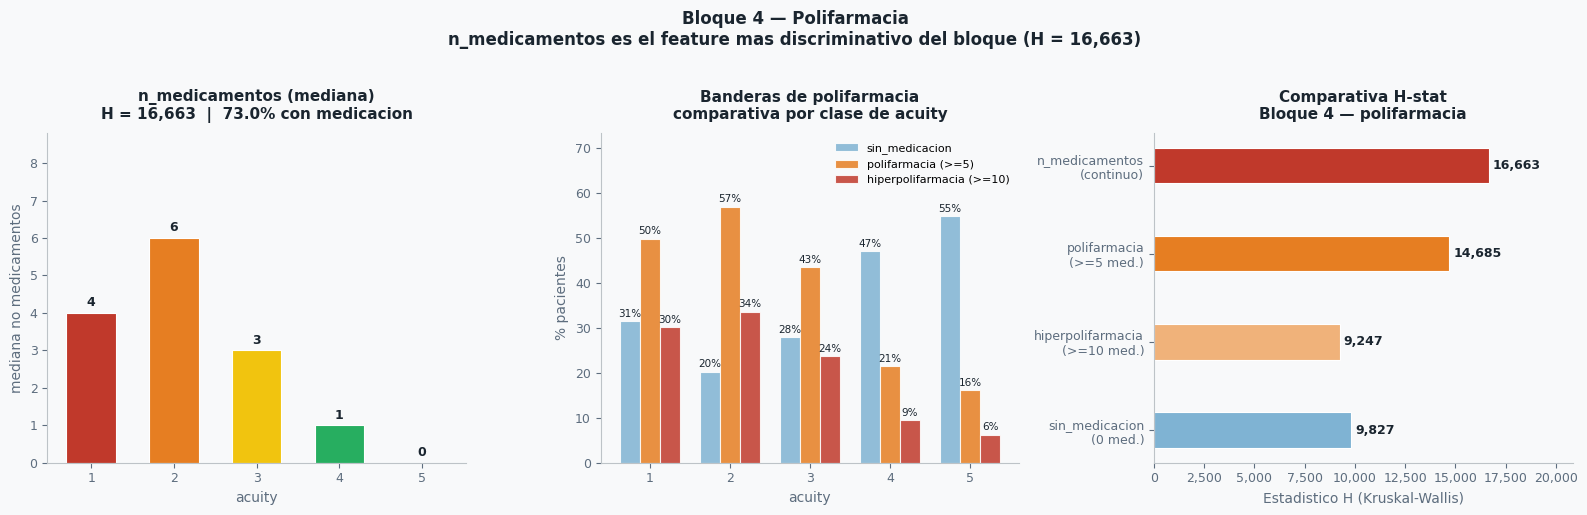

In [301]:
# GRAFICO BLOQUE 4: polifarmacia

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#F8F9FA')

ax1 = axes[0]
ax1.set_facecolor('#F8F9FA')
bars = ax1.bar(ACUITY_LEVELS, _medianas_n_med, color=PALETA_ACUITY,
               edgecolor='white', linewidth=0.8, width=0.6)
for bar, val in zip(bars, _medianas_n_med):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
             f'{val:.0f}', ha='center', va='bottom',
             fontsize=9, fontweight='bold', color='#1A252F')
ax1.set_xlabel('acuity', fontsize=10, color='#5D6D7E')
ax1.set_ylabel('mediana no medicamentos', fontsize=10, color='#5D6D7E')
ax1.set_title(
    f'n_medicamentos (mediana)\nH = {H_n_med:,.0f}  |  {prev_con_med:.1f}% con medicacion',
    fontsize=11, fontweight='bold', color='#1A252F', pad=10
)
ax1.set_xticks(ACUITY_LEVELS)
ax1.set_ylim(0, max(_medianas_n_med) * 1.3 + 1)
ax1.spines[['top', 'right']].set_visible(False)
ax1.spines[['left', 'bottom']].set_color('#BDC3C7')
ax1.tick_params(colors='#5D6D7E', labelsize=9)

ax2 = axes[1]
ax2.set_facecolor('#F8F9FA')
pcts_sinmed    = pcts_poli_xacuity['sin_medicacion']
pcts_poli      = pcts_poli_xacuity['polifarmacia']
pcts_hiperpoli = pcts_poli_xacuity['hiperpolifarmacia']
x = np.arange(len(ACUITY_LEVELS))
width = 0.25
bars1 = ax2.bar(x - width, pcts_sinmed, width, label='sin_medicacion',
                color='#7FB3D3', edgecolor='white', linewidth=0.8, alpha=0.85)
bars2 = ax2.bar(x,          pcts_poli,  width, label='polifarmacia (>=5)',
                color='#E67E22', edgecolor='white', linewidth=0.8, alpha=0.85)
bars3 = ax2.bar(x + width, pcts_hiperpoli, width, label='hiperpolifarmacia (>=10)',
                color='#C0392B', edgecolor='white', linewidth=0.8, alpha=0.85)
for bars_group, valores in [(bars1, pcts_sinmed), (bars2, pcts_poli), (bars3, pcts_hiperpoli)]:
    for bar, val in zip(bars_group, valores):
        ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                 f'{val:.0f}%', ha='center', va='bottom', fontsize=7.5, color='#1A252F')
ax2.set_xlabel('acuity', fontsize=10, color='#5D6D7E')
ax2.set_ylabel('% pacientes', fontsize=10, color='#5D6D7E')
ax2.set_title('Banderas de polifarmacia\ncomparativa por clase de acuity',
              fontsize=11, fontweight='bold', color='#1A252F', pad=10)
ax2.set_xticks(x)
ax2.set_xticklabels(ACUITY_LEVELS)
ax2.set_ylim(0, max(max(pcts_sinmed), max(pcts_poli)) * 1.2 + 5)
ax2.legend(frameon=False, fontsize=8)
ax2.spines[['top', 'right']].set_visible(False)
ax2.spines[['left', 'bottom']].set_color('#BDC3C7')
ax2.tick_params(colors='#5D6D7E', labelsize=9)

ax3 = axes[2]
ax3.set_facecolor('#F8F9FA')
features_h = [
    'sin_medicacion\n(0 med.)',
    'hiperpolifarmacia\n(>=10 med.)',
    'polifarmacia\n(>=5 med.)',
    'n_medicamentos\n(continuo)',
]
hstats_h = [
    H_poli['sin_medicacion'], H_poli['hiperpolifarmacia'],
    H_poli['polifarmacia'], H_n_med,
]
cols_h = ['#7FB3D3', '#F0B27A', '#E67E22', '#C0392B']
bars_h = ax3.barh(features_h, hstats_h, color=cols_h,
                  edgecolor='white', linewidth=0.8, height=0.4)
for bar, val in zip(bars_h, hstats_h):
    ax3.text(bar.get_width() + 200, bar.get_y() + bar.get_height() / 2,
             f'{val:,.0f}', va='center', ha='left',
             fontsize=9, fontweight='bold', color='#1A252F')
ax3.set_xlabel('Estadistico H (Kruskal-Wallis)', fontsize=10, color='#5D6D7E')
ax3.set_title('Comparativa H-stat\nBloque 4 — polifarmacia',
              fontsize=11, fontweight='bold', color='#1A252F', pad=10)
ax3.set_xlim(0, H_n_med * 1.25)
ax3.spines[['top', 'right']].set_visible(False)
ax3.spines[['left', 'bottom']].set_color('#BDC3C7')
ax3.tick_params(colors='#5D6D7E', labelsize=9)
ax3.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

fig.suptitle(
    f'Bloque 4 — Polifarmacia\n'
    f'n_medicamentos es el feature mas discriminativo del bloque (H = {H_n_med:,.0f})',
    fontsize=12, fontweight='bold', color='#1A252F', y=1.02
)
plt.tight_layout()
plt.show()


In [302]:
# Resumen dinamico Bloque 3 — Medicacion
metricas = leer_metricas()

ALL_MED_FEATS = [
    'med_betabloqueante', 'med_antiagregante', 'med_diuretico_asa',
    'med_ace_ara2', 'med_anticoagulante', 'alto_riesgo_sangrado',
    'alto_riesgo_delirium', 'med_ssri_snri', 'med_benzodiacepina',
    'med_opiaceo', 'med_insulina', 'med_antipsicótico',
    'med_anticonvulsivante', 'med_respiratorio_inhalado',
    'med_antidiabetico_oral', 'med_antiaritmico', 'med_digoxina',
    'med_corticoide_sistemico', 'med_inmunosupresor',
    'riesgo_depresion_resp', 'triple_whammy',
]

ENTRAN = set(FEATURES_BINARIAS)

filas_entra = []
filas_desc  = []

for feat in sorted(ALL_MED_FEATS, key=lambda f: -((metricas.get(f) or {}).get('H') or 0)):
    m = metricas.get(feat, {})
    H_val  = m.get('H')
    prev_v = df[feat].mean() * 100 if feat in df.columns else float('nan')
    h_str  = f'{H_val:,.0f}' if H_val else '—'
    row    = f'| `{feat}` | {h_str} | {prev_v:.2f}% |'
    if feat in ENTRAN:
        filas_entra.append(row)
    else:
        filas_desc.append(row)

print('## Resumen Bloque 3 — Medicacion')
print(f'Features que ENTRAN ({len(filas_entra)}):')
print('| Feature | H-stat | Prevalencia |')
print('|---|---|---|')
for r in filas_entra:
    print(r)
print(f'\nFeatures DESCARTADAS ({len(filas_desc)}):')
print('| Feature | H-stat | Prevalencia |')
print('|---|---|---|')
for r in filas_desc:
    print(r)


## Resumen Bloque 3 — Medicacion
Features que ENTRAN (20):
| Feature | H-stat | Prevalencia |
|---|---|---|
| `med_betabloqueante` | 10,279 | 22.01% |
| `med_antiagregante` | 8,275 | 22.56% |
| `med_diuretico_asa` | 6,746 | 9.75% |
| `med_ace_ara2` | 5,141 | 23.03% |
| `med_anticoagulante` | 5,023 | 7.32% |
| `alto_riesgo_sangrado` | 4,419 | 9.70% |
| `alto_riesgo_delirium` | 4,050 | 20.13% |
| `med_ssri_snri` | 3,344 | 23.35% |
| `med_benzodiacepina` | 2,809 | 16.39% |
| `med_opiaceo` | 2,505 | 15.55% |
| `med_insulina` | 2,490 | 13.22% |
| `med_antipsicótico` | 2,432 | 8.03% |
| `med_anticonvulsivante` | 2,366 | 15.31% |
| `riesgo_depresion_resp` | 2,051 | 9.60% |
| `med_respiratorio_inhalado` | 1,296 | 14.72% |
| `med_antiaritmico` | 1,083 | 1.10% |
| `med_antidiabetico_oral` | 1,014 | 9.37% |
| `med_digoxina` | 980 | 0.81% |
| `med_corticoide_sistemico` | 975 | 2.88% |
| `med_inmunosupresor` | 714 | 1.57% |

Features DESCARTADAS (1):
| Feature | H-stat | Prevalencia |
|---|---|---|

chiefcomplaint


In [303]:
# BLOQUE 5 — Paso 1: auditoría de chiefcomplaint
# Análisis del vocabulario real antes de definir ningún síndrome
# Incluye: value_counts, unigramas, bigramas y trigramas

from collections import Counter
import re

cc = df["chiefcomplaint"].dropna().str.lower().str.strip()

print(f"Total registros con chiefcomplaint: {cc.shape[0]:,}")
print(f"Registros sin chiefcomplaint (NaN): {df['chiefcomplaint'].isna().sum():,}")
print(f"Valores únicos (columna entera):    {cc.nunique():,}\n")

print("── Top 60 chief complaints exactos ─────────────────────────────────────")
print(cc.value_counts().head(60).to_string())

Total registros con chiefcomplaint: 418,083
Registros sin chiefcomplaint (NaN): 17
Valores únicos (columna entera):    57,458

── Top 60 chief complaints exactos ─────────────────────────────────────
chiefcomplaint
abd pain                    15817
chest pain                  13851
s/p fall                     7435
dyspnea                      7368
headache                     5116
wound eval                   5083
si                           4927
back pain                    4863
etoh                         4646
fever                        3557
altered mental status        3071
lower back pain              3039
dizziness                    3004
weakness                     3003
syncope                      2833
n/v                          2499
mvc                          2377
abnormal labs                2375
seizure                      2304
brbpr                        2293
sore throat                  2179
rash                         2172
ili                          2133
abd

In [304]:
# Auditoría de chiefcomplaint — estadísticas dinámicas
_n_total_cc = df['chiefcomplaint'].notna().sum()
_n_null_cc  = df['chiefcomplaint'].isna().sum()
_n_uniq_cc  = df['chiefcomplaint'].nunique()

display(Markdown(
    f'El campo `chiefcomplaint` contiene **{_n_total_cc:,}** registros con '
    f'solo **{_n_null_cc}** valores nulos, por lo que no hay que contemplar una clase '
    f'`cc_missing`. Con **{_n_uniq_cc:,}** valores únicos sobre {len(df):,} filas, '
    f'el texto es ruidoso, pero los top 60 términos ya revelan los grandes síndromes clínicos: '
    f'dolor abdominal, dolor torácico, trauma, disnea, neurológico, psiquiátrico e intoxicación.'
))

print(df['chiefcomplaint'].value_counts().head(20).to_string())


El campo `chiefcomplaint` contiene **418,083** registros con solo **17** valores nulos, por lo que no hay que contemplar una clase `cc_missing`. Con **59,471** valores únicos sobre 418,100 filas, el texto es ruidoso, pero los top 60 términos ya revelan los grandes síndromes clínicos: dolor abdominal, dolor torácico, trauma, disnea, neurológico, psiquiátrico e intoxicación.

chiefcomplaint
Chest pain               11284
Abd pain                 10761
Dyspnea                   5977
s/p Fall                  4940
ABD PAIN                  4935
SI                        4917
ETOH                      4637
Wound eval                4508
Headache                  3827
Back pain                 3165
Altered mental status     2665
Lower back pain           2630
CHEST PAIN                2536
N/V                       2490
S/P FALL                  2447
MVC                       2373
Syncope                   2296
BRBPR                     2292
Dizziness                 2234
Weakness                  2227


In [305]:
# BLOQUE 5 — Paso 1b: bigramas y trigramas
# Tokenizamos cada chief complaint y extraemos n-gramas
# Filtramos stopwords clínicas irrelevantes para no contaminar el conteo

from collections import Counter
import re

stopwords = {"the", "a", "an", "and", "or", "of", "to", "in", "for",
             "with", "on", "at", "by", "from", "is", "was", "be",
             "left", "right", "bilateral", "upper", "lower", "r", "l"}

def tokenizar(texto):
    return [t for t in re.findall(r"[a-z0-9/]+", texto)
            if t not in stopwords and len(t) > 1]

tokens_por_fila = cc.apply(tokenizar)

bigramas  = Counter()
trigramas = Counter()

for tokens in tokens_por_fila:
    for i in range(len(tokens) - 1):
        bigramas[(tokens[i], tokens[i+1])] += 1
    for i in range(len(tokens) - 2):
        trigramas[(tokens[i], tokens[i+1], tokens[i+2])] += 1

print("── Top 40 bigramas ──────────────────────────────────────────────────────")
for ngrama, count in bigramas.most_common(40):
    print(f"  {' '.join(ngrama):<35} {count:>7,}")

print("\n── Top 30 trigramas ─────────────────────────────────────────────────────")
for ngrama, count in trigramas.most_common(30):
    print(f"  {' '.join(ngrama):<45} {count:>7,}")

── Top 40 bigramas ──────────────────────────────────────────────────────
  abd pain                             35,289
  chest pain                           29,013
  s/p fall                             21,728
  back pain                            16,491
  abdominal pain                       12,487
  wound eval                            7,734
  flank pain                            6,462
  leg pain                              6,151
  mental status                         6,084
  altered mental                        5,977
  abnormal labs                         5,260
  knee pain                             5,021
  neck pain                             4,532
  sore throat                           4,405
  pain transfer                         4,222
  foot pain                             4,113
  shoulder pain                         3,787
  leg swelling                          3,655
  pain s/p                              3,450
  hip pain                              3,353
  arm 

In [306]:
# BLOQUE 5 — Paso 3: flags de chiefcomplaint (regex auditadas)
# 13 síndromes clínicos definidos por impacto fisiológico y riesgo en triaje
# Regex con límites de palabra (\b) para evitar falsos positivos
# Multi-label: un paciente puede tener múltiples flags activas simultáneamente

cc = df["chiefcomplaint"].str.lower().str.strip()

# 1. cc_dolor_toracico
df["cc_dolor_toracico"] = cc.str.contains(
    r"\bchest\s*pain\b|\bcp\b|\bchest\s*tightness\b|\bchest\s*pressure\b"
    r"|\bchest\s*discomfort\b|\bangina\b",
    case=False, regex=True, na=False
).astype("int8")

# 2. cc_disnea
# Añadido "dyspnea on exertion" explícitamente
df["cc_disnea"] = cc.str.contains(
    r"\bdyspnea\b|\bsob\b|\bshortness\s*of\s*breath\b|\bbreathing\b"
    r"|\brespiratory\s*distress\b|\bbreathless\b|\bdyspnea\s*on\s*exertion\b",
    case=False, regex=True, na=False
).astype("int8")

# 3. cc_gi_agudo
df["cc_gi_agudo"] = cc.str.contains(
    r"\babd\s*pain\b|\babdominal\s*pain\b|\bepigastric\b|\brlq\b|\bllq\b"
    r"|\bruq\b|\bn/v\b|\bn/v/d\b|\bnausea\b|\bvomiting\b|\bdiarrhea\b"
    r"|\bgastric\b|\bbowel\b",
    case=False, regex=True, na=False
).astype("int8")

# 4. cc_neuro_ams
# Eliminado \bloc\b — conflicto con "location" en texto libre
df["cc_neuro_ams"] = cc.str.contains(
    r"\baltered\s*mental\s*status\b|\bams\b|\bweakness\b|\bseizure\b"
    r"|\bsyncope\b|\bdizziness\b|\bconfusion\b|\bunresponsive\b"
    r"|\bloss\s*of\s*consciousness\b|\bnumbness\b|\bparalysis\b"
    r"|\bstroke\b|\bcva\b|\btia\b",
    case=False, regex=True, na=False
).astype("int8")

# 5. cc_cefalea
# Eliminado \bha\b — demasiado ruidoso en texto libre
df["cc_cefalea"] = cc.str.contains(
    r"\bheadache\b|\bhead\s*pain\b|\bmigraine\b",
    case=False, regex=True, na=False
).astype("int8")

# 6. cc_trauma
# Cinemática explícita — captura "back pain s/p fall", "pain s/p mvc"
df["cc_trauma"] = cc.str.contains(
    r"\bs/p\s*fall\b|\bmvc\b|\bfall\b|\btrauma\b|\binjury\b|\baccident\b"
    r"|\bhead\s*injury\b|\blaceration\b|\bwound\b|\bfracture\b|\bstab\b"
    r"|\bassault\b|\bgsw\b",
    case=False, regex=True, na=False
).astype("int8")

# 7. cc_psiquiatrico
df["cc_psiquiatrico"] = cc.str.contains(
    r"\bsi\b|\bsuicidal\b|\bsuicide\b|\banxiety\b|\bpsychiatric\b"
    r"|\bhallucination\b|\bagitation\b|\bdepression\b|\bmania\b"
    r"|\bparanoia\b|\bpsychosis\b",
    case=False, regex=True, na=False
).astype("int8")

# 8. cc_intoxicacion
# Eliminado \bod\b — conflicto con "oculus dexter" en urgencias oftalmológicas
df["cc_intoxicacion"] = cc.str.contains(
    r"\betoh\b|\bintoxication\b|\boverdose\b|\bingestion\b"
    r"|\bsubstance\b|\bdrug\s*use\b|\balcohol\b",
    case=False, regex=True, na=False
).astype("int8")

# 9. cc_infeccioso
df["cc_infeccioso"] = cc.str.contains(
    r"\bfever\b|\bili\b|\binfection\b|\bsepsis\b|\bcellulitis\b"
    r"|\bpneumonia\b|\bmeningitis\b|\binfluenza\b|\bcovid\b",
    case=False, regex=True, na=False
).astype("int8")

# 10. cc_urologico
df["cc_urologico"] = cc.str.contains(
    r"\bdysuria\b|\bhematuria\b|\burinary\s*retention\b|\bflank\s*pain\b"
    r"|\buti\b|\bkidney\b|\brenal\b|\bfoley\b|\burinary\b",
    case=False, regex=True, na=False
).astype("int8")

# 11. cc_hemorragia_activa
df["cc_hemorragia_activa"] = cc.str.contains(
    r"\bbrbpr\b|\brectal\s*bleeding\b|\bgib\b|\bvaginal\s*bleeding\b"
    r"|\bepistaxis\b|\bhemoptysis\b|\bbleeding\b|\bhemorrhage\b",
    case=False, regex=True, na=False
).astype("int8")

# 12. cc_alergia_anafilaxia
df["cc_alergia_anafilaxia"] = cc.str.contains(
    r"\ballergic\s*reaction\b|\banaphylaxis\b|\ballergy\b|\bangioedema\b"
    r"|\bhives\b|\burticaria\b",
    case=False, regex=True, na=False
).astype("int8")

# 13. cc_derivacion_urgente
# Añadido \beta\b — aviso previo de llegada de código grave por ambulancia
df["cc_derivacion_urgente"] = cc.str.contains(
    r"\babnormal\s*labs\b|\babnormal\s*ct\b|\babnormal\s*ekg\b"
    r"|\btransfer\b|\breferral\b|\bhyperglycemia\b|\bhypertension\b"
    r"|\bhyponatremia\b|\bhyperkalemia\b|\beta\b",
    case=False, regex=True, na=False
).astype("int8")

# H-stats y prevalencias
síndromes = [
    "cc_dolor_toracico", "cc_disnea", "cc_gi_agudo", "cc_neuro_ams",
    "cc_cefalea", "cc_trauma", "cc_psiquiatrico", "cc_intoxicacion",
    "cc_infeccioso", "cc_urologico", "cc_hemorragia_activa",
    "cc_alergia_anafilaxia", "cc_derivacion_urgente"
]

H_cc: dict[str, float] = {}
pcts_cc: dict[str, list] = {}

for col in síndromes:
    stat, pval = kruskal(*[
        df.loc[df['acuity'] == k, col].values
        for k in ACUITY_LEVELS
    ])
    prev = df[col].mean() * 100
    n    = int(df[col].sum())
    H_cc[col] = float(stat)
    pcts_cc[col] = [float(df.loc[df['acuity'] == k, col].mean() * 100) for k in ACUITY_LEVELS]
    update_metrics_json(col, H=round(float(stat), 4), tipo='binaria')
    print(f'{col:<25}  H = {stat:>7,.0f}  |  p = {pval:.2e}  |  prev = {prev:.2f}%  |  n = {n:,}')
    print((df.groupby('acuity')[col].mean() * 100).round(2).to_string())
    print()

cc_dolor_toracico          H =  12,707  |  p = 0.00e+00  |  prev = 7.56%  |  n = 31,614
acuity
1     4.48
2    13.86
3     4.95
4     0.24
5     0.18

cc_disnea                  H =  11,774  |  p = 0.00e+00  |  prev = 5.90%  |  n = 24,661
acuity
1    12.35
2    10.43
3     3.15
4     0.16
5     0.27

cc_gi_agudo                H =  18,161  |  p = 0.00e+00  |  prev = 16.63%  |  n = 69,541
acuity
1     5.97
2    10.80
3    23.44
4     0.99
5     0.18

cc_neuro_ams               H =  15,996  |  p = 0.00e+00  |  prev = 10.59%  |  n = 44,277
acuity
1    23.88
2    16.45
3     6.87
4     0.53
5     0.18

cc_cefalea                 H =     890  |  p = 1.95e-191  |  prev = 3.38%  |  n = 14,113
acuity
1    2.03
2    3.18
3    3.95
4    1.03
5    0.27

cc_trauma                  H =   6,071  |  p = 0.00e+00  |  prev = 13.13%  |  n = 54,914
acuity
1    12.01
2     9.71
3    13.66
4    26.64
5    14.18

cc_psiquiatrico            H =  11,976  |  p = 0.00e+00  |  prev = 3.53%  |  n = 14,760
acuity


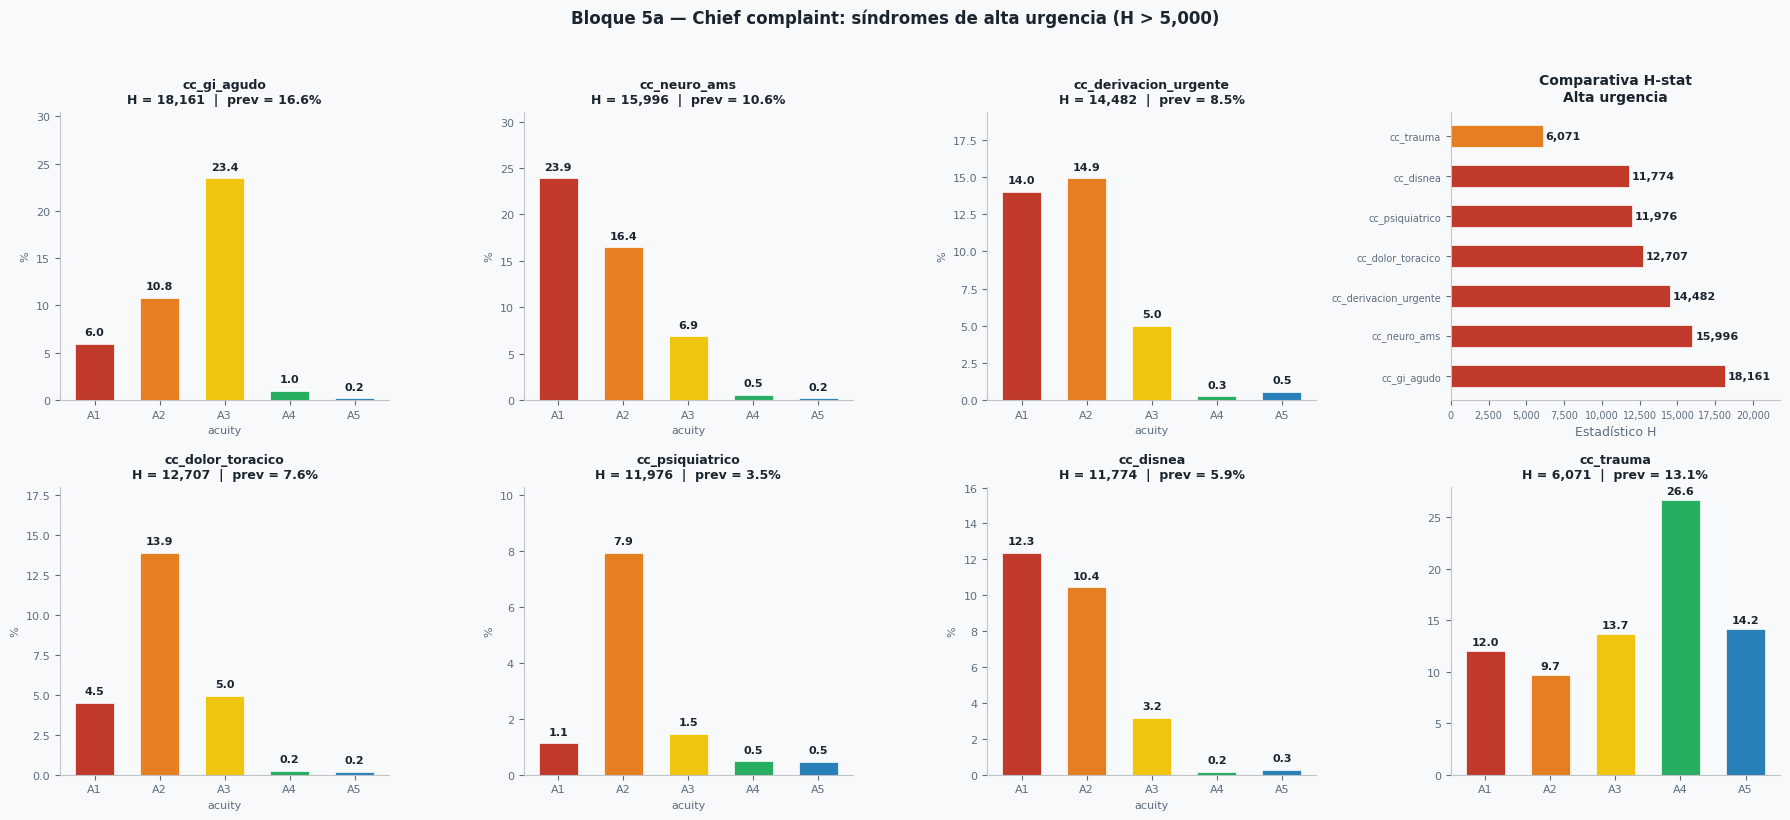

In [307]:
# GRÁFICO BLOQUE 5a: síndromes de alta urgencia (H > 5,000)

FLAGS_CC_ALTA = [
    'cc_gi_agudo', 'cc_neuro_ams', 'cc_derivacion_urgente',
    'cc_dolor_toracico', 'cc_psiquiatrico', 'cc_disnea', 'cc_trauma',
]

# Filtrar los que realmente tienen H > 5000 en el diccionario actual
_alta = {f: (pcts_cc.get(f, [0]*5), H_cc.get(f, 0), df[f].mean()*100)
         for f in FLAGS_CC_ALTA if f in H_cc}

acuity_labels_s = [f'A{k}' for k in ACUITY_LEVELS]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.patch.set_facecolor('#F8F9FA')

# Panel H-stat
ax_h = axes[0, 3]
ax_h.set_facecolor('#F8F9FA')
nombres_h = list(_alta.keys())
hvals_h   = [v[1] for v in _alta.values()]
cols_h    = ['#C0392B' if h > 10000 else '#E67E22' for h in hvals_h]

bars_h = ax_h.barh(nombres_h, hvals_h, color=cols_h,
                   edgecolor='white', linewidth=0.5, height=0.55)
for bar, val in zip(bars_h, hvals_h):
    ax_h.text(bar.get_width() + 200, bar.get_y() + bar.get_height() / 2,
              f'{val:,.0f}', va='center', ha='left',
              fontsize=8, fontweight='bold', color='#1A252F')
ax_h.set_xlabel('Estadístico H', fontsize=9, color='#5D6D7E')
ax_h.set_title('Comparativa H-stat\nAlta urgencia',
               fontsize=10, fontweight='bold', color='#1A252F', pad=8)
ax_h.set_xlim(0, max(hvals_h) * 1.2 if hvals_h else 1)
ax_h.spines[['top', 'right']].set_visible(False)
ax_h.spines[['left', 'bottom']].set_color('#BDC3C7')
ax_h.tick_params(colors='#5D6D7E', labelsize=7)
ax_h.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

# 6 paneles individuales
posiciones = [(0,0),(0,1),(0,2),(1,0),(1,1),(1,2)]
_items = list(_alta.items())[:6]
for (row, col), (sin, (vals, h, prev)) in zip(posiciones, _items):
    ax = axes[row, col]
    ax.set_facecolor('#F8F9FA')
    bars = ax.bar(acuity_labels_s, vals, color=PALETA_ACUITY,
                  edgecolor='white', linewidth=0.5, width=0.6)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(vals) * 0.03,
                f'{val:.1f}', ha='center', va='bottom',
                fontsize=8, fontweight='bold', color='#1A252F')
    ax.set_title(f'{sin}\nH = {h:,.0f}  |  prev = {prev:.1f}%',
                 fontsize=9, fontweight='bold', color='#1A252F', pad=6)
    ax.set_ylim(0, max(vals) * 1.3 if vals else 1)
    ax.set_xlabel('acuity', fontsize=8, color='#5D6D7E')
    ax.set_ylabel('%', fontsize=8, color='#5D6D7E')
    ax.set_xticks(range(len(ACUITY_LEVELS)))
    ax.set_xticklabels(acuity_labels_s)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color('#BDC3C7')
    ax.tick_params(colors='#5D6D7E', labelsize=8)

# Panel extra — 7mo síndrome (cc_trauma suele ser el 7mo)
if len(_items) < 7 and len(_alta) >= 7:
    _7th = list(_alta.items())[6]
    sin7, (vals7, h7, prev7) = _7th
    ax_t = axes[1, 3]
    ax_t.set_facecolor('#F8F9FA')
    bars = ax_t.bar(acuity_labels_s, vals7, color=PALETA_ACUITY,
                    edgecolor='white', linewidth=0.5, width=0.6)
    for bar, val in zip(bars, vals7):
        ax_t.text(bar.get_x() + bar.get_width() / 2,
                  bar.get_height() + 0.4,
                  f'{val:.1f}', ha='center', va='bottom',
                  fontsize=8, fontweight='bold', color='#1A252F')
    ax_t.set_title(f'{sin7}\nH = {h7:,.0f}  |  prev = {prev7:.1f}%',
                   fontsize=9, fontweight='bold', color='#1A252F', pad=6)
    ax_t.set_xticks(range(len(ACUITY_LEVELS)))
    ax_t.set_xticklabels(acuity_labels_s)
    ax_t.spines[['top', 'right']].set_visible(False)
    ax_t.spines[['left', 'bottom']].set_color('#BDC3C7')
    ax_t.tick_params(colors='#5D6D7E', labelsize=8)
else:
    axes[1, 3].set_visible(False)

fig.suptitle(
    'Bloque 5a — Chief complaint: síndromes de alta urgencia (H > 5,000)',
    fontsize=12, fontweight='bold', color='#1A252F', y=1.02
)
plt.tight_layout()
plt.show()


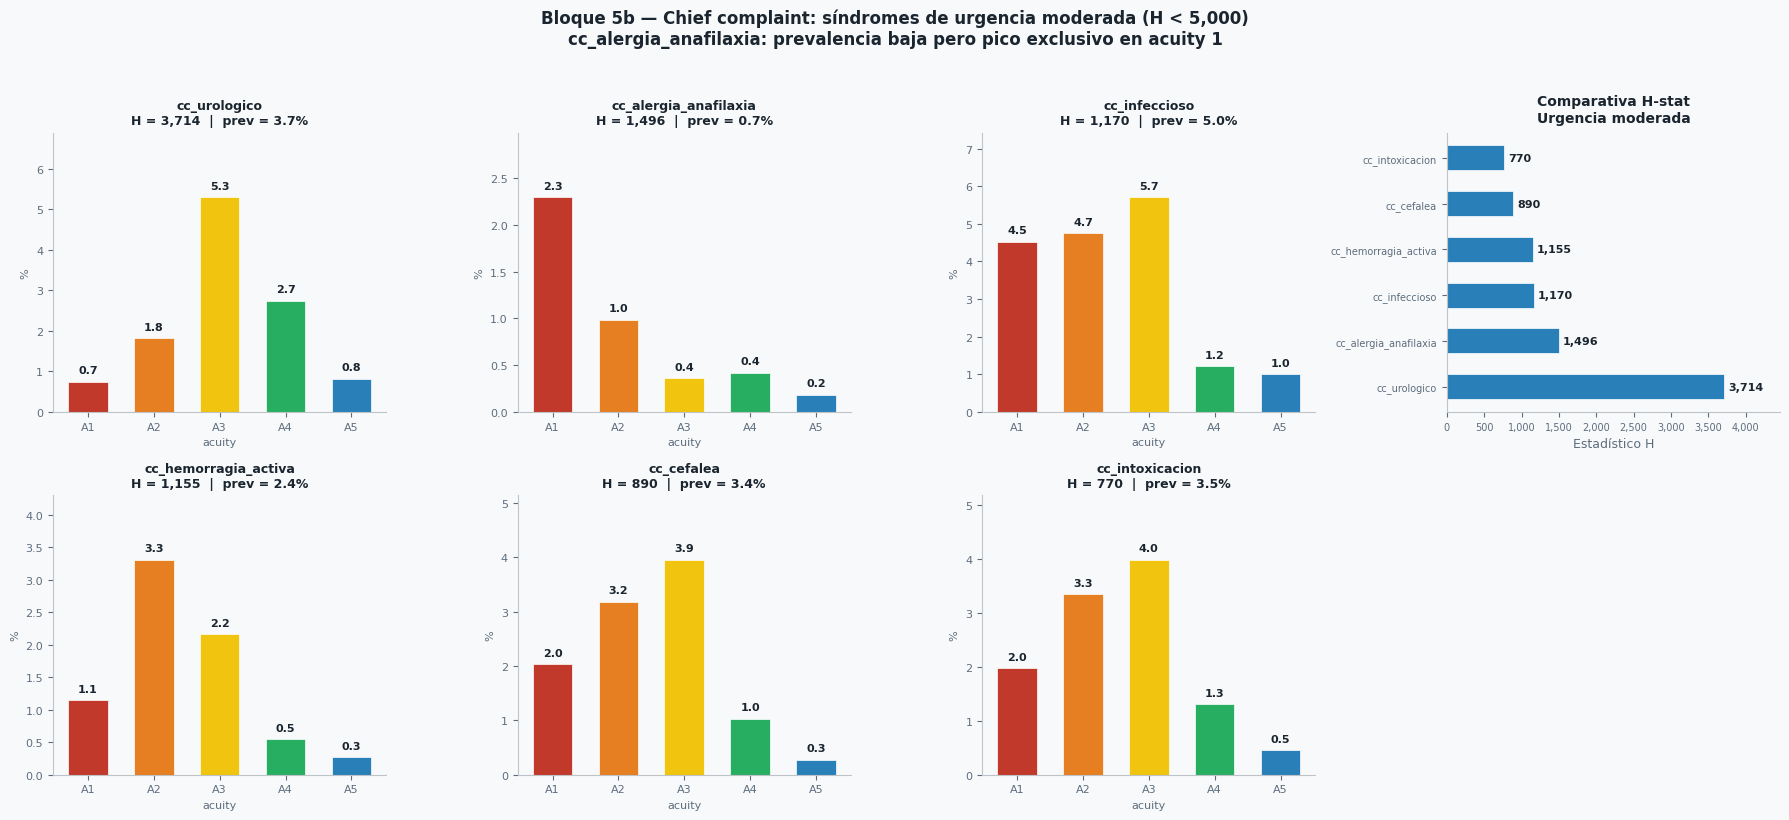

In [308]:
# GRÁFICO BLOQUE 5b: síndromes de urgencia moderada (H < 5,000)

FLAGS_CC_MOD = [
    'cc_urologico', 'cc_alergia_anafilaxia', 'cc_infeccioso',
    'cc_hemorragia_activa', 'cc_cefalea', 'cc_intoxicacion',
]

_mod = {f: (pcts_cc.get(f, [0]*5), H_cc.get(f, 0), df[f].mean()*100)
        for f in FLAGS_CC_MOD if f in H_cc}

acuity_labels_s = [f'A{k}' for k in ACUITY_LEVELS]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
fig.patch.set_facecolor('#F8F9FA')

# Panel H-stat
ax_h = axes[0, 3]
ax_h.set_facecolor('#F8F9FA')
nombres_h = list(_mod.keys())
hvals_h   = [v[1] for v in _mod.values()]

bars_h = ax_h.barh(nombres_h, hvals_h, color='#2980B9',
                   edgecolor='white', linewidth=0.5, height=0.55)
for bar, val in zip(bars_h, hvals_h):
    ax_h.text(bar.get_width() + 50, bar.get_y() + bar.get_height() / 2,
              f'{val:,.0f}', va='center', ha='left',
              fontsize=8, fontweight='bold', color='#1A252F')
ax_h.set_xlabel('Estadístico H', fontsize=9, color='#5D6D7E')
ax_h.set_title('Comparativa H-stat\nUrgencia moderada',
               fontsize=10, fontweight='bold', color='#1A252F', pad=8)
ax_h.set_xlim(0, max(hvals_h) * 1.2 if hvals_h else 1)
ax_h.spines[['top', 'right']].set_visible(False)
ax_h.spines[['left', 'bottom']].set_color('#BDC3C7')
ax_h.tick_params(colors='#5D6D7E', labelsize=7)
ax_h.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

# 6 paneles individuales
posiciones = [(0,0),(0,1),(0,2),(1,0),(1,1),(1,2)]
for (row, col), (sin, (vals, h, prev)) in zip(posiciones, _mod.items()):
    ax = axes[row, col]
    ax.set_facecolor('#F8F9FA')
    bars = ax.bar(acuity_labels_s, vals, color=PALETA_ACUITY,
                  edgecolor='white', linewidth=0.5, width=0.6)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(vals) * 0.03,
                f'{val:.1f}', ha='center', va='bottom',
                fontsize=8, fontweight='bold', color='#1A252F')
    ax.set_title(f'{sin}\nH = {h:,.0f}  |  prev = {prev:.1f}%',
                 fontsize=9, fontweight='bold', color='#1A252F', pad=6)
    ax.set_ylim(0, max(vals) * 1.3 if vals else 1)
    ax.set_xlabel('acuity', fontsize=8, color='#5D6D7E')
    ax.set_ylabel('%', fontsize=8, color='#5D6D7E')
    ax.set_xticks(range(len(ACUITY_LEVELS)))
    ax.set_xticklabels(acuity_labels_s)
    ax.spines[['top', 'right']].set_visible(False)
    ax.spines[['left', 'bottom']].set_color('#BDC3C7')
    ax.tick_params(colors='#5D6D7E', labelsize=8)

axes[1, 3].set_visible(False)

fig.suptitle(
    'Bloque 5b — Chief complaint: síndromes de urgencia moderada (H < 5,000)\n'
    'cc_alergia_anafilaxia: prevalencia baja pero pico exclusivo en acuity 1',
    fontsize=12, fontweight='bold', color='#1A252F', y=1.02
)
plt.tight_layout()
plt.show()


In [309]:
# Narrativa chief complaint — H-stats dinamicos desde H_cc

_cc_narrativa = {
    'cc_gi_agudo':           'Mas frecuente y mayor H-stat. Dolor abdominal domina acuity 3 — urgencia media bien delimitada.',
    'cc_neuro_ams':          'Predictor mas potente de acuity 1 del bloque. Ictus, encefalopatia, sincope, crisis.',
    'cc_derivacion_urgente': 'Pacientes derivados con analitica/TAC/EKG alterados concentrados en acuity 1-2.',
    'cc_dolor_toracico':     'Clasico de urgencias. Pico en acuity 2 — protocolo descarte SCA. Ausente en acuity 4-5.',
    'cc_psiquiatrico':       'Concentracion en acuity 2. Ideacion suicida activa = vigilancia estrecha.',
    'cc_disnea':             'Unica flag con pico acuity 1 > acuity 2. Dificultad resp. grave va directamente a reanimacion.',
    'cc_trauma':             'Distribucion bimodal: trauma menor (acuity 4) + TCE grave (acuity 1).',
    'cc_urologico':          'Urgencia media: pico acuity 3. Valor en interaccion con fiebre e hipotension (sepsis urologica).',
    'cc_alergia_anafilaxia': 'Mas infrecuente pero pico mas especifico en acuity 1. Altisima especificidad clinica.',
    'cc_infeccioso':         'Distribucion suave 1-3. Valor en interaccion con hipotension+taquicardia+taquipnea (sepsis).',
    'cc_hemorragia_activa':  'Concentracion en acuity 2. Interaccion con hipotension y taquicardia es la senal critica.',
    'cc_cefalea':            'Pico acuity 3 (tensionales/migrana). Se mantiene por riesgo hemorragia subaracnoidea.',
    'cc_intoxicacion':       'H mas bajo del bloque. Interaccion con cc_neuro_ams y ausencia med. cronica es la senal.',
}

for feat, texto in _cc_narrativa.items():
    H_val   = H_cc.get(feat, float('nan'))
    prev_val = df[feat].mean() * 100 if feat in df.columns else float('nan')
    print(f'### {feat}  (H = {H_val:,.0f} | prev = {prev_val:.2f}%)')
    print(texto)
    print()


### cc_gi_agudo  (H = 18,161 | prev = 16.63%)
Mas frecuente y mayor H-stat. Dolor abdominal domina acuity 3 — urgencia media bien delimitada.

### cc_neuro_ams  (H = 15,996 | prev = 10.59%)
Predictor mas potente de acuity 1 del bloque. Ictus, encefalopatia, sincope, crisis.

### cc_derivacion_urgente  (H = 14,482 | prev = 8.49%)
Pacientes derivados con analitica/TAC/EKG alterados concentrados en acuity 1-2.

### cc_dolor_toracico  (H = 12,707 | prev = 7.56%)
Clasico de urgencias. Pico en acuity 2 — protocolo descarte SCA. Ausente en acuity 4-5.

### cc_psiquiatrico  (H = 11,976 | prev = 3.53%)
Concentracion en acuity 2. Ideacion suicida activa = vigilancia estrecha.

### cc_disnea  (H = 11,774 | prev = 5.90%)
Unica flag con pico acuity 1 > acuity 2. Dificultad resp. grave va directamente a reanimacion.

### cc_trauma  (H = 6,071 | prev = 13.13%)
Distribucion bimodal: trauma menor (acuity 4) + TCE grave (acuity 1).

### cc_urologico  (H = 3,714 | prev = 3.69%)
Urgencia media: pico acuit

Cada entrada define la misma feature desde dos perspectivas:
   - REGEX: expresión regular aplicada sobre chiefcomplaint en MIMIC (entrenamiento)
  - LLM:   instrucción en español para el prompt de producción (inferencia)
El LLM devuelve directamente el JSON con los nombres exactos de columna.
No se aplica ningún str.contains en producción.

---

## cc_dolor_toracico
**REGEX (MIMIC):**
`\bchest\s*pain\b|\bcp\b|\bchest\s*tightness\b|\bchest\s*pressure\b|\bchest\s*discomfort\b|\bangina\b`

**LLM (producción):**
Activa `cc_dolor_toracico = 1` si el paciente refiere dolor, presión,
opresión, quemazón o malestar en el pecho, zona precordial o esternal,
incluyendo dolor que irradia al brazo izquierdo, mandíbula o espalda.
También si menciona angina o dolor torácico de cualquier tipo.

---

## cc_disnea
**REGEX (MIMIC):**
`\bdyspnea\b|\bsob\b|\bshortness\s*of\s*breath\b|\bbreathing\b|\brespiratory\s*distress\b|\bbreathless\b|\bdyspnea\s*on\s*exertion\b`

**LLM (producción):**
Activa `cc_disnea = 1` si el paciente refiere dificultad para respirar,
falta de aire, sensación de ahogo, disnea de esfuerzo o en reposo,
o cualquier forma de compromiso respiratorio subjetivo.

---

## cc_gi_agudo
**REGEX (MIMIC):**
`\babd\s*pain\b|\babdominal\s*pain\b|\bepigastric\b|\brlq\b|\bllq\b|\bruq\b|\bn/v\b|\bn/v/d\b|\bnausea\b|\bvomiting\b|\bdiarrhea\b|\bgastric\b|\bbowel\b`

**LLM (producción):**
Activa `cc_gi_agudo = 1` si el paciente refiere dolor abdominal de
cualquier localización (epigástrico, fosa iliaca, hipocondrio, difuso),
náuseas, vómitos, diarrea, o cualquier síntoma digestivo agudo que
motive la consulta.

---

## cc_neuro_ams
**REGEX (MIMIC):**
`\baltered\s*mental\s*status\b|\bams\b|\bweakness\b|\bseizure\b|\bsyncope\b|\bdizziness\b|\bconfusion\b|\bunresponsive\b|\bloss\s*of\s*consciousness\b|\bnumbness\b|\bparalysis\b|\bstroke\b|\bcva\b|\btia\b`

**LLM (producción):**
Activa `cc_neuro_ams = 1` si el paciente presenta alteración del nivel
de consciencia, confusión, desorientación, pérdida de consciencia,
síncope, crisis convulsiva, debilidad o parálisis de extremidades,
entumecimiento, mareo intenso, o sospecha de ictus o AIT.

---

## cc_cefalea
**REGEX (MIMIC):**
`\bheadache\b|\bhead\s*pain\b|\bmigraine\b`

**LLM (producción):**
Activa `cc_cefalea = 1` si el paciente refiere dolor de cabeza como
motivo principal de consulta, incluyendo migraña, cefalea tensional,
o cefalea de inicio brusco ("la peor de su vida").

---

## cc_trauma
**REGEX (MIMIC):**
`\bs/p\s*fall\b|\bmvc\b|\bfall\b|\btrauma\b|\binjury\b|\baccident\b|\bhead\s*injury\b|\blaceration\b|\bwound\b|\bfracture\b|\bstab\b|\bassault\b|\bgsw\b`

**LLM (producción):**
Activa `cc_trauma = 1` si existe un mecanismo lesional explícito:
caída, accidente de tráfico, traumatismo directo, herida por arma
blanca o de fuego, agresión física, o cualquier lesión secundaria
a un traumatismo. Incluye heridas, laceraciones y fracturas.

---

## cc_psiquiatrico
**REGEX (MIMIC):**
`\bsi\b|\bsuicidal\b|\bsuicide\b|\banxiety\b|\bpsychiatric\b|\bhallucination\b|\bagitation\b|\bdepression\b|\bmania\b|\bparanoia\b|\bpsychosis\b`

**LLM (producción):**
Activa `cc_psiquiatrico = 1` si el motivo de consulta es de naturaleza
psiquiátrica: ideación suicida, intento autolítico, crisis de ansiedad,
agitación psicomotriz, alucinaciones, episodio maníaco, brote psicótico
o cualquier descompensación de enfermedad mental.

---

## cc_intoxicacion
**REGEX (MIMIC):**
`\betoh\b|\bintoxication\b|\boverdose\b|\bingestion\b|\bsubstance\b|\bdrug\s*use\b|\balcohol\b`

**LLM (producción):**
Activa `cc_intoxicacion = 1` si el paciente llega por intoxicación
etílica aguda, sobredosis de fármacos o drogas, ingesta de tóxicos,
o consumo de sustancias psicoactivas como motivo principal de consulta.

---

## cc_infeccioso
**REGEX (MIMIC):**
`\bfever\b|\bili\b|\binfection\b|\bsepsis\b|\bcellulitis\b|\bpneumonia\b|\bmeningitis\b|\binfluenza\b|\bcovid\b`

**LLM (producción):**
Activa `cc_infeccioso = 1` si el paciente presenta fiebre, síndrome
gripal, infección activa de cualquier localización (respiratoria,
cutánea, urinaria, sistémica), o sospecha de sepsis como motivo
principal de consulta.

---

## cc_urologico
**REGEX (MIMIC):**
`\bdysuria\b|\bhematuria\b|\burinary\s*retention\b|\bflank\s*pain\b|\buti\b|\bkidney\b|\brenal\b|\bfoley\b|\burinary\b`

**LLM (producción):**
Activa `cc_urologico = 1` si el paciente refiere dolor en el flanco
o fosa renal, escozor al orinar, sangre en orina, imposibilidad para
orinar, o cualquier síntoma del tracto urinario como motivo principal
de consulta.

---

## cc_hemorragia_activa
**REGEX (MIMIC):**
`\bbrbpr\b|\brectal\s*bleeding\b|\bgib\b|\bvaginal\s*bleeding\b|\bepistaxis\b|\bhemoptysis\b|\bbleeding\b|\bhemorrhage\b`

**LLM (producción):**
Activa `cc_hemorragia_activa = 1` si el paciente presenta sangrado
activo visible: sangrado rectal, hemorragia digestiva, sangrado
vaginal, epistaxis, hemoptisis, o cualquier hemorragia externa
activa como motivo de consulta.

---

## cc_alergia_anafilaxia
**REGEX (MIMIC):**
`\ballergic\s*reaction\b|\banaphylaxis\b|\ballergy\b|\bangioedema\b|\bhives\b|\burticaria\b`

**LLM (producción):**
Activa `cc_alergia_anafilaxia = 1` si el paciente llega por reacción
alérgica de cualquier grado, urticaria, angioedema, o sospecha de
anafilaxia. Incluye reacciones a fármacos, alimentos, picaduras
o cualquier otro alérgeno.

---

## cc_derivacion_urgente
**REGEX (MIMIC):**
`\babnormal\s*labs\b|\babnormal\s*ct\b|\babnormal\s*ekg\b|\btransfer\b|\breferral\b|\bhyperglycemia\b|\bhypertension\b|\bhyponatremia\b|\bhyperkalemia\b|\beta\b`

**LLM (producción):**
Activa `cc_derivacion_urgente = 1` si el paciente es derivado desde
atención primaria, otro centro, o llega por aviso previo de emergencias
debido a una anomalía objetiva ya detectada: analítica alterada,
prueba de imagen patológica, ECG anormal, hiperglucemia grave,
alteración electrolítica severa, o aviso de llegada de código urgente.

In [310]:
# BLOQUE 5 — Paso 4c: construcción de muestra híbrida
# 200 filas estratificadas por acuity (40 por nivel) +
# 50 positivos garantizados para cada flag rara (prevalencia < 2%)
# Deduplicación final para no repetir filas
# random_state=42

FLAGS = [
    "cc_dolor_toracico", "cc_disnea", "cc_gi_agudo", "cc_neuro_ams",
    "cc_cefalea", "cc_trauma", "cc_psiquiatrico", "cc_intoxicacion",
    "cc_infeccioso", "cc_urologico", "cc_hemorragia_activa",
    "cc_alergia_anafilaxia", "cc_derivacion_urgente",
]

FLAGS_RARAS = [
    "cc_alergia_anafilaxia",
    "cc_hemorragia_activa",
    "cc_intoxicacion",
    "cc_psiquiatrico"
]

cols = ["stay_id", "acuity", "chiefcomplaint"] + FLAGS

# base estratificada por acuity
base = (
    df[cols]
    .dropna(subset=["chiefcomplaint"])
    .groupby("acuity", group_keys=False)[cols]
    .apply(lambda x: x.sample(n=40, random_state=42))
    .reset_index(drop=True)
)

# positivos garantizados por flag rara
extras = []
for flag in FLAGS_RARAS:
    positivos = (
        df[cols]
        .dropna(subset=["chiefcomplaint"])
        .loc[df[flag] == 1]
        .sample(n=50, random_state=42)
    )
    extras.append(positivos)

muestra_hibrida = (
    pd.concat([base] + extras, ignore_index=True)
    .drop_duplicates(subset=["stay_id"])
    .reset_index(drop=True)
)

print(f"Total muestra híbrida: {len(muestra_hibrida):,} filas\n")
print("Distribución por acuity:")
print(muestra_hibrida["acuity"].value_counts().sort_index().to_string())
print("\nPositivos por flag rara:")
for flag in FLAGS_RARAS:
    n = muestra_hibrida[flag].sum()
    print(f"  {flag:<25} {n:>3} positivos")

Total muestra híbrida: 400 filas

Distribución por acuity:
acuity
1     56
2    140
3    119
4     45
5     40

Positivos por flag rara:
  cc_alergia_anafilaxia      52 positivos
  cc_hemorragia_activa       55 positivos
  cc_intoxicacion            59 positivos
  cc_psiquiatrico            61 positivos


In [311]:
# test rápido: una sola llamada a Groq
import time

inicio = time.time()
resultado = clasificar_llm("chest pain")
fin = time.time()

print(f"Resultado: {resultado}")
print(f"Tiempo: {fin - inicio:.2f} segundos")

NameError: name 'clasificar_llm' is not defined

In [ ]:
import os
# BLOQUE 5 — Paso 4d v2: clasificación LLM con prompt reducido (Groq)
# Prompt corto para reducir latencia — reglas en inglés para evitar cross-lingual
# Modelo: llama-3.1-8b-instant | 400 filas | objetivo <5 minutos

import requests
import json
import time
from tqdm import tqdm

GROQ_API_KEY = os.getenv("GROQ_API_KEY", "")
GROQ_URL     = "https://api.groq.com/openai/v1/chat/completions"

SYSTEM_PROMPT_CORTO = """Classify the emergency chief complaint. 
Return ONLY a JSON object with these 13 keys set to 0 or 1:

cc_dolor_toracico: chest pain, angina, cp, chest tightness
cc_disnea: sob, shortness of breath, dyspnea, breathing difficulty
cc_gi_agudo: abd pain, abdominal pain, nausea, vomiting, diarrhea, n/v, epigastric
cc_neuro_ams: ams, altered mental status, syncope, seizure, weakness, stroke, dizziness, confusion
cc_cefalea: headache, migraine, head pain
cc_trauma: fall, s/p fall, mvc, injury, laceration, wound, fracture, assault, gsw
cc_psiquiatrico: si, suicidal, anxiety, agitation, psychosis, hallucination, depression
cc_intoxicacion: etoh, overdose, intoxication, alcohol, ingestion
cc_infeccioso: fever, infection, sepsis, ili, cellulitis, pneumonia
cc_urologico: flank pain, dysuria, hematuria, urinary retention, uti
cc_hemorragia_activa: brbpr, bleeding, epistaxis, hemoptysis, vaginal bleeding, gib
cc_alergia_anafilaxia: allergic reaction, anaphylaxis, hives, angioedema, urticaria
cc_derivacion_urgente: transfer, abnormal labs, abnormal ct, abnormal ekg, hyperglycemia, hypertension, eta

Rules:
- Multiple keys can be 1 simultaneously.
- If not mentioned or denied, value is 0.
- Return ONLY the JSON object, no other text.

Example for 'chest pain and shortness of breath':
{"cc_dolor_toracico":1,"cc_disnea":1,"cc_gi_agudo":0,"cc_neuro_ams":0,"cc_cefalea":0,"cc_trauma":0,"cc_psiquiatrico":0,"cc_intoxicacion":0,"cc_infeccioso":0,"cc_urologico":0,"cc_hemorragia_activa":0,"cc_alergia_anafilaxia":0,"cc_derivacion_urgente":0}"""

FLAGS = [
    "cc_dolor_toracico", "cc_disnea", "cc_gi_agudo", "cc_neuro_ams",
    "cc_cefalea", "cc_trauma", "cc_psiquiatrico", "cc_intoxicacion",
    "cc_infeccioso", "cc_urologico", "cc_hemorragia_activa",
    "cc_alergia_anafilaxia", "cc_derivacion_urgente"
]

def clasificar_llm(texto, max_reintentos=3, system_prompt=SYSTEM_PROMPT_CORTO):
    for intento in range(max_reintentos):
        try:
            resp = requests.post(
                GROQ_URL,
                headers={
                    "Authorization": f"Bearer {GROQ_API_KEY}",
                    "Content-Type":  "application/json"
                },
                json={
                    "model":    "llama-3.1-8b-instant",
                    "messages": [
                        {"role": "system", "content": system_prompt},
                        {"role": "user",   "content": f"Chief complaint: {texto}"}
                    ],
                    "temperature": 0,
                    "seed":        42,
                    "max_tokens":  120
                },
                timeout=30
            )
            contenido = resp.json()["choices"][0]["message"]["content"].strip()
            contenido = contenido.replace("```json", "").replace("```", "").strip()
            parsed    = json.loads(contenido)
            if all(k in parsed for k in FLAGS):
                return {k: int(parsed[k]) for k in FLAGS}
        except Exception:
            time.sleep(1)
    return None

# test de velocidad antes del batch
inicio = time.time()
test   = clasificar_llm("chest pain")
fin    = time.time()
print(f"Test OK: {test is not None} | Tiempo: {fin - inicio:.2f}s\n")

# batch
resultados_llm = []
errores        = 0

for idx, (_, row) in enumerate(tqdm(muestra_hibrida.iterrows(),
                                     total=len(muestra_hibrida),
                                     desc="Clasificando (Groq)")):
    resultado = clasificar_llm(row["chiefcomplaint"])
    if resultado is None:
        errores += 1
        resultado = {k: -1 for k in FLAGS}
    resultados_llm.append(resultado)

    # pausa cada 25 requests para respetar rate limit
    if (idx + 1) % 25 == 0:
        time.sleep(1)

df_llm = pd.DataFrame(resultados_llm)
df_llm.columns = [f"{c}_llm" for c in df_llm.columns]

muestra_alineacion = pd.concat(
    [muestra_hibrida.reset_index(drop=True), df_llm], axis=1
)

print(f"\nClasificaciones completadas: {len(muestra_hibrida) - errores:,} / {len(muestra_hibrida):,}")
print(f"Errores / timeouts:          {errores:,}")

muestra_alineacion.to_parquet("muestra_alineacion_hibrida.parquet", index=False)
print("Guardado: muestra_alineacion_hibrida.parquet")

Test OK: True | Tiempo: 0.66s



Clasificando (Groq):  16%|█▌        | 63/400 [02:51<15:15,  2.72s/it]


KeyboardInterrupt: 

In [ ]:
# BLOQUE 5 — Paso 5: métricas de alineación regex vs LLM
from sklearn.metrics import f1_score, recall_score, precision_score, cohen_kappa_score
import pandas as pd
import numpy as np

FLAGS = [
    "cc_dolor_toracico", "cc_disnea", "cc_gi_agudo", "cc_neuro_ams",
    "cc_cefalea", "cc_trauma", "cc_psiquiatrico", "cc_intoxicacion",
    "cc_infeccioso", "cc_urologico", "cc_hemorragia_activa",
    "cc_alergia_anafilaxia", "cc_derivacion_urgente"
]

# filtrar filas sin errores (-1)
mask = (muestra_alineacion[[f"{f}_llm" for f in FLAGS]] != -1).all(axis=1)
df_eval = muestra_alineacion[mask].copy()
print(f"Filas válidas para evaluación: {mask.sum()} / {len(muestra_alineacion)}\n")

resultados = []
for flag in FLAGS:
    y_true = df_eval[flag].values
    y_pred = df_eval[f"{flag}_llm"].values

    f1   = f1_score(y_true, y_pred, zero_division=0)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    kappa = cohen_kappa_score(y_true, y_pred) if len(np.unique(y_true)) > 1 else float("nan")
    n_pos_true = y_true.sum()
    n_pos_pred = y_pred.sum()

    resultados.append({
        "flag": flag,
        "F1":        round(f1,    3),
        "Precision": round(prec,  3),
        "Recall":    round(rec,   3),
        "Kappa":     round(kappa, 3) if not np.isnan(kappa) else "NaN",
        "n_pos_regex": int(n_pos_true),
        "n_pos_llm":   int(n_pos_pred),
    })

df_res = pd.DataFrame(resultados).sort_values("F1", ascending=False)
print(df_res.to_string(index=False))

Filas válidas para evaluación: 397 / 400

                 flag    F1  Precision  Recall  Kappa  n_pos_regex  n_pos_llm
    cc_dolor_toracico 1.000      1.000   1.000  1.000           17         17
 cc_hemorragia_activa 0.965      0.932   1.000  0.959           55         59
      cc_intoxicacion 0.959      0.921   1.000  0.951           58         63
cc_derivacion_urgente 0.923      0.857   1.000  0.919           18         21
cc_alergia_anafilaxia 0.912      0.839   1.000  0.898           52         62
          cc_gi_agudo 0.897      0.812   1.000  0.884           39         48
      cc_psiquiatrico 0.855      0.756   0.983  0.825           60         78
            cc_disnea 0.800      0.667   1.000  0.792           12         18
            cc_trauma 0.673      0.507   1.000  0.631           34         67
        cc_infeccioso 0.667      0.500   1.000  0.660            6         12
         cc_urologico 0.667      0.500   1.000  0.657            8         16
           cc_cefalea 

In [ ]:
# diagnóstico de errores
mask_errores = (muestra_alineacion[[f"{f}_llm" for f in FLAGS]] == -1).any(axis=1)
df_errores   = muestra_alineacion[mask_errores][["acuity", "chiefcomplaint"]].copy()

print(f"Total errores: {mask_errores.sum()}\n")
print("Distribución por acuity:")
print(df_errores["acuity"].value_counts().sort_index().to_string())
print("\nEjemplos de chiefcomplaint con error:")
print(df_errores["chiefcomplaint"].sample(20, random_state=42).to_string())

Total errores: 3

Distribución por acuity:
acuity
2    1
3    1
5    1

Ejemplos de chiefcomplaint con error:


ValueError: Cannot take a larger sample than population when 'replace=False'

In [ ]:
import os
# diagnóstico: qué error devuelve Groq en los fallos
def clasificar_llm_debug(texto):
    try:
        resp = requests.post(
            GROQ_URL,
            headers={
                "Authorization": f"Bearer {GROQ_API_KEY}",
                "Content-Type":  "application/json"
            },
            json={
                "model":    "llama-3.1-8b-instant",
                "messages": [
                    {"role": "system", "content": SYSTEM_PROMPT_CORTO},
                    {"role": "user",   "content": f"Chief complaint: {texto}"}
                ],
                "temperature": 0,
                "seed":        42,
                "max_tokens":  120
            },
            timeout=30
        )
        print(f"Status: {resp.status_code}")
        print(f"Response: {resp.text[:300]}")
    except Exception as e:
        print(f"Excepción: {e}")

clasificar_llm_debug("Chest pain")

Excepción: name 'requests' is not defined


In [ ]:
import os
# relanzar solo filas con error (-1)
import random

mask_errores = (muestra_alineacion[[f"{f}_llm" for f in FLAGS]] == -1).any(axis=1)
indices_error = muestra_alineacion[mask_errores].index.tolist()
print(f"Filas a relanzar: {len(indices_error)}")

def clasificar_llm_backoff(texto, max_reintentos=5):
    for intento in range(max_reintentos):
        try:
            resp = requests.post(
                GROQ_URL,
                headers={
                    "Authorization": f"Bearer {GROQ_API_KEY}",
                    "Content-Type":  "application/json"
                },
                json={
                    "model":    "llama-3.1-8b-instant",
                    "messages": [
                        {"role": "system", "content": SYSTEM_PROMPT_CORTO},
                        {"role": "user",   "content": f"Chief complaint: {texto}"}
                    ],
                    "temperature": 0,
                    "seed":        42,
                    "max_tokens":  120
                },
                timeout=30
            )
            # detectar rate limit explícitamente
            if resp.status_code == 429:
                wait = 2 ** intento + random.uniform(0, 1)
                print(f"  Rate limit — esperando {wait:.1f}s")
                time.sleep(wait)
                continue

            contenido = resp.json()["choices"][0]["message"]["content"].strip()
            contenido = contenido.replace("```json", "").replace("```", "").strip()
            parsed    = json.loads(contenido)
            if all(k in parsed for k in FLAGS):
                return {k: int(parsed[k]) for k in FLAGS}
        except Exception:
            wait = 2 ** intento + random.uniform(0, 1)
            time.sleep(wait)
    return None

# relanzar con pausa entre requests
errores_restantes = 0

for idx in tqdm(indices_error, desc="Relanzando errores"):
    texto     = muestra_alineacion.loc[idx, "chiefcomplaint"]
    resultado = clasificar_llm_backoff(texto)

    if resultado is None:
        errores_restantes += 1
    else:
        for flag in FLAGS:
            muestra_alineacion.loc[idx, f"{flag}_llm"] = resultado[flag]

    time.sleep(2)  # conservador para no volver a saturar

print(f"\nErrores restantes: {errores_restantes}")

muestra_alineacion.to_parquet("muestra_alineacion_hibrida.parquet", index=False)
print("Guardado: muestra_alineacion_hibrida.parquet")

Filas a relanzar: 3


NameError: name 'tqdm' is not defined

In [ ]:
# BLOQUE 5 — Paso 5 v2: métricas tras relanzar errores
from sklearn.metrics import f1_score, recall_score, precision_score, cohen_kappa_score
import numpy as np

FLAGS = [
    "cc_dolor_toracico", "cc_disnea", "cc_gi_agudo", "cc_neuro_ams",
    "cc_cefalea", "cc_trauma", "cc_psiquiatrico", "cc_intoxicacion",
    "cc_infeccioso", "cc_urologico", "cc_hemorragia_activa",
    "cc_alergia_anafilaxia", "cc_derivacion_urgente"
]

mask = (muestra_alineacion[[f"{f}_llm" for f in FLAGS]] != -1).all(axis=1)
df_eval = muestra_alineacion[mask].copy()
print(f"Filas válidas: {mask.sum()} / {len(muestra_alineacion)}\n")

resultados = []
for flag in FLAGS:
    y_true = df_eval[flag].values
    y_pred = df_eval[f"{flag}_llm"].values
    f1    = f1_score(y_true, y_pred, zero_division=0)
    prec  = precision_score(y_true, y_pred, zero_division=0)
    rec   = recall_score(y_true, y_pred, zero_division=0)
    kappa = cohen_kappa_score(y_true, y_pred) if len(np.unique(y_true)) > 1 else float("nan")
    resultados.append({
        "flag":        flag,
        "F1":          round(f1,    3),
        "Precision":   round(prec,  3),
        "Recall":      round(rec,   3),
        "Kappa":       round(kappa, 3) if not np.isnan(kappa) else "NaN",
        "n_pos_regex": int(y_true.sum()),
        "n_pos_llm":   int(y_pred.sum()),
    })

df_res = pd.DataFrame(resultados).sort_values("F1", ascending=False)
print(df_res.to_string(index=False))

# errores restantes
mask_err = (muestra_alineacion[[f"{f}_llm" for f in FLAGS]] == -1).any(axis=1)
print(f"\nErrores restantes: {mask_err.sum()}")

Filas válidas: 397 / 400

                 flag    F1  Precision  Recall  Kappa  n_pos_regex  n_pos_llm
    cc_dolor_toracico 1.000      1.000   1.000  1.000           17         17
 cc_hemorragia_activa 0.965      0.932   1.000  0.959           55         59
      cc_intoxicacion 0.959      0.921   1.000  0.951           58         63
cc_derivacion_urgente 0.923      0.857   1.000  0.919           18         21
cc_alergia_anafilaxia 0.912      0.839   1.000  0.898           52         62
          cc_gi_agudo 0.897      0.812   1.000  0.884           39         48
      cc_psiquiatrico 0.855      0.756   0.983  0.825           60         78
            cc_disnea 0.800      0.667   1.000  0.792           12         18
            cc_trauma 0.673      0.507   1.000  0.631           34         67
        cc_infeccioso 0.667      0.500   1.000  0.660            6         12
         cc_urologico 0.667      0.500   1.000  0.657            8         16
           cc_cefalea 0.545      0.375

In [ ]:
# Analizar falsos negativos de la RegEx (LLM=1, RegEx=0) en las banderas conflictivas
banderas_a_revisar = [
    "cc_neuro_ams",
    "cc_cefalea",
    "cc_urologico",
    "cc_infeccioso",
    "cc_trauma",
    "cc_disnea",
    "cc_psiquiatrico"
]

for flag in banderas_a_revisar:
    flag_llm = f"{flag}_llm"
    
    # Filtramos donde LLM vio el síndrome, pero la RegEx falló
    discrepancias = muestra_alineacion[
        (muestra_alineacion[flag] == 0) & 
        (muestra_alineacion[flag_llm] == 1)
    ]
    
    if len(discrepancias) > 0:
        print(f"\n--- Discrepancias para {flag} ({len(discrepancias)} casos) ---")
        # Mostramos una muestra aleatoria (o todas si son menos de 15)
        muestra_textos = discrepancias["chiefcomplaint"].sample(min(15, len(discrepancias)), random_state=42)
        for idx, texto in muestra_textos.items():
            print(f"[{idx}] {texto}")
    else:
         print(f"\n--- ¡{flag} perfecta! 0 discrepancias ---")


--- Discrepancias para cc_neuro_ams (47 casos) ---
[327] Agitation, ETOH, Substance use
[363] N/V  ANXIETY
[323] ETOH, Unable to ambulate
[375] Abd pain, Psychosis
[320] ETOH, Unsteady gait
[354] Allergic reaction, Anxiety
[78] Abnormal sodium level, Tremor
[153] Unable to ambulate
[24] Headache, Visual changes
[322] ETOH, Unable to ambulate
[37] Unsteady gait
[18] Slurred speech
[30] AGGITATED
[366] AH, HI, SI
[340] ETOH, Unable to ambulate

--- Discrepancias para cc_cefalea (5 casos) ---
[119] s/p Fall, Head injury
[169] EARACHE
[120] JAW/EAR PAIN
[110] Assault, Head injury
[152] Eye pain

--- Discrepancias para cc_urologico (8 casos) ---
[56] R Ankle pain, Agitation
[140] GU
[46] Testicular pain
[268] Pelvic pain, Vaginal bleeding
[91] R Ankle pain, R Ankle swelling
[123] L Hip pain
[111] Hypertension
[199] R KNEE PAIN

--- Discrepancias para cc_infeccioso (6 casos) ---
[92] Cough, Dyspnea
[138] Abscess
[293] Hemoptysis
[166] RUNNY NOSE
[174] BITES
[169] EARACHE

--- Discrepancias 

### Ajuste del regex y del prompt LLM


In [ ]:
# BLOQUE 5 — Paso 5: cargar resultados de alineación desde disco
# Ejecutar esta celda en lugar de volver a llamar a la API
# El parquet contiene las 400 filas con flags regex + flags LLM ya calculadas

import pandas as pd

muestra_alineacion = pd.read_parquet("muestra_alineacion_hibrida.parquet")

print(f"Cargado: {len(muestra_alineacion):,} filas | {muestra_alineacion.shape[1]} columnas")
print(f"\nColumnas LLM disponibles:")
cols_llm = [c for c in muestra_alineacion.columns if c.endswith("_llm")]
print(cols_llm)
print(f"\nErrores restantes (-1): {(muestra_alineacion[cols_llm] == -1).any(axis=1).sum()}")

Cargado: 400 filas | 29 columnas

Columnas LLM disponibles:
['cc_dolor_toracico_llm', 'cc_disnea_llm', 'cc_gi_agudo_llm', 'cc_neuro_ams_llm', 'cc_cefalea_llm', 'cc_trauma_llm', 'cc_psiquiatrico_llm', 'cc_intoxicacion_llm', 'cc_infeccioso_llm', 'cc_urologico_llm', 'cc_hemorragia_activa_llm', 'cc_alergia_anafilaxia_llm', 'cc_derivacion_urgente_llm']

Errores restantes (-1): 3


Filas válidas: 397 / 400

                 flag    F1  Precision  Recall  Kappa  n_pos_regex  n_pos_llm
    cc_dolor_toracico 1.000      1.000   1.000  1.000           17         17
 cc_hemorragia_activa 0.965      0.932   1.000  0.959           55         59
      cc_intoxicacion 0.959      0.921   1.000  0.951           58         63
cc_derivacion_urgente 0.923      0.857   1.000  0.919           18         21
cc_alergia_anafilaxia 0.912      0.839   1.000  0.898           52         62
          cc_gi_agudo 0.897      0.812   1.000  0.884           39         48
      cc_psiquiatrico 0.855      0.756   0.983  0.825           60         78
            cc_disnea 0.800      0.667   1.000  0.792           12         18
            cc_trauma 0.673      0.507   1.000  0.631           34         67
        cc_infeccioso 0.667      0.500   1.000  0.660            6         12
         cc_urologico 0.667      0.500   1.000  0.657            8         16
           cc_cefalea 0.545      0.375

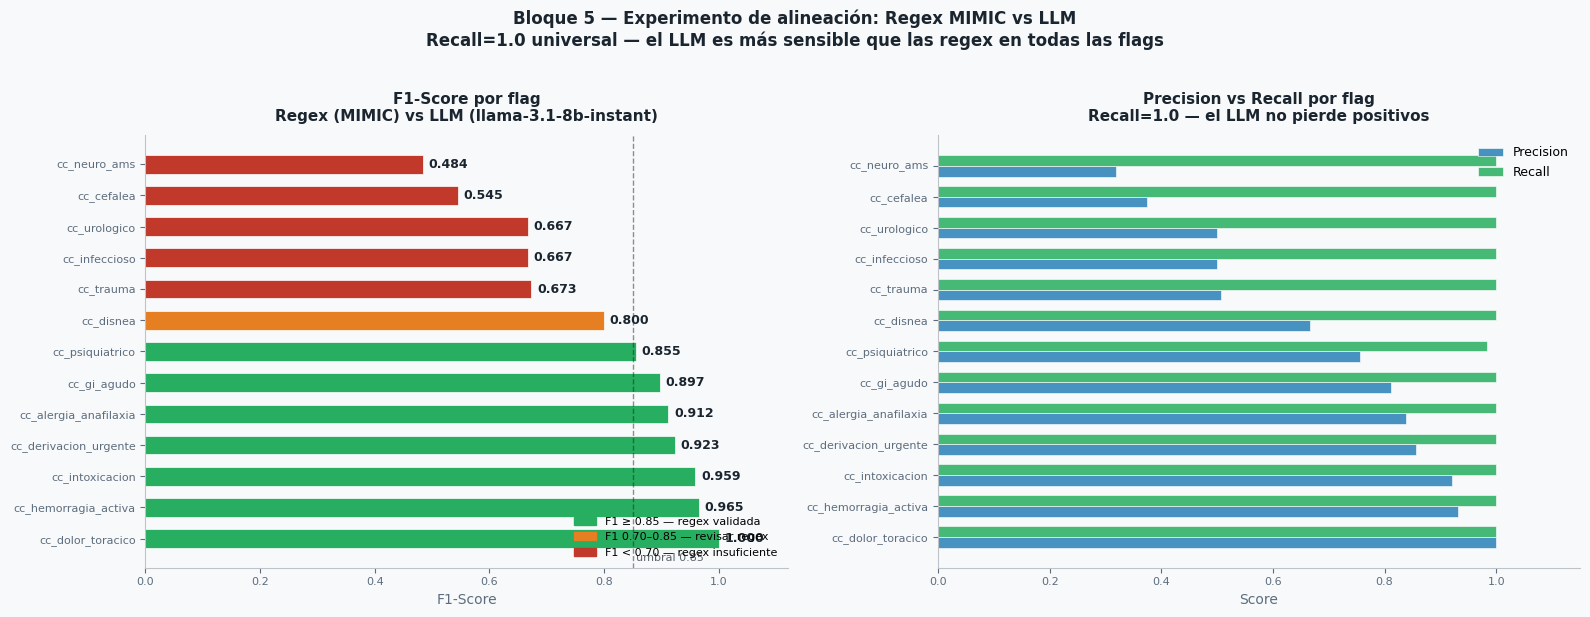

In [ ]:
# BLOQUE 5 — Paso 5: métricas de alineación regex vs LLM
from sklearn.metrics import f1_score, recall_score, precision_score, cohen_kappa_score
import matplotlib.pyplot as plt
import numpy as np

FLAGS = [
    "cc_dolor_toracico", "cc_disnea", "cc_gi_agudo", "cc_neuro_ams",
    "cc_cefalea", "cc_trauma", "cc_psiquiatrico", "cc_intoxicacion",
    "cc_infeccioso", "cc_urologico", "cc_hemorragia_activa",
    "cc_alergia_anafilaxia", "cc_derivacion_urgente"
]

# filtrar 3 errores restantes
mask    = (muestra_alineacion[[f"{f}_llm" for f in FLAGS]] != -1).all(axis=1)
df_eval = muestra_alineacion[mask].copy()
print(f"Filas válidas: {mask.sum()} / {len(muestra_alineacion)}\n")

# métricas
resultados = []
for flag in FLAGS:
    y_true = df_eval[flag].values
    y_pred = df_eval[f"{flag}_llm"].values
    f1    = f1_score(y_true, y_pred, zero_division=0)
    prec  = precision_score(y_true, y_pred, zero_division=0)
    rec   = recall_score(y_true, y_pred, zero_division=0)
    kappa = cohen_kappa_score(y_true, y_pred) if len(np.unique(y_true)) > 1 else float("nan")
    resultados.append({
        "flag":        flag,
        "F1":          round(f1,    3),
        "Precision":   round(prec,  3),
        "Recall":      round(rec,   3),
        "Kappa":       round(kappa, 3) if not np.isnan(kappa) else "NaN",
        "n_pos_regex": int(y_true.sum()),
        "n_pos_llm":   int(y_pred.sum()),
    })

df_res = pd.DataFrame(resultados).sort_values("F1", ascending=False)
print(df_res.to_string(index=False))

# gráfico
flags_sorted = df_res["flag"].tolist()
f1_vals      = df_res["F1"].tolist()
prec_vals    = df_res["Precision"].tolist()
rec_vals     = df_res["Recall"].tolist()

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor("#F8F9FA")

# panel izquierdo: F1
ax1 = axes[0]
ax1.set_facecolor("#F8F9FA")

colores_barras = ["#27AE60" if f >= 0.85 else "#E67E22" if f >= 0.70 else "#C0392B"
                  for f in f1_vals]
bars = ax1.barh(flags_sorted, f1_vals, color=colores_barras,
                edgecolor="white", linewidth=0.5, height=0.6)
for bar, val in zip(bars, f1_vals):
    ax1.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height() / 2,
             f"{val:.3f}", va="center", ha="left",
             fontsize=9, fontweight="bold", color="#1A252F")

ax1.axvline(x=0.85, color="#1A252F", linestyle="--", linewidth=1, alpha=0.5)
ax1.text(0.855, -0.7, "umbral 0.85", fontsize=8, color="#1A252F", alpha=0.7)
ax1.set_xlabel("F1-Score", fontsize=10, color="#5D6D7E")
ax1.set_title("F1-Score por flag\nRegex (MIMIC) vs LLM (llama-3.1-8b-instant)",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax1.set_xlim(0, 1.12)
ax1.spines[["top", "right"]].set_visible(False)
ax1.spines[["left", "bottom"]].set_color("#BDC3C7")
ax1.tick_params(colors="#5D6D7E", labelsize=8)

# leyenda manual
from matplotlib.patches import Patch
leyenda = [
    Patch(color="#27AE60", label="F1 ≥ 0.85 — regex validada"),
    Patch(color="#E67E22", label="F1 0.70–0.85 — revisar regex"),
    Patch(color="#C0392B", label="F1 < 0.70 — regex insuficiente"),
]
ax1.legend(handles=leyenda, frameon=False, fontsize=8, loc="lower right")

# panel derecho: Precision vs Recall
ax2 = axes[1]
ax2.set_facecolor("#F8F9FA")

x     = np.arange(len(flags_sorted))
width = 0.35

ax2.barh(x - width/2, prec_vals, width, label="Precision",
         color="#2980B9", edgecolor="white", linewidth=0.5, alpha=0.85)
ax2.barh(x + width/2, rec_vals,  width, label="Recall",
         color="#27AE60", edgecolor="white", linewidth=0.5, alpha=0.85)

ax2.set_yticks(x)
ax2.set_yticklabels(flags_sorted, fontsize=8)
ax2.set_xlabel("Score", fontsize=10, color="#5D6D7E")
ax2.set_title("Precision vs Recall por flag\nRecall=1.0 — el LLM no pierde positivos",
              fontsize=11, fontweight="bold", color="#1A252F", pad=10)
ax2.set_xlim(0, 1.15)
ax2.legend(frameon=False, fontsize=9)
ax2.spines[["top", "right"]].set_visible(False)
ax2.spines[["left", "bottom"]].set_color("#BDC3C7")
ax2.tick_params(colors="#5D6D7E", labelsize=8)

fig.suptitle(
    "Bloque 5 — Experimento de alineación: Regex MIMIC vs LLM\n"
    "Recall=1.0 universal — el LLM es más sensible que las regex en todas las flags",
    fontsize=12, fontweight="bold", color="#1A252F", y=1.02
)
plt.tight_layout()
plt.show()

In [313]:
# BLOQUE 5 — Paso 3: flags de chiefcomplaint (RegEx Definitivas v3)
cc = df["chiefcomplaint"].str.lower().str.strip()

# 1. cc_dolor_toracico
df["cc_dolor_toracico"] = cc.str.contains(
    r"\bchest\s*pain\b|\bcp\b|\bchest\s*tightness\b|\bchest\s*pressure\b"
    r"|\bchest\s*discomfort\b|\bangina\b",
    case=False, regex=True, na=False
).astype("int8")

# 2. cc_disnea
df["cc_disnea"] = cc.str.contains(
    r"\bdyspnea\b|\bsob\b|\bshortness\s*of\s*breath\b|\bbreathing\b"
    r"|\brespiratory\s*distress\b|\bbreathless\b|\bdyspnea\s*on\s*exertion\b"
    r"|\borthopnea\b|\bhypoxia\b|\binhalation\b",
    case=False, regex=True, na=False
).astype("int8")

# 3. cc_gi_agudo
df["cc_gi_agudo"] = cc.str.contains(
    r"\babd\s*pain\b|\babdominal\s*pain\b|\bepigastric\b|\brlq\b|\bllq\b"
    r"|\bruq\b|\bn/v\b|\bn/v/d\b|\bnausea\b|\bvomiting\b|\bdiarrhea\b"
    r"|\bgastric\b|\bbowel\b",
    case=False, regex=True, na=False
).astype("int8")

# 4. cc_neuro_ams
# Ampliado con términos validados por el experimento de alineación
# Excluidos: \bspeech\b, \bvisual\b, \bneuro\b, \barrest\b — demasiado amplios
df["cc_neuro_ams"] = cc.str.contains(
    r"\baltered\s*mental\s*status\b|\bams\b|\bweakness\b|\bseizur\w*\b"
    r"|\b(?:pre)?syncope\b|\bdizzi\w*\b|\bconfusion\b|\bunresponsive\b"
    r"|\bloss\s*of\s*consciousness\b|\bnumbness\b|\bparalysis\b"
    r"|\bstroke\b|\bcva\b|\btia\b|\bslurred\s*speech\b|\bslurred\b"
    r"|\bunable\s*to\s*ambulate\b|\bunsteady\s*gait\b|\bunsteady\b"
    r"|\btremor\b|\bspell\w*\b|\bvisual\s*changes\b",
    case=False, regex=True, na=False
).astype("int8")

# 5. cc_cefalea — sin cambios (regex estricta correcta)
df["cc_cefalea"] = cc.str.contains(
    r"\bheadache\b|\bhead\s*pain\b|\bmigraine\b",
    case=False, regex=True, na=False
).astype("int8")

# 6. cc_trauma — sin cambios (regex estricta correcta)
# Excluidos deliberadamente: suture, tetanus, splinter — no son trauma agudo
df["cc_trauma"] = cc.str.contains(
    r"\bs/p\s*fall\b|\bmvc\b|\bfall\b|\btrauma\w*\b|\binjury\b|\baccident\b"
    r"|\bped\s*struck\b|\bhead\s*injury\b|\blaceration\b|\bwound\b"
    r"|\bfractur\w*\b|\bstab\b|\bassault\b|\bgsw\b"
    r"|\bmotorcycle\b|\bbike\b|\bcrash\b",
    case=False, regex=True, na=False
).astype("int8")

# 7. cc_psiquiatrico
# Ampliado: \bhi\b, \bah\b, voices, delusions, insomnia
df["cc_psiquiatrico"] = cc.str.contains(
    r"\bsi\b|\bhi\b|\bah\b|\bsuicid\w*\b|\banxiet\w*\b|\banxious\b|\bpsych\w*\b"
    r"|\bhallucinat\w*\b|\bvoices?\b|\bagg?itat\w*\b|\bdepress\w*\b"
    r"|\bmania\b|\bmanic\b|\bparanoia\b|\bdelusion\w*\b|\binsomnia\b",
    case=False, regex=True, na=False
).astype("int8")

# 8. cc_intoxicacion
# Ampliado: detox
df["cc_intoxicacion"] = cc.str.contains(
    r"\betoh\b|\bintoxication\b|\boverdose\b|\bingestion\b"
    r"|\bsubstance\b|\bdrug\s*use\b|\balcohol\b|\bdetox\b",
    case=False, regex=True, na=False
).astype("int8")

# 9. cc_infeccioso
# Ampliado: abscess
df["cc_infeccioso"] = cc.str.contains(
    r"\bfever\b|\bili\b|\binfection\b|\bsepsis\b|\bcellulitis\b"
    r"|\bpneumonia\b|\bmeningitis\b|\binfluenza\b|\bcovid\b|\babscess\b",
    case=False, regex=True, na=False
).astype("int8")

# 10. cc_urologico
# Ampliado: \bgu\b, testicular, pelvic pain, groin pain
df["cc_urologico"] = cc.str.contains(
    r"\bdysuria\b|\bhematuria\b|\burinary\s*retention\b|\bflank\s*pain\b"
    r"|\buti\b|\bkidney\b|\brenal\b|\bfoley\b|\burinary\b"
    r"|\bgu\b|\btesticular\b|\bpelvic\s*pain\b|\bgroin\s*pain\b",
    case=False, regex=True, na=False
).astype("int8")

# 11. cc_hemorragia_activa
# Ampliado: melena
df["cc_hemorragia_activa"] = cc.str.contains(
    r"\bbrbpr\b|\brectal\s*bleeding\b|\bgib\b|\bvaginal\s*bleeding\b"
    r"|\bepistaxis\b|\bhemoptysis\b|\bbleeding\b|\bhemorrhag\w*\b|\bmelena\b",
    case=False, regex=True, na=False
).astype("int8")

# 12. cc_alergia_anafilaxia — sin cambios
df["cc_alergia_anafilaxia"] = cc.str.contains(
    r"\ballergic\s*reaction\b|\banaphylaxis\b|\ballergy\b|\bangioedema\b"
    r"|\bhives\b|\burticaria\b",
    case=False, regex=True, na=False
).astype("int8")

# 13. cc_derivacion_urgente
df["cc_derivacion_urgente"] = cc.str.contains(
    r"\babnormal\s*labs\b|\babnormal\s*ct\b|\babnormal\s*ekg\b"
    r"|\btransfer\b|\breferral\b|\bhyperglycemia\b|\bhypertension\b"
    r"|\bhyponatremia\b|\bhyperkalemia\b|\beta\b",
    case=False, regex=True, na=False
).astype("int8")

# H-stats de todas las flags
FLAGS_CC = [
    "cc_dolor_toracico", "cc_disnea", "cc_gi_agudo", "cc_neuro_ams",
    "cc_cefalea", "cc_trauma", "cc_psiquiatrico", "cc_intoxicacion",
    "cc_infeccioso", "cc_urologico", "cc_hemorragia_activa",
    "cc_alergia_anafilaxia", "cc_derivacion_urgente"
]

print("── H-stats finales (RegEx v3) ───────────────────────────────────────────")
H_cc: dict[str, float] = {}
pcts_cc: dict[str, list] = {}

for col in FLAGS_CC:
    stat, pval = kruskal(*[
        df.loc[df["acuity"] == k, col].values
        for k in ACUITY_LEVELS
    ])
    prev = df[col].mean() * 100
    n    = int(df[col].sum())
    H_cc[col]   = float(stat)
    pcts_cc[col] = [float(df.loc[df["acuity"] == k, col].mean() * 100) for k in ACUITY_LEVELS]
    update_metrics_json(col, H=round(float(stat), 4), tipo="binaria")
    print(f"{col:<25}  H = {stat:>7,.0f}  |  p = {pval:.2e}  |  prev = {prev:.2f}%  |  n = {n:,}")

── H-stats finales (RegEx v3) ───────────────────────────────────────────
cc_dolor_toracico          H =  12,707  |  p = 0.00e+00  |  prev = 7.56%  |  n = 31,614
cc_disnea                  H =  13,008  |  p = 0.00e+00  |  prev = 6.13%  |  n = 25,646
cc_gi_agudo                H =  18,161  |  p = 0.00e+00  |  prev = 16.63%  |  n = 69,541
cc_neuro_ams               H =  15,745  |  p = 0.00e+00  |  prev = 12.31%  |  n = 51,460
cc_cefalea                 H =     890  |  p = 1.95e-191  |  prev = 3.38%  |  n = 14,113
cc_trauma                  H =   5,923  |  p = 0.00e+00  |  prev = 13.33%  |  n = 55,730
cc_psiquiatrico            H =  13,677  |  p = 0.00e+00  |  prev = 4.23%  |  n = 17,667
cc_intoxicacion            H =     835  |  p = 2.18e-179  |  prev = 3.61%  |  n = 15,107
cc_infeccioso              H =   1,293  |  p = 9.37e-279  |  prev = 5.38%  |  n = 22,502
cc_urologico               H =   3,905  |  p = 0.00e+00  |  prev = 4.20%  |  n = 17,551
cc_hemorragia_activa       H =   1,683  

PROMPT OPTIMIZADO
Eres un asistente experto en triaje de urgencias hospitalarias.
Tu tarea es leer el motivo de consulta escrito por la enfermera y extraer los
síndromes clínicos presentes.

Devuelve ÚNICAMENTE un objeto JSON estricto con exactamente estas 13 claves y
valores 0 o 1. Sin texto adicional, sin markdown, sin explicaciones.

Reglas:
- Un paciente PUEDE tener múltiples claves en 1 simultáneamente.
- Si un síndrome NO se menciona o se niega explícitamente, su valor es 0.
- Limítate a la información explícita. No deduzcas diagnósticos si no hay evidencia directa.

{
  "cc_dolor_toracico": "1 si refiere dolor, presión, opresión, quemazón o malestar en el pecho, zona precordial o esternal, incluyendo irradiación a brazo izquierdo, mandíbula o espalda. También si menciona angina.",
  "cc_disnea": "1 si refiere dificultad para respirar, falta de aire, sensación de ahogo, ortopnea, hipoxia, inhalación de humo, disnea de esfuerzo o en reposo.",
  "cc_gi_agudo": "1 si refiere dolor abdominal de cualquier localización (epigástrico, fosa iliaca, hipocondrio, difuso), náuseas, vómitos, diarrea, o síntoma digestivo agudo.",
  "cc_neuro_ams": "1 si presenta alteración del nivel de consciencia, confusión, síncope, debilidad motora, dificultad para hablar (slurred speech), marcha inestable, temblor, convulsión o sospecha de ictus. EXCLUYE ansiedad o agitación psiquiátrica aislada.",
  "cc_cefalea": "1 si refiere dolor de cabeza o migraña como motivo principal. EXCLUYE explícitamente dolor de ojo, dolor de oído, dolor de mandíbula o traumatismo craneal.",
  "cc_trauma": "1 si existe mecanismo lesional explícito: caída, accidente, atropello, herida por arma blanca o de fuego, laceración activa o fractura. EXCLUYE dolor de extremidades aislado sin mecanismo descrito, extracción de suturas, retirada de astillas y procedimientos menores.",
  "cc_psiquiatrico": "1 si el motivo es de naturaleza psiquiátrica: ideación suicida, ideación homicida, agitación psicomotriz, alucinaciones, crisis de ansiedad, brote psicótico, depresión o insomnio severo.",
  "cc_intoxicacion": "1 si llega por intoxicación etílica aguda, sobredosis de fármacos o drogas, ingesta de tóxicos o necesidad de desintoxicación.",
  "cc_infeccioso": "1 si presenta fiebre, síndrome gripal, infección activa, absceso, picadura infectada o sospecha de sepsis.",
  "cc_urologico": "1 si refiere dolor en flanco o fosa renal, dolor pélvico, dolor genitourinario o testicular, escozor al orinar, retención urinaria o sangre en orina. EXCLUYE dolores articulares de extremidades (rodilla, tobillo, cadera).",
  "cc_hemorragia_activa": "1 si presenta sangrado activo visible: rectal, melena, hemorragia digestiva, vaginal, epistaxis, hemoptisis o cualquier hemorragia externa activa.",
  "cc_alergia_anafilaxia": "1 si llega por reacción alérgica de cualquier grado, urticaria, angioedema o sospecha de anafilaxia por fármacos, alimentos o picaduras.",
  "cc_derivacion_urgente": "1 si es derivado por anomalía objetiva ya detectada: analítica alterada, prueba de imagen patológica, ECG anormal, alteración electrolítica severa o aviso previo de llegada de código urgente (ETA)."
}

Ejemplo de output esperado para 'chest pain and shortness of breath':
{"cc_dolor_toracico":1,"cc_disnea":1,"cc_gi_agudo":0,"cc_neuro_ams":0,"cc_cefalea":0,"cc_trauma":0,"cc_psiquiatrico":0,"cc_intoxicacion":0,"cc_infeccioso":0,"cc_urologico":0,"cc_hemorragia_activa":0,"cc_alergia_anafilaxia":0,"cc_derivacion_urgente":0}

In [314]:
# Resumen dinámico Bloque 5 — Chief Complaint
metricas = leer_metricas()

FLAGS_CC_ORDEN = sorted(
    [f for f in metricas if f.startswith('cc_')],
    key=lambda f: -((metricas.get(f) or {}).get('H') or 0)
)

_filas_cc = []
for feat in FLAGS_CC_ORDEN:
    m = metricas.get(feat, {})
    H_val  = m.get('H')
    prev_v = df[feat].mean() * 100 if feat in df.columns else float('nan')
    h_str  = f'{H_val:,.0f}' if H_val else '—'
    _filas_cc.append(f'| `{feat}` | {h_str} | {prev_v:.2f}% |')

_n_total_cc = df['chiefcomplaint'].notna().sum()
_n_uniq_cc  = df['chiefcomplaint'].nunique()

print('## Bloque 5 — Chief Complaint: extracción de síndromes clínicos')
print(f'Texto libre: {_n_total_cc:,} registros, {_n_uniq_cc:,} valores únicos')
print(f'{len(_filas_cc)} flags definidas.')
print('| Feature | H-stat | Prevalencia |')
print('|---|---|---|')
for r in _filas_cc:
    print(r)


## Bloque 5 — Chief Complaint: extracción de síndromes clínicos
Texto libre: 418,083 registros, 59,471 valores únicos
13 flags definidas.
| Feature | H-stat | Prevalencia |
|---|---|---|
| `cc_gi_agudo` | 18,161 | 16.63% |
| `cc_neuro_ams` | 15,745 | 12.31% |
| `cc_derivacion_urgente` | 14,482 | 8.49% |
| `cc_psiquiatrico` | 13,677 | 4.23% |
| `cc_disnea` | 13,008 | 6.13% |
| `cc_dolor_toracico` | 12,707 | 7.56% |
| `cc_trauma` | 5,923 | 13.33% |
| `cc_urologico` | 3,905 | 4.20% |
| `cc_hemorragia_activa` | 1,683 | 2.65% |
| `cc_alergia_anafilaxia` | 1,496 | 0.68% |
| `cc_infeccioso` | 1,293 | 5.38% |
| `cc_cefalea` | 890 | 3.38% |
| `cc_intoxicacion` | 835 | 3.61% |


## Bloque 6 — Historial de estancias previas


## Bloque 6 — Historial ED y comorbilidades previas

### Objetivo
Extraer señales del historial clínico previo de cada paciente: frecuentación
al ED y comorbilidades crónicas documentadas en visitas anteriores.

### Regla fundamental: lookback estrictamente retrospectivo
Solo se usan visitas donde `outtime_previa < intime_actual`.
Nunca diagnósticos de la visita actual. Nunca `intime < intime_actual`
(riesgo de solapamiento administrativo).

### Paso 1 — Auditoría
- Distribución de visitas previas por paciente
- Rango temporal del dataset (truncamiento izquierdo)
- Categorías CCS disponibles y frecuencia

### Paso 2 — Construcción del historial retrospectivo
- Ordenar por `subject_id` + `intime`
- Usar `groupby` + `cumcount` para conteos acumulados
- Usar `groupby` + `shift` para recencia
- Usar `groupby` + `rolling` para ventanas temporales

### Paso 3 — Features de frecuentación
- `n_visitas_previas` — total histórico
- `visitas_ultimo_mes` — ventana 30 días
- `visitas_ultimo_año` — ventana 365 días
- `dias_desde_ultima_visita` — NaN si primera visita
- `primera_visita` — flag booleana
- `frecuentador` — ≥3 visitas en 90 días

### Paso 4 — Macro-flags de comorbilidad CCS
6-8 categorías de alto impacto definidas desde los datos:
`hx_cardiaco`, `hx_respiratorio`, `hx_psiquiatrico`,
`hx_renal`, `hx_oncologico`, `hx_abuso_sustancias`

### Paso 5 — H-stat y decisión por feature

In [315]:
# BLOQUE 6 — Paso 1: auditoría del historial ED
# Objetivo: entender la distribución de visitas por paciente y el rango
# temporal del dataset antes de construir ninguna feature

import pandas as pd
import numpy as np

# distribución de visitas por paciente
visitas_por_paciente = df.groupby("subject_id")["stay_id"].count()

print("── Distribución de visitas por paciente ─────────────────────────────────")
print(visitas_por_paciente.describe().round(2).to_string())
print(f"\nPacientes con 1 sola visita:      {(visitas_por_paciente == 1).sum():,} ({(visitas_por_paciente == 1).mean()*100:.1f}%)")
print(f"Pacientes con ≥3 visitas:         {(visitas_por_paciente >= 3).sum():,} ({(visitas_por_paciente >= 3).mean()*100:.1f}%)")
print(f"Pacientes con ≥10 visitas:        {(visitas_por_paciente >= 10).sum():,} ({(visitas_por_paciente >= 10).mean()*100:.1f}%)")
print(f"Pacientes con ≥50 visitas:        {(visitas_por_paciente >= 50).sum():,} ({(visitas_por_paciente >= 50).mean()*100:.1f}%)")
print(f"Máximo visitas un paciente:       {visitas_por_paciente.max():,}")

# rango temporal del dataset
print("\n── Rango temporal ───────────────────────────────────────────────────────")
print(f"Primera visita: {df['intime'].min()}")
print(f"Última visita:  {df['intime'].max()}")
print(f"Rango total:    {(df['intime'].max() - df['intime'].min()).days:,} días ({(df['intime'].max() - df['intime'].min()).days / 365.25:.1f} años)")

# categorías CCS disponibles
print("\n── Categorías CCS disponibles ───────────────────────────────────────────")
print(f"Registros con ccs_category:    {df['ccs_category'].notna().sum():,} ({df['ccs_category'].notna().mean()*100:.1f}%)")
print(f"Registros sin ccs_category:    {df['ccs_category'].isna().sum():,} ({df['ccs_category'].isna().mean()*100:.1f}%)")
print(f"Categorías únicas:             {df['ccs_category'].nunique():,}")
print("\nTop 30 categorías CCS más frecuentes:")
print(df["ccs_category"].value_counts().head(30).to_string())

── Distribución de visitas por paciente ─────────────────────────────────
count    201252.00
mean          2.08
std           3.44
min           1.00
25%           1.00
50%           1.00
75%           2.00
max         321.00

Pacientes con 1 sola visita:      132,260 (65.7%)
Pacientes con ≥3 visitas:         36,825 (18.3%)
Pacientes con ≥10 visitas:        4,476 (2.2%)
Pacientes con ≥50 visitas:        118 (0.1%)
Máximo visitas un paciente:       321

── Rango temporal ───────────────────────────────────────────────────────
Primera visita: 2110-01-11 01:45:00
Última visita:  2212-04-05 23:23:00
Rango total:    37,339 días (102.2 años)

── Categorías CCS disponibles ───────────────────────────────────────────
Registros con ccs_category:    417,128 (99.8%)
Registros sin ccs_category:    972 (0.2%)
Categorías únicas:             245

Top 30 categorías CCS más frecuentes:
ccs_category
251    31984
102    24088
205    14740
133    11127
259    11076
84     10583
211    10284
660    10090
1

In [317]:
# BLOQUE 6 — Paso 1c: cargar mapeo CCS
from pathlib import Path
import pandas as pd
from triaje_ia.config import DATA_INTERIM

label_map_ccs = pd.read_parquet(DATA_INTERIM / "label_map_ccs.parquet")

print(f"Shape: {label_map_ccs.shape}")
print(f"\nColumnas: {label_map_ccs.columns.tolist()}")
print(f"\nPrimeras 20 filas:")
print(label_map_ccs.head(20).to_string())
print(f"\nEjemplos de los códigos más frecuentes en df (251, 102, 205, 133):")
print(label_map_ccs[label_map_ccs.iloc[:, 0].isin([251, 102, 205, 133])].to_string())

Shape: (392172, 3)

Columnas: ['stay_id', 'ccs_id', 'ccs_nombre']

Primeras 20 filas:
     stay_id  ccs_id                                        ccs_nombre
0   32952584     117                         Other circulatory disease
1   33258284     151                              Other liver diseases
2   35968195     151                              Other liver diseases
3   38112554     151                              Other liver diseases
4   39399961     259                      Residual codes; unclassified
5   32522732     200                              Other skin disorders
6   35420907     228                          Skull and face fractures
7   30017875     102                            Nonspecific chest pain
8   32845079     250                               Nausea and vomiting
9   35197384     151                              Other liver diseases
10  37059738     211                   Other connective tissue disease
11  37290428     657                                    Mood d

In [318]:
# análisis del mapeo CCS

# top categorías en label_map_ccs
print("── Top 30 categorías CCS en label_map_ccs ───────────────────────────────")
print(label_map_ccs.groupby(["ccs_id", "ccs_nombre"])
      .size().reset_index(name="n")
      .sort_values("n", ascending=False)
      .head(30).to_string(index=False))

# cuántos diagnósticos CCS por visita
diag_por_visita = label_map_ccs.groupby("stay_id")["ccs_id"].count()
print(f"\n── Diagnósticos CCS por visita ──────────────────────────────────────────")
print(diag_por_visita.describe().round(2).to_string())
print(f"\nVisitas con ≥1 diagnóstico CCS:  {(diag_por_visita >= 1).sum():,}")
print(f"Visitas con ≥3 diagnósticos CCS: {(diag_por_visita >= 3).sum():,}")
print(f"Visitas con ≥5 diagnósticos CCS: {(diag_por_visita >= 5).sum():,}")

# cuántas visitas del df principal tienen historial en label_map_ccs
visitas_con_historial = df["stay_id"].isin(label_map_ccs["stay_id"])
print(f"\n── Cobertura en df principal ─────────────────────────────────────────────")
print(f"Visitas con diagnóstico CCS: {visitas_con_historial.sum():,} ({visitas_con_historial.mean()*100:.1f}%)")

── Top 30 categorías CCS en label_map_ccs ───────────────────────────────
 ccs_id                                                                     ccs_nombre     n
    251                                                                 Abdominal pain 32056
    102                                                         Nonspecific chest pain 24199
    205                Spondylosis; intervertebral disc disorders; other back problems 14809
    259                                                   Residual codes; unclassified 11445
    133                                                Other lower respiratory disease 11212
     84                                                   Headache; including migraine 10614
    211                                                Other connective tissue disease 10342
    660                                                      Alcohol-related disorders 10187
    244                           Other injuries and conditions due to external causes  9

In [319]:
# diagnóstico: qué códigos CCS existen realmente en el dataset

# todos los ccs_id únicos disponibles
print("── Rango de ccs_id disponibles en label_map_ccs ─────────────────────────")
print(f"Min: {label_map_ccs['ccs_id'].min()} | Max: {label_map_ccs['ccs_id'].max()}")
print(f"Únicos: {label_map_ccs['ccs_id'].nunique()}")

# buscar oncología por nombre
print("\n── Categorías con 'cancer', 'neoplas', 'malig', 'lymph', 'leukemia' ─────")
mask_onco = label_map_ccs["ccs_nombre"].str.contains(
    "cancer|neoplas|malig|lymph|leukemia|carcinoma|tumor|oncol",
    case=False, na=False
)
print(label_map_ccs[mask_onco]
      .groupby(["ccs_id", "ccs_nombre"]).size()
      .reset_index(name="n")
      .sort_values("n", ascending=False)
      .head(20).to_string(index=False))

# ver todos los ccs_id disponibles con frecuencia > 1000
print("\n── Todos los ccs_id con n > 1,000 ──────────────────────────────────────")
print(label_map_ccs.groupby(["ccs_id", "ccs_nombre"])
      .size().reset_index(name="n")
      .query("n > 1000")
      .sort_values("ccs_id")
      .to_string(index=False))

── Rango de ccs_id disponibles en label_map_ccs ─────────────────────────
Min: 2 | Max: 662
Únicos: 83

── Categorías con 'cancer', 'neoplas', 'malig', 'lymph', 'leukemia' ─────
Empty DataFrame
Columns: [ccs_id, ccs_nombre, n]
Index: []

── Todos los ccs_id con n > 1,000 ──────────────────────────────────────
 ccs_id                                                                                         ccs_nombre     n
      2                                                                       Septicemia (except in labor)  2306
      7                                                                                    Viral infection  2411
     50                                                               Diabetes mellitus with complications  4024
     55                                                                    Fluid and electrolyte disorders  3999
     59                                                                        Deficiency and other anemia  2344
     83    

In [320]:
# BLOQUE 6 — Paso 1f: macro-flags CCS definitivas
# Basadas en los 83 códigos reales disponibles en el dataset

CCS_MACROFLAGS = {
    "hx_cardiaco": [
         98,  # Essential hypertension
        100,  # Acute myocardial infarction
        101,  # Coronary atherosclerosis and other heart disease
        103,  # Pulmonary heart disease
        106,  # Cardiac dysrhythmias
        108,  # Congestive heart failure; nonhypertensive
        117,  # Other circulatory disease
        118,  # Phlebitis; thrombophlebitis and thromboembolism
    ],
    "hx_respiratorio": [
        122,  # Pneumonia
        123,  # Influenza
        126,  # Other upper respiratory infections
        127,  # COPD and bronchiectasis
        128,  # Asthma
        130,  # Pleurisy; pneumothorax; pulmonary collapse
        133,  # Other lower respiratory disease
        134,  # Other upper respiratory disease
    ],
    "hx_neuro": [
         83,  # Epilepsy; convulsions
         93,  # Conditions associated with dizziness or vertigo
         95,  # Other nervous system disorders
        109,  # Acute cerebrovascular disease
    ],
    "hx_psiquiatrico": [
        651,  # Anxiety disorders
        657,  # Mood disorders
        659,  # Schizophrenia and other psychotic disorders
        662,  # Suicide and intentional self-inflicted injury
    ],
    "hx_abuso_sustancias": [
        660,  # Alcohol-related disorders
        661,  # Substance-related disorders
    ],
    "hx_digestivo": [
        142,  # Appendicitis and other appendiceal conditions
        145,  # Intestinal obstruction without hernia
        146,  # Diverticulosis and diverticulitis
        147,  # Anal and rectal conditions
        149,  # Biliary tract disease
        151,  # Other liver diseases
        152,  # Pancreatic disorders (not diabetes)
        153,  # Gastrointestinal hemorrhage
        154,  # Noninfectious gastroenteritis
        155,  # Other gastrointestinal disorders
        250,  # Nausea and vomiting
        251,  # Abdominal pain
    ],
    "hx_metabolico_renal": [
         50,  # Diabetes mellitus with complications
         55,  # Fluid and electrolyte disorders
         59,  # Deficiency and other anemia
        157,  # Acute and unspecified renal failure
        160,  # Calculus of urinary tract
    ],
    "hx_infeccioso": [
          2,  # Septicemia (except in labor)
          7,  # Viral infection
        197,  # Skin and subcutaneous tissue infections
    ],
    "hx_trauma_muscular": [
        204,  # Other non-traumatic joint disorders
        205,  # Spondylosis; intervertebral disc disorders; other back problems
        228,  # Skull and face fractures
        229,  # Fracture of upper limb
        230,  # Fracture of lower limb
        231,  # Other fractures
        232,  # Sprains and strains
        233,  # Intracranial injury
        235,  # Open wounds of head; neck; and trunk
        236,  # Open wounds of extremities
        238,  # Complications of surgical procedures or medical care
        239,  # Superficial injury; contusion
        244,  # Other injuries and conditions due to external causes
    ],
}

# cobertura real
total_visitas = len(label_map_ccs)
print("── Cobertura macro-flags CCS definitivas ────────────────────────────────")
for flag, codigos in CCS_MACROFLAGS.items():
    mask    = label_map_ccs["ccs_id"].isin(codigos)
    n       = mask.sum()
    pct     = n / total_visitas * 100
    nombres = label_map_ccs[mask]["ccs_nombre"].unique()[:2]
    print(f"  {flag:<25} n={n:>6,} ({pct:.1f}%)  ej: {list(nombres)}")

── Cobertura macro-flags CCS definitivas ────────────────────────────────
  hx_cardiaco               n=20,571 (5.2%)  ej: ['Other circulatory disease', 'Congestive heart failure; nonhypertensive']
  hx_respiratorio           n=33,491 (8.5%)  ej: ['Other lower respiratory disease', 'Asthma']
  hx_neuro                  n=22,368 (5.7%)  ej: ['Conditions associated with dizziness or vertigo', 'Other nervous system disorders']
  hx_psiquiatrico           n=13,391 (3.4%)  ej: ['Mood disorders', 'Schizophrenia and other psychotic disorders']
  hx_abuso_sustancias       n=11,922 (3.0%)  ej: ['Alcohol-related disorders', 'Substance-related disorders']
  hx_digestivo              n=64,508 (16.4%)  ej: ['Other liver diseases', 'Nausea and vomiting']
  hx_metabolico_renal       n=15,381 (3.9%)  ej: ['Diabetes mellitus with complications', 'Calculus of urinary tract']
  hx_infeccioso             n=13,908 (3.5%)  ej: ['Viral infection', 'Skin and subcutaneous tissue infections']
  hx_trauma_muscul

In [322]:
# BLOQUE 6 — Paso 2a: cargar outtime desde edstays
import pandas as pd
from triaje_ia.config import DATA_RAW

edstays = pd.read_csv(
    DATA_RAW / "edstays.csv.gz",
    usecols=["subject_id", "stay_id", "intime", "outtime"],
    parse_dates=["intime", "outtime"]
)

print(f"Shape: {edstays.shape}")
print(f"\nColumnas: {edstays.columns.tolist()}")
print(f"\nNaN en outtime: {edstays['outtime'].isna().sum():,} ({edstays['outtime'].isna().mean()*100:.2f}%)")
print(f"\nPrimeras filas:")
print(edstays.head(5).to_string())

Shape: (425087, 4)

Columnas: ['subject_id', 'stay_id', 'intime', 'outtime']

NaN en outtime: 0 (0.00%)

Primeras filas:
   subject_id   stay_id              intime             outtime
0    10000032  33258284 2180-05-06 19:17:00 2180-05-06 23:30:00
1    10000032  38112554 2180-06-26 15:54:00 2180-06-26 21:31:00
2    10000032  35968195 2180-08-05 20:58:00 2180-08-06 01:44:00
3    10000032  32952584 2180-07-22 16:24:00 2180-07-23 05:54:00
4    10000032  39399961 2180-07-23 05:54:00 2180-07-23 14:00:00


In [323]:
# BLOQUE 6 — Paso 2b: features de frecuentación (completo)
import numpy as np
import time

t0 = time.time()

# ordenar por subject_id + intime
edstays_sorted = edstays.sort_values(["subject_id", "intime"]).copy().reset_index(drop=True)

# n_visitas_previas
edstays_sorted["n_visitas_previas"] = (
    edstays_sorted.groupby("subject_id").cumcount()
).astype("int16")

# primera_visita
edstays_sorted["primera_visita"] = (
    edstays_sorted["n_visitas_previas"] == 0
).astype("int8")

# outtime de la visita anterior
edstays_sorted["outtime_previa"] = (
    edstays_sorted.groupby("subject_id")["outtime"].shift(1)
)

# dias_desde_ultima_visita
edstays_sorted["dias_desde_ultima_visita"] = (
    (edstays_sorted["intime"] - edstays_sorted["outtime_previa"])
    .dt.total_seconds() / 86400
).round(1)

# fix solapamientos: dias negativos → NaN
edstays_sorted.loc[
    edstays_sorted["dias_desde_ultima_visita"] < 0,
    "dias_desde_ultima_visita"
] = np.nan

# ventanas temporales con rolling
# IMPORTANTE: set_index ANTES del rolling y reset_index DESPUÉS
edstays_sorted = edstays_sorted.set_index("intime").sort_index()

edstays_sorted["visitas_ultimo_mes"] = (
    edstays_sorted.groupby("subject_id")["stay_id"]
    .transform(lambda x: x.rolling("30D", closed="left").count())
    .fillna(0)
    .astype("int16")
)

edstays_sorted["visitas_ultimo_año"] = (
    edstays_sorted.groupby("subject_id")["stay_id"]
    .transform(lambda x: x.rolling("365D", closed="left").count())
    .fillna(0)
    .astype("int16")
)

# reset_index para recuperar intime como columna
edstays_sorted = edstays_sorted.reset_index()

# frecuentador
edstays_sorted["frecuentador"] = (
    edstays_sorted["visitas_ultimo_mes"] >= 3
).astype("int8")

print(f"Tiempo: {time.time() - t0:.1f}s\n")
print(f"Columnas: {edstays_sorted.columns.tolist()}\n")

cols_check = [
    "subject_id", "stay_id", "intime", "n_visitas_previas",
    "primera_visita", "dias_desde_ultima_visita",
    "visitas_ultimo_mes", "visitas_ultimo_año", "frecuentador"
]
print("── Primeras 15 filas ────────────────────────────────────────────────────")
print(edstays_sorted[cols_check].head(15).to_string())
print(f"\n── Estadísticas ─────────────────────────────────────────────────────────")
print(f"Frecuentadores:       {edstays_sorted['frecuentador'].sum():,} ({edstays_sorted['frecuentador'].mean()*100:.2f}%)")
print(f"Primera visita:       {edstays_sorted['primera_visita'].sum():,} ({edstays_sorted['primera_visita'].mean()*100:.2f}%)")
print(f"Días negativos→NaN:   {edstays_sorted['dias_desde_ultima_visita'].isna().sum() - edstays_sorted['primera_visita'].sum():,}")

Tiempo: 146.9s

Columnas: ['intime', 'subject_id', 'stay_id', 'outtime', 'n_visitas_previas', 'primera_visita', 'outtime_previa', 'dias_desde_ultima_visita', 'visitas_ultimo_mes', 'visitas_ultimo_año', 'frecuentador']

── Primeras 15 filas ────────────────────────────────────────────────────
    subject_id   stay_id              intime  n_visitas_previas  primera_visita  dias_desde_ultima_visita  visitas_ultimo_mes  visitas_ultimo_año  frecuentador
0     13238787  35341790 2110-01-11 01:45:00                  0               1                       NaN                   0                   0             0
1     15350437  39042378 2110-01-11 03:43:00                  0               1                       NaN                   0                   0             0
2     13370527  35220003 2110-01-11 10:08:00                  0               1                       NaN                   0                   0             0
3     14695442  34789981 2110-01-11 12:44:00                  0    

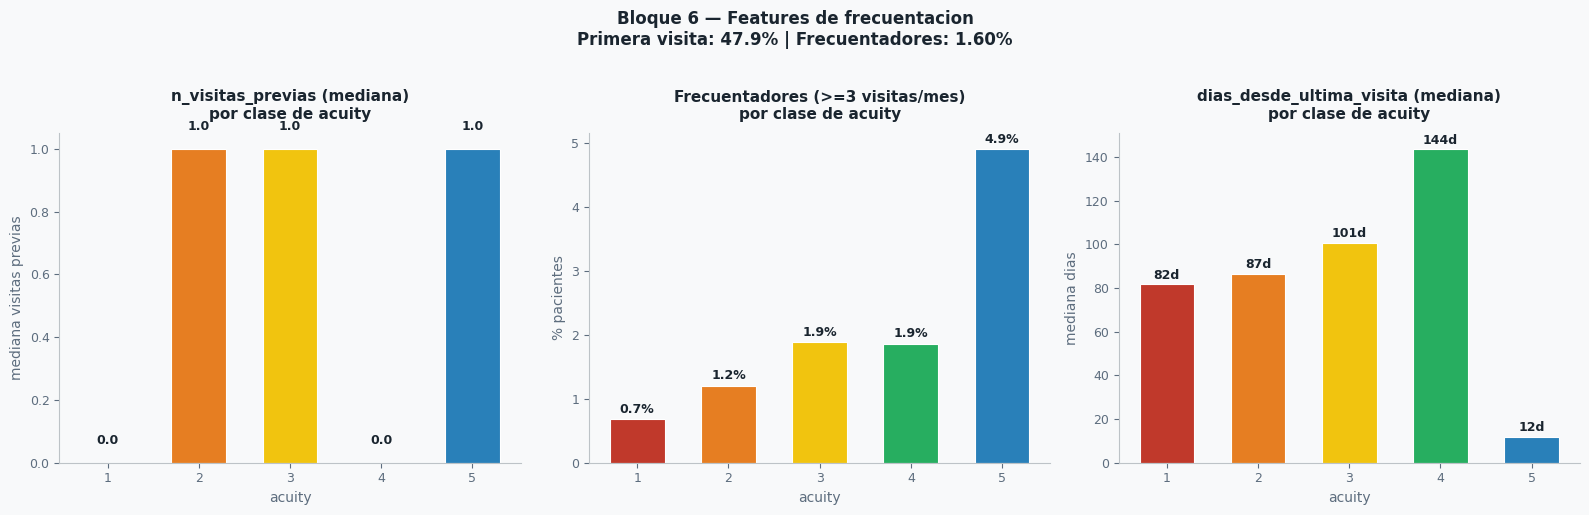

In [324]:
# GRÁFICO BLOQUE 6 — Paso 2b: features de frecuentación

# merge con df para tener acuity
df_frec = df[['stay_id', 'acuity']].merge(
    edstays_sorted[['stay_id', 'n_visitas_previas', 'dias_desde_ultima_visita',
                    'visitas_ultimo_mes', 'frecuentador', 'primera_visita']],
    on='stay_id', how='left'
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.patch.set_facecolor('#F8F9FA')

# Panel 1: mediana n_visitas_previas por acuity
ax1 = axes[0]
ax1.set_facecolor('#F8F9FA')
medianas_vis = df_frec.groupby('acuity')['n_visitas_previas'].median().reindex(ACUITY_LEVELS, fill_value=0).values
bars = ax1.bar(ACUITY_LEVELS, medianas_vis, color=PALETA_ACUITY,
               edgecolor='white', linewidth=0.8, width=0.6)
for bar, val in zip(bars, medianas_vis):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{val:.1f}', ha='center', va='bottom',
             fontsize=9, fontweight='bold', color='#1A252F')
ax1.set_title('n_visitas_previas (mediana)\npor clase de acuity',
              fontsize=11, fontweight='bold', color='#1A252F', pad=10)
ax1.set_xlabel('acuity', fontsize=10, color='#5D6D7E')
ax1.set_ylabel('mediana visitas previas', fontsize=10, color='#5D6D7E')
ax1.set_xticks(ACUITY_LEVELS)
ax1.spines[['top', 'right']].set_visible(False)
ax1.spines[['left', 'bottom']].set_color('#BDC3C7')
ax1.tick_params(colors='#5D6D7E', labelsize=9)

# Panel 2: % frecuentadores por acuity
ax2 = axes[1]
ax2.set_facecolor('#F8F9FA')
pcts_frec_vis = (df_frec.groupby('acuity')['frecuentador'].mean() * 100).reindex(ACUITY_LEVELS, fill_value=0).values
bars = ax2.bar(ACUITY_LEVELS, pcts_frec_vis, color=PALETA_ACUITY,
               edgecolor='white', linewidth=0.8, width=0.6)
for bar, val in zip(bars, pcts_frec_vis):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{val:.1f}%', ha='center', va='bottom',
             fontsize=9, fontweight='bold', color='#1A252F')
ax2.set_title('Frecuentadores (>=3 visitas/mes)\npor clase de acuity',
              fontsize=11, fontweight='bold', color='#1A252F', pad=10)
ax2.set_xlabel('acuity', fontsize=10, color='#5D6D7E')
ax2.set_ylabel('% pacientes', fontsize=10, color='#5D6D7E')
ax2.set_xticks(ACUITY_LEVELS)
ax2.spines[['top', 'right']].set_visible(False)
ax2.spines[['left', 'bottom']].set_color('#BDC3C7')
ax2.tick_params(colors='#5D6D7E', labelsize=9)

# Panel 3: mediana dias_desde_ultima_visita por acuity
ax3 = axes[2]
ax3.set_facecolor('#F8F9FA')
medianas_dias_vis = df_frec.groupby('acuity')['dias_desde_ultima_visita'].median().reindex(ACUITY_LEVELS, fill_value=0).values
bars = ax3.bar(ACUITY_LEVELS, medianas_dias_vis, color=PALETA_ACUITY,
               edgecolor='white', linewidth=0.8, width=0.6)
for bar, val in zip(bars, medianas_dias_vis):
    ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
             f'{val:.0f}d', ha='center', va='bottom',
             fontsize=9, fontweight='bold', color='#1A252F')
ax3.set_title('dias_desde_ultima_visita (mediana)\npor clase de acuity',
              fontsize=11, fontweight='bold', color='#1A252F', pad=10)
ax3.set_xlabel('acuity', fontsize=10, color='#5D6D7E')
ax3.set_ylabel('mediana dias', fontsize=10, color='#5D6D7E')
ax3.set_xticks(ACUITY_LEVELS)
ax3.spines[['top', 'right']].set_visible(False)
ax3.spines[['left', 'bottom']].set_color('#BDC3C7')
ax3.tick_params(colors='#5D6D7E', labelsize=9)

_pct_primera = df_frec['primera_visita'].mean() * 100
_pct_frecuentadores = df_frec['frecuentador'].mean() * 100

fig.suptitle(
    f'Bloque 6 — Features de frecuentacion\n'
    f'Primera visita: {_pct_primera:.1f}% | Frecuentadores: {_pct_frecuentadores:.2f}%',
    fontsize=12, fontweight='bold', color='#1A252F', y=1.02
)
plt.tight_layout()
plt.show()


In [325]:
display(Markdown(
    f'**n_visitas_previas**: medianas casi planas ({medianas_vis[0]:.0f}–{medianas_vis[4]:.0f}) en todos los niveles. '
    f'El **{_pct_primera:.1f}%** de primeras visitas aplana la mediana. '
    f'La señal está en la media y en los percentiles altos, no en la mediana.\n\n'
    f'**Frecuentadores**: patrón inesperado — acuity 5 concentra el mayor % de frecuentadores '
    f'({pcts_frec_vis[4]:.1f}%). Los hiperfrecuentadores crónicos vienen por motivos leves repetidamente. '
    f'Acuity 1 tiene el menor % ({pcts_frec_vis[0]:.1f}%) — las emergencias reales raramente se repiten en el mismo mes.\n\n'
    f'**dias_desde_ultima_visita**: gradiente claro — acuity 1-2 vuelven antes '
    f'({medianas_dias_vis[0]:.0f}–{medianas_dias_vis[1]:.0f} días), acuity 4-5 tardan más. '
    f'Señal clínica coherente: el que regresa rápido lo hace porque sigue mal.'
))


**n_visitas_previas**: medianas casi planas (0–1) en todos los niveles. El **47.9%** de primeras visitas aplana la mediana. La señal está en la media y en los percentiles altos, no en la mediana.

**Frecuentadores**: patrón inesperado — acuity 5 concentra el mayor % de frecuentadores (4.9%). Los hiperfrecuentadores crónicos vienen por motivos leves repetidamente. Acuity 1 tiene el menor % (0.7%) — las emergencias reales raramente se repiten en el mismo mes.

**dias_desde_ultima_visita**: gradiente claro — acuity 1-2 vuelven antes (82–87 días), acuity 4-5 tardan más. Señal clínica coherente: el que regresa rápido lo hace porque sigue mal.

In [326]:
# BLOQUE 6 — Paso 3: macro-flags CCS retrospectivas (VECTORIZACIÓN PURA)
import time
t0 = time.time()

from triaje_ia.data.features import CCS_MACROFLAGS  # definición canónica en features.py

# Partimos solo de las columnas base ordenadas
edstays_hist = edstays_sorted[["subject_id", "stay_id", "intime", "outtime"]].copy()

# Bucle vectorizado (sin applies ni lambdas)
for flag, codigos in CCS_MACROFLAGS.items():
    
    # 1. ¿Tiene esta visita el código? (Ultrarrápido con isin)
    stays_with_flag = label_map_ccs[label_map_ccs["ccs_id"].isin(codigos)]["stay_id"]
    edstays_hist[f"_{flag}_now"] = edstays_hist["stay_id"].isin(stays_with_flag).astype("int8")

    # 2. Shift vectorizado nativo
    shifted = edstays_hist.groupby("subject_id")[f"_{flag}_now"].shift(1).fillna(0)
    
    # 3. Cummax vectorizado nativo
    edstays_hist[flag] = shifted
    edstays_hist[flag] = edstays_hist.groupby("subject_id")[flag].cummax().astype("int8")

    # Limpiar la columna temporal
    edstays_hist.drop(columns=[f"_{flag}_now"], inplace=True)

print(f"Tiempo: {time.time() - t0:.2f}s\n")

print("── Prevalencia macro-flags CCS históricas (Retrospectivas) ─────────────")
for flag in CCS_MACROFLAGS:
    n   = edstays_hist[flag].sum()
    pct = edstays_hist[flag].mean() * 100
    print(f"  {flag:<25} n={n:>6,} ({pct:.2f}%)")

print(f"\n── Verificación primeras filas ──────────────────────────────────────────")
cols_hx = ["subject_id", "stay_id", "intime"] + list(CCS_MACROFLAGS.keys())
print(edstays_hist[cols_hx].head(10).to_string())

Tiempo: 1.11s

── Prevalencia macro-flags CCS históricas (Retrospectivas) ─────────────
  hx_cardiaco               n=32,786 (7.71%)
  hx_respiratorio           n=52,887 (12.44%)
  hx_neuro                  n=35,481 (8.35%)
  hx_psiquiatrico           n=17,753 (4.18%)
  hx_abuso_sustancias       n=15,160 (3.57%)
  hx_digestivo              n=79,465 (18.69%)
  hx_metabolico_renal       n=30,579 (7.19%)
  hx_infeccioso             n=24,869 (5.85%)
  hx_trauma_muscular        n=81,825 (19.25%)

── Verificación primeras filas ──────────────────────────────────────────
   subject_id   stay_id              intime  hx_cardiaco  hx_respiratorio  hx_neuro  hx_psiquiatrico  hx_abuso_sustancias  hx_digestivo  hx_metabolico_renal  hx_infeccioso  hx_trauma_muscular
0    13238787  35341790 2110-01-11 01:45:00            0                0         0                0                    0             0                    0              0                   0
1    15350437  39042378 2110-01-11 03:43:00  

In [327]:
# BLOQUE 6 — Paso 4: merge con df y H-stats

# merge edstays_hist + edstays_sorted → df principal
cols_frec = ["stay_id", "n_visitas_previas", "primera_visita",
             "dias_desde_ultima_visita", "visitas_ultimo_mes",
             "visitas_ultimo_año", "frecuentador"]

cols_hx = ["stay_id"] + list(CCS_MACROFLAGS.keys())

df = df.merge(edstays_sorted[cols_frec], on="stay_id", how="left") \
       .merge(edstays_hist[cols_hx],     on="stay_id", how="left")

# H-stats
features_b6 = [
    "n_visitas_previas", "visitas_ultimo_mes", "visitas_ultimo_año",
    "dias_desde_ultima_visita", "primera_visita", "frecuentador",
] + list(CCS_MACROFLAGS.keys())

print("── H-stats Bloque 6 ─────────────────────────────────────────────────────")
H_b6: dict[str, float] = {}
pcts_b6: dict[str, list] = {}

for col in features_b6:
    stat, pval = kruskal(*[
        df.loc[df['acuity'] == k, col].dropna().values
        for k in ACUITY_LEVELS
    ])
    H_b6[col] = float(stat)
    pcts_b6[col] = [
        float(df.loc[df['acuity'] == k, col].mean() * 100)
        if df[col].max() <= 1 else
        float(df.loc[df['acuity'] == k, col].mean())
        for k in ACUITY_LEVELS
    ]
    prev = df[col].mean() * 100 if df[col].max() <= 1 else df[col].mean()
    update_metrics_json(col, H=round(float(stat), 4), tipo='binaria' if df[col].max() <= 1 else 'continua')
    print(f'{col:<25}  H = {stat:>7,.0f}  |  p = {pval:.2e}  |  media = {prev:.2f}')

── H-stats Bloque 6 ─────────────────────────────────────────────────────
n_visitas_previas          H =   1,000  |  p = 3.99e-215  |  media = 3.42
visitas_ultimo_mes         H =     508  |  p = 1.58e-108  |  media = 0.24
visitas_ultimo_año         H =   1,035  |  p = 7.27e-223  |  media = 1.42
dias_desde_ultima_visita   H =     419  |  p = 2.35e-89  |  media = 272.21
primera_visita             H =     716  |  p = 1.01e-153  |  media = 47.86
frecuentador               H =     473  |  p = 4.04e-101  |  media = 1.60
hx_cardiaco                H =   2,562  |  p = 0.00e+00  |  media = 7.78
hx_respiratorio            H =     251  |  p = 4.67e-53  |  media = 12.57
hx_neuro                   H =     241  |  p = 6.39e-51  |  media = 8.42
hx_psiquiatrico            H =     918  |  p = 2.63e-197  |  media = 4.23
hx_abuso_sustancias        H =     398  |  p = 7.08e-85  |  media = 3.60
hx_digestivo               H =   1,612  |  p = 0.00e+00  |  media = 18.91
hx_metabolico_renal        H =   1,045 

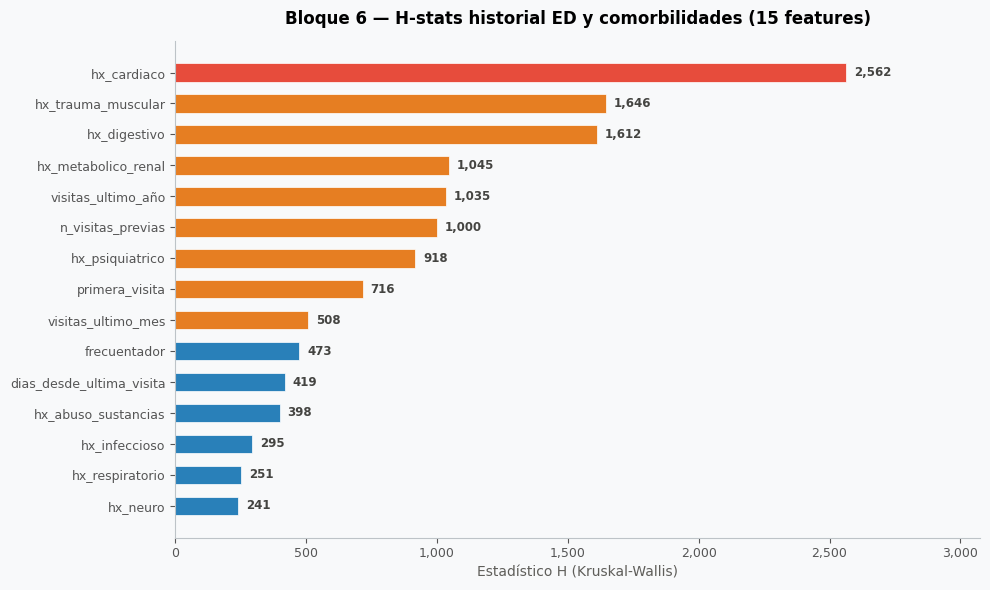

In [328]:
# GRÁFICO BLOQUE 6: H-stats comparativa

metricas = leer_metricas()

# Todos los features de Bloque 6 disponibles en metricas, ordenados por H
FEATS_B6 = [
    'hx_cardiaco', 'hx_digestivo', 'hx_trauma_muscular', 'hx_psiquiatrico',
    'hx_metabolico_renal', 'visitas_ultimo_año', 'n_visitas_previas',
    'hx_abuso_sustancias', 'primera_visita', 'frecuentador',
    'hx_infeccioso', 'visitas_ultimo_mes', 'dias_desde_ultima_visita',
    'hx_respiratorio', 'hx_neuro',
]
# Usar H de métricas (persistidas tras cell 163) o H_b6 en memoria
_feats_presentes = [f for f in FEATS_B6 if f in metricas or f in H_b6]
_hvals = [float((metricas.get(f) or {}).get('H') or H_b6.get(f, 0)) for f in _feats_presentes]

# Ordenar por H ascendente (barh)
_order = sorted(zip(_feats_presentes, _hvals), key=lambda x: x[1])
_feats_ord = [x[0] for x in _order]
_hvals_ord = [x[1] for x in _order]

_cols = ['#E74C3C' if h > 2000 else '#E67E22' if h > 500 else '#2980B9' for h in _hvals_ord]

fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#F8F9FA')

bars = ax.barh(_feats_ord, _hvals_ord, color=_cols,
               edgecolor='white', linewidth=0.5, height=0.6)
for bar, val in zip(bars, _hvals_ord):
    ax.text(bar.get_width() + 30, bar.get_y() + bar.get_height() / 2,
            f'{val:,.0f}', va='center', ha='left',
            fontsize=8.5, fontweight='bold', color='#444441')

ax.set_xlabel('Estadístico H (Kruskal-Wallis)', fontsize=10, color='#5F5E5A')
ax.set_title(
    f'Bloque 6 — H-stats historial ED y comorbilidades ({len(_feats_ord)} features)',
    fontsize=12, fontweight='bold', pad=12
)
ax.set_xlim(0, max(_hvals_ord) * 1.2 if _hvals_ord else 1)
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#BDC3C7')
ax.tick_params(colors='#555555', labelsize=9)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.show()


In [329]:
# Resumen dinámico Bloque 6 — Historial ED y comorbilidades
metricas = leer_metricas()

_pct_primera_v = df['primera_visita'].mean() * 100 if 'primera_visita' in df.columns else float('nan')
_pct_frecuent  = df['frecuentador'].mean() * 100 if 'frecuentador' in df.columns else float('nan')

FEATS_FREC = ['n_visitas_previas', 'visitas_ultimo_mes', 'visitas_ultimo_año',
              'dias_desde_ultima_visita', 'primera_visita', 'frecuentador']
FEATS_HX   = [f for f in metricas if f.startswith('hx_')]

def _h(feat):
    val = (metricas.get(feat) or {}).get('H')
    return f'{val:,.0f}' if val else '—'

_tab_frec = '\n'.join(f'| `{f}` | {_h(f)} |' for f in FEATS_FREC)
_tab_hx   = '\n'.join(f'| `{f}` | {_h(f)} |' for f in sorted(FEATS_HX, key=lambda f: -((metricas.get(f) or {}).get('H') or 0)))

print('## Bloque 6 — Conclusiones: historial ED y comorbilidades previas')
print(f'Primera visita: {_pct_primera_v:.1f}%  |  Frecuentadores: {_pct_frecuent:.2f}%')
print()
print('### Features de frecuentación')
print('| Feature | H-stat |')
print('|---|---|')
print(_tab_frec)
print()
print('### Macro-flags CCS (historial de comorbilidades)')
print('| Feature | H-stat |')
print('|---|---|')
print(_tab_hx)


## Bloque 6 — Conclusiones: historial ED y comorbilidades previas
Primera visita: 47.9%  |  Frecuentadores: 1.60%

### Features de frecuentación
| Feature | H-stat |
|---|---|
| `n_visitas_previas` | 1,000 |
| `visitas_ultimo_mes` | 508 |
| `visitas_ultimo_año` | 1,035 |
| `dias_desde_ultima_visita` | 419 |
| `primera_visita` | 716 |
| `frecuentador` | 473 |

### Macro-flags CCS (historial de comorbilidades)
| Feature | H-stat |
|---|---|
| `hx_cardiaco` | 2,562 |
| `hx_trauma_muscular` | 1,646 |
| `hx_digestivo` | 1,612 |
| `hx_metabolico_renal` | 1,045 |
| `hx_psiquiatrico` | 918 |
| `hx_abuso_sustancias` | 398 |
| `hx_infeccioso` | 295 |
| `hx_respiratorio` | 251 |
| `hx_neuro` | 241 |


## Bloque 7-8 — Inventario, correlaciones y export


In [330]:
# BLOQUE 7/8 — Paso 1: inventario de features calculadas
# Lista completa de todas las features disponibles en df agrupadas por bloque

inventario = {
    "BLOQUE 1 — Vitales crudos": [
        "pain", "o2sat", "resprate", "heartrate", "dbp", "sbp"
    ],
    "BLOQUE 1 — Missingness vitales": [
        "temperature_missing", "o2sat_missing", "pain_missing"
    ],
    "BLOQUE 1 — Banderas clínicas": [
        "o2sat_bajo_92", "taquipnea_grave", "taquicardia", "fiebre",
        "hipotension", "hipertension_severa"
    ],
    "BLOQUE 1 — Scores compuestos": [
        "qsofa", "qsofa_positivo", "news2", "news2_alto",
        "shock_index_alto", "shock_index_severo", "shock_oculto_anciano",
        "vitales_criticos", "n_vitales_anomalos", "sirs_positivo",
        "zona_verde", "pulse_pressure"
    ],
    "BLOQUE 2 — Demográfico": [
        "age", "anciano", "anciano_mayor", "identidad_desconocida"
    ],
    "BLOQUE 2 — Género": [
        "gender"
    ],
    "BLOQUE 2 — Transporte": [
        "llegada_autonoma", "llegada_ambulancia",
        "llegada_helicoptero", "llegada_desconocida"
    ],
    "BLOQUE 3 — Medicación individual": [
        "med_anticoagulante", "med_antiagregante", "med_insulina",
        "med_antidiabetico_oral", "med_corticoide_sistemico",
        "med_opiaceo", "med_benzodiacepina", "med_betabloqueante",
        "med_ace_ara2", "med_diuretico_asa", "med_diuretico_tiazida",
        "med_antipsicótico", "med_ssri_snri", "med_anticonvulsivante",
        "med_respiratorio_inhalado", "med_inmunosupresor",
        "med_digoxina", "med_antiaritmico"
    ],
    "BLOQUE 3 — Super-flags": [
        "alto_riesgo_sangrado", "alto_riesgo_delirium", "riesgo_depresion_resp"
    ],
    "BLOQUE 4 — Polifarmacia": [
        "n_medicamentos", "sin_medicacion", "polifarmacia", "hiperpolifarmacia"
    ],
    "BLOQUE 5 — Chief complaint": [
        "cc_dolor_toracico", "cc_disnea", "cc_gi_agudo", "cc_neuro_ams",
        "cc_cefalea", "cc_trauma", "cc_psiquiatrico", "cc_intoxicacion",
        "cc_infeccioso", "cc_urologico", "cc_hemorragia_activa",
        "cc_alergia_anafilaxia", "cc_derivacion_urgente"
    ],
    "BLOQUE 6 — Frecuentación": [
        "n_visitas_previas", "visitas_ultimo_mes", "visitas_ultimo_año",
        "dias_desde_ultima_visita", "primera_visita", "frecuentador"
    ],
    "BLOQUE 6 — Comorbilidades CCS": [
        "hx_cardiaco", "hx_respiratorio", "hx_neuro", "hx_psiquiatrico",
        "hx_abuso_sustancias", "hx_digestivo", "hx_metabolico_renal",
        "hx_infeccioso", "hx_trauma_muscular"
    ],
}

# verificar cuáles están realmente en df
print("── Inventario de features ───────────────────────────────────────────────")
total = 0
faltantes = []
for bloque, features in inventario.items():
    presentes = [f for f in features if f in df.columns]
    ausentes  = [f for f in features if f not in df.columns]
    total += len(presentes)
    if ausentes:
        faltantes.extend(ausentes)
    print(f"\n{bloque} ({len(presentes)}/{len(features)}):")
    for f in presentes:
        print(f"  OK {f}")
    for f in ausentes:
        print(f"  X {f}  ← FALTA")

print(f"\n── Total features disponibles: {total} ─────────────────────────────────")
print(f"── Features faltantes: {len(faltantes)} ────────────────────────────────")
if faltantes:
    print(faltantes)

── Inventario de features ───────────────────────────────────────────────

BLOQUE 1 — Vitales crudos (6/6):
  OK pain
  OK o2sat
  OK resprate
  OK heartrate
  OK dbp
  OK sbp

BLOQUE 1 — Missingness vitales (3/3):
  OK temperature_missing
  OK o2sat_missing
  OK pain_missing

BLOQUE 1 — Banderas clínicas (6/6):
  OK o2sat_bajo_92
  OK taquipnea_grave
  OK taquicardia
  OK fiebre
  OK hipotension
  OK hipertension_severa

BLOQUE 1 — Scores compuestos (12/12):
  OK qsofa
  OK qsofa_positivo
  OK news2
  OK news2_alto
  OK shock_index_alto
  OK shock_index_severo
  OK shock_oculto_anciano
  OK vitales_criticos
  OK n_vitales_anomalos
  OK sirs_positivo
  OK zona_verde
  OK pulse_pressure

BLOQUE 2 — Demográfico (4/4):
  OK age
  OK anciano
  OK anciano_mayor
  OK identidad_desconocida

BLOQUE 2 — Género (1/1):
  OK gender

BLOQUE 2 — Transporte (4/4):
  OK llegada_autonoma
  OK llegada_ambulancia
  OK llegada_helicoptero
  OK llegada_desconocida

BLOQUE 3 — Medicación individual (18/18):

In [331]:
# BLOQUE 8 — Paso 1: análisis de correlaciones (Spearman)
# Objetivo: identificar parejas con r > 0.90 para evaluar redundancia
# Spearman es robusto ante no-linealidades y variables binarias

import pandas as pd
import numpy as np

# lista completa de features (sin target, sin columnas auxiliares)
todas_features = [f for bloque in inventario.values() for f in bloque
                  if f in df.columns and f != "gender"]

# calcular matriz de correlación Spearman
print("Calculando correlaciones Spearman...")
corr_matrix = df[todas_features].corr(method="spearman")

# extraer parejas con |r| > 0.90 (excluir diagonal)
umbral = 0.90
parejas_altas = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > umbral:
            parejas_altas.append({
                "feature_a": corr_matrix.columns[i],
                "feature_b": corr_matrix.columns[j],
                "spearman_r": round(r, 3)
            })

df_corr = pd.DataFrame(parejas_altas).sort_values("spearman_r",
                                                    ascending=False,
                                                    key=abs)

print(f"\nParejas con |r| > {umbral}: {len(df_corr)}\n")
print(df_corr.to_string(index=False))

Calculando correlaciones Spearman...

Parejas con |r| > 0.9: 3

        feature_a          feature_b  spearman_r
 llegada_autonoma llegada_ambulancia      -0.927
      taquicardia n_vitales_anomalos       0.925
n_visitas_previas     primera_visita      -0.920


llegada_autonoma vs llegada_ambulancia (r = -0.927)
Correlación negativa esperada y perfectamente lógica — si llegas andando no llegas en ambulancia. Sin embargo ambas aportan información distinta: llegada_ambulancia discrimina acuity 1-2, llegada_autonoma discrimina acuity 4-5. Mantenemos ambas — la correlación negativa entre dos binarias complementarias no es redundancia, es información.
taquicardia vs n_vitales_anomalos (r = 0.925)
n_vitales_anomalos es un score compuesto que incluye taquicardia como componente — la correlación es estructural. n_vitales_anomalos es más informativo porque agrega múltiples señales. Candidata a eliminar: taquicardia — pero solo si n_vitales_anomalos la contiene completamente. Lo verificamos.
n_visitas_previas vs primera_visita (r = -0.920)
Correlación negativa perfectamente lógica — primera_visita es exactamente n_visitas_previas == 0. Son redundantes para modelos lineales. Para árboles no es problema. Candidata a eliminar: primera_visita para modelos lineales — n_visitas_previas captura la misma información y más.

In [332]:
# verificación: componentes de n_vitales_anomalos
# confirmar que taquicardia está incluida en el score

print("Correlación taquicardia vs componentes de vitales_criticos:")
componentes = ["taquicardia", "taquipnea_grave", "o2sat_bajo_92",
               "fiebre", "shock_index_alto", "n_vitales_anomalos",
               "vitales_criticos"]
print(df[componentes].corr(method="spearman").round(3).to_string())

print(f"\n¿taquicardia ⊂ n_vitales_anomalos?")
print(f"Casos taquicardia=1 y n_vitales_anomalos=0: "
      f"{((df['taquicardia']==1) & (df['n_vitales_anomalos']==0)).sum():,}")

Correlación taquicardia vs componentes de vitales_criticos:
                    taquicardia  taquipnea_grave  o2sat_bajo_92  fiebre  shock_index_alto  n_vitales_anomalos  vitales_criticos
taquicardia               1.000            0.080          0.039   0.160             0.349               0.925             0.459
taquipnea_grave           0.080            1.000          0.116   0.040             0.061               0.236             0.255
o2sat_bajo_92             0.039            0.116          1.000   0.029             0.039               0.183             0.173
fiebre                    0.160            0.040          0.029   1.000             0.114               0.332             0.402
shock_index_alto          0.349            0.061          0.039   0.114             1.000               0.445             0.761
n_vitales_anomalos        0.925            0.236          0.183   0.332             0.445               1.000             0.521
vitales_criticos          0.459            0

Decisiones finales sobre correlacionestaquicardia → ELIMINAR
Completamente contenida en n_vitales_anomalos. Para modelos lineales es redundancia pura. Para árboles el modelo la ignoraría de todas formas. Sin pérdida de información.primera_visita → MANTENER
Aunque correlaciona con n_visitas_previas, aporta una señal explícita y clínica clara. Para modelos lineales el coeficiente de n_visitas_previas ya captura la misma información, pero la flag explícita ayuda a la interpretabilidad. Coste = 0.llegada_autonoma + llegada_ambulancia → MANTENER AMBAS
Correlación negativa estructural, no redundancia. Aportan señales distintas en extremos opuestos del espectro de acuity.

In [333]:
# BLOQUE 8 — Paso 2: listas definitivas (fuente única: triaje_ia.data.features)
# La guía exige no duplicar FEATURES_* en notebooks. Recargamos el módulo por si cambió en caliente.

import importlib
import triaje_ia.data.features as feat_mod

feat_mod = importlib.reload(feat_mod)

FEATURES_CONTINUAS = feat_mod.FEATURES_CONTINUAS
FEATURES_BINARIAS = feat_mod.FEATURES_BINARIAS
FEATURES_CATEGORICAS = feat_mod.FEATURES_CATEGORICAS
TODAS_FEATURES = feat_mod.TODAS_FEATURES
TARGET = feat_mod.TARGET

print(f"Features continuas:   {len(FEATURES_CONTINUAS)}")
print(f"Features binarias:    {len(FEATURES_BINARIAS)}")
print(f"Features categóricas: {len(FEATURES_CATEGORICAS)}")
print(f"Total features:       {len(TODAS_FEATURES)}  |  target: {TARGET}")

if "taquicardia" in df.columns and "taquicardia" not in TODAS_FEATURES:
    print("Nota: columna auxiliar `taquicardia` presente (OK si no se exporta).")

faltantes = [f for f in TODAS_FEATURES if f not in df.columns]
assert not faltantes, f"Faltan columnas para export: {faltantes}"


Features continuas:   16
Features binarias:    71
Features categóricas: 1
Total features:       88  |  target: acuity
Nota: columna auxiliar `taquicardia` presente (OK si no se exporta).


In [334]:
# BLOQUE 8 — Paso 3: merge final y lista de la muerte
# Construir df_master con exactamente las columnas necesarias
# Eliminar IDs, timestamps, textos crudos y columnas auxiliares

COLUMNAS_ELIMINAR = [
    "stay_id", "subject_id",          # IDs — el modelo no debe verlos
    "intime", "outtime",               # timestamps
    "chiefcomplaint", "medicacion_raw", # textos crudos ya procesados
    "race",                            # excluida por equidad algorítmica
    "ccs_category",                    # ya procesada en macro-flags CCS
    "arrival_transport",               # ya procesada en flags binarias
    "label_disposition",               # variable de salida del ED, no T=0
    "cc_missing",                      # prevalencia 0.30%, descartada
    "taquicardia",                     # eliminada por correlación
]

# construir df_master
df_master = df[TODAS_FEATURES + [TARGET]].copy()

print(f"Shape df_master: {df_master.shape}")
print(f"\nColumnas: {df_master.columns.tolist()}")
print(f"\nNaN por columna (top 10):")
print(df_master.isnull().sum().sort_values(ascending=False).head(10).to_string())
print(f"\nDistribución target:")
print(df_master[TARGET].value_counts().sort_index().to_string())

Shape df_master: (418100, 89)

Columnas: ['pain', 'o2sat', 'resprate', 'heartrate', 'dbp', 'sbp', 'qsofa', 'news2', 'n_vitales_anomalos', 'pulse_pressure', 'age', 'n_medicamentos', 'n_visitas_previas', 'visitas_ultimo_mes', 'visitas_ultimo_año', 'dias_desde_ultima_visita', 'temperature_missing', 'o2sat_missing', 'pain_missing', 'o2sat_bajo_92', 'taquipnea_grave', 'fiebre', 'hipotension', 'hipertension_severa', 'qsofa_positivo', 'news2_alto', 'shock_index_alto', 'shock_index_severo', 'shock_oculto_anciano', 'vitales_criticos', 'sirs_positivo', 'zona_verde', 'anciano', 'anciano_mayor', 'identidad_desconocida', 'llegada_autonoma', 'llegada_ambulancia', 'llegada_helicoptero', 'llegada_desconocida', 'med_anticoagulante', 'med_antiagregante', 'med_insulina', 'med_antidiabetico_oral', 'med_corticoide_sistemico', 'med_opiaceo', 'med_benzodiacepina', 'med_betabloqueante', 'med_ace_ara2', 'med_diuretico_asa', 'med_diuretico_tiazida', 'med_antipsicótico', 'med_ssri_snri', 'med_anticonvulsivante',

In [335]:
# Verificación de integridad post-ingeniería (guía §4.3)
# Ejecutar DESPUÉS de todos los bloques 1-7. Comprueba que df contiene
# exactamente las features declaradas en triaje_ia.data.features.

_cols_permitidas_extra = {
    'stay_id', 'subject_id', 'intime', 'outtime',
    'chiefcomplaint', 'medicacion_raw', 'race', 'ccs_category',
    'arrival_transport', 'label_disposition', 'gender',
    # auxiliares / exploratorias internas del notebook
    'shock_index', 'pam', 'msi', 'asi', 'taquicardia',
    '_taquicardia_aux', 'riesgo_complejidad_extrema',
}

_faltantes = [f for f in TODAS_FEATURES if f not in df.columns]
assert not _faltantes, (
    f'Features declaradas en triaje_ia.data.features pero ausentes en df: {_faltantes}'
)

_extras = [
    c for c in df.columns
    if c not in set(TODAS_FEATURES + [TARGET]) and c not in _cols_permitidas_extra
]
if _extras:
    print(f'ADVERTENCIA: columnas en df no declaradas como feature/target ni en allowlist '
          f'({len(_extras)}): {_extras}')

print(f'Integridad OK: {len(TODAS_FEATURES)} features | {len(df):,} filas')
print(f'  Continuas:   {len(FEATURES_CONTINUAS)}')
print(f'  Binarias:    {len(FEATURES_BINARIAS)}')
print(f'  Categoricas: {len(FEATURES_CATEGORICAS)}')


ADVERTENCIA: columnas en df no declaradas como feature/target ni en allowlist (20): ['temperature', 'bradipnea', 'pp_estrecha', 'pp_amplia', 'sirs_score', 'bradicardia', 'rr_borderline', 'hr_borderline', 'sbp_borderline', 'o2_borderline', 'n_vitales_borderline', 'borderline_activo', 'gender_num', 'hora_llegada', 'turno', 'dia_semana', 'fin_de_semana', 'hora_madrugada', 'med_aine', 'triple_whammy']
Integridad OK: 88 features | 418,100 filas
  Continuas:   16
  Binarias:    71
  Categoricas: 1


In [336]:
# BLOQUE 8 — Paso 4: exportación del espacio de características (SIN split train/test)
# El split temporal definitivo vive en `05b_feature_validation.ipynb`.

import json

dataset_out = df[TODAS_FEATURES + [TARGET]].copy()
dataset_out.to_parquet(PROCESSED_DIR / "dataset_features.parquet", index=False)

feature_config = {
    "features_continuas": FEATURES_CONTINUAS,
    "features_binarias": FEATURES_BINARIAS,
    "features_categoricas": FEATURES_CATEGORICAS,
    "todas_features": TODAS_FEATURES,
    "target": TARGET,
}

with open(PROCESSED_DIR / "feature_config.json", "w", encoding="utf-8") as f:
    json.dump(feature_config, f, indent=2, ensure_ascii=False)

print("\n── Export (05) ─────────────────────────────────────────")
print(f"dataset_features.parquet  shape={dataset_out.shape}")
print(f"feature_config.json       n_features={len(TODAS_FEATURES)}")

for nombre in ["dataset_features.parquet", "feature_config.json"]:
    p = PROCESSED_DIR / nombre
    if p.exists():
        print(f"  {p.name:<26} {p.stat().st_size / 1024**2:.2f} MB")



── Export (05) ─────────────────────────────────────────
dataset_features.parquet  shape=(418100, 89)
feature_config.json       n_features=88
  dataset_features.parquet   7.04 MB
  feature_config.json        0.00 MB


In [337]:
# BLOQUE 8 — Resumen final (valores dinámicos)
print("=" * 65)
print("  RESUMEN FINAL — 05_feature_engineering.ipynb")
print("=" * 65)

n_rows, n_cols = df.shape
n_x = len(TODAS_FEATURES)

bloque_counts = {}
if "inventario" in globals() and isinstance(inventario, dict):
    feats_set = set(TODAS_FEATURES)
    for nombre, feats in inventario.items():
        if isinstance(feats, (list, tuple)):
            bloque_counts[nombre] = len([f for f in feats if f in feats_set])

print(f"\n  Dataset en memoria:        {n_rows:,} filas | {n_cols} columnas")
print(f"  Features exportadas:       {n_x} features | 1 target ({TARGET})")

if bloque_counts:
    print("\n  Distribución por bloque (conteo basado en `inventario`):")
    for k in sorted(bloque_counts.keys()):
        print(f"    {k:<28} {bloque_counts[k]:>3} features")

print("\n  Export (data/processed/):")
print("    dataset_features.parquet")
print("    feature_config.json")
print("\n  Métricas persistidas (artifacts/):")
print("    feature_metrics.json")
print("\n  Siguiente paso: 05b_feature_validation.ipynb")
print("=" * 65)


  RESUMEN FINAL — 05_feature_engineering.ipynb

  Dataset en memoria:        418,100 filas | 124 columnas
  Features exportadas:       88 features | 1 target (acuity)

  Distribución por bloque (conteo basado en `inventario`):
    BLOQUE 1 — Banderas clínicas   5 features
    BLOQUE 1 — Missingness vitales   3 features
    BLOQUE 1 — Scores compuestos  12 features
    BLOQUE 1 — Vitales crudos      6 features
    BLOQUE 2 — Demográfico         4 features
    BLOQUE 2 — Género              1 features
    BLOQUE 2 — Transporte          4 features
    BLOQUE 3 — Medicación individual  18 features
    BLOQUE 3 — Super-flags         3 features
    BLOQUE 4 — Polifarmacia        4 features
    BLOQUE 5 — Chief complaint    13 features
    BLOQUE 6 — Comorbilidades CCS   9 features
    BLOQUE 6 — Frecuentación       6 features

  Export (data/processed/):
    dataset_features.parquet
    feature_config.json

  Métricas persistidas (artifacts/):
    feature_metrics.json

  Siguiente paso: 05b_